In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/TB_AMR_ML_Project/data/raw/BVBRC_genome_amr.csv"


df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

display(df.head())

/tmp/ipykernel_2504/794646520.py:7: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset shape: (2500000, 21)

Columns:
1 : Taxon ID
2 : Genome ID
3 : Genome Name
4 : Antibiotic
5 : Resistant Phenotype
6 : Measurement
7 : Measurement Sign
8 : Measurement Value
9 : Measurement Unit
10 : Laboratory Typing Method
11 : Laboratory Typing Method Version
12 : Laboratory Typing Platform
13 : Vendor
14 : Testing Standard
15 : Testing Standard Year
16 : Computational Method
17 : Computational Method Version
18 : Computational Method Performance
19 : Evidence
20 : Source
21 : PubMed


,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
0,287,287.350000,Pseudomonas aeruginosa strain 402,tobramycin,NaN,2.0,NaN,2.0,mg/L,NaN,...,NaN,NaN,NaN,NaN,MIC XGBoost Model,202503101.0,"W1 score: 0.72, CI[0.66, 0.77]",Computational Method,NaN,NaN
1,590,590.167370,Salmonella enterica SRR3210392,ceftriaxone,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.98, CI[0.97, 1.00]",Computational Method,NaN,NaN
2,1280,1280.161880,Staphylococcus aureus strain M3487,vancomycin,NaN,1.0,NaN,1.0,mg/L,NaN,...,NaN,NaN,NaN,NaN,MIC XGBoost Model,202503101.0,"W1 score: 1.00, CI[1.00, 1.00]",Computational Method,NaN,NaN
3,562,562.174730,Escherichia coli strain UMDUCS23,trimethoprim/sulfamethoxazole,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.94, CI[0.94, 0.95]",Computational Method,NaN,NaN
4,562,562.144628,Escherichia coli 10,ceftriaxone,NaN,<=0.25,<=,0.25,mg/L,MIC,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686


In [3]:
print("Evidence:")
print(df["Evidence"].value_counts(dropna=False))

print("\nAntibiotics:")
print(df["Antibiotic"].value_counts().head(50))

print("\nPhenotype:")
print(df["Resistant Phenotype"].value_counts(dropna=False))

Evidence:
Evidence
Computational Method    2310616
Laboratory Method        182326
NaN                        7058
Name: count, dtype: int64

Antibiotics:
Antibiotic
ciprofloxacin                    107781
tetracycline                     107023
levofloxacin                      75398
chloramphenicol                   72594
ceftriaxone                       71016
streptomycin                      70660
meropenem                         69867
cefoxitin                         69657
trimethoprim/sulfamethoxazole     68419
cefotaxime                        66728
nalidixic acid                    63120
ampicillin                        63071
gentamicin                        62194
ceftazidime                       61294
amikacin                          60040
tobramycin                        55500
imipenem                          53961
ertapenem                         50436
aztreonam                         50078
cefepime                          48788
amoxicillin/clavulanic acid       

In [4]:
print(df.columns.tolist())

['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'Measurement', 'Measurement Sign', 'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method', 'Laboratory Typing Method Version', 'Laboratory Typing Platform', 'Vendor', 'Testing Standard', 'Testing Standard Year', 'Computational Method', 'Computational Method Version', 'Computational Method Performance', 'Evidence', 'Source', 'PubMed']


In [5]:
for col in df.columns:
    if "tax" in col.lower() or "organ" in col.lower() or "genome" in col.lower():
        print(col)

Taxon ID
Genome ID
Genome Name


In [6]:
# Filter Mycobacterium tuberculosis
tb = df[df["Taxon ID"] == 1773].copy()

print("Total TB AMR records:", len(tb))
print("Unique TB genomes:", tb["Genome ID"].nunique())

display(tb.head())

Total TB AMR records: 303484
Unique TB genomes: 40267


,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
5,1773,1773.31197,Mycobacterium tuberculosis 05/PTAN-0162/TAN-479/1,amikacin,NaN,0.25,NaN,0.25,mg/L,MIC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,35944070
19,1773,1733.10356,Mycobacterium tuberculosis 07s283,pyrazinamide,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.82, CI[0.80, 0.84]",Computational Method,NaN,NaN
25,1773,1773.41879,Mycobacterium tuberculosis 724517,rifabutin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.88, CI[0.85, 0.92]",Computational Method,NaN,NaN
29,1773,1733.52000,Mycobacterium tuberculosis 16.0617651,ofloxacin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,AdaBoost Classifier,NaN,"Accuracy:0.790, F1 score:0.771, AUC:0.855",Computational Method,NaN,NaN
30,1773,1773.31596,Mycobacterium tuberculosis 06/ATH_0070-14/06MI...,levofloxacin,Resistant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.58, CI[0.57, 0.59]",Computational Method,NaN,NaN


In [7]:
print("TB antibiotics:")
print(tb["Antibiotic"].value_counts())

TB antibiotics:
Antibiotic
rifampin                    21572
isoniazid                   21266
ethambutol                  20747
amikacin                    19723
kanamycin                   19509
streptomycin                18502
ethionamide                 14289
rifabutin                   14171
pyrazinamide                14081
moxifloxacin                13976
clofazimine                 13955
delamanid                   13952
levofloxacin                13944
linezolid                   13878
para-aminosalicylic acid    12532
capreomycin                 11900
ofloxacin                   11576
bedaquiline                  7750
nicotinamide                 6471
prothionamide                6451
cycloserine                  6400
ciprofloxacin                6266
para_aminosalicylic_acid      416
amoxicillin                   112
pretomanid                     45
Name: count, dtype: int64


In [8]:
print("TB evidence:")
print(tb["Evidence"].value_counts(dropna=False))

TB evidence:
Evidence
Computational Method    273393
Laboratory Method        30091
Name: count, dtype: int64


In [9]:
print("TB phenotypes:")
print(tb["Resistant Phenotype"].value_counts(dropna=False))

TB phenotypes:
Resistant Phenotype
Susceptible    144207
NaN            116308
Resistant       42969
Name: count, dtype: int64


In [10]:
# Keep only experimentally measured phenotypes
tb_lab = tb[
    tb["Evidence"].eq("Laboratory Method")
].copy()

# Keep only clear binary phenotypes
tb_lab = tb_lab[
    tb_lab["Resistant Phenotype"].isin(["Resistant", "Susceptible"])
].copy()

print("Laboratory + binary phenotype records:", len(tb_lab))
print("Unique genomes:", tb_lab["Genome ID"].nunique())

Laboratory + binary phenotype records: 14271
Unique genomes: 8861


In [11]:
drug_summary = (
    tb_lab
    .groupby("Antibiotic")
    .agg(
        records=("Genome ID", "size"),
        unique_genomes=("Genome ID", "nunique"),
        resistant=("Resistant Phenotype", lambda x: (x == "Resistant").sum()),
        susceptible=("Resistant Phenotype", lambda x: (x == "Susceptible").sum())
    )
    .reset_index()
)

drug_summary["resistant_percent"] = (
    drug_summary["resistant"] /
    (drug_summary["resistant"] + drug_summary["susceptible"]) * 100
)

drug_summary = drug_summary.sort_values(
    "unique_genomes",
    ascending=False
)

display(drug_summary)

,Antibiotic,records,unique_genomes,resistant,susceptible,resistant_percent
20,rifampin,2320,2308,564,1756,24.310345
10,isoniazid,2332,2308,774,1558,33.190395
8,ethambutol,1971,1961,379,1592,19.228818
18,pyrazinamide,1373,1367,142,1231,10.342316
21,streptomycin,1073,1066,355,718,33.084809
0,amikacin,631,630,83,548,13.153724
11,kanamycin,539,539,70,469,12.987013
14,moxifloxacin,498,498,161,337,32.329317
3,capreomycin,380,380,68,312,17.894737
9,ethionamide,360,360,162,198,45.000000


In [12]:
# Count records for each genome-drug combination

genome_drug_counts = (
    tb_lab
    .groupby(["Genome ID", "Antibiotic"])
    .size()
    .reset_index(name="record_count")
)

print("Total genome-drug combinations:",
      len(genome_drug_counts))

print("\nCombinations with more than one record:")
print(
    genome_drug_counts[
        genome_drug_counts["record_count"] > 1
    ].shape[0]
)

display(
    genome_drug_counts[
        genome_drug_counts["record_count"] > 1
    ].head(20)
)

Total genome-drug combinations: 14211

Combinations with more than one record:
60


,Genome ID,Antibiotic,record_count
2610,1733.95200,ethambutol,2
2630,1733.95500,isoniazid,2
2673,1733.96100,pyrazinamide,2
2712,1733.96700,pyrazinamide,2
3402,1773.15010,rifampin,2
3427,1773.15060,ethambutol,2
3482,1773.15166,isoniazid,2
3499,1773.15180,streptomycin,2
3575,1773.15300,isoniazid,2
3609,1773.15350,rifampin,2


In [13]:
conflicts = (
    tb_lab
    .groupby(["Genome ID", "Antibiotic"])["Resistant Phenotype"]
    .nunique()
    .reset_index(name="unique_labels")
)

conflicts = conflicts[
    conflicts["unique_labels"] > 1
]

print("Conflicting genome-drug combinations:",
      len(conflicts))

display(conflicts.head(20))

Conflicting genome-drug combinations: 28


,Genome ID,Antibiotic,unique_labels
3402,1773.15010,rifampin,2
3427,1773.15060,ethambutol,2
3499,1773.15180,streptomycin,2
3609,1773.15350,rifampin,2
3658,1773.15425,isoniazid,2
4002,1773.15880,isoniazid,2
4108,1773.16040,isoniazid,2
4529,1773.18230,streptomycin,2
4635,1773.18290,amikacin,2
5305,1773.19040,isoniazid,2


In [14]:
print("Number of conflicting genome-drug combinations:",
      len(conflicts))

display(conflicts)

Number of conflicting genome-drug combinations: 28


,Genome ID,Antibiotic,unique_labels
3402,1773.15010,rifampin,2
3427,1773.15060,ethambutol,2
3499,1773.15180,streptomycin,2
3609,1773.15350,rifampin,2
3658,1773.15425,isoniazid,2
4002,1773.15880,isoniazid,2
4108,1773.16040,isoniazid,2
4529,1773.18230,streptomycin,2
4635,1773.18290,amikacin,2
5305,1773.19040,isoniazid,2


In [15]:
# Show the actual records for conflicting combinations

conflict_pairs = conflicts[["Genome ID", "Antibiotic"]]

conflict_records = tb_lab.merge(
    conflict_pairs,
    on=["Genome ID", "Antibiotic"],
    how="inner"
)

display(
    conflict_records.sort_values(
        ["Genome ID", "Antibiotic"]
    )
)

,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
13,1773,1773.15010,Mycobacterium tuberculosis strain BC06-Mtb394,rifampin,Susceptible,1,NaN,1,mg/L,Broth dilution,...,NaN,NaN,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
41,1773,1773.15010,Mycobacterium tuberculosis strain 1694S,rifampin,Resistant,NaN,NaN,NaN,NaN,Broth dilution,...,NaN,BD,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,24464101
14,1773,1773.15060,Mycobacterium tuberculosis strain BC07-Mtb092,ethambutol,Susceptible,5,NaN,5,mg/L,Broth dilution,...,NaN,NaN,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
48,1773,1773.15060,Mycobacterium tuberculosis strain 0400L,ethambutol,Resistant,NaN,NaN,NaN,NaN,Broth dilution,...,NaN,BD,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,24464101
10,1773,1773.15180,Mycobacterium tuberculosis strain BC08-Mtb072,streptomycin,Susceptible,1,NaN,1,mg/L,Broth dilution,...,NaN,NaN,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
47,1773,1773.15180,Mycobacterium tuberculosis strain 2035N,streptomycin,Resistant,NaN,NaN,NaN,NaN,Broth dilution,...,NaN,BD,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,24464101
17,1773,1773.15350,Mycobacterium tuberculosis strain BC09-Mtb120,rifampin,Susceptible,1,NaN,1,mg/L,Broth dilution,...,NaN,NaN,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
53,1773,1773.15350,Mycobacterium tuberculosis strain 0799V,rifampin,Resistant,NaN,NaN,NaN,NaN,Broth dilution,...,NaN,BD,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,24464101
27,1773,1773.15425,Mycobacterium tuberculosis strain BC09-Mtb314,isoniazid,Resistant,0.1,NaN,0.1,mg/L,Broth dilution,...,NaN,NaN,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
36,1773,1773.15425,Mycobacterium tuberculosis strain BC09-Mtb314,isoniazid,Susceptible,0.4,NaN,0.4,mg/L,Broth dilution,...,NaN,NaN,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN


In [16]:
conflict_summary = (
    conflicts
    .groupby("Antibiotic")
    .size()
    .reset_index(name="conflicting_genome_drug_pairs")
    .sort_values(
        "conflicting_genome_drug_pairs",
        ascending=False
    )
)

display(conflict_summary)

,Antibiotic,conflicting_genome_drug_pairs
2,isoniazid,10
1,ethambutol,6
4,rifampin,6
5,streptomycin,4
0,amikacin,1
3,pyrazinamide,1


In [17]:
print(
    "Total conflicting genome-drug pairs:",
    len(conflicts)
)

Total conflicting genome-drug pairs: 28


In [18]:
# Identify unresolved conflicting genome-drug pairs
conflict_pairs = conflicts[["Genome ID", "Antibiotic"]].drop_duplicates()

# Remove those pairs from the primary dataset
tb_clean = tb_lab.merge(
    conflict_pairs.assign(_conflict=True),
    on=["Genome ID", "Antibiotic"],
    how="left"
)

tb_clean = tb_clean[
    tb_clean["_conflict"].isna()
].drop(columns="_conflict")

print("Original laboratory + binary records:", len(tb_lab))
print("Clean records:", len(tb_clean))
print("Removed records:", len(tb_lab) - len(tb_clean))

print("Original unique genomes:", tb_lab["Genome ID"].nunique())
print("Clean unique genomes:", tb_clean["Genome ID"].nunique())

Original laboratory + binary records: 14271
Clean records: 14215
Removed records: 56
Original unique genomes: 8861
Clean unique genomes: 8855


In [19]:
print(
    tb_clean.groupby("Antibiotic")["Resistant Phenotype"]
    .value_counts()
)

Antibiotic                Resistant Phenotype
amikacin                  Susceptible             547
                          Resistant                82
amoxicillin               Susceptible             109
                          Resistant                 3
bedaquiline               Susceptible             282
                          Resistant                 4
capreomycin               Susceptible             312
                          Resistant                68
ciprofloxacin             Susceptible              43
                          Resistant                 9
clofazimine               Susceptible             259
                          Resistant                36
cycloserine               Susceptible              64
                          Resistant                10
delamanid                 Susceptible             206
                          Resistant                75
ethambutol                Susceptible            1586
                          Resistant 

# tb_clean is the data set we  remove duplicate or


In [20]:
for i, col in enumerate(df.columns, 1):
    print(i, "→", col)

    print(df.dtypes)


    display(df.head(3).T)

1 → Taxon ID
Taxon ID                              int64
Genome ID                           float64
Genome Name                          object
Antibiotic                           object
Resistant Phenotype                  object
Measurement                          object
Measurement Sign                     object
Measurement Value                    object
Measurement Unit                     object
Laboratory Typing Method             object
Laboratory Typing Method Version     object
Laboratory Typing Platform           object
Vendor                               object
Testing Standard                     object
Testing Standard Year               float64
Computational Method                 object
Computational Method Version        float64
Computational Method Performance     object
Evidence                             object
Source                               object
PubMed                               object
dtype: object


,0,1,2
Taxon ID,287,590,1280
Genome ID,287.35,590.16737,1280.16188
Genome Name,Pseudomonas aeruginosa strain 402,Salmonella enterica SRR3210392,Staphylococcus aureus strain M3487
Antibiotic,tobramycin,ceftriaxone,vancomycin
Resistant Phenotype,NaN,Susceptible,NaN
Measurement,2.0,NaN,1.0
Measurement Sign,NaN,NaN,NaN
Measurement Value,2.0,NaN,1.0
Measurement Unit,mg/L,NaN,mg/L
Laboratory Typing Method,NaN,NaN,NaN


2 → Genome ID
Taxon ID                              int64
Genome ID                           float64
Genome Name                          object
Antibiotic                           object
Resistant Phenotype                  object
Measurement                          object
Measurement Sign                     object
Measurement Value                    object
Measurement Unit                     object
Laboratory Typing Method             object
Laboratory Typing Method Version     object
Laboratory Typing Platform           object
Vendor                               object
Testing Standard                     object
Testing Standard Year               float64
Computational Method                 object
Computational Method Version        float64
Computational Method Performance     object
Evidence                             object
Source                               object
PubMed                               object
dtype: object


,0,1,2
Taxon ID,287,590,1280
Genome ID,287.35,590.16737,1280.16188
Genome Name,Pseudomonas aeruginosa strain 402,Salmonella enterica SRR3210392,Staphylococcus aureus strain M3487
Antibiotic,tobramycin,ceftriaxone,vancomycin
Resistant Phenotype,NaN,Susceptible,NaN
Measurement,2.0,NaN,1.0
Measurement Sign,NaN,NaN,NaN
Measurement Value,2.0,NaN,1.0
Measurement Unit,mg/L,NaN,mg/L
Laboratory Typing Method,NaN,NaN,NaN


3 → Genome Name
Taxon ID                              int64
Genome ID                           float64
Genome Name                          object
Antibiotic                           object
Resistant Phenotype                  object
Measurement                          object
Measurement Sign                     object
Measurement Value                    object
Measurement Unit                     object
Laboratory Typing Method             object
Laboratory Typing Method Version     object
Laboratory Typing Platform           object
Vendor                               object
Testing Standard                     object
Testing Standard Year               float64
Computational Method                 object
Computational Method Version        float64
Computational Method Performance     object
Evidence                             object
Source                               object
PubMed                               object
dtype: object


...

,0,1,2
Taxon ID,287,590,1280
Genome ID,287.35,590.16737,1280.16188
Genome Name,Pseudomonas aeruginosa strain 402,Salmonella enterica SRR3210392,Staphylococcus aureus strain M3487
Antibiotic,tobramycin,ceftriaxone,vancomycin
Resistant Phenotype,NaN,Susceptible,NaN
Measurement,2.0,NaN,1.0
Measurement Sign,NaN,NaN,NaN
Measurement Value,2.0,NaN,1.0
Measurement Unit,mg/L,NaN,mg/L
Laboratory Typing Method,NaN,NaN,NaN


20 → Source
Taxon ID                              int64
Genome ID                           float64
Genome Name                          object
Antibiotic                           object
Resistant Phenotype                  object
Measurement                          object
Measurement Sign                     object
Measurement Value                    object
Measurement Unit                     object
Laboratory Typing Method             object
Laboratory Typing Method Version     object
Laboratory Typing Platform           object
Vendor                               object
Testing Standard                     object
Testing Standard Year               float64
Computational Method                 object
Computational Method Version        float64
Computational Method Performance     object
Evidence                             object
Source                               object
PubMed                               object
dtype: object


,0,1,2
Taxon ID,287,590,1280
Genome ID,287.35,590.16737,1280.16188
Genome Name,Pseudomonas aeruginosa strain 402,Salmonella enterica SRR3210392,Staphylococcus aureus strain M3487
Antibiotic,tobramycin,ceftriaxone,vancomycin
Resistant Phenotype,NaN,Susceptible,NaN
Measurement,2.0,NaN,1.0
Measurement Sign,NaN,NaN,NaN
Measurement Value,2.0,NaN,1.0
Measurement Unit,mg/L,NaN,mg/L
Laboratory Typing Method,NaN,NaN,NaN


21 → PubMed
Taxon ID                              int64
Genome ID                           float64
Genome Name                          object
Antibiotic                           object
Resistant Phenotype                  object
Measurement                          object
Measurement Sign                     object
Measurement Value                    object
Measurement Unit                     object
Laboratory Typing Method             object
Laboratory Typing Method Version     object
Laboratory Typing Platform           object
Vendor                               object
Testing Standard                     object
Testing Standard Year               float64
Computational Method                 object
Computational Method Version        float64
Computational Method Performance     object
Evidence                             object
Source                               object
PubMed                               object
dtype: object


,0,1,2
Taxon ID,287,590,1280
Genome ID,287.35,590.16737,1280.16188
Genome Name,Pseudomonas aeruginosa strain 402,Salmonella enterica SRR3210392,Staphylococcus aureus strain M3487
Antibiotic,tobramycin,ceftriaxone,vancomycin
Resistant Phenotype,NaN,Susceptible,NaN
Measurement,2.0,NaN,1.0
Measurement Sign,NaN,NaN,NaN
Measurement Value,2.0,NaN,1.0
Measurement Unit,mg/L,NaN,mg/L
Laboratory Typing Method,NaN,NaN,NaN


In [21]:
import requests

genome_id = str(
    tb_clean["Genome ID"].dropna().iloc[0]
)

print("Testing Genome ID:", genome_id)

url = f"https://www.bv-brc.org/api/genome/{genome_id}"

r = requests.get(url, timeout=30)

print("HTTP status:", r.status_code)
print("Response:")
print(r.text[:1000])

Testing Genome ID: 1773.41134
HTTP status: 200
Response:
{"chromosomes":0,"fine_consistency":98.5,"contig_l50":23,"contigs":119,"rrna":3,"family":"Mycobacteriaceae","genome_name":"Mycobacterium tuberculosis 705999","genbank_accessions":"","antimicrobial_resistance_evidence":"AMR Panel","hypothetical_cds":885,"partial_cds_ratio":0,"partial_cds":0,"genome_status":"WGS","genome_quality":"Good","hypothetical_cds_ratio":0.33091843,"class":"Actinomycetes","cds_ratio":0.9894083,"species":"Mycobacterium tuberculosis","checkm_completeness":99.9,"trna":44,"common_name":"Mycobacterium_tuberculosis_705999","host_name":"Human, Homo sapiens","superkingdom":"Bacteria","genome_length":4324807,"coarse_consistency":99.3,"gc_content":65.42269,"phylum":"Actinomycetota","patric_cds":4279,"plfam_cds_ratio":0.9252162,"taxon_id":1773,"genome_id":"1773.41134","public":true,"publication":"35989319","checkm_contamination":0.3,"cds":4279,"contig_n50":70693,"owner":"BVBRC@patricbrc.org","plfam_cds":3959,"order":"M

In [22]:
import requests

genome_id = "1773.41134"

url = f"https://www.bv-brc.org/api/genome/{genome_id}"

r = requests.get(url, timeout=30)

print("HTTP status:", r.status_code)

data = r.json()

# Show fields related to accession / sequence / sample
for key, value in data.items():
    if any(word in key.lower() for word in
           ["accession", "sra", "sample", "sequence", "assembly"]):
        print(f"{key}: {value}")

HTTP status: 200
genbank_accessions: 
biosample_accession: SAMEA7525223
bioproject_accession: PRJEB41116
sra_accession: ERS5281697


In [23]:
import requests

url = "https://www.bv-brc.org/api/genome_sequence/1773.41134.con.0100"

r = requests.get(url, timeout=30)

print("Status:", r.status_code)
print(r.text[:2000])


Status: 200
{"sequence_type":"contig","description":"ERR4796766_contig_100","genome_name":"Mycobacterium tuberculosis 705999","accession":"1773.41134.con.0100","sequence_id":"1773.41134.con.0100","sequence":"aaaacggcggtgggtcgtcgttgggatccggtggtgggccgtgggtgtcggtggccgcggcggtctgggtgagcacctgggcgcgctggcgggcggcgtggttttgtcgacgttcggtggcgatgcgataggcccggtcttgggcgcgggtgcgccggcgtttgggcatcatcgctgtgcgctggtcgcaatggtcgtagggtgggtcggcttccggtgccgggatgccgccgctgaagtggcacaagctggggaacagcagcgcactgcccggggtgctgacataggtatgcccggacggggaggtcaaaatcagggtgccgtcgggtagctgttgatcacgccatccccaaaacgttttcaccaggtgatgggtacggcagtaacatttcaggttcgacgcatgggtgggcccaccagcggcatacgggatcgtatgatccaggtcgcaattggtggcgggctcatcacagccgggccagcgacacgtcagatcccggcagcgaacgaaatcggcgagcgctttcgacggcgcataccccggctcgggcggcgcatcgccgggatgaaccagcggcaccagcgtggccgtcttggccagctcggccaccagttcggcggtgatcagcccgtcggcgttcatctgcgatgccggcgccgagcccgtgccattgatcgtggccgcctcggcgatcaggtgaatcaccaccggcggggccgcaggccgcttcccggccgcacaatcagcgcgcccacagccacagcccagccgatcggccccgcccgccaacg

In [24]:
import requests

url = "https://www.bv-brc.org/api/genome_sequence/1773.41134.con.0100"

response = requests.get(url, timeout=60)

print("Status:", response.status_code)

if response.status_code == 200:
    data = response.json()

    print("Genome ID:", data["genome_id"])
    print("Sequence ID:", data["sequence_id"])
    print("Sequence type:", data["sequence_type"])
    print("Length:", data["length"])
    print("GC content:", data["gc_content"])
    print("Sequence:")
    print(data["sequence"])
else:
    print(response.text[:1000])

Status: 200
Genome ID: 1773.41134
Sequence ID: 1773.41134.con.0100
Sequence type: contig
Length: 1550
GC content: 67.16
Sequence:
aaaacggcggtgggtcgtcgttgggatccggtggtgggccgtgggtgtcggtggccgcggcggtctgggtgagcacctgggcgcgctggcgggcggcgtggttttgtcgacgttcggtggcgatgcgataggcccggtcttgggcgcgggtgcgccggcgtttgggcatcatcgctgtgcgctggtcgcaatggtcgtagggtgggtcggcttccggtgccgggatgccgccgctgaagtggcacaagctggggaacagcagcgcactgcccggggtgctgacataggtatgcccggacggggaggtcaaaatcagggtgccgtcgggtagctgttgatcacgccatccccaaaacgttttcaccaggtgatgggtacggcagtaacatttcaggttcgacgcatgggtgggcccaccagcggcatacgggatcgtatgatccaggtcgcaattggtggcgggctcatcacagccgggccagcgacacgtcagatcccggcagcgaacgaaatcggcgagcgctttcgacggcgcataccccggctcgggcggcgcatcgccgggatgaaccagcggcaccagcgtggccgtcttggccagctcggccaccagttcggcggtgatcagcccgtcggcgttcatctgcgatgccggcgccgagcccgtgccattgatcgtggccgcctcggcgatcaggtgaatcaccaccggcggggccgcaggccgcttcccggccgcacaatcagcgcgcccacagccacagcccagccgatcggccccgcccgccaacgcccccaacgcgtccgcgcggcgctgctcacggctgcgcggatcgtgctcacacacggtgcccgccaacgcgctcaacc

In [25]:
import requests

genome_id = "1773.41134"

for i in range(3):
    sequence_id = f"{genome_id}.con.{i+100:04d}"
    url = f"https://www.bv-brc.org/api/genome_sequence/{sequence_id}"

    r = requests.get(url, timeout=30)

    print(sequence_id, "→", r.status_code)

    if r.status_code == 200:
        data = r.json()
        print("  Length:", data.get("length"))

1773.41134.con.0100 → 200
  Length: 1550
1773.41134.con.0101 → 200
  Length: 1447
1773.41134.con.0102 → 200
  Length: 1382


In [26]:
import requests

genome_id = "1773.41134"

sequences = []

for i in range(100, 200):
    sequence_id = f"{genome_id}.con.{i:04d}"
    url = f"https://www.bv-brc.org/api/genome_sequence/{sequence_id}"

    r = requests.get(url, timeout=30)

    if r.status_code == 200:
        data = r.json()
        sequences.append(data)

        print(
            sequence_id,
            "→",
            data.get("length"),
            "bp"
        )
    else:
        print(
            sequence_id,
            "→ not found"
        )
        break

print("\nTotal contigs found:", len(sequences))
print(
    "Total sequence length:",
    sum(x.get("length", 0) for x in sequences),
    "bp"
)

1773.41134.con.0100 → 1550 bp
1773.41134.con.0101 → 1447 bp
1773.41134.con.0102 → 1382 bp
1773.41134.con.0103 → 1353 bp
1773.41134.con.0104 → 1270 bp
1773.41134.con.0105 → 1211 bp
1773.41134.con.0106 → 1187 bp
1773.41134.con.0107 → 1196 bp
1773.41134.con.0108 → 1166 bp
1773.41134.con.0109 → 1128 bp
1773.41134.con.0110 → 1030 bp
1773.41134.con.0111 → 1001 bp
1773.41134.con.0112 → 979 bp
1773.41134.con.0113 → 909 bp
1773.41134.con.0114 → 870 bp
1773.41134.con.0115 → 853 bp
1773.41134.con.0116 → 791 bp
1773.41134.con.0117 → 744 bp
1773.41134.con.0118 → 526 bp
1773.41134.con.0119 → 355 bp
1773.41134.con.0120 → not found

Total contigs found: 20
Total sequence length: 20948 bp


In [27]:
columns = tb_clean.columns.tolist()

print("Number of columns:", len(columns))
print("\nAll columns:")
for i, col in enumerate(columns):
    print(i, "->", col)

Number of columns: 21

All columns:
0 -> Taxon ID
1 -> Genome ID
2 -> Genome Name
3 -> Antibiotic
4 -> Resistant Phenotype
5 -> Measurement
6 -> Measurement Sign
7 -> Measurement Value
8 -> Measurement Unit
9 -> Laboratory Typing Method
10 -> Laboratory Typing Method Version
11 -> Laboratory Typing Platform
12 -> Vendor
13 -> Testing Standard
14 -> Testing Standard Year
15 -> Computational Method
16 -> Computational Method Version
17 -> Computational Method Performance
18 -> Evidence
19 -> Source
20 -> PubMed


In [28]:
# Look specifically for genomic / mutation-related columns
keywords = [
    "mutation", "variant", "snp", "gene",
    "sequence", "feature", "allele",
    "protein", "amino", "aa", "position"
]

genomic_columns = [
    col for col in columns
    if any(k in col.lower() for k in keywords)
]

print("Possible genomic feature columns:")
for col in genomic_columns:
    print("->", col)

Possible genomic feature columns:


In [29]:
import requests

genome_id = "1773.41134"

urls = [
    f"https://www.bv-brc.org/api/sequence_feature/?eq(genome_id,{genome_id})",
    f"https://www.bv-brc.org/api/sequence_feature/?eq(genome_id,%22{genome_id}%22)",
]

for url in urls:
    print("\nTesting:")
    print(url)

    r = requests.get(url, timeout=30)

    print("Status:", r.status_code)
    print("Response:", r.text[:500])


Testing:
https://www.bv-brc.org/api/sequence_feature/?eq(genome_id,1773.41134)
Status: 200
Response: []

Testing:
https://www.bv-brc.org/api/sequence_feature/?eq(genome_id,%221773.41134%22)
Status: 200
Response: []


In [30]:
import requests

genome_id = "1773.41134"

url = f"https://www.bv-brc.org/api/genome_sequence/{genome_id}"

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))
print("First 500 characters:")
print(r.text[:500])


Status: 404
Length: 0
First 500 characters:



In [31]:
import requests

genome_id = "1773.41134"

url = (
    "https://www.bv-brc.org/api/genome_sequence/"
    f"?eq(genome_id,{genome_id})"
    "&http_accept=application/dna+fasta"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))
print(r.text[:1000])

Status: 200
Length: 1084761
>accn|1773.41134.con.0033   ERR4796766_contig_33   [Mycobacterium tuberculosis 705999 | 1773.41134]
actactcccccgcgaagttgcgggtgatggatgggtcgaccggaatgcccgggcccgtcg
tcgtcgacacggtgatcttcttcaggtagcggcccttcgacgaggacggcttgagccgca
gcacctcgtcgatcgccgcgccgtagttctccgccaacaacttctcgtcgaacgacgctt
tcccgatgacgaagtgcaggttggcctgcttgtcaacccggaagttgatcttgccgccct
tgatgtccgcgacggccttggcgacgtcggcggtgacggtgccggttttcgggttgggca
tcaggccgcgcggacccagcacccgagcgatgcgaccgactttggccatctgatccggtg
tcgcgatcgcggcatcgaattccagccagccgccctgaatcctctcgatcagatcgtcac
tcccgacaacatccgcccccgcggcaacggcagcatcggccttttcaccaaccgcgaata
ccgcgacgcgggcagtcttaccagtgccgtgtggcaggttgaccgtgccgcgaaccatct
ggtctgccttacgcgggtcgacgccaagccggatcgccacctcgacggtcgcgtcctgct
tgttcgacgaggtctctttggcaagcttggccgcctgcagcggggtgtagaggttggtgc
ggtccaccttcgcggcggcggcgcgatatgccttgctggtcttgctcatttgatatccaa
tctatgggtcgtggttactcagcgggccgaagctggccctcccacgggtagggccctatt
cgacggtgatgcccatcgaccgagcggtaccggcgatgatcttggccgcagcgtcgacgt
cgttggcgttgaggtccg

In [32]:
\

genome_ids = tb_clean["Genome ID"].dropna().astype(str).unique()

print("Unique BV-BRC genomes:", len(genome_ids))
print("First 10:")
print(genome_ids[:10])


Unique BV-BRC genomes: 8855
First 10:
['1773.41134' '1773.41637' '1773.41661' '1773.41899' '1773.4309'
 '1773.20942' '1773.19421' '1733.1194' '1773.20961' '1733.3888']


In [33]:
import requests

test_ids = genome_ids[:10]

# Build OR query
conditions = ",".join(test_ids)

url = (
    "https://www.bv-brc.org/api/genome_sequence/"
    f"?in(genome_id,({conditions}))"
    "&http_accept=application/dna+fasta"
)

r = requests.get(url, timeout=120)

print("Status:", r.status_code)
print("Downloaded characters:", len(r.text))
print(r.text[:1000])

Status: 200
Downloaded characters: 1371177
>accn|1773.4309.con.0002   undefined   [Mycobacterium tuberculosis C00012916 | 1773.4309]
tatccccagcgacaatcaaggcacgagaaaatccggccccgccggccccgccggtacccc
acagcccggcagccccgcccgccccgccgggcgcgcccgagcccgccgcgccggacccgc
cggccccgccgtcgccgagcagccacccaccgggggccccggtggccccgctgccgaccg
ccccgggggtgccgttgccgatcagcggtcgcccggtcagtgtctgggtcggcgcgttga
tcgcggccagcgcctgttgtttcagggtgtgcagcggagaggcgctggccggggcgttga
agccgtcggcgcccagcagcagcccactgatcccacccgcgccggtatcacccgcggtcg
gtccggttccgccgatgccggcgttgccgccgttgccgatcagcaccccgtcgccgccgg
ccccgccggtaccgccggtcacggcgccttgcccaccggcgccgccggccccgccgttac
cgatcagcaacccggccttgccgccggccccgccgacacccccgtcaccggtttcgccga
acccgccggccccgccgaccccaccggagcccaaccagccggcgtcaccgccggcaccgc
cggctcccccgtcggtatcgccgaacccgccggtccccccggatccggcgttgccgaaca
gcacaccggcgttgccgccggccccaccggccccaccgtcaccacctaggccggctccgc
cggatccaccggtgccgccggcaccgaacagcagcccggcgttgccgccagccccaccga
ccccaccgtcgttgagaaagccacgtccgccggtcccgccggccccgcccggcccggcca
gcagcccggcgtt

In [34]:
# Check which genome IDs were actually returned
import re

headers = re.findall(r">accn\|([^.\s]+(?:\.[^.\s]+){1,2})", r.text)

print("Number of FASTA records:", len(headers))
print("First 20 records:")
for x in headers[:20]:
    print(x)

Number of FASTA records: 25
First 20 records:
1773.4309.con
1773.4309.con
1773.4309.con
1773.4309.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.19421.con
1773.4309.con
1773.20942.con
1773.4309.con
1773.20942.con
1773.4309.con
1773.20942.con
1773.20942.con


In [35]:
# Count the total sequence length returned
sequence_lines = [
    line.strip()
    for line in r.text.splitlines()
    if not line.startswith(">")
]

total_bp = sum(len(x) for x in sequence_lines)

print("Total sequence bases returned:", total_bp)
print("Approx MB:", round(total_bp / 1e6, 2))

Total sequence bases returned: 1346157
Approx MB: 1.35


In [36]:
genome_id = "1773.41134"

genes = [
    "rpoB",
    "katG",
    "inhA",
    "fabG1",
    "embB",
    "rpsL",
    "rrs"
]

all_features = []

for gene in genes:

    url = (
        "https://www.bv-brc.org/api/genome_feature/"
        f"?and(eq(genome_id,{genome_id}),eq(gene,{gene}))"
        "&select(genome_id,gene,feature_id,product,start,end,"
        "strand,na_length,na_sequence_md5)"
    )

    response = requests.get(url, timeout=60)

    print(gene, "→", response.status_code)

    if response.status_code == 200:
        data = response.json()

        for row in data:
            all_features.append(row)

features_df = pd.DataFrame(all_features)

print("\nTotal features found:", len(features_df))

if len(features_df) > 0:
    display(features_df)
else:
    print("No features found.")

rpoB → 200
katG → 200
inhA → 200
fabG1 → 200
embB → 200
rpsL → 200
rrs → 200

Total features found: 0
No features found.


In [37]:
import requests
import json

genome_id = "1773.41134"

url = (
    "https://www.bv-brc.org/api/genome_feature/"
    f"?eq(genome_id,{genome_id})"
    "&limit(5)"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))
print(r.text[:3000])


Status: 200
Length: 4160
[{"product":"FIG00822139: hypothetical protein","owner":"BVBRC@patricbrc.org","start":40548,"end":40676,"plfam_id":"PLF_1763_00004034","feature_type":"CDS","aa_length":42,"taxon_id":1773,"genome_id":"1773.41134","patric_id":"fig|1773.41134.peg.41","sequence_id":"1773.41134.con.0001","public":true,"annotation":"PATRIC","accession":"1773.41134.con.0001","genome_name":"Mycobacterium tuberculosis 705999","feature_id":"PATRIC.1773.41134.1773.41134.con.0001.CDS.40548.40676.rev","aa_sequence_md5":"48014f04a5c8181952d9069cb063d657","na_length":129,"location":"complement(40548..40676)","strand":"-","na_sequence_md5":"9e1dcc0d3c33fcc898c642a43c28fec9","pgfam_id":"PGF_02413724","date_inserted":"2024-03-04T01:04:01.561Z","date_modified":"2024-03-04T01:04:01.561Z","segments":["40548..40676"],"_version_":1809058297269977000},{"annotation":"PATRIC","accession":"1773.41134.con.0001","genome_name":"Mycobacterium tuberculosis 705999","aa_sequence_md5":"16f3ecc14b85d1964f03bb7289

In [38]:
genome_id = "1773.41134"

url = (
    "https://www.bv-brc.org/api/genome_feature/"
    f"?and(eq(genome_id,{genome_id}),"
    "or(eq(product,rpoB),eq(product,katG),eq(product,embB),"
    "eq(product,rpsL),eq(product,rrs)))"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))

data = r.json()

print("Features found:", len(data))

if data:
    df_features = pd.DataFrame(data)
    display(
        df_features[
            ["genome_id", "feature_id", "product",
             "start", "end", "sequence_id"]
        ]
    )
else:
    print("No exact product matches.")

Status: 200
Length: 2161
Features found: 2


,genome_id,feature_id,product,start,end,sequence_id
0,1773.41134,PATRIC.1773.41134.1773.41134.con.0008.CDS.3072...,Integral membrane indolylacetylinositol arabin...,3072,6368,1773.41134.con.0008
1,1773.41134,PATRIC.1773.41134.1773.41134.con.0005.CDS.9177...,Catalase-peroxidase KatG (EC 1.11.1.21),91770,93992,1773.41134.con.0005


In [39]:
genome_id = "1773.41134"

url = (
    "https://www.bv-brc.org/api/genome_feature/"
    f"?eq(genome_id,{genome_id})"
    "&limit(10000)"
)

r = requests.get(url, timeout=120)

print("Status:", r.status_code)
print("Length:", len(r.text))

data = r.json()
df = pd.DataFrame(data)

print("Total features:", len(df))
print("\nColumns:")
print(df.columns.tolist())

Status: 200
Length: 3818925
Total features: 4466

Columns:
['product', 'owner', 'start', 'end', 'plfam_id', 'feature_type', 'aa_length', 'taxon_id', 'genome_id', 'patric_id', 'sequence_id', 'public', 'annotation', 'accession', 'genome_name', 'feature_id', 'aa_sequence_md5', 'na_length', 'location', 'strand', 'na_sequence_md5', 'pgfam_id', 'date_inserted', 'date_modified', 'segments', '_version_', 'property', 'go', 'classifier_score', 'classifier_round']


In [40]:
# Search the actual product annotations
targets = [
    "rpoB",
    "KatG",
    "isoniazid",
    "rifamp",
    "embB",
    "ethambutol",
    "rpsL",
    "streptomycin",
    "rrs"
]

mask = pd.Series(False, index=df.index)

for target in targets:
    mask |= df["product"].fillna("").str.contains(
        target, case=False, regex=False
    )

resistance_features = df[mask].copy()

print("Potential resistance-related features:",
      len(resistance_features))

display(
    resistance_features[
        ["feature_id", "product", "start", "end", "sequence_id"]
    ].sort_values("start")
)

Potential resistance-related features: 27


,feature_id,product,start,end,sequence_id
1659,PATRIC.1773.41134.1773.41134.con.0083.classifi...,Isoniazid resistance predicted region,77,97,1773.41134.con.0083
2791,PATRIC.1773.41134.1773.41134.con.0109.classifi...,Isoniazid resistance predicted region,635,658,1773.41134.con.0109
1448,PATRIC.1773.41134.1773.41134.con.0109.classifi...,Rifampin resistance predicted region,639,663,1773.41134.con.0109
2910,PATRIC.1773.41134.1773.41134.con.0116.classifi...,Rifampin resistance predicted region,684,712,1773.41134.con.0116
2161,PATRIC.1773.41134.1773.41134.con.0008.CDS.3072...,Integral membrane indolylacetylinositol arabin...,3072,6368,1773.41134.con.0008
221,PATRIC.1773.41134.1773.41134.con.0015.classifi...,Rifampin resistance predicted region,3652,3666,1773.41134.con.0015
73,PATRIC.1773.41134.1773.41134.con.0065.classifi...,Ethambutol resistance predicted region,3996,4023,1773.41134.con.0065
3636,PATRIC.1773.41134.1773.41134.con.0048.CDS.1047...,cAMP-binding MFS-type transporter with patatin...,10472,13678,1773.41134.con.0048
3385,PATRIC.1773.41134.1773.41134.con.0066.classifi...,Ethambutol resistance predicted region,14896,14923,1773.41134.con.0066
3835,PATRIC.1773.41134.1773.41134.con.0068.classifi...,Ethambutol resistance predicted region,17860,17878,1773.41134.con.0068


In [41]:
import requests

feature_id = "PATRIC.1773.41134.1773.41134.con.0005.CDS.91770.93992.fwd"

url = (
    "https://www.bv-brc.org/api/sequence_feature/"
    f"?eq(feature_id,{feature_id})"
    "&http_accept=application/dna+fasta"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))
print(r.text[:1000])

Status: 200
Length: 0



In [42]:
import requests

genome_id = "1773.41134"
contig_id = "1773.41134.con.0005"

url = (
    "https://www.bv-brc.org/api/genome_sequence/"
    f"{contig_id}"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))
print(r.text[:500])

Status: 200
Length: 103706
{"release_date":"1969-12-31T18:00:00Z","owner":"BVBRC@patricbrc.org","sequence_md5":"c9d454bd4d2aeb15af929c55048bdc19","gc_content":65.08,"taxon_id":1773,"sequence_id":"1773.41134.con.0005","genome_id":"1773.41134","length":103184,"public":true,"genome_name":"Mycobacterium tuberculosis 705999","accession":"1773.41134.con.0005","sequence_type":"contig","description":"ERR4796766_contig_5","date_inserted":"2024-03-04T01:04:01.435Z","date_modified":"2024-03-04T01:04:01.435Z","_version_":180924301598


In [43]:
import requests

contig_id = "1773.41134.con.0005"

url = (
    "https://www.bv-brc.org/api/genome_sequence/"
    f"{contig_id}"
    "?http_accept=application/dna+fasta"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Length:", len(r.text))
print(r.text[:500])

Status: 200
Length: 0



In [44]:
contig_id = "1773.41134.con.0005"

url = (
    "https://www.bv-brc.org/api/genome_sequence/"
    f"{contig_id}"
)

r = requests.get(url, timeout=60)

print("Status:", r.status_code)
print("Content-Type:", r.headers.get("content-type"))
print("Length:", len(r.text))
print(r.text[:1000])

Status: 200
Content-Type: */*; charset=utf-8
Length: 103706
{"release_date":"1969-12-31T18:00:00Z","owner":"BVBRC@patricbrc.org","sequence_md5":"c9d454bd4d2aeb15af929c55048bdc19","gc_content":65.08,"taxon_id":1773,"sequence_id":"1773.41134.con.0005","genome_id":"1773.41134","length":103184,"public":true,"genome_name":"Mycobacterium tuberculosis 705999","accession":"1773.41134.con.0005","sequence_type":"contig","description":"ERR4796766_contig_5","date_inserted":"2024-03-04T01:04:01.435Z","date_modified":"2024-03-04T01:04:01.435Z","_version_":1809243015981564000,"sequence":"cccccggcgccgccggccccgccgttgccgaacaggccagcggctccgccgttgcccccgggcatgccggccgcgccggagccgccggccccgccgttgccgatcaagattccgccgtcgccgccgtttgccccggtccccggggccccgttggctccgttaccgatcagtgggcgccccaacagcgccagggcgggggcgttgatcacgtcgagcacaccctctagcggggccgcgctggcggcctcggcggccgcatacgagcccgccccggcggtgagcgcccgcacgaactgctcgtgaaacagcgccgcctgggcgctcagcgcctgataggcctgggcgtgtccggagaacaatgccgccatcgccgccgacacctcatcggcggcggcggccaacaccgtcgtggtcgggacc

In [45]:
import requests

genome_id = "1773.41134"
contig_id = "1773.41134.con.0005"

url = f"https://www.bv-brc.org/api/genome_sequence/{contig_id}"

r = requests.get(url, timeout=60)

data = r.json()

sequence = data["sequence"]

print("Genome:", data["genome_id"])
print("Contig:", data["sequence_id"])
print("Sequence length:", len(sequence))

# KatG coordinates from BV-BRC
katg_start = 91770
katg_end = 93992

katg_sequence = sequence[katg_start - 1:katg_end]

print("KatG length:", len(katg_sequence))
print("KatG first 100 bp:")
print(katg_sequence[:100])

Genome: 1773.41134
Contig: 1773.41134.con.0005
Sequence length: 103184
KatG length: 2223
KatG first 100 bp:
tcagcgcacgtcgaacctgtcgaggttcatcaccttgtcccaggcagcgacgaagtcctgcacgaacttcggctgcgcgtcatcggcgccatagacctcg


In [46]:
# KatG sequence obtained from BV-BRC
katg = katg_sequence.upper()

# Codon 315
codon_315 = katg[(315-1)*3 : (315-1)*3 + 3]

print("KatG codon 315:", codon_315)

# S315T: common mutation AGC -> ACC
katG_S315T = int(codon_315 == "ACC")

print("katG_S315T =", katG_S315T)

KatG codon 315: AAG
katG_S315T = 0


In [47]:
print("Codon 315:", codon_315)

mutation_features = {
    "katG_S315T": int(codon_315 in ["ACC", "ACA", "ACG", "ACT"]),
    "katG_S315N": int(codon_315 in ["AAC", "AAT"]),
    "katG_S315R": int(codon_315 in ["AGA", "AGG", "CGC", "CGA", "CGG", "CGT"]),
    "katG_S315_WT": int(codon_315 == "AGC")
}

print(mutation_features)

Codon 315: AAG
{'katG_S315T': 0, 'katG_S315N': 0, 'katG_S315R': 0, 'katG_S315_WT': 0}


In [48]:
# Find KatG from the dataframe we already downloaded
katg_rows = df[
    df["product"].fillna("").str.contains(
        "Catalase-peroxidase KatG",
        case=False,
        regex=False
    )
]

print("KatG records:", len(katg_rows))

display(
    katg_rows[
        [
            "feature_id",
            "product",
            "start",
            "end",
            "strand",
            "location",
            "na_length",
            "aa_length"
        ]
    ]
)

KatG records: 1


,feature_id,product,start,end,strand,location,na_length,aa_length
4249,PATRIC.1773.41134.1773.41134.con.0005.CDS.9177...,Catalase-peroxidase KatG (EC 1.11.1.21),91770,93992,-,complement(91770..93992),2223,740.0


In [49]:
# Check whether BV-BRC supplied the actual nucleotide sequence
print(katg_rows.columns.tolist())

for col in ["na_sequence", "sequence", "aa_sequence"]:
    if col in katg_rows.columns:
        print("\nFOUND:", col)
        print(katg_rows[col].iloc[0])

['product', 'owner', 'start', 'end', 'plfam_id', 'feature_type', 'aa_length', 'taxon_id', 'genome_id', 'patric_id', 'sequence_id', 'public', 'annotation', 'accession', 'genome_name', 'feature_id', 'aa_sequence_md5', 'na_length', 'location', 'strand', 'na_sequence_md5', 'pgfam_id', 'date_inserted', 'date_modified', 'segments', '_version_', 'property', 'go', 'classifier_score', 'classifier_round']


In [50]:
# We already have katg_sequence from the previous step

def reverse_complement(seq):
    complement = str.maketrans("ACGTN", "TGCAN")
    return seq.translate(complement)[::-1]

# KatG is on the negative strand
katg_cds = reverse_complement(katg_sequence).upper()

print("KatG CDS length:", len(katg_cds))

# Amino acid position 315
codon_315 = katg_cds[(315 - 1) * 3 : (315 - 1) * 3 + 3]

print("KatG codon 315:", codon_315)

# S315T: Serine codon AGC -> Threonine codon ACC
katG_S315T = int(codon_315 == "ACC")

print("katG_S315T =", katG_S315T)

KatG CDS length: 2223
KatG codon 315: TCG
katG_S315T = 0


In [51]:
def get_aa_at_position(cds, position):
    cds = cds.upper()

    start = (position - 1) * 3
    codon = cds[start:start + 3]

    genetic_code = {
        'TTT':'F','TTC':'F','TTA':'L','TTG':'L',
        'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
        'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*',
        'TGT':'C','TGC':'C','TGA':'*','TGG':'W',
        'CTT':'L','CTC':'L','CTA':'L','CTG':'L',
        'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
        'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
        'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
        'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
        'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
        'AAT':'N','AAC':'N','AAA':'K','AAG':'K',
        'AGT':'S','AGC':'S','AGA':'R','AGG':'R',
        'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
        'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
        'GAT':'D','GAC':'D','GAA':'E','GAG':'E',
        'GGT':'G','GGC':'G','GGA':'G','GGG':'G'
    }

    aa = genetic_code.get(codon, 'X')

    return codon, aa


codon, aa = get_aa_at_position(katg_cds, 315)

print("Codon 315:", codon)
print("Amino acid 315:", aa)

Codon 315: TCG
Amino acid 315: S


In [52]:
katG_S315T = int(aa == "T")

print("katG_S315T =", katG_S315T)

katG_S315T = 0


In [53]:
# Search the already-downloaded dataframe
# No new API request

gene_keywords = [
    "Catalase-peroxidase KatG",
    "RNA polymerase beta",
    "RpoB",
    "EmbB",
    "ribosomal protein S12",
    "RpsL",
    "16S ribosomal RNA",
    "rrs"
]

for keyword in gene_keywords:
    matches = df[
        df["product"].fillna("").str.contains(
            keyword,
            case=False,
            regex=False
        )
    ]

    print(f"\n{keyword}: {len(matches)}")

    if len(matches):
        display(
            matches[
                ["product", "feature_id", "start",
                 "end", "strand", "sequence_id"]
            ].head(10)
        )


Catalase-peroxidase KatG: 1


,product,feature_id,start,end,strand,sequence_id
4249,Catalase-peroxidase KatG (EC 1.11.1.21),PATRIC.1773.41134.1773.41134.con.0005.CDS.9177...,91770,93992,-,1773.41134.con.0005



RNA polymerase beta: 2


,product,feature_id,start,end,strand,sequence_id
1479,DNA-directed RNA polymerase beta' subunit (EC ...,PATRIC.1773.41134.1773.41134.con.0028.CDS.3517...,35171,39121,-,1773.41134.con.0028
3550,DNA-directed RNA polymerase beta subunit (EC 2...,PATRIC.1773.41134.1773.41134.con.0028.CDS.3916...,39166,42684,-,1773.41134.con.0028



RpoB: 0

EmbB: 1


,product,feature_id,start,end,strand,sequence_id
2161,Integral membrane indolylacetylinositol arabin...,PATRIC.1773.41134.1773.41134.con.0008.CDS.3072...,3072,6368,-,1773.41134.con.0008



ribosomal protein S12: 1


,product,feature_id,start,end,strand,sequence_id
3935,SSU ribosomal protein S12p (S23e),PATRIC.1773.41134.1773.41134.con.0028.CDS.2055...,20557,20931,-,1773.41134.con.0028



RpsL: 0

16S ribosomal RNA: 0

rrs: 0


In [54]:
# Search using broader annotation terms
search_terms = [
    "RNA polymerase beta subunit",
    "ribosomal protein S12",
    "16S",
    "ribosomal RNA",
    "EmbB",
    "integral membrane",
    "KatG"
]

for term in search_terms:
    matches = df[
        df["product"].fillna("").str.contains(
            term, case=False, regex=False
        )
    ]

    print(f"\n===== {term} =====")
    print("Found:", len(matches))

    if len(matches) > 0:
        display(
            matches[
                [
                    "product",
                    "feature_id",
                    "start",
                    "end",
                    "strand",
                    "sequence_id",
                    "na_length",
                    "aa_length"
                ]
            ].head(10)
        )


===== RNA polymerase beta subunit =====
Found: 1


,product,feature_id,start,end,strand,sequence_id,na_length,aa_length
3550,DNA-directed RNA polymerase beta subunit (EC 2...,PATRIC.1773.41134.1773.41134.con.0028.CDS.3916...,39166,42684,-,1773.41134.con.0028,3519,1172.0



===== ribosomal protein S12 =====
Found: 1


,product,feature_id,start,end,strand,sequence_id,na_length,aa_length
3935,SSU ribosomal protein S12p (S23e),PATRIC.1773.41134.1773.41134.con.0028.CDS.2055...,20557,20931,-,1773.41134.con.0028,375,124.0



===== 16S =====
Found: 10


...

,product,feature_id,start,end,strand,sequence_id,na_length,aa_length
2161,Integral membrane indolylacetylinositol arabin...,PATRIC.1773.41134.1773.41134.con.0008.CDS.3072...,3072,6368,-,1773.41134.con.0008,3297,1098.0



===== integral membrane =====
Found: 45


,product,feature_id,start,end,strand,sequence_id,na_length,aa_length
48,Conserved hypothetical integral membrane prote...,PATRIC.1773.41134.1773.41134.con.0016.CDS.3596...,35965,36834,-,1773.41134.con.0016,870,289.0
85,Integral membrane indolylacetylinositol arabin...,PATRIC.1773.41134.1773.41134.con.0008.CDS.6365...,6365,9649,-,1773.41134.con.0008,3285,1094.0
204,"Cell division integral membrane protein, YggT ...",PATRIC.1773.41134.1773.41134.con.0051.CDS.1809...,18097,18387,+,1773.41134.con.0051,291,96.0
260,Sialic acid-transport integral membrane protei...,PATRIC.1773.41134.1773.41134.con.0005.CDS.8688...,86887,88185,-,1773.41134.con.0005,1299,432.0
273,Integral membrane protein,PATRIC.1773.41134.1773.41134.con.0020.CDS.6412...,64125,65570,+,1773.41134.con.0020,1446,481.0
288,Possible integral membrane c-type cytochrome b...,PATRIC.1773.41134.1773.41134.con.0036.CDS.5360...,5360,7108,-,1773.41134.con.0036,1749,582.0
298,Integral membrane protein Rv1459c,PATRIC.1773.41134.1773.41134.con.0068.CDS.9983...,9983,11758,+,1773.41134.con.0068,1776,591.0
317,Integral membrane protein,PATRIC.1773.41134.1773.41134.con.0027.CDS.4202...,42027,42656,-,1773.41134.con.0027,630,209.0
572,Integral membrane protein,PATRIC.1773.41134.1773.41134.con.0048.CDS.3392...,33920,34327,+,1773.41134.con.0048,408,135.0
597,Integral membrane protein TerC,PATRIC.1773.41134.1773.41134.con.0023.CDS.5100...,51005,52198,+,1773.41134.con.0023,1194,397.0



===== KatG =====
Found: 1


,product,feature_id,start,end,strand,sequence_id,na_length,aa_length
4249,Catalase-peroxidase KatG (EC 1.11.1.21),PATRIC.1773.41134.1773.41134.con.0005.CDS.9177...,91770,93992,-,1773.41134.con.0005,2223,740.0


In [55]:
# Convert DNA CDS to amino-acid sequence
CODON_TABLE = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W',
    'CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'GGT':'G','GGC':'G','GGA':'G','GGG':'G'
}

def reverse_complement(seq):
    table = str.maketrans("ACGTN", "TGCAN")
    return seq.upper().translate(table)[::-1]

def translate_dna(seq):
    seq = seq.upper()
    return ''.join(
        CODON_TABLE.get(seq[i:i+3], 'X')
        for i in range(0, len(seq)-2, 3)
    )

def get_amino_acid(cds, position):
    aa = translate_dna(cds)
    return aa[position - 1]

print("KatG amino acid 315:", get_amino_acid(katg_cds, 315))

KatG amino acid 315: S


In [56]:
katG_S315T = int(
    get_amino_acid(katg_cds, 315) == "T"
)

print("katG_S315T:", katG_S315T)

katG_S315T: 0


In [57]:
import requests
import pandas as pd
import time

def reverse_complement(seq):
    table = str.maketrans("ACGTN", "TGCAN")
    return seq.upper().translate(table)[::-1]


CODON_TABLE = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W',
    'CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'GGT':'G','GGC':'G','GGA':'G','GGG':'G'
}

def translate_dna(seq):
    seq = seq.upper()
    return ''.join(
        CODON_TABLE.get(seq[i:i+3], 'X')
        for i in range(0, len(seq)-2, 3)
    )


def get_katg_s315t(genome_id):

    # Get genome features
    url = (
        "https://www.bv-brc.org/api/genome_feature/"
        f"?eq(genome_id,{genome_id})"
        "&limit(10000)"
    )

    response = requests.get(url, timeout=60)

    if response.status_code != 200:
        return None

    features = response.json()

    # Find KatG
    katg = None

    for feature in features:
        product = feature.get("product", "")

        if "Catalase-peroxidase KatG" in product:
            katg = feature
            break

    if katg is None:
        return None

    # Get contig sequence
    contig = katg["sequence_id"]

    seq_url = (
        "https://www.bv-brc.org/api/genome_sequence/"
        f"{contig}"
    )

    seq_response = requests.get(seq_url, timeout=60)

    if seq_response.status_code != 200:
        return None

    sequence = seq_response.json()["sequence"]

    # Extract CDS
    start = int(katg["start"])
    end = int(katg["end"])

    cds = sequence[start-1:end]

    # Reverse complement if negative strand
    if katg["strand"] == "-":
        cds = reverse_complement(cds)

    # Translate
    protein = translate_dna(cds)

    # Check length
    if len(protein) < 315:
        return None

    aa315 = protein[314]

    return {
        "Genome_ID": genome_id,
        "KatG_AA315": aa315,
        "katG_S315T": int(aa315 == "T")
    }


# Test on our known genome
result = get_katg_s315t("1773.41134")

print(result)

{'Genome_ID': '1773.41134', 'KatG_AA315': 'S', 'katG_S315T': 0}


In [58]:
import requests
import pandas as pd

# Use the genome_ids you already created
test_ids = genome_ids[:100]

# Build the in() query
id_string = ",".join(test_ids)

url = (
    "https://www.bv-brc.org/api/genome_feature/"
    f"?in(genome_id,({id_string}))"
    "&limit(100000)"
)

r = requests.get(url, timeout=180)

print("Status:", r.status_code)
print("Response size:", len(r.text))

if r.status_code == 200:
    batch_features = pd.DataFrame(r.json())

    print("Features retrieved:", len(batch_features))
    print("Unique genomes:", batch_features["genome_id"].nunique())

    print("\nFeature columns:")
    print(batch_features.columns.tolist())
else:
    print(r.text[:1000])

Status: 200
Response size: 21511525
Features retrieved: 25000
Unique genomes: 85

Feature columns:
['aa_length', 'aa_sequence_md5', 'accession', 'annotation', 'date_inserted', 'date_modified', 'end', 'feature_id', 'feature_type', 'genome_id', 'genome_name', 'location', 'na_length', 'na_sequence_md5', 'owner', 'patric_id', 'pgfam_id', 'plfam_id', 'product', 'public', 'sequence_id', 'start', 'strand', 'taxon_id', 'segments', '_version_', 'go', 'property', 'figfam_id', 'classifier_round', 'classifier_score']


In [59]:
import requests
import pandas as pd

# Test first 100 genomes
test_ids = genome_ids[:100]
id_string = ",".join(test_ids)

url = (
    "https://www.bv-brc.org/api/genome_feature/"
    f"?in(genome_id,({id_string}))"
    "&limit(100000)"
)

r = requests.get(url, timeout=180)

print("Status:", r.status_code)
print("Response size:", len(r.text))

data = r.json()
df_test = pd.DataFrame(data)

print("Features retrieved:", len(df_test))
print("Unique genomes:", df_test["genome_id"].nunique())

Status: 200
Response size: 21511525
Features retrieved: 25000
Unique genomes: 85


In [60]:
returned_ids = set(df_test["genome_id"].astype(str))
requested_ids = set(test_ids)

print("Requested genomes:", len(requested_ids))
print("Returned genomes:", len(returned_ids))
print("Missing genomes:", len(requested_ids - returned_ids))

print("\nExample missing genomes:")
print(list(requested_ids - returned_ids)[:10])

Requested genomes: 100
Returned genomes: 85
Missing genomes: 15

Example missing genomes:
['1733.4112', '1773.5109', '1733.9434', '1733.3888', '1773.18168', '1773.1664', '1733.5584', '1773.1763', '1773.213', '1773.14969']


In [61]:
import requests
import pandas as pd

test_ids = genome_ids[:100]
id_string = ",".join(test_ids)

url = (
    "https://www.bv-brc.org/api/genome_feature/"
    f"?in(genome_id,({id_string}))"
    "&eq(product,Catalase-peroxidase KatG)"
    "&limit(10000)"
)

r = requests.get(url, timeout=180)

print("Status:", r.status_code)
print("Response size:", len(r.text))

data = r.json()
katg_df = pd.DataFrame(data)

print("KatG features:", len(katg_df))
print("Unique genomes:", katg_df["genome_id"].nunique())

print(katg_df[[
    "genome_id",
    "feature_id",
    "product",
    "start",
    "end",
    "strand",
    "sequence_id"
]].head())

Status: 200
Response size: 91388
KatG features: 105
Unique genomes: 99
    genome_id                                         feature_id  \
0  1773.41054  PATRIC.1773.41054.1773.41054.con.0001.CDS.7440...   
1  1773.41511  PATRIC.1773.41511.1773.41511.con.0002.CDS.9172...   
2  1773.42445  PATRIC.1773.42445.1773.42445.con.0074.CDS.1062...   
3  1773.42182  PATRIC.1773.42182.1773.42182.con.0067.CDS.7730...   
4    1773.272  PATRIC.1773.272.1773.272.con.123.CDS.7478.9634...   

                                   product  start    end strand  \
0  Catalase-peroxidase KatG (EC 1.11.1.21)   7440   9662      +   
1  Catalase-peroxidase KatG (EC 1.11.1.21)   9172  11394      +   
2  Catalase-peroxidase KatG (EC 1.11.1.21)  10624  12846      -   
3  Catalase-peroxidase KatG (EC 1.11.1.21)   7730   9952      -   
4  Catalase-peroxidase KatG (EC 1.11.1.21)   7478   9634      +   

           sequence_id  
0  1773.41054.con.0001  
1  1773.41511.con.0002  
2  1773.42445.con.0074  
3  1773.42182.con

In [62]:
returned_katg = set(katg_df["genome_id"].astype(str))
requested_katg = set(test_ids)

print("Requested genomes:", len(requested_katg))
print("KatG genomes found:", len(returned_katg))
print("Missing KatG genomes:", len(requested_katg - returned_katg))

Requested genomes: 100
KatG genomes found: 99
Missing KatG genomes: 1


In [63]:
genes = {
    "katG": "Catalase-peroxidase KatG",
    "rpoB": "DNA-directed RNA polymerase beta subunit",
    "embB": "Integral membrane indolylacetylinositol arabinosyltransferase EmbB",
    "rpsL": "SSU ribosomal protein S12p"
}

feature_results = {}

for gene, product_name in genes.items():

    url = (
        "https://www.bv-brc.org/api/genome_feature/"
        f"?in(genome_id,({id_string}))"
        f"&eq(product,{product_name})"
        "&limit(10000)"
    )

    r = requests.get(url, timeout=180)

    print(f"\n{gene}")
    print("Status:", r.status_code)

    data = r.json()
    df = pd.DataFrame(data)

    feature_results[gene] = df

    print("Features:", len(df))
    print("Unique genomes:", df["genome_id"].nunique())

    print(
        df[
            ["genome_id", "product", "start",
             "end", "strand", "sequence_id"]
        ].head(3)
    )


katG
Status: 200
Features: 105
Unique genomes: 99
    genome_id                                  product  start    end strand  \
0  1773.41054  Catalase-peroxidase KatG (EC 1.11.1.21)   7440   9662      +   
1  1773.41511  Catalase-peroxidase KatG (EC 1.11.1.21)   9172  11394      +   
2  1773.42445  Catalase-peroxidase KatG (EC 1.11.1.21)  10624  12846      -   

           sequence_id  
0  1773.41054.con.0001  
1  1773.41511.con.0002  
2  1773.42445.con.0074  

rpoB
Status: 200
Features: 256
Unique genomes: 99
    genome_id                                            product   start  \
0  1773.41976  DNA-directed RNA polymerase beta' subunit (EC ...   38895   
1  1773.41336  DNA-directed RNA polymerase beta' subunit (EC ...    8100   
2  1773.19421  DNA-directed RNA polymerase beta subunit (EC 2...  125563   

      end strand          sequence_id  
0   42845      -  1773.41976.con.0015  
1   12050      +  1773.41336.con.0035  
2  129081      -  1773.19421.con.0002  

embB
Status: 20

In [64]:
# Keep only the actual rpoB beta subunit
feature_results["rpoB"] = feature_results["rpoB"][
    feature_results["rpoB"]["product"]
    .str.contains("RNA polymerase beta subunit", case=False, na=False)
    & ~feature_results["rpoB"]["product"]
    .str.contains("beta' subunit", case=False, na=False)
].copy()

print("Actual rpoB features:", len(feature_results["rpoB"]))
print("Unique rpoB genomes:", feature_results["rpoB"]["genome_id"].nunique())

# Summary
for gene, df in feature_results.items():
    print(
        f"{gene:5s} -> "
        f"{len(df):3d} features, "
        f"{df['genome_id'].nunique():3d} genomes"
    )

Actual rpoB features: 121
Unique rpoB genomes: 99
katG  -> 105 features,  99 genomes
rpoB  -> 121 features,  99 genomes
embB  -> 101 features,  98 genomes
rpsL  -> 102 features,  98 genomes


In [65]:
for gene, df in feature_results.items():
    print(f"\n===== {gene} =====")
    print(df["product"].value_counts().head(10))


===== katG =====
product
Catalase-peroxidase KatG (EC 1.11.1.21)    105
Name: count, dtype: int64

===== rpoB =====
product
DNA-directed RNA polymerase beta subunit (EC 2.7.7.6)    121
Name: count, dtype: int64

===== embB =====
product
Integral membrane indolylacetylinositol arabinosyltransferase EmbB (EC 2.4.2.-)    101
Name: count, dtype: int64

===== rpsL =====
product
SSU ribosomal protein S12p (S23e)    102
Name: count, dtype: int64


In [66]:
# Take the first KatG feature
row = feature_results["katG"].iloc[0]

print("Genome:", row["genome_id"])
print("Sequence ID:", row["sequence_id"])
print("Start:", row["start"])
print("End:", row["end"])
print("Strand:", row["strand"])
print("Feature:", row["product"])

Genome: 1773.41054
Sequence ID: 1773.41054.con.0001
Start: 7440
End: 9662
Strand: +
Feature: Catalase-peroxidase KatG (EC 1.11.1.21)


In [67]:
import requests

sequence_id = row["sequence_id"]

url = f"https://www.bv-brc.org/api/genome_sequence/{sequence_id}"

r = requests.get(url, timeout=120)

print("Status:", r.status_code)
print("Response size:", len(r.text))

seq_data = r.json()

print("Sequence ID:", seq_data.get("sequence_id"))
print("Genome ID:", seq_data.get("genome_id"))
print("Sequence length:", seq_data.get("length"))
print("Sequence available:", "sequence" in seq_data)

Status: 200
Response size: 165432
Sequence ID: 1773.41054.con.0001
Genome ID: 1773.41054
Sequence length: 164910
Sequence available: True


In [68]:
seq = seq_data["sequence"]

start = int(row["start"])
end = int(row["end"])

# BV-BRC coordinates are 1-based
cds = seq[start-1:end]

# Reverse complement if feature is on minus strand
if str(row["strand"]) == "-":
    complement = str.maketrans("ACGTacgt", "TGCAtgca")
    cds = cds.translate(complement)[::-1]

print("CDS length:", len(cds))
print("First 60 bases:", cds[:60])
print("Length divisible by 3:", len(cds) % 3 == 0)

CDS length: 2223
First 60 bases: gtgcccgagcaacacccacccattacagaaaccaccaccggagccgctagcaacggctgt
Length divisible by 3: True


In [69]:
!pip install biopython -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.4 MB/s eta 0:00:00


In [70]:
from Bio.Seq import Seq

protein = str(Seq(cds).translate())

print("Protein length:", len(protein))
print("AA 315:", protein[314])
print("AA 315 region:", protein[304:325])

Protein length: 741
AA 315: S
AA 315 region: GTGTGKDAITSGIEVVWTNTP


In [71]:
if protein[314] == "S":
    print("Reference AA at position 315 = Serine (S)")
elif protein[314] == "T":
    print("Position 315 = Threonine (T)")
else:
    print("Position 315 =", protein[314])

katG_S315T = int(protein[314] == "T")

print("katG_S315T =", katG_S315T)

Reference AA at position 315 = Serine (S)
katG_S315T = 0


In [72]:
from Bio.Seq import Seq
import requests

def get_protein_from_feature(row):
    sequence_id = row["sequence_id"]

    url = f"https://www.bv-brc.org/api/genome_sequence/{sequence_id}"
    r = requests.get(url, timeout=120)

    if r.status_code != 200:
        return None

    data = r.json()

    if "sequence" not in data:
        return None

    seq = data["sequence"]

    start = int(row["start"])
    end = int(row["end"])

    cds = seq[start-1:end]

    # Reverse complement for minus strand
    if str(row["strand"]) == "-":
        complement = str.maketrans(
            "ACGTacgt",
            "TGCAtgca"
        )
        cds = cds.translate(complement)[::-1]

    # Translate CDS
    protein = str(Seq(cds).translate())

    return protein

In [73]:
row = feature_results["katG"].iloc[0]

protein_test = get_protein_from_feature(row)

print("Genome:", row["genome_id"])
print("Protein length:", len(protein_test))
print("AA 315:", protein_test[314])

Genome: 1773.41054
Protein length: 741
AA 315: S


In [74]:
mutation_positions = {
    "katG": ("S", 315),
    "rpoB": ("S", 450),
    "embB": ("M", 306),
    "rpsL": ("K", 43)
}

for gene, (expected_aa, position) in mutation_positions.items():

    df = feature_results[gene]

    row = df.iloc[0]

    protein = get_protein_from_feature(row)

    actual_aa = protein[position - 1]

    print(
        f"{gene}: "
        f"Genome={row['genome_id']}, "
        f"position {position} = {actual_aa}, "
        f"expected reference={expected_aa}"
    )

katG: Genome=1773.41054, position 315 = S, expected reference=S
rpoB: Genome=1773.19421, position 450 = S, expected reference=S
embB: Genome=1773.41637, position 306 = M, expected reference=M
rpsL: Genome=1773.272, position 43 = R, expected reference=K


In [75]:
from Bio.Seq import Seq
import requests
import pandas as pd
import time

# ==========================================
# MUTATION DEFINITIONS
# ==========================================

mutations = {
    "katG": {"position": 315, "ref": "S", "alt": "T"},
    "rpoB": {"position": 450, "ref": "S", "alt": "L"},
    "embB": {"position": 306, "ref": "M", "alt": "V"}
}

# ==========================================
# FUNCTION: GET PROTEIN
# ==========================================

session = requests.Session()

def get_protein(row):

    url = f"https://www.bv-brc.org/api/genome_sequence/{row['sequence_id']}"

    r = session.get(url, timeout=120)

    if r.status_code != 200:
        return None

    data = r.json()

    if "sequence" not in data:
        return None

    seq = data["sequence"]

    start = int(row["start"])
    end = int(row["end"])

    cds = seq[start-1:end]

    if str(row["strand"]) == "-":
        complement = str.maketrans(
            "ACGTacgt",
            "TGCAtgca"
        )
        cds = cds.translate(complement)[::-1]

    return str(Seq(cds).translate())


# ==========================================
# PROCESS 100 TEST GENOMES
# ==========================================

test_ids = genome_ids[:100]

feature_matrix = pd.DataFrame({
    "Genome ID": test_ids
})

for gene, mut in mutations.items():

    print(f"\nProcessing {gene}...")

    df = feature_results[gene]

    results = {}

    for genome in test_ids:

        rows = df[df["genome_id"].astype(str) == str(genome)]

        found = 0

        for _, row in rows.iterrows():

            protein = get_protein(row)

            if protein is None:
                continue

            pos = mut["position"]

            if len(protein) >= pos:

                aa = protein[pos-1]

                # Confirm reference residue
                if aa == mut["alt"]:
                    found = 1
                    break

        results[genome] = found

    feature_matrix[f"{gene}_{mut['ref']}{mut['position']}{mut['alt']}"] = (
        feature_matrix["Genome ID"].map(results)
    )

    print(
        f"{gene}: "
        f"{sum(results.values())} mutations detected"
    )

print("\n==============================")
print("FINAL FEATURE MATRIX")
print("==============================")

print(feature_matrix.head(10))

print("\nShape:", feature_matrix.shape)
print("\nMutation counts:")
print(feature_matrix.iloc[:, 1:].sum())


Processing katG...
katG: 38 mutations detected

Processing rpoB...
rpoB: 33 mutations detected

Processing embB...
embB: 15 mutations detected

FINAL FEATURE MATRIX
    Genome ID  katG_S315T  rpoB_S450L  embB_M306V
0  1773.41134           0           0           0
1  1773.41637           0           0           0
2  1773.41661           0           0           0
3  1773.41899           0           1           0
4   1773.4309           0           0           0
5  1773.20942           1           0           0
6  1773.19421           0           0           0
7   1733.1194           1           0           0
8  1773.20961           1           0           0
9   1733.3888           0           0           0

Shape: (100, 4)

Mutation counts:
katG_S315T    38
rpoB_S450L    33
embB_M306V    15
dtype: int64


In [76]:
# Keep only TB genome IDs beginning with 1773.
genome_ids = [
    str(x) for x in genome_ids
    if str(x).startswith("1773.")
]

print("TB genomes:", len(genome_ids))
print("First 10:", genome_ids[:10])


TB genomes: 6708
First 10: ['1773.41134', '1773.41637', '1773.41661', '1773.41899', '1773.4309', '1773.20942', '1773.19421', '1773.20961', '1773.41816', '1773.1287']


In [77]:
# Check for unexpected IDs
bad_ids = [
    x for x in genome_ids
    if not x.startswith("1773.")
]

print("Unexpected IDs:", len(bad_ids))

Unexpected IDs: 0


In [78]:
import requests
import pandas as pd
import os
import time

# ==========================================
# SETTINGS
# ==========================================

BATCH_SIZE = 100
BASE_URL = "https://www.bv-brc.org/api/genome_feature/"

genes = {
    "katG": "Catalase-peroxidase KatG",
    "rpoB": "DNA-directed RNA polymerase beta subunit",
    "embB": "Integral membrane indolylacetylinositol arabinosyltransferase EmbB"
}

# ==========================================
# PREPARE OUTPUT DIRECTORY
# ==========================================

output_dir = "/content/bvbrc_features"
os.makedirs(output_dir, exist_ok=True)

session = requests.Session()

# ==========================================
# PROCESS EACH GENE
# ==========================================

for gene, product_name in genes.items():

    output_file = f"{output_dir}/{gene}_features.csv"

    # Skip if already completed
    if os.path.exists(output_file):
        print(f"{gene}: already exists, skipping")
        continue

    all_features = []

    print(f"\n==============================")
    print(f"PROCESSING {gene}")
    print(f"==============================")

    for batch_start in range(0, len(genome_ids), BATCH_SIZE):

        batch_ids = genome_ids[
            batch_start:batch_start + BATCH_SIZE
        ]

        id_string = ",".join(batch_ids)

        url = (
            BASE_URL
            + f"?in(genome_id,({id_string}))"
            + f"&eq(product,{product_name})"
            + "&limit(10000)"
        )

        try:
            r = session.get(url, timeout=180)

            if r.status_code != 200:
                print(
                    f"Batch {batch_start//BATCH_SIZE + 1}: "
                    f"HTTP {r.status_code}"
                )
                continue

            data = r.json()

            if len(data) > 0:
                all_features.extend(data)

            print(
                f"Batch {batch_start//BATCH_SIZE + 1}/"
                f"{(len(genome_ids)-1)//BATCH_SIZE + 1} | "
                f"Features collected: {len(all_features)}"
            )

        except Exception as e:
            print(
                f"Batch {batch_start//BATCH_SIZE + 1} ERROR: {e}"
            )

        time.sleep(0.2)

    # --------------------------------------
    # Save gene annotations
    # --------------------------------------

    gene_df = pd.DataFrame(all_features)

    # Remove accidental duplicates
    if "feature_id" in gene_df.columns:
        gene_df = gene_df.drop_duplicates(
            subset="feature_id"
        )

    gene_df.to_csv(output_file, index=False)

    print(
        f"\n{gene} COMPLETE"
    )
    print(
        "Features:",
        len(gene_df)
    )
    print(
        "Unique genomes:",
        gene_df["genome_id"].nunique()
    )
    print(
        "Saved:",
        output_file
    )



PROCESSING katG
Batch 1/68 | Features collected: 104
Batch 2/68 | Features collected: 200
Batch 3/68 | Features collected: 298
Batch 4/68 | Features collected: 394
Batch 5/68 | Features collected: 496
Batch 6/68 | Features collected: 596
Batch 7/68 | Features collected: 692
Batch 8/68 | Features collected: 791
Batch 9/68 | Features collected: 893
Batch 10/68 | Features collected: 993
Batch 11/68 | Features collected: 1090
Batch 12/68 | Features collected: 1190
Batch 13/68 | Features collected: 1289
Batch 14/68 | Features collected: 1387
Batch 15/68 | Features collected: 1487
Batch 16/68 | Features collected: 1587
Batch 17/68 | Features collected: 1683
Batch 18/68 | Features collected: 1781
Batch 19/68 | Features collected: 1877
Batch 20/68 | Features collected: 1974
Batch 21/68 | Features collected: 2074
Batch 22/68 | Features collected: 2173
Batch 23/68 | Features collected: 2268
Batch 24/68 | Features collected: 2366
Batch 25/68 | Features collected: 2471
Batch 26/68 | Features coll

In [79]:
import pandas as pd
import os

FEATURE_DIR = "/content/bvbrc_features"

katg = pd.read_csv(f"{FEATURE_DIR}/katG_features.csv")
rpob = pd.read_csv(f"{FEATURE_DIR}/rpoB_features.csv")
embb = pd.read_csv(f"{FEATURE_DIR}/embB_features.csv")

print("KatG:", katg.shape)
print("rpoB:", rpob.shape)
print("EmbB:", embb.shape)

# Check number of unique genomes
print("\nUnique genomes:")
print("KatG :", katg["genome_id"].nunique())
print("rpoB :", rpob["genome_id"].nunique())
print("EmbB :", embb["genome_id"].nunique())

# Check duplicate feature IDs
print("\nDuplicate feature IDs:")
print("KatG :", katg["feature_id"].duplicated().sum())
print("rpoB :", rpob["feature_id"].duplicated().sum())
print("EmbB :", embb["feature_id"].duplicated().sum())

KatG: (6595, 31)
rpoB: (15251, 32)
EmbB: (6583, 32)

Unique genomes:
KatG : 6496
rpoB : 6523
EmbB : 6508

Duplicate feature IDs:
KatG : 0
rpoB : 0
EmbB : 0


In [80]:
# How many rpoB records does each genome have?
rpob_counts = rpob.groupby("genome_id").size()

print("rpoB genomes:", len(rpob_counts))
print("Genomes with >1 rpoB record:", (rpob_counts > 1).sum())

print("\nDistribution:")
print(rpob_counts.value_counts().sort_index().head(20))

rpoB genomes: 6523
Genomes with >1 rpoB record: 6504

Distribution:
1       19
2     5597
3       57
4      721
5       32
6       38
7       10
8       15
9        8
10       5
11       3
12       6
13       6
14       3
15       1
16       1
27       1
Name: count, dtype: int64


In [81]:
example_genome = rpob_counts[rpob_counts > 1].index[0]

print(
    rpob[
        rpob["genome_id"] == example_genome
    ][
        [
            "genome_id",
            "feature_id",
            "product",
            "start",
            "end",
            "strand",
            "sequence_id",
            "aa_length",
            "na_length"
        ]
    ].to_string(index=False)
)

 genome_id                                        feature_id                                                product  start   end strand        sequence_id  aa_length  na_length
 1773.1001 RefSeq.1773.1001.CFMX01000001.CDS.76838.80356.rev               DNA-directed RNA polymerase subunit beta  76838 80356      - 1773.1001.con.0001       1172       3519
 1773.1001 PATRIC.1773.1001.CFMX01000001.CDS.72843.76793.rev DNA-directed RNA polymerase beta' subunit (EC 2.7.7.6)  72843 76793      - 1773.1001.con.0001       1316       3951
 1773.1001 RefSeq.1773.1001.CFMX01000001.CDS.72843.76793.rev              DNA-directed RNA polymerase subunit beta'  72843 76793      - 1773.1001.con.0001       1316       3951
 1773.1001 PATRIC.1773.1001.CFMX01000001.CDS.76838.80356.rev  DNA-directed RNA polymerase beta subunit (EC 2.7.7.6)  76838 80356      - 1773.1001.con.0001       1172       3519


In [82]:
# ==========================================
# CLEAN rpoB
# ==========================================

rpob_clean = rpob.copy()

# Keep actual beta subunit
rpob_clean = rpob_clean[
    rpob_clean["product"].str.contains(
        "beta subunit",
        case=False,
        na=False
    )
]

# Remove beta-prime
rpob_clean = rpob_clean[
    ~rpob_clean["product"].str.contains(
        "beta'",
        case=False,
        na=False
    )
]

# Remove duplicate annotations representing
# the same genomic coordinates
rpob_clean = rpob_clean.drop_duplicates(
    subset=[
        "genome_id",
        "sequence_id",
        "start",
        "end",
        "strand"
    ]
)

print("Original rpoB records:", len(rpob))
print("Clean rpoB records:", len(rpob_clean))
print("Unique rpoB genomes:", rpob_clean["genome_id"].nunique())

print("\nRecords per genome:")
print(
    rpob_clean.groupby("genome_id").size()
    .value_counts()
    .sort_index()
    .head(20)
)

Original rpoB records: 15251
Clean rpoB records: 7007
Unique rpoB genomes: 6514

Records per genome:
1    6293
2     108
3      39
4      31
5      17
6      17
7       4
8       3
9       2
Name: count, dtype: int64


In [83]:
# Show genomes that still have multiple rpoB records
multi = (
    rpob_clean.groupby("genome_id")
    .size()
    .loc[lambda x: x > 1]
)

print("Genomes with multiple rpoB records:", len(multi))

# Inspect the first 5
for genome in multi.index[:5]:
    print("\n==============================")
    print("Genome:", genome)

    print(
        rpob_clean[
            rpob_clean["genome_id"] == genome
        ][
            [
                "genome_id",
                "feature_id",
                "product",
                "start",
                "end",
                "strand",
                "sequence_id",
                "aa_length"
            ]
        ].to_string(index=False)
    )

Genomes with multiple rpoB records: 221

Genome: 1773.14801
 genome_id                                                  feature_id                                               product  start    end strand         sequence_id  aa_length
1773.14801 PATRIC.1773.14801.1773.14801.con.0004.CDS.152335.155853.fwd DNA-directed RNA polymerase beta subunit (EC 2.7.7.6) 152335 155853      + 1773.14801.con.0004       1172
1773.14801   PATRIC.1773.14801.1773.14801.con.0052.CDS.47277.51470.fwd DNA-directed RNA polymerase beta subunit (EC 2.7.7.6)  47277  51470      + 1773.14801.con.0052       1397

Genome: 1773.14887
 genome_id                                                feature_id                                               product  start   end strand         sequence_id  aa_length
1773.14887 PATRIC.1773.14887.1773.14887.con.0082.CDS.23347.26898.fwd DNA-directed RNA polymerase beta subunit (EC 2.7.7.6)  23347 26898      + 1773.14887.con.0082       1183
1773.14887 PATRIC.1773.14887.1773.14887.c

In [84]:
# Check amino acid 450 for every rpoB candidate
# We will NOT make any final selection yet.

from Bio.Seq import Seq
import requests
import pandas as pd
import time

session = requests.Session()

def get_protein_safe(row):

    try:
        url = f"https://www.bv-brc.org/api/genome_sequence/{row['sequence_id']}"
        r = session.get(url, timeout=60)

        if r.status_code != 200:
            return None

        data = r.json()

        if "sequence" not in data:
            return None

        seq = data["sequence"]

        start = int(row["start"])
        end = int(row["end"])

        cds = seq[start-1:end]

        if str(row["strand"]) == "-":
            complement = str.maketrans(
                "ACGTacgt",
                "TGCAtgca"
            )
            cds = cds.translate(complement)[::-1]

        if len(cds) % 3 != 0:
            return None

        return str(Seq(cds).translate())

    except:
        return None


# Test the 221 genomes with multiple rpoB candidates

multi_genomes = (
    rpob_clean.groupby("genome_id")
    .size()
)

multi_genomes = multi_genomes[
    multi_genomes > 1
].index

results = []

for genome in multi_genomes:

    rows = rpob_clean[
        rpob_clean["genome_id"] == genome
    ]

    for _, row in rows.iterrows():

        protein = get_protein_safe(row)

        if protein is None:
            continue

        aa450 = (
            protein[449]
            if len(protein) >= 450
            else None
        )

        results.append({
            "genome_id": genome,
            "feature_id": row["feature_id"],
            "aa_length": len(protein),
            "AA450": aa450,
            "sequence_id": row["sequence_id"]
        })

rpoB_check = pd.DataFrame(results)

print("Candidates checked:", len(rpoB_check))

print("\nAA450 distribution:")
print(rpoB_check["AA450"].value_counts(dropna=False))

print("\nCandidates with S450:")
print(
    rpoB_check[
        rpoB_check["AA450"] == "S"
    ].head(20).to_string(index=False)
)

Candidates checked: 713

AA450 distribution:
AA450
None    402
S       155
L        31
I        29
T        29
R        13
Q         9
G         9
E         7
N         5
H         5
D         4
P         4
V         4
F         3
A         2
C         1
M         1
Name: count, dtype: int64

Candidates with S450:
 genome_id                                                  feature_id  aa_length AA450         sequence_id
1773.14801 PATRIC.1773.14801.1773.14801.con.0004.CDS.152335.155853.fwd       1173     S 1773.14801.con.0004
1773.14887   PATRIC.1773.14887.1773.14887.con.0013.CDS.84537.88016.rev       1160     S 1773.14887.con.0013
1773.14887   PATRIC.1773.14887.1773.14887.con.0046.CDS.24123.27641.fwd       1173     S 1773.14887.con.0046
1773.14888 PATRIC.1773.14888.1773.14888.con.0006.CDS.128999.132517.fwd       1173     S 1773.14888.con.0006
1773.14895 PATRIC.1773.14895.1773.14895.con.0004.CDS.152420.155938.fwd       1173     S 1773.14895.con.0004
1773.14916   PATRIC.1773.14916.1773.

In [85]:
import pandas as pd
import requests
import os
import time

# ==========================================
# LOAD SAVED ANNOTATIONS
# ==========================================

FEATURE_DIR = "/content/bvbrc_features"

katg = pd.read_csv(f"{FEATURE_DIR}/katG_features.csv")
rpob = pd.read_csv(f"{FEATURE_DIR}/rpoB_features.csv")
embb = pd.read_csv(f"{FEATURE_DIR}/embB_features.csv")

# ==========================================
# GET UNIQUE SEQUENCE IDs
# ==========================================

seq_ids = pd.concat([
    katg[["sequence_id"]],
    rpob[["sequence_id"]],
    embb[["sequence_id"]]
]).drop_duplicates()

seq_ids = seq_ids["sequence_id"].astype(str).tolist()

print("Unique contigs needed:", len(seq_ids))

Unique contigs needed: 20447


In [86]:
# ==========================================
# GENOMES NEEDED FOR EACH DRUG
# ==========================================

drug_genomes = {}

for drug in ["isoniazid", "rifampin", "ethambutol"]:

    ids = set(
        tb_clean.loc[
            tb_clean["Antibiotic"].str.lower() == drug,
            "Genome ID"
        ].astype(str)
    )

    drug_genomes[drug] = ids

    print(
        drug,
        "→",
        len(ids),
        "genomes"
    )

# ==========================================
# CONTIGS ACTUALLY NEEDED
# ==========================================

katg_needed = katg[
    katg["genome_id"].astype(str).isin(
        drug_genomes["isoniazid"]
    )
]

rpob_needed = rpob[
    rpob["genome_id"].astype(str).isin(
        drug_genomes["rifampin"]
    )
]

embb_needed = embb[
    embb["genome_id"].astype(str).isin(
        drug_genomes["ethambutol"]
    )
]

needed_seq_ids = pd.concat([
    katg_needed[["sequence_id"]],
    rpob_needed[["sequence_id"]],
    embb_needed[["sequence_id"]]
]).drop_duplicates()

print("\nUnique contigs actually needed:",
      needed_seq_ids["sequence_id"].nunique())

isoniazid → 2298 genomes
rifampin → 2302 genomes
ethambutol → 1955 genomes

Unique contigs actually needed: 4853


In [87]:
import requests
import pandas as pd
import os
import json
import time

# ==========================================
# SETTINGS
# ==========================================

BATCH_SIZE = 25

SEQ_DIR = "/content/bvbrc_sequences"
os.makedirs(SEQ_DIR, exist_ok=True)

# Required sequence IDs
needed_seq_ids = (
    needed_seq_ids["sequence_id"]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

print("Total required contigs:", len(needed_seq_ids))

session = requests.Session()

# ==========================================
# DOWNLOAD BATCHES
# ==========================================

for batch_start in range(0, len(needed_seq_ids), BATCH_SIZE):

    batch = needed_seq_ids[
        batch_start:batch_start + BATCH_SIZE
    ]

    batch_number = batch_start // BATCH_SIZE + 1
    total_batches = (
        len(needed_seq_ids) + BATCH_SIZE - 1
    ) // BATCH_SIZE

    # Save each batch separately
    outfile = f"{SEQ_DIR}/batch_{batch_number:04d}.json"

    if os.path.exists(outfile):
        continue

    id_string = ",".join(batch)

    url = (
        "https://www.bv-brc.org/api/genome_sequence/"
        f"?in(sequence_id,({id_string}))"
        "&limit(100000)"
    )

    try:

        r = session.get(
            url,
            timeout=180
        )

        if r.status_code == 200:

            data = r.json()

            with open(outfile, "w") as f:
                json.dump(data, f)

            print(
                f"Batch {batch_number}/{total_batches} | "
                f"Requested: {len(batch)} | "
                f"Received: {len(data)}"
            )

        else:

            print(
                f"Batch {batch_number}/{total_batches} "
                f"FAILED: HTTP {r.status_code}"
            )

    except Exception as e:

        print(
            f"Batch {batch_number}/{total_batches} "
            f"ERROR: {e}"
        )

    time.sleep(0.1)

print("\nDOWNLOAD STAGE COMPLETE")

Total required contigs: 4853
Batch 1/195 | Requested: 25 | Received: 25
Batch 2/195 | Requested: 25 | Received: 25
Batch 3/195 | Requested: 25 | Received: 25
Batch 4/195 | Requested: 25 | Received: 25
Batch 5/195 | Requested: 25 | Received: 25
Batch 6/195 | Requested: 25 | Received: 25
Batch 7/195 | Requested: 25 | Received: 25
Batch 8/195 | Requested: 25 | Received: 25
Batch 9/195 | Requested: 25 | Received: 25
Batch 10/195 | Requested: 25 | Received: 25
Batch 11/195 | Requested: 25 | Received: 25
Batch 12/195 | Requested: 25 | Received: 25
Batch 13/195 | Requested: 25 | Received: 25
Batch 14/195 | Requested: 25 | Received: 25
Batch 15/195 | Requested: 25 | Received: 25
Batch 16/195 | Requested: 25 | Received: 25
Batch 17/195 | Requested: 25 | Received: 25
Batch 18/195 | Requested: 25 | Received: 25
Batch 19/195 | Requested: 25 | Received: 25
Batch 20/195 | Requested: 25 | Received: 25
Batch 21/195 | Requested: 25 | Received: 25
Batch 22/195 | Requested: 25 | Received: 25
Batch 23/195

In [88]:
import os
import json
import pandas as pd

SEQ_DIR = "/content/bvbrc_sequences"

# ------------------------------------------
# Load all cached sequences into a dictionary
# ------------------------------------------

sequence_dict = {}

for filename in os.listdir(SEQ_DIR):

    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(SEQ_DIR, filename)

    with open(filepath, "r") as f:
        data = json.load(f)

    for record in data:

        if "sequence_id" in record and "sequence" in record:
            sequence_dict[str(record["sequence_id"])] = record["sequence"]

print("Sequences loaded:", len(sequence_dict))

Sequences loaded: 4853


In [89]:
from Bio.Seq import Seq

# ==========================================
# FUNCTION: EXTRACT PROTEIN
# ==========================================

def extract_protein(row):

    seq_id = str(row["sequence_id"])

    if seq_id not in sequence_dict:
        return None

    seq = sequence_dict[seq_id]

    start = int(row["start"])
    end = int(row["end"])

    cds = seq[start-1:end]

    if str(row["strand"]) == "-":
        cds = str(
            Seq(cds).reverse_complement()
        )

    if len(cds) % 3 != 0:
        return None

    return str(Seq(cds).translate())


# ==========================================
# MUTATION EXTRACTION
# ==========================================

def extract_mutation(df, position, mutant):

    result = {}

    for genome, group in df.groupby("genome_id"):

        found_mutation = False
        evaluated = False

        for _, row in group.iterrows():

            protein = extract_protein(row)

            if protein is None:
                continue

            if len(protein) < position:
                continue

            evaluated = True

            aa = protein[position - 1]

            if aa == mutant:
                found_mutation = True
                break

        if found_mutation:
            result[str(genome)] = 1

        elif evaluated:
            result[str(genome)] = 0

        else:
            result[str(genome)] = None

    return result


# ==========================================
# EXTRACT THREE FEATURES
# ==========================================

print("Extracting KatG S315T...")
katg_mut = extract_mutation(
    katg_needed,
    position=315,
    mutant="T"
)

print("Extracting rpoB S450L...")
rpob_mut = extract_mutation(
    rpob_needed,
    position=450,
    mutant="L"
)

print("Extracting EmbB M306V...")
embb_mut = extract_mutation(
    embb_needed,
    position=306,
    mutant="V"
)

# ==========================================
# CREATE FEATURE MATRIX
# ==========================================

mutation_df = pd.DataFrame({
    "Genome ID": genome_ids
})

mutation_df["katG_S315T"] = (
    mutation_df["Genome ID"].map(katg_mut)
)

mutation_df["rpoB_S450L"] = (
    mutation_df["Genome ID"].map(rpob_mut)
)

mutation_df["embB_M306V"] = (
    mutation_df["Genome ID"].map(embb_mut)
)

# ==========================================
# SAVE
# ==========================================

mutation_file = "/content/bvbrc_mutation_features.csv"

mutation_df.to_csv(
    mutation_file,
    index=False
)

print("\n================================")
print("MUTATION MATRIX COMPLETE")
print("================================")

print("Shape:", mutation_df.shape)

print("\nMutation counts:")
print(
    mutation_df[
        [
            "katG_S315T",
            "rpoB_S450L",
            "embB_M306V"
        ]
    ].sum()
)

print("\nMissing:")
print(
    mutation_df[
        [
            "katG_S315T",
            "rpoB_S450L",
            "embB_M306V"
        ]
    ].isna().sum()
)

print("\nSaved:", mutation_file)

Extracting KatG S315T...
Extracting rpoB S450L...
Extracting EmbB M306V...

MUTATION MATRIX COMPLETE
Shape: (6708, 4)

Mutation counts:
katG_S315T    441.0
rpoB_S450L    358.0
embB_M306V    130.0
dtype: float64

Missing:
katG_S315T    5083
rpoB_S450L    5087
embB_M306V    5381
dtype: int64

Saved: /content/bvbrc_mutation_features.csv


In [90]:
import pandas as pd
import os

# ============================================================
# 1. LOAD FILES
# ============================================================

MUT_PATH = "/content/bvbrc_mutation_features.csv"

# Your cleaned BV-BRC phenotype file

mutation_df = pd.read_csv(MUT_PATH)
tb_clean = tb_clean

print("Mutation matrix:", mutation_df.shape)
print("Phenotype data:", tb_clean.shape)


# ============================================================
# 2. STANDARDIZE IDs
# ============================================================

mutation_df["Genome ID"] = (
    mutation_df["Genome ID"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

tb_clean["Genome ID"] = (
    tb_clean["Genome ID"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)


# ============================================================
# 3. KEEP ONLY OUR THREE DRUGS
# ============================================================

drug_map = {
    "rifampin": "rpoB_S450L",
    "isoniazid": "katG_S315T",
    "ethambutol": "embB_M306V"
}

pheno = tb_clean.copy()

pheno["Drug"] = (
    pheno["Antibiotic"]
    .astype(str)
    .str.lower()
    .str.strip()
)

pheno = pheno[pheno["Drug"].isin(drug_map.keys())].copy()


# ============================================================
# 4. CONVERT RESISTANCE TO 0/1
# ============================================================

pheno["y"] = pheno["Resistant Phenotype"].map({
    "Susceptible": 0,
    "Resistant": 1
})

# Remove anything that is not binary
pheno = pheno.dropna(subset=["y"]).copy()
pheno["y"] = pheno["y"].astype(int)


# ============================================================
# 5. MERGE PHENOTYPE + GENOMIC FEATURES
# ============================================================

merged = pheno.merge(
    mutation_df,
    on="Genome ID",
    how="inner"
)

print("\nMerged dataset:", merged.shape)


# ============================================================
# 6. CREATE THREE CLEAN DRUG-SPECIFIC DATASETS
# ============================================================

datasets = {}

for drug, feature in drug_map.items():

    df = merged[merged["Drug"] == drug].copy()

    # We need the corresponding genomic feature
    df = df.dropna(subset=[feature]).copy()

    # Only what the ML model actually needs
    df = df[[
        "Genome ID",
        "Drug",
        feature,
        "y"
    ]].copy()

    # Rename feature to X
    df = df.rename(columns={
        feature: "X"
    })

    datasets[drug] = df

    print("\n--------------------------------")
    print(drug.upper())
    print("--------------------------------")
    print("Feature:", feature)
    print("Rows:", len(df))
    print("Unique genomes:", df["Genome ID"].nunique())
    print("\nClass distribution:")
    print(df["y"].value_counts().sort_index())

    # Save
    filename = f"/content/BV_BRC_{drug}_training.csv"
    df.to_csv(filename, index=False)

    print("Saved:", filename)


# ============================================================
# 7. COMBINED TRAINING DATASET
# ============================================================

combined = pd.concat(
    datasets.values(),
    ignore_index=True
)

combined.to_csv(
    "/content/BV_BRC_training_combined.csv",
    index=False
)

print("\n======================================")
print("BV-BRC TRAINING DATASET COMPLETE")
print("======================================")

print("Combined shape:", combined.shape)

print("\nDrug distribution:")
print(combined["Drug"].value_counts())

print("\nResistance distribution:")
print(
    pd.crosstab(
        combined["Drug"],
        combined["y"]
    )
)

print("\nFiles created:")
print("/content/BV_BRC_rifampin_training.csv")
print("/content/BV_BRC_isoniazid_training.csv")
print("/content/BV_BRC_ethambutol_training.csv")
print("/content/BV_BRC_training_combined.csv")

Mutation matrix: (6708, 4)
Phenotype data: (14215, 21)

Merged dataset: (4737, 26)

--------------------------------
RIFAMPIN
--------------------------------
Feature: rpoB_S450L
Rows: 1627
Unique genomes: 1621

Class distribution:
y
0    1163
1     464
Name: count, dtype: int64
Saved: /content/BV_BRC_rifampin_training.csv

--------------------------------
ISONIAZID
--------------------------------
Feature: katG_S315T
Rows: 1637
Unique genomes: 1625

Class distribution:
y
0    1029
1     608
Name: count, dtype: int64
Saved: /content/BV_BRC_isoniazid_training.csv

--------------------------------
ETHAMBUTOL
--------------------------------
Feature: embB_M306V
Rows: 1330
Unique genomes: 1327

Class distribution:
y
0    993
1    337
Name: count, dtype: int64
Saved: /content/BV_BRC_ethambutol_training.csv

BV-BRC TRAINING DATASET COMPLETE
Combined shape: (4594, 4)

Drug distribution:
Drug
isoniazid     1637
rifampin      1627
ethambutol    1330
Name: count, dtype: int64

Resistance distrib

In [91]:
# ============================================================
# STEP 1 — FINAL CLEAN BV-BRC TRAINING DATASETS
# ============================================================

clean_datasets = {}

for drug, df in datasets.items():

    print("\n================================")
    print(drug.upper())
    print("================================")

    print("Before cleaning:")
    print("Rows:", len(df))
    print("Unique genomes:", df["Genome ID"].nunique())

    # Keep only one row per genome
    df = df.drop_duplicates(
        subset=["Genome ID"],
        keep="first"
    ).copy()

    clean_datasets[drug] = df

    print("\nAfter cleaning:")
    print("Rows:", len(df))
    print("Unique genomes:", df["Genome ID"].nunique())

    print("\nClass distribution:")
    print(df["y"].value_counts().sort_index())

    # Save
    path = f"/content/BV_BRC_{drug}_training_clean.csv"
    df.to_csv(path, index=False)

    print("Saved:", path)


# ============================================================
# COMBINED CLEAN DATASET
# ============================================================

combined_clean = pd.concat(
    clean_datasets.values(),
    ignore_index=True
)

combined_clean.to_csv(
    "/content/BV_BRC_training_combined_clean.csv",
    index=False
)

print("\n======================================")
print("FINAL BV-BRC TRAINING DATASET")
print("======================================")

print("Shape:", combined_clean.shape)

print("\nDrug distribution:")
print(combined_clean["Drug"].value_counts())

print("\nResistance distribution:")
print(pd.crosstab(
    combined_clean["Drug"],
    combined_clean["y"]
))


RIFAMPIN
Before cleaning:
Rows: 1627
Unique genomes: 1621

After cleaning:
Rows: 1621
Unique genomes: 1621

Class distribution:
y
0    1160
1     461
Name: count, dtype: int64
Saved: /content/BV_BRC_rifampin_training_clean.csv

ISONIAZID
Before cleaning:
Rows: 1637
Unique genomes: 1625

After cleaning:
Rows: 1625
Unique genomes: 1625

Class distribution:
y
0    1022
1     603
Name: count, dtype: int64
Saved: /content/BV_BRC_isoniazid_training_clean.csv

ETHAMBUTOL
Before cleaning:
Rows: 1330
Unique genomes: 1327

After cleaning:
Rows: 1327
Unique genomes: 1327

Class distribution:
y
0    990
1    337
Name: count, dtype: int64
Saved: /content/BV_BRC_ethambutol_training_clean.csv

FINAL BV-BRC TRAINING DATASET
Shape: (4573, 4)

Drug distribution:
Drug
isoniazid     1625
rifampin      1621
ethambutol    1327
Name: count, dtype: int64

Resistance distribution:
y              0    1
Drug                 
ethambutol   990  337
isoniazid   1022  603
rifampin    1160  461


In [92]:
from sklearn.model_selection import train_test_split

splits = {}

for drug, df in clean_datasets.items():

    print("\n======================================")
    print(drug.upper())
    print("======================================")

    X = df[["X"]]
    y = df["y"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    splits[drug] = {
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val
    }

    print("Total samples :", len(df))
    print("Training      :", len(X_train))
    print("Validation    :", len(X_val))

    print("\nTraining class distribution:")
    print(y_train.value_counts().sort_index())

    print("\nValidation class distribution:")
    print(y_val.value_counts().sort_index())

    # Check genome overlap
    train_ids = set(df.loc[X_train.index, "Genome ID"])
    val_ids = set(df.loc[X_val.index, "Genome ID"])

    overlap = train_ids.intersection(val_ids)

    print("\nGenome overlap:", len(overlap))

    if len(overlap) == 0:
        print("✓ No genome leakage")
    else:
        print("⚠️ WARNING: Genome overlap detected!")

print("\n======================================")
print("TRAIN / VALIDATION SPLIT COMPLETE")
print("======================================")


RIFAMPIN
Total samples : 1621
Training      : 1296
Validation    : 325

Training class distribution:
y
0    927
1    369
Name: count, dtype: int64

Validation class distribution:
y
0    233
1     92
Name: count, dtype: int64

Genome overlap: 0
✓ No genome leakage

ISONIAZID
Total samples : 1625
Training      : 1300
Validation    : 325

Training class distribution:
y
0    818
1    482
Name: count, dtype: int64

Validation class distribution:
y
0    204
1    121
Name: count, dtype: int64

Genome overlap: 0
✓ No genome leakage

ETHAMBUTOL
Total samples : 1327
Training      : 1061
Validation    : 266

Training class distribution:
y
0    792
1    269
Name: count, dtype: int64

Validation class distribution:
y
0    198
1     68
Name: count, dtype: int64

Genome overlap: 0
✓ No genome leakage

TRAIN / VALIDATION SPLIT COMPLETE


In [93]:
# ============================================================
# STEP 3 — LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic_models = {}
logistic_predictions = {}
logistic_probabilities = {}

for drug, data in splits.items():

    print("\n======================================")
    print(drug.upper())
    print("======================================")

    # --------------------------------------------------------
    # Get training and validation data
    # --------------------------------------------------------

    X_train = data["X_train"]
    X_val = data["X_val"]

    y_train = data["y_train"]
    y_val = data["y_val"]

    # --------------------------------------------------------
    # Create Logistic Regression model
    # --------------------------------------------------------

    model = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # PREDICT CLASS
    # --------------------------------------------------------

    y_pred = model.predict(X_val)

    # --------------------------------------------------------
    # PREDICT PROBABILITY
    # --------------------------------------------------------

    y_prob = model.predict_proba(X_val)[:, 1]

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    logistic_models[drug] = model
    logistic_predictions[drug] = y_pred
    logistic_probabilities[drug] = y_prob

    # --------------------------------------------------------
    # Basic output
    # --------------------------------------------------------

    print("Model trained successfully.")
    print("Training samples:", len(X_train))
    print("Validation samples:", len(X_val))

    print("\nExample predictions:")
    print(y_pred[:10])

    print("\nExample resistance probabilities:")
    print(y_prob[:10])

print("\n======================================")
print("LOGISTIC REGRESSION TRAINING COMPLETE")
print("======================================")


RIFAMPIN
Model trained successfully.
Training samples: 1296
Validation samples: 325

Example predictions:
[0 0 1 1 0 0 0 1 0 0]

Example resistance probabilities:
[0.10502496 0.10502496 0.89689351 0.89689351 0.10502496 0.10502496
 0.10502496 0.89689351 0.10502496 0.10502496]

ISONIAZID
Model trained successfully.
Training samples: 1300
Validation samples: 325

Example predictions:
[1 0 0 0 0 0 1 0 0 0]

Example resistance probabilities:
[0.90718554 0.17855693 0.17855693 0.17855693 0.17855693 0.17855693
 0.90718554 0.17855693 0.17855693 0.17855693]

ETHAMBUTOL
Model trained successfully.
Training samples: 1061
Validation samples: 266

Example predictions:
[0 0 0 1 0 0 0 0 0 0]

Example resistance probabilities:
[0.20330012 0.20330012 0.20330012 0.73620328 0.20330012 0.20330012
 0.20330012 0.20330012 0.20330012 0.20330012]

LOGISTIC REGRESSION TRAINING COMPLETE


In [94]:
# ============================================================
# STEP 4 — EVALUATE LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

logistic_results = {}

for drug, data in splits.items():

    print("\n======================================")
    print(drug.upper())
    print("LOGISTIC REGRESSION")
    print("======================================")

    y_val = data["y_val"]

    y_pred = logistic_predictions[drug]
    y_prob = logistic_probabilities[drug]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_val,
        y_prob
    )

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    # Store results
    logistic_results[drug] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc,
        "Confusion Matrix": cm
    }

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_pred,
            target_names=[
                "Susceptible",
                "Resistant"
            ],
            zero_division=0
        )
    )

print("\n======================================")
print("LOGISTIC REGRESSION EVALUATION COMPLETE")
print("======================================")


RIFAMPIN
LOGISTIC REGRESSION
Accuracy : 0.8708
Precision: 0.8906
Recall   : 0.6196
F1-score : 0.7308
ROC-AUC  : 0.7948

Confusion Matrix:
[[226   7]
 [ 35  57]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.87      0.97      0.91       233
   Resistant       0.89      0.62      0.73        92

    accuracy                           0.87       325
   macro avg       0.88      0.79      0.82       325
weighted avg       0.87      0.87      0.86       325


ISONIAZID
LOGISTIC REGRESSION
Accuracy : 0.8862
Precision: 0.9286
Recall   : 0.7521
F1-score : 0.8311
ROC-AUC  : 0.8589

Confusion Matrix:
[[197   7]
 [ 30  91]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.87      0.97      0.91       204
   Resistant       0.93      0.75      0.83       121

    accuracy                           0.89       325
   macro avg       0.90      0.86      0.87       325
weighted avg       0.89     

In [95]:
# ============================================================
# STEP 5 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_models = {}
rf_predictions = {}
rf_probabilities = {}

for drug, data in splits.items():

    print("\n======================================")
    print(drug.upper())
    print("RANDOM FOREST")
    print("======================================")

    X_train = data["X_train"]
    X_val = data["X_val"]

    y_train = data["y_train"]
    y_val = data["y_val"]

    # --------------------------------------------------------
    # Create Random Forest
    # --------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    y_pred = model.predict(X_val)

    # Probability of resistance
    y_prob = model.predict_proba(X_val)[:, 1]

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    rf_models[drug] = model
    rf_predictions[drug] = y_pred
    rf_probabilities[drug] = y_prob

    print("Model trained successfully.")
    print("Training samples:", len(X_train))
    print("Validation samples:", len(X_val))

    print("\nExample predictions:")
    print(y_pred[:10])

    print("\nExample resistance probabilities:")
    print(y_prob[:10])

print("\n======================================")
print("RANDOM FOREST TRAINING COMPLETE")
print("======================================")


RIFAMPIN
RANDOM FOREST
Model trained successfully.
Training samples: 1296
Validation samples: 325

Example predictions:
[0 0 1 1 0 0 0 1 0 0]

Example resistance probabilities:
[0.22171478 0.22171478 0.96365666 0.96365666 0.22171478 0.22171478
 0.22171478 0.96365666 0.22171478 0.22171478]

ISONIAZID
RANDOM FOREST
Model trained successfully.
Training samples: 1300
Validation samples: 325

Example predictions:
[1 0 0 0 0 0 1 0 0 0]

Example resistance probabilities:
[0.95165629 0.26451916 0.26451916 0.26451916 0.26451916 0.26451916
 0.95165629 0.26451916 0.26451916 0.26451916]

ETHAMBUTOL
RANDOM FOREST
Model trained successfully.
Training samples: 1061
Validation samples: 266

Example predictions:
[0 0 0 1 0 0 0 0 0 0]

Example resistance probabilities:
[0.42467775 0.42467775 0.42467775 0.90307754 0.42467775 0.42467775
 0.42467775 0.42467775 0.42467775 0.42467775]

RANDOM FOREST TRAINING COMPLETE


In [96]:
# ============================================================
# STEP 6 — EVALUATE RANDOM FOREST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_results = {}

for drug, data in splits.items():

    print("\n======================================")
    print(drug.upper())
    print("RANDOM FOREST")
    print("======================================")

    y_val = data["y_val"]

    y_pred = rf_predictions[drug]
    y_prob = rf_probabilities[drug]

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_val,
        y_prob
    )

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    # Store
    rf_results[drug] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc,
        "Confusion Matrix": cm
    }

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_pred,
            target_names=[
                "Susceptible",
                "Resistant"
            ],
            zero_division=0
        )
    )

print("\n======================================")
print("RANDOM FOREST EVALUATION COMPLETE")
print("======================================")


RIFAMPIN
RANDOM FOREST
Accuracy : 0.8708
Precision: 0.8906
Recall   : 0.6196
F1-score : 0.7308
ROC-AUC  : 0.7948

Confusion Matrix:
[[226   7]
 [ 35  57]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.87      0.97      0.91       233
   Resistant       0.89      0.62      0.73        92

    accuracy                           0.87       325
   macro avg       0.88      0.79      0.82       325
weighted avg       0.87      0.87      0.86       325


ISONIAZID
RANDOM FOREST
Accuracy : 0.8862
Precision: 0.9286
Recall   : 0.7521
F1-score : 0.8311
ROC-AUC  : 0.8589

Confusion Matrix:
[[197   7]
 [ 30  91]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.87      0.97      0.91       204
   Resistant       0.93      0.75      0.83       121

    accuracy                           0.89       325
   macro avg       0.90      0.86      0.87       325
weighted avg       0.89      0.89      0

In [97]:
# STEP 6 — XGBOOST
# ================================================================

!pip install xgboost -q

from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [98]:
# STEP 6 — XGBOOST TRAINING
# ================================================================

from xgboost import XGBClassifier

xgb_models = {}

for drug, data in splits.items():

    print("\n" + "="*45)
    print(drug.upper())
    print("XGBOOST")
    print("="*45)

    X_train = data["X_train"]
    y_train = data["y_train"]

    # Create XGBoost model
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )

    # Train
    model.fit(X_train, y_train)

    # Store model
    xgb_models[drug] = model

    print(f"{drug} XGBoost training complete!")

print("\n" + "="*45)
print("XGBOOST TRAINING COMPLETE")
print("="*45)


RIFAMPIN
XGBOOST
rifampin XGBoost training complete!

ISONIAZID
XGBOOST
isoniazid XGBoost training complete!

ETHAMBUTOL
XGBOOST
ethambutol XGBoost training complete!

XGBOOST TRAINING COMPLETE


In [99]:
# ================================================================
# XGBOOST EVALUATION
# ================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

xgb_predictions = {}
xgb_probabilities = {}

for drug, data in splits.items():

    print("\n" + "="*45)
    print(drug.upper())
    print("XGBOOST")
    print("="*45)

    X_val = data["X_val"]
    y_val = data["y_val"]

    model = xgb_models[drug]

    # Predictions
    y_pred = model.predict(X_val)

    # Probability of Resistant class
    y_prob = model.predict_proba(X_val)[:, 1]

    # Store predictions
    xgb_predictions[drug] = y_pred
    xgb_probabilities[drug] = y_prob

    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_prob)

    cm = confusion_matrix(y_val, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=["Susceptible", "Resistant"],
        zero_division=0
    ))

print("\n" + "="*45)
print("XGBOOST EVALUATION COMPLETE")
print("="*45)


RIFAMPIN
XGBOOST
Accuracy : 0.8708
Precision: 0.8906
Recall   : 0.6196
F1-score : 0.7308
ROC-AUC  : 0.7948

Confusion Matrix:
[[226   7]
 [ 35  57]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.87      0.97      0.91       233
   Resistant       0.89      0.62      0.73        92

    accuracy                           0.87       325
   macro avg       0.88      0.79      0.82       325
weighted avg       0.87      0.87      0.86       325


ISONIAZID
XGBOOST
Accuracy : 0.8862
Precision: 0.9286
Recall   : 0.7521
F1-score : 0.8311
ROC-AUC  : 0.8589

Confusion Matrix:
[[197   7]
 [ 30  91]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.87      0.97      0.91       204
   Resistant       0.93      0.75      0.83       121

    accuracy                           0.89       325
   macro avg       0.90      0.86      0.87       325
weighted avg       0.89      0.89      0.88       32

In [100]:
print("Number of features:")

for drug, data in splits.items():
    print(drug, data["X_train"].shape)

Number of features:
rifampin (1296, 1)
isoniazid (1300, 1)
ethambutol (1061, 1)


In [101]:
print("\nFeature variation:")

for drug, data in splits.items():
    print("\n", drug)
    print("Unique feature values:")
    print(data["X_train"].nunique())


Feature variation:

 rifampin
Unique feature values:
X    2
dtype: int64

 isoniazid
Unique feature values:
X    2
dtype: int64

 ethambutol
Unique feature values:
X    2
dtype: int64


In [102]:
for drug in splits.keys():
    print("\n", drug)
    print("LR vs RF:",
          (logistic_predictions[drug] == rf_predictions[drug]).all())
    print("LR vs XGB:",
          (logistic_predictions[drug] == xgb_predictions[drug]).all())


 rifampin
LR vs RF: True
LR vs XGB: True

 isoniazid
LR vs RF: True
LR vs XGB: True

 ethambutol
LR vs RF: True
LR vs XGB: True


In [103]:
# Check the current feature name

for drug, data in splits.items():
    print("\n", drug)
    print("Features:")
    print(data["X_train"].columns.tolist())


 rifampin
Features:
['X']

 isoniazid
Features:
['X']

 ethambutol
Features:
['X']


In [104]:
# Check the two values of the feature

for drug, data in splits.items():
    feature = data["X_train"].columns[0]

    print("\n", drug)
    print("Feature:", feature)
    print("Values:", data["X_train"][feature].value_counts().to_dict())


 rifampin
Feature: X
Values: {0.0: 1002, 1.0: 294}

 isoniazid
Feature: X
Values: {0.0: 957, 1.0: 343}

 ethambutol
Feature: X
Values: {0.0: 961, 1.0: 100}


In [105]:
# Check relationship between the feature and resistance

for drug, data in splits.items():

    feature = data["X_train"].columns[0]

    check = data["X_train"].copy()
    check["Target"] = data["y_train"].values

    print("\n" + "="*40)
    print(drug.upper())
    print("="*40)
    print(check.groupby(feature)["Target"].value_counts())


RIFAMPIN
X    Target
0.0  0         901
     1         101
1.0  1         268
     0          26
Name: count, dtype: int64

ISONIAZID
X    Target
0.0  0         790
     1         167
1.0  1         315
     0          28
Name: count, dtype: int64

ETHAMBUTOL
X    Target
0.0  0         768
     1         193
1.0  1          76
     0          24
Name: count, dtype: int64


In [106]:
for drug, data in splits.items():
    print("\n", drug)
    print("Feature name:", data["X_train"].columns.tolist())


 rifampin
Feature name: ['X']

 isoniazid
Feature name: ['X']

 ethambutol
Feature name: ['X']


In [107]:
columns=["X"]

In [108]:
# STEP 7 — BASELINE MODEL COMPARISON
# ================================================================

baseline_results = {
    "Ethambutol": {
        "Logistic Regression": [0.8120, 0.8000, 0.3529, 0.4898, 0.6613],
        "Random Forest":       [0.8120, 0.8000, 0.3529, 0.4898, 0.6613],
        "XGBoost":             [0.8120, 0.8000, 0.3529, 0.4898, 0.6613]
    },

    "Isoniazid": {
        "Logistic Regression": [0.8862, 0.9286, 0.7521, 0.8311, 0.8589],
        "Random Forest":       [0.8862, 0.9286, 0.7521, 0.8311, 0.8589],
        "XGBoost":             [0.8862, 0.9286, 0.7521, 0.8311, 0.8589]
    },

    "Rifampin": {
        "Logistic Regression": [0.8708, 0.8906, 0.6196, 0.7308, 0.7948],
        "Random Forest":       [0.8708, 0.8906, 0.6196, 0.7308, 0.7948],
        "XGBoost":             [0.8708, 0.8906, 0.6196, 0.7308, 0.7948]
    }
}

print("Baseline results saved successfully.")

Baseline results saved successfully.


In [109]:
# STEP 8 — CHECK AVAILABLE FEATURES
# ================================================================

print("Available columns in the original dataset:")

print(df.columns.tolist())

Available columns in the original dataset:
['Genome ID', 'Drug', 'X', 'y']


In [110]:
print("\nNumber of columns:", len(df.columns))


Number of columns: 4


In [111]:
print(df.columns.tolist())

['Genome ID', 'Drug', 'X', 'y']


In [112]:
print(df["X"].value_counts())
print("\nX vs y:")
print(pd.crosstab(df["X"], df["y"]))

X
0.0    1197
1.0     130
Name: count, dtype: int64

X vs y:
y      0    1
X            
0.0  960  237
1.0   30  100


In [113]:
print(df.head(10))

     Genome ID        Drug    X  y
2    1773.4309  ethambutol  0.0  0
3   1773.20961  ethambutol  0.0  0
4   1773.41816  ethambutol  0.0  1
8   1773.15024  ethambutol  0.0  0
16  1773.41136  ethambutol  1.0  1
18    1773.335  ethambutol  0.0  1
19   1773.2904  ethambutol  0.0  0
20   1773.3693  ethambutol  0.0  0
21  1773.41966  ethambutol  0.0  0
25   1773.5673  ethambutol  0.0  0


check the mutaion feature


> Add blockquote



In [114]:
MUT_PATH = "/content/bvbrc_mutation_features.csv"

In [115]:
# STEP 8 — INSPECT GENOMIC MUTATION FEATURES
# ================================================================
mutation_df = pd.read_csv(MUT_PATH)
print("Mutation matrix shape:")
print(mutation_df.shape)

print("\nMutation feature columns:")
print(mutation_df.columns.tolist())

print("\nFirst 5 rows:")
display(mutation_df.head())

print("\nData types:")
print(mutation_df.dtypes)

Mutation matrix shape:
(6708, 4)

Mutation feature columns:
['Genome ID', 'katG_S315T', 'rpoB_S450L', 'embB_M306V']

First 5 rows:


,Genome ID,katG_S315T,rpoB_S450L,embB_M306V
0,1773.41134,NaN,0.0,NaN
1,1773.41637,0.0,NaN,NaN
2,1773.41661,NaN,NaN,NaN
3,1773.41899,0.0,NaN,NaN
4,1773.43090,NaN,NaN,0.0



Data types:
Genome ID     float64
katG_S315T    float64
rpoB_S450L    float64
embB_M306V    float64
dtype: object


In [116]:
# ============================================================
# STEP 10 — CURRENT MUTATION FEATURE COUNTS
# ============================================================

mutation_features = [
    "katG_S315T",
    "rpoB_S450L",
    "embB_M306V"
]

for feature in mutation_features:

    print("\n" + "="*50)
    print(feature)

    print("Present (1):",
          (mutation_df[feature] == 1).sum())

    print("Absent (0):",
          (mutation_df[feature] == 0).sum())

    print("Missing (NaN):",
          mutation_df[feature].isna().sum())


katG_S315T
Present (1): 441
Absent (0): 1184
Missing (NaN): 5083

rpoB_S450L
Present (1): 358
Absent (0): 1263
Missing (NaN): 5087

embB_M306V
Present (1): 130
Absent (0): 1197
Missing (NaN): 5381


In [117]:
# ============================================================
# STEP 11 — LOAD WHO 2023 MUTATION CATALOGUE
# ============================================================

WHO_PATH = "/content/drive/MyDrive/TB_AMR_ML_Project/data/WHO-UCN-TB-2023.5-eng.xlsx"

xls = pd.ExcelFile(WHO_PATH)

print("WHO workbook loaded successfully.")
print("\nSheets:")
print(xls.sheet_names)

WHO workbook loaded successfully.

Sheets:
['Catalogue_master_file', 'Genomic_coordinates']


In [118]:
# ============================================================
# STEP 12 — INSPECT WHO CATALOGUE MASTER FILE
# ============================================================

who_master = pd.read_excel(
    WHO_PATH,
    sheet_name="Catalogue_master_file"
)

print("WHO master shape:")
print(who_master.shape)

print("\nWHO master columns:")
print(who_master.columns.tolist())

print("\nFirst 5 rows:")
display(who_master.head())

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


WHO master shape:
(48154, 114)

WHO master columns:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 104,Unnamed: 105,Unnamed: 106,Unnamed: 107,Unnamed: 108,Unnamed: 109,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DATASET ALL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ...",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1
2,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [119]:

# ============================================================
# STEP 12B — INSPECT GENOMIC COORDINATES
# ============================================================

who_coordinates = pd.read_excel(
    WHO_PATH,
    sheet_name="Genomic_coordinates"
)

print("Genomic coordinates shape:")
print(who_coordinates.shape)

print("\nGenomic coordinates columns:")
print(who_coordinates.columns.tolist())

print("\nFirst 5 rows:")
display(who_coordinates.head())

Genomic coordinates shape:
(124035, 5)

Genomic coordinates columns:
['variant', 'chromosome', 'position', 'reference_nucleotide', 'alternative_nucleotide']

First 5 rows:


,variant,chromosome,position,reference_nucleotide,alternative_nucleotide
0,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CC
1,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CA
2,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CG
3,dnaA_p.Asp3Ala,NC_000962.3,8,A,C
4,dnaA_p.Asp4His,NC_000962.3,10,GAC,CAT


In [120]:
# ============================================================
# STEP 13 — LOAD WHO MASTER WITH CORRECT HEADER
# ============================================================

who_master = pd.read_excel(
    WHO_PATH,
    sheet_name="Catalogue_master_file",
    header=2
)

# Clean column names
who_master.columns = (
    who_master.columns
    .astype(str)
    .str.strip()
)

print("WHO master shape:")
print(who_master.shape)

print("\nFirst 20 columns:")
for i, col in enumerate(who_master.columns[:20]):
    print(i, repr(col))

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


WHO master shape:
(48152, 114)

First 20 columns:
0 'drug'
1 'gene'
2 'mutation'
3 'variant'
4 'tier'
5 'effect'
6 'genomic position'
7 'algorithm_pass'
8 'Present_SOLO_SR'
9 'Present_SOLO_R'
10 'Present_SOLO_S'
11 'Present_R'
12 'Present_S'
13 'Absent_R'
14 'Absent_S'
15 'Sens'
16 'Sens_lb'
17 'Sens_ub'
18 'Spec'
19 'Spec_lb'


In [121]:
# ============================================================
# STEP 13B — CHECK THE IMPORTANT WHO COLUMNS
# ============================================================

required_keywords = [
    "drug",
    "gene",
    "mutation",
    "variant",
    "confidence",
    "grading"
]

print("\nRelevant columns:")

for col in who_master.columns:
    if any(word in col.lower() for word in required_keywords):
        print(repr(col))


Relevant columns:
'drug'
'gene'
'mutation'
'variant'
'Initial confidence grading ALL dataset'
'INITIAL CONFIDENCE GRADING'
'Initial confidence grading WHO dataset'
'Additional grading criteria applied'
'FINAL CONFIDENCE GRADING'
'Silent mutation'
'Additional grading'


In [122]:
# ============================================================
# STEP 14 — CHECK WHO DRUG NAMES
# ============================================================

drug_names = (
    who_master["drug"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("WHO drug names containing our targets:\n")

for drug in sorted(drug_names):
    if any(x in drug.lower() for x in ["rif", "ison", "ethamb"]):
        print(repr(drug))

WHO drug names containing our targets:

'Ethambutol'
'Isoniazid'
'Rifampicin'


In [123]:
# ============================================================
# STEP 15 — CHECK FINAL CONFIDENCE GRADING
# ============================================================

print("Unique FINAL CONFIDENCE GRADING values:\n")

print(
    who_master["FINAL CONFIDENCE GRADING"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

Unique FINAL CONFIDENCE GRADING values:

FINAL CONFIDENCE GRADING
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
2) Assoc w R - Interim         1130
5) Not assoc w R                484
1) Assoc w R                    253
Name: count, dtype: int64


In [124]:
# ============================================================
# STEP 16 — EXTRACT WHO GROUP 1 + GROUP 2
# ============================================================

# WHO resistance-associated grades
associated_grades = [
    "1) Assoc w R",
    "2) Assoc w R - Interim"
]

# Our three drugs
target_drugs = [
    "Rifampicin",
    "Isoniazid",
    "Ethambutol"
]

# Filter WHO catalogue
who_selected = who_master[
    who_master["drug"].astype(str).str.strip().isin(target_drugs)
    &
    who_master["FINAL CONFIDENCE GRADING"]
        .astype(str)
        .str.strip()
        .isin(associated_grades)
].copy()

print("WHO selected rows:")
print(who_selected.shape)

print("\nRows by drug:")
print(who_selected["drug"].value_counts())

print("\nRows by WHO group:")
print(
    who_selected["FINAL CONFIDENCE GRADING"]
    .value_counts()
)

WHO selected rows:
(292, 114)

Rows by drug:
drug
Isoniazid     143
Rifampicin    136
Ethambutol     13
Name: count, dtype: int64

Rows by WHO group:
FINAL CONFIDENCE GRADING
2) Assoc w R - Interim    245
1) Assoc w R               47
Name: count, dtype: int64


In [125]:
# ============================================================
# STEP 16B — VIEW SELECTED MUTATIONS
# ============================================================

display(
    who_selected[
        [
            "drug",
            "gene",
            "mutation",
            "variant",
            "tier",
            "effect",
            "FINAL CONFIDENCE GRADING",
            "Silent mutation"
        ]
    ].sort_values(
        ["drug", "gene", "mutation"]
    )
)

,drug,gene,mutation,variant,tier,effect,FINAL CONFIDENCE GRADING,Silent mutation
11524,Ethambutol,embB,p.Asp328Tyr,embB_p.Asp328Tyr,1,missense_variant,1) Assoc w R,NaN
11527,Ethambutol,embB,p.Asp354Ala,embB_p.Asp354Ala,1,missense_variant,1) Assoc w R,NaN
11562,Ethambutol,embB,p.Gln497Arg,embB_p.Gln497Arg,1,missense_variant,1) Assoc w R,NaN
11566,Ethambutol,embB,p.Gln497Lys,embB_p.Gln497Lys,1,missense_variant,1) Assoc w R,NaN
11632,Ethambutol,embB,p.Gly406Ala,embB_p.Gly406Ala,1,missense_variant,1) Assoc w R,NaN
...,...,...,...,...,...,...,...,...
41593,Rifampicin,rpoB,p.Thr444Ile,rpoB_p.Thr444Ile,1,missense_variant,2) Assoc w R - Interim,NaN
41594,Rifampicin,rpoB,p.Thr444Pro,rpoB_p.Thr444Pro,1,missense_variant,2) Assoc w R - Interim,NaN
41595,Rifampicin,rpoB,p.Thr444Ser,rpoB_p.Thr444Ser,1,missense_variant,2) Assoc w R - Interim,NaN
41592,Rifampicin,rpoB,p.Thr444dup,rpoB_p.Thr444dup,1,inframe_insertion,1) Assoc w R,NaN


In [126]:
print("Effect distribution:")
print(
    who_selected["effect"]
    .value_counts(dropna=False)
)

print("\nGene distribution:")
print(
    who_selected.groupby(["drug", "gene"]).size()
    .sort_values(ascending=False)
)

print("\nMutation examples:")
display(
    who_selected[
        ["drug", "gene", "mutation", "variant", "effect",
         "FINAL CONFIDENCE GRADING"]
    ].sort_values(["drug", "gene", "mutation"])
)

Effect distribution:
effect
missense_variant         122
frameshift                98
stop_gained               29
inframe_deletion          27
upstream_gene_variant      7
inframe_insertion          6
feature_ablation           1
LoF                        1
start_lost                 1
Name: count, dtype: int64

Gene distribution:
drug        gene
Rifampicin  rpoB    136
Isoniazid   katG    135
Ethambutol  embB     13
Isoniazid   inhA      8
dtype: int64

Mutation examples:


,drug,gene,mutation,variant,effect,FINAL CONFIDENCE GRADING
11524,Ethambutol,embB,p.Asp328Tyr,embB_p.Asp328Tyr,missense_variant,1) Assoc w R
11527,Ethambutol,embB,p.Asp354Ala,embB_p.Asp354Ala,missense_variant,1) Assoc w R
11562,Ethambutol,embB,p.Gln497Arg,embB_p.Gln497Arg,missense_variant,1) Assoc w R
11566,Ethambutol,embB,p.Gln497Lys,embB_p.Gln497Lys,missense_variant,1) Assoc w R
11632,Ethambutol,embB,p.Gly406Ala,embB_p.Gly406Ala,missense_variant,1) Assoc w R
...,...,...,...,...,...,...
41593,Rifampicin,rpoB,p.Thr444Ile,rpoB_p.Thr444Ile,missense_variant,2) Assoc w R - Interim
41594,Rifampicin,rpoB,p.Thr444Pro,rpoB_p.Thr444Pro,missense_variant,2) Assoc w R - Interim
41595,Rifampicin,rpoB,p.Thr444Ser,rpoB_p.Thr444Ser,missense_variant,2) Assoc w R - Interim
41592,Rifampicin,rpoB,p.Thr444dup,rpoB_p.Thr444dup,inframe_insertion,1) Assoc w R


In [127]:
protein_mutations = who_selected[
    who_selected["mutation"]
    .astype(str)
    .str.startswith("p.")
].copy()

non_protein_mutations = who_selected[
    ~who_selected["mutation"]
    .astype(str)
    .str.startswith("p.")
].copy()

print("Protein-level mutations:", len(protein_mutations))
print("Non-protein mutations:", len(non_protein_mutations))

print("\nProtein mutations by drug:")
print(protein_mutations["drug"].value_counts())

print("\nNon-protein mutations by drug:")
print(non_protein_mutations["drug"].value_counts())

Protein-level mutations: 283
Non-protein mutations: 9

Protein mutations by drug:
drug
Rifampicin    136
Isoniazid     134
Ethambutol     13
Name: count, dtype: int64

Non-protein mutations by drug:
drug
Isoniazid    9
Name: count, dtype: int64


In [128]:
# ============================================================
# STEP 18 — EXTRACT WHO MISSENSE MUTATIONS
# ============================================================

who_missense = who_selected[
    who_selected["effect"].astype(str).str.strip()
    == "missense_variant"
].copy()

print("Total WHO missense mutations:", len(who_missense))

print("\nMissense mutations by drug:")
print(
    who_missense["drug"].value_counts()
)

print("\nMissense mutations by gene:")
print(
    who_missense.groupby(["drug", "gene"]).size()
)

Total WHO missense mutations: 122

Missense mutations by drug:
drug
Rifampicin    103
Ethambutol     13
Isoniazid       6
Name: count, dtype: int64

Missense mutations by gene:
drug        gene
Ethambutol  embB     13
Isoniazid   inhA      1
            katG      5
Rifampicin  rpoB    103
dtype: int64


In [129]:
# ============================================================
# STEP 18B — SHOW ALL MISSENSE MUTATIONS
# ============================================================

missense_list = (
    who_missense[
        [
            "drug",
            "gene",
            "mutation",
            "variant",
            "FINAL CONFIDENCE GRADING"
        ]
    ]
    .sort_values(["drug", "gene", "mutation"])
    .reset_index(drop=True)
)

print("Total:", len(missense_list))

display(missense_list)

Total: 122


,drug,gene,mutation,variant,FINAL CONFIDENCE GRADING
0,Ethambutol,embB,p.Asp328Tyr,embB_p.Asp328Tyr,1) Assoc w R
1,Ethambutol,embB,p.Asp354Ala,embB_p.Asp354Ala,1) Assoc w R
2,Ethambutol,embB,p.Gln497Arg,embB_p.Gln497Arg,1) Assoc w R
3,Ethambutol,embB,p.Gln497Lys,embB_p.Gln497Lys,1) Assoc w R
4,Ethambutol,embB,p.Gly406Ala,embB_p.Gly406Ala,1) Assoc w R
...,...,...,...,...,...
117,Rifampicin,rpoB,p.Thr427Ser,rpoB_p.Thr427Ser,2) Assoc w R - Interim
118,Rifampicin,rpoB,p.Thr444Ile,rpoB_p.Thr444Ile,2) Assoc w R - Interim
119,Rifampicin,rpoB,p.Thr444Pro,rpoB_p.Thr444Pro,2) Assoc w R - Interim
120,Rifampicin,rpoB,p.Thr444Ser,rpoB_p.Thr444Ser,2) Assoc w R - Interim


In [130]:
# ============================================================
# STEP 19 — PREPARE WHO MISSENSE MUTATION LIST
# ============================================================

who_missense_clean = who_missense[
    [
        "drug",
        "gene",
        "mutation",
        "variant",
        "FINAL CONFIDENCE GRADING"
    ]
].copy()

who_missense_clean = who_missense_clean.drop_duplicates(
    subset=["drug", "gene", "mutation"]
).reset_index(drop=True)

print("Unique WHO missense mutations:")
print(len(who_missense_clean))

print("\nBy drug:")
print(
    who_missense_clean["drug"].value_counts()
)

display(who_missense_clean)

Unique WHO missense mutations:
122

By drug:
drug
Rifampicin    103
Ethambutol     13
Isoniazid       6
Name: count, dtype: int64


,drug,gene,mutation,variant,FINAL CONFIDENCE GRADING
0,Ethambutol,embB,p.Asp328Tyr,embB_p.Asp328Tyr,1) Assoc w R
1,Ethambutol,embB,p.Asp354Ala,embB_p.Asp354Ala,1) Assoc w R
2,Ethambutol,embB,p.Gln497Arg,embB_p.Gln497Arg,1) Assoc w R
3,Ethambutol,embB,p.Gln497Lys,embB_p.Gln497Lys,1) Assoc w R
4,Ethambutol,embB,p.Gly406Ala,embB_p.Gly406Ala,1) Assoc w R
...,...,...,...,...,...
117,Rifampicin,rpoB,p.Thr427Ser,rpoB_p.Thr427Ser,2) Assoc w R - Interim
118,Rifampicin,rpoB,p.Thr444Ile,rpoB_p.Thr444Ile,2) Assoc w R - Interim
119,Rifampicin,rpoB,p.Thr444Pro,rpoB_p.Thr444Pro,2) Assoc w R - Interim
120,Rifampicin,rpoB,p.Thr444Ser,rpoB_p.Thr444Ser,2) Assoc w R - Interim


In [131]:
# ============================================================
# STEP 20 — PARSE WHO MISSENSE MUTATIONS
# ============================================================

import re

aa_three_to_one = {
    "Ala": "A",
    "Arg": "R",
    "Asn": "N",
    "Asp": "D",
    "Cys": "C",
    "Gln": "Q",
    "Glu": "E",
    "Gly": "G",
    "His": "H",
    "Ile": "I",
    "Leu": "L",
    "Lys": "K",
    "Met": "M",
    "Phe": "F",
    "Pro": "P",
    "Ser": "S",
    "Thr": "T",
    "Trp": "W",
    "Tyr": "Y",
    "Val": "V"
}

def parse_missense(row):

    mutation = str(row["mutation"]).strip()

    match = re.match(
        r"p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$",
        mutation
    )

    if match is None:
        return None

    ref_aa = match.group(1)
    position = int(match.group(2))
    mutant_aa = match.group(3)

    if ref_aa not in aa_three_to_one:
        return None

    if mutant_aa not in aa_three_to_one:
        return None

    return pd.Series({
        "drug": row["drug"],
        "gene": row["gene"],
        "mutation": mutation,
        "reference_AA": aa_three_to_one[ref_aa],
        "position": position,
        "mutant_AA": aa_three_to_one[mutant_aa],
        "WHO_grade": row["FINAL CONFIDENCE GRADING"]
    })


parsed_mutations = (
    who_missense_clean
    .apply(parse_missense, axis=1)
    .dropna()
    .reset_index(drop=True)
)

print("Successfully parsed mutations:",
      len(parsed_mutations))

display(parsed_mutations)
# ============================================================
# STEP 20B — CHECK PARSING
# ============================================================

print("Original WHO missense mutations:",
      len(who_missense_clean))

print("Successfully parsed:",
      len(parsed_mutations))

print("Failed to parse:",
      len(who_missense_clean) - len(parsed_mutations))

Successfully parsed mutations: 122


,drug,gene,mutation,reference_AA,position,mutant_AA,WHO_grade
0,Ethambutol,embB,p.Asp328Tyr,D,328,Y,1) Assoc w R
1,Ethambutol,embB,p.Asp354Ala,D,354,A,1) Assoc w R
2,Ethambutol,embB,p.Gln497Arg,Q,497,R,1) Assoc w R
3,Ethambutol,embB,p.Gln497Lys,Q,497,K,1) Assoc w R
4,Ethambutol,embB,p.Gly406Ala,G,406,A,1) Assoc w R
...,...,...,...,...,...,...,...
117,Rifampicin,rpoB,p.Thr427Ser,T,427,S,2) Assoc w R - Interim
118,Rifampicin,rpoB,p.Thr444Ile,T,444,I,2) Assoc w R - Interim
119,Rifampicin,rpoB,p.Thr444Pro,T,444,P,2) Assoc w R - Interim
120,Rifampicin,rpoB,p.Thr444Ser,T,444,S,2) Assoc w R - Interim


Original WHO missense mutations: 122
Successfully parsed: 122
Failed to parse: 0


In [132]:
# ============================================================
# STEP 21 — CREATE WHO MUTATION EXTRACTION TABLE
# ============================================================

who_extraction_table = parsed_mutations[
    [
        "drug",
        "gene",
        "reference_AA",
        "position",
        "mutant_AA",
        "mutation",
        "WHO_grade"
    ]
].copy()

who_extraction_table["feature_name"] = (
    who_extraction_table["gene"]
    + "_"
    + who_extraction_table["reference_AA"]
    + who_extraction_table["position"].astype(str)
    + who_extraction_table["mutant_AA"]
)

who_extraction_table = (
    who_extraction_table
    .drop_duplicates(subset=["drug", "gene", "mutation"])
    .reset_index(drop=True)
)

print("Total candidate features:",
      len(who_extraction_table))

print("\nFeatures by drug:")
print(
    who_extraction_table["drug"].value_counts()
)

display(who_extraction_table)

Total candidate features: 122

Features by drug:
drug
Rifampicin    103
Ethambutol     13
Isoniazid       6
Name: count, dtype: int64


,drug,gene,reference_AA,position,mutant_AA,mutation,WHO_grade,feature_name
0,Ethambutol,embB,D,328,Y,p.Asp328Tyr,1) Assoc w R,embB_D328Y
1,Ethambutol,embB,D,354,A,p.Asp354Ala,1) Assoc w R,embB_D354A
2,Ethambutol,embB,Q,497,R,p.Gln497Arg,1) Assoc w R,embB_Q497R
3,Ethambutol,embB,Q,497,K,p.Gln497Lys,1) Assoc w R,embB_Q497K
4,Ethambutol,embB,G,406,A,p.Gly406Ala,1) Assoc w R,embB_G406A
...,...,...,...,...,...,...,...,...
117,Rifampicin,rpoB,T,427,S,p.Thr427Ser,2) Assoc w R - Interim,rpoB_T427S
118,Rifampicin,rpoB,T,444,I,p.Thr444Ile,2) Assoc w R - Interim,rpoB_T444I
119,Rifampicin,rpoB,T,444,P,p.Thr444Pro,2) Assoc w R - Interim,rpoB_T444P
120,Rifampicin,rpoB,T,444,S,p.Thr444Ser,2) Assoc w R - Interim,rpoB_T444S


In [133]:
# ============================================================
# STEP 22 — CHECK AVAILABLE BV-BRC GENE DATA
# ============================================================

print("katg_needed:", len(katg_needed))
print("rpob_needed:", len(rpob_needed))
print("embb_needed:", len(embb_needed))

print("\nChecking inhA...")

if "inha_needed" in globals():
    print("inha_needed exists:", len(inha_needed))
else:
    print("inha_needed DOES NOT exist")

katg_needed: 1662
rpob_needed: 3842
embb_needed: 1337

Checking inhA...
inha_needed DOES NOT exist


In [134]:
# ============================================================
# STEP 23 — EXTRACT WHO MISSENSE MUTATIONS
# ============================================================

gene_data = {
    "katG": katg_needed,
    "rpoB": rpob_needed,
    "embB": embb_needed
}

who_results = {}

for _, row in who_extraction_table.iterrows():

    drug = row["drug"]
    gene = row["gene"]
    position = int(row["position"])
    mutant = row["mutant_AA"]
    feature = row["feature_name"]

    # inhA will be handled separately
    if gene not in gene_data:
        print(f"Skipping for now: {feature} ({gene})")
        continue

    print(
        f"Extracting {feature} | "
        f"{gene} position {position} -> {mutant}"
    )

    result = extract_mutation(
        gene_data[gene],
        position=position,
        mutant=mutant
    )

    who_results[feature] = result


print("\n========================================")
print("WHO EXTRACTION COMPLETE")
print("========================================")

print("Features extracted:", len(who_results))
print("Features skipped:", len(who_extraction_table) - len(who_results))

Extracting embB_D328Y | embB position 328 -> Y
Extracting embB_D354A | embB position 354 -> A
Extracting embB_Q497R | embB position 497 -> R
Extracting embB_Q497K | embB position 497 -> K
Extracting embB_G406A | embB position 406 -> A
Extracting embB_G406D | embB position 406 -> D
Extracting embB_G406C | embB position 406 -> C
Extracting embB_G406S | embB position 406 -> S
Extracting embB_M306I | embB position 306 -> I
Extracting embB_M306L | embB position 306 -> L
Extracting embB_M306V | embB position 306 -> V
Extracting embB_Y319C | embB position 319 -> C
Extracting embB_Y319S | embB position 319 -> S
Skipping for now: inhA_S94A (inhA)
Extracting katG_S315R | katG position 315 -> R
Extracting katG_S315N | katG position 315 -> N
Extracting katG_S315I | katG position 315 -> I
Extracting katG_S315T | katG position 315 -> T
Extracting katG_W328L | katG position 328 -> L
Extracting rpoB_A451G | rpoB position 451 -> G
Extracting rpoB_A451V | rpoB position 451 -> V
Extracting rpoB_R448Q | r

In [135]:
# ============================================================
# STEP 24 — BUILD WHO MUTATION FEATURE MATRIX
# ============================================================

who_feature_matrix = pd.DataFrame({
    "Genome ID": genome_ids
})

for feature, result in who_results.items():
    who_feature_matrix[feature] = (
        who_feature_matrix["Genome ID"].map(result)
    )

print("WHO feature matrix shape:")
print(who_feature_matrix.shape)

print("\nNumber of features:")
print(who_feature_matrix.shape[1] - 1)

print("\nFirst 5 rows:")
display(who_feature_matrix.head())
# ============================================================
# STEP 24B — MUTATION PREVALENCE
# ============================================================

feature_summary = []

for feature in who_feature_matrix.columns[1:]:

    present = (who_feature_matrix[feature] == 1).sum()
    absent = (who_feature_matrix[feature] == 0).sum()
    missing = who_feature_matrix[feature].isna().sum()

    feature_summary.append({
        "feature": feature,
        "present": present,
        "absent": absent,
        "missing": missing
    })

feature_summary = pd.DataFrame(feature_summary)

feature_summary = feature_summary.sort_values(
    "present",
    ascending=False
).reset_index(drop=True)

print("Feature prevalence:")
display(feature_summary)

WHO feature matrix shape:
(6708, 122)

Number of features:
121

First 5 rows:


/tmp/ipykernel_2504/3841503065.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  who_feature_matrix[feature] = (
/tmp/ipykernel_2504/3841503065.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  who_feature_matrix[feature] = (
/tmp/ipykernel_2504/3841503065.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = f

,Genome ID,embB_D328Y,embB_D354A,embB_Q497R,embB_Q497K,embB_G406A,embB_G406D,embB_G406C,embB_G406S,embB_M306I,...,rpoB_T427A,rpoB_T427N,rpoB_T427G,rpoB_T427I,rpoB_T427P,rpoB_T427S,rpoB_T444I,rpoB_T444P,rpoB_T444S,rpoB_V170F
0,1773.41134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1773.41637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1773.41661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1773.41899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1773.4309,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Feature prevalence:


,feature,present,absent,missing
0,rpoB_T444P,1617,4,5087
1,katG_S315T,441,1184,5083
2,rpoB_S450L,358,1263,5087
3,embB_M306V,130,1197,5381
4,embB_M306I,84,1243,5381
...,...,...,...,...
116,rpoB_L452M,0,1621,5087
117,rpoB_S441W,0,1621,5087
118,rpoB_S450M,0,1621,5087
119,rpoB_S450Y,0,1621,5087


In [136]:
# ============================================================
# STEP 25 — QC OF WHO MUTATION POSITIONS
# ============================================================

def check_position_distribution(df, position):

    amino_acids = []

    for genome, group in df.groupby("genome_id"):

        for _, row in group.iterrows():

            protein = extract_protein(row)

            if protein is None:
                continue

            if len(protein) < position:
                continue

            amino_acids.append(
                protein[position - 1]
            )

            break

    return pd.Series(amino_acids).value_counts()


# Check suspicious rpoB position 444
print("rpoB position 444 distribution:")
print(
    check_position_distribution(
        rpob_needed,
        444
    )
)
print("\nrpoB position 450 distribution:")
print(
    check_position_distribution(
        rpob_needed,
        450
    )
)

print("\nkatG position 315 distribution:")
print(
    check_position_distribution(
        katg_needed,
        315
    )
)

print("\nembB position 306 distribution:")
print(
    check_position_distribution(
        embb_needed,
        306
    )
)

rpoB position 444 distribution:
T    792
P    792
D     14
N     14
G      3
V      1
L      1
K      1
A      1
Q      1
F      1
Name: count, dtype: int64

rpoB position 450 distribution:
E    789
S    609
L    180
T     26
I      5
F      4
R      3
A      2
N      1
D      1
W      1
Name: count, dtype: int64

katG position 315 distribution:
S    1142
T     441
Y      21
N       5
G       4
L       3
P       2
W       2
R       1
V       1
K       1
E       1
D       1
Name: count, dtype: int64

embB position 306 distribution:
M    1069
V     128
I      84
Y      26
A       6
G       3
H       2
L       2
F       2
S       2
C       1
R       1
T       1
Name: count, dtype: int64


In [137]:
# ============================================================
# STEP 26 — FEATURE QUALITY SUMMARY
# ============================================================

feature_summary = []

for feature in who_feature_matrix.columns:

    if feature == "Genome ID":
        continue

    s = who_feature_matrix[feature]

    feature_summary.append({
        "feature": feature,
        "present": int((s == 1).sum()),
        "absent": int((s == 0).sum()),
        "missing": int(s.isna().sum())
    })

feature_summary = pd.DataFrame(feature_summary)

# Sort by number of genomes carrying mutation
feature_summary = feature_summary.sort_values(
    "present",
    ascending=False
).reset_index(drop=True)

print("Total WHO features:", len(feature_summary))

print("\nFeatures with mutation present:")
print(
    (feature_summary["present"] > 0).sum()
)

print("\nFeatures with >= 5 genomes:")
print(
    (feature_summary["present"] >= 5).sum()
)

print("\nFeatures with >= 10 genomes:")
print(
    (feature_summary["present"] >= 10).sum()
)

print("\nFeatures with >= 20 genomes:")
print(
    (feature_summary["present"] >= 20).sum()
)

print("\nFeature summary:")
display(feature_summary)

Total WHO features: 121

Features with mutation present:
107

Features with >= 5 genomes:
56

Features with >= 10 genomes:
32

Features with >= 20 genomes:
23

Feature summary:


,feature,present,absent,missing
0,rpoB_T444P,1617,4,5087
1,katG_S315T,441,1184,5083
2,rpoB_S450L,358,1263,5087
3,embB_M306V,130,1197,5381
4,embB_M306I,84,1243,5381
...,...,...,...,...
116,rpoB_L452M,0,1621,5087
117,rpoB_S441W,0,1621,5087
118,rpoB_S450M,0,1621,5087
119,rpoB_S450Y,0,1621,5087


In [138]:
# ============================================================
# STEP 27 — FEATURES WITH REAL OBSERVATIONS
# ============================================================

usable_features = feature_summary[
    feature_summary["present"] >= 5
].copy()

print("Candidate features with >=5 genomes:")
print(len(usable_features))

display(usable_features)

Candidate features with >=5 genomes:
56


,feature,present,absent,missing
0,rpoB_T444P,1617,4,5087
1,katG_S315T,441,1184,5083
2,rpoB_S450L,358,1263,5087
3,embB_M306V,130,1197,5381
4,embB_M306I,84,1243,5381
5,embB_Q497R,39,1288,5381
6,embB_G406A,38,1289,5381
7,embB_D354A,38,1289,5381
8,rpoB_S428G,33,1588,5087
9,rpoB_V170F,32,1589,5087


In [139]:
# ============================================================
# STEP 28 — MAP FEATURES TO DRUGS
# ============================================================

feature_drug_map = (
    who_extraction_table[
        ["feature_name", "drug", "gene", "mutation",
         "reference_AA", "position", "mutant_AA", "WHO_grade"]
    ]
    .drop_duplicates("feature_name")
)

usable_features = feature_summary[
    feature_summary["present"] >= 5
].copy()

usable_features = usable_features.merge(
    feature_drug_map,
    left_on="feature",
    right_on="feature_name",
    how="left"
)

print("USABLE FEATURES BY DRUG:")
print(
    usable_features["drug"].value_counts()
)

print("\nDetailed list:")
display(
    usable_features[
        [
            "feature",
            "drug",
            "gene",
            "mutation",
            "present",
            "absent",
            "missing",
            "WHO_grade"
        ]
    ]
)

USABLE FEATURES BY DRUG:
drug
Rifampicin    46
Ethambutol     8
Isoniazid      2
Name: count, dtype: int64

Detailed list:


,feature,drug,gene,mutation,present,absent,missing,WHO_grade
0,rpoB_T444P,Rifampicin,rpoB,p.Thr444Pro,1617,4,5087,2) Assoc w R - Interim
1,katG_S315T,Isoniazid,katG,p.Ser315Thr,441,1184,5083,1) Assoc w R
2,rpoB_S450L,Rifampicin,rpoB,p.Ser450Leu,358,1263,5087,1) Assoc w R
3,embB_M306V,Ethambutol,embB,p.Met306Val,130,1197,5381,1) Assoc w R
4,embB_M306I,Ethambutol,embB,p.Met306Ile,84,1243,5381,1) Assoc w R
5,embB_Q497R,Ethambutol,embB,p.Gln497Arg,39,1288,5381,1) Assoc w R
6,embB_G406A,Ethambutol,embB,p.Gly406Ala,38,1289,5381,1) Assoc w R
7,embB_D354A,Ethambutol,embB,p.Asp354Ala,38,1289,5381,1) Assoc w R
8,rpoB_S428G,Rifampicin,rpoB,p.Ser428Gly,33,1588,5087,2) Assoc w R - Interim
9,rpoB_V170F,Rifampicin,rpoB,p.Val170Phe,32,1589,5087,1) Assoc w R


In [140]:
# ============================================================
# STEP 29 — FEATURE COUNT BY DRUG
# ============================================================

for drug in ["Rifampicin", "Isoniazid", "Ethambutol"]:

    temp = usable_features[
        usable_features["drug"] == drug
    ]

    print("\n" + "=" * 50)
    print(drug)
    print("=" * 50)

    print("Candidate features:", len(temp))

    print(
        temp[
            ["feature", "present", "missing"]
        ].to_string(index=False)
    )


Rifampicin
Candidate features: 46
   feature  present  missing
rpoB_T444P     1617     5087
rpoB_S450L      358     5087
rpoB_S428G       33     5087
rpoB_V170F       32     5087
rpoB_S441V       31     5087
rpoB_H445P       29     5087
rpoB_T427I       29     5087
rpoB_S441L       29     5087
rpoB_N437S       29     5087
rpoB_L443S       27     5087
rpoB_D435A       25     5087
rpoB_Q432E       23     5087
rpoB_L452P       23     5087
rpoB_D435V       23     5087
rpoB_S450F       22     5087
rpoB_M434R       22     5087
rpoB_S431R       18     5087
rpoB_H445R       15     5087
rpoB_S428R       15     5087
rpoB_K446Q       14     5087
rpoB_L430P       14     5087
rpoB_H445Q       14     5087
rpoB_H445D       13     5087
rpoB_D435Y        9     5087
rpoB_H445N        9     5087
rpoB_A451G        8     5087
rpoB_Q432L        8     5087
rpoB_H445L        7     5087
rpoB_M434V        7     5087
rpoB_M434T        6     5087
rpoB_H445G        6     5087
rpoB_H445Y        6     5087
rpoB_Q43

In [141]:
# ============================================================
# STEP 30 — STRICT WHO MUTATION EXTRACTION
# ============================================================

def extract_who_mutation(df, position, reference, mutant):

    result = {}

    for genome, group in df.groupby("genome_id"):

        observed_states = []

        for _, row in group.iterrows():

            protein = extract_protein(row)

            if protein is None:
                continue

            if len(protein) < position:
                continue

            aa = protein[position - 1]

            observed_states.append(aa)

        # No usable protein sequence
        if len(observed_states) == 0:
            result[str(genome)] = None

        # WHO reference -> mutant
        elif mutant in observed_states:
            result[str(genome)] = 1

        # Reference is observed, but mutant is not
        elif reference in observed_states:
            result[str(genome)] = 0

        # Sequence exists but does not match expected reference
        else:
            result[str(genome)] = None

    return result

In [ ]:
# ============================================================
# STEP 31 — RE-EXTRACT WHO FEATURES
# ============================================================

gene_data = {
    "katG": katg_needed,
    "rpoB": rpob_needed,
    "embB": embb_needed
}

who_results = {}

for _, row in who_extraction_table.iterrows():

    gene = row["gene"]

    if gene not in gene_data:
        continue

    feature = row["feature_name"]

    result = extract_who_mutation(
        gene_data[gene],
        position=int(row["position"]),
        reference=row["reference_AA"],
        mutant=row["mutant_AA"]
    )

    who_results[feature] = result

print("Features extracted:", len(who_results))

In [144]:
# ============================================================
# STEP 34 — FEATURE PREVALENCE AFTER STRICT EXTRACTION
# ============================================================

feature_summary = []

for feature in who_feature_matrix.columns:

    if feature == "Genome ID":
        continue

    s = who_feature_matrix[feature]

    feature_summary.append({
        "feature": feature,
        "present": int((s == 1).sum()),
        "absent": int((s == 0).sum()),
        "missing": int(s.isna().sum())
    })

feature_summary = pd.DataFrame(feature_summary)

feature_summary = feature_summary.sort_values(
    "present",
    ascending=False
).reset_index(drop=True)

print("Total WHO features:", len(feature_summary))

print("\nFeatures with >=5 genomes:")
display(
    feature_summary[
        feature_summary["present"] >= 5
    ]
)

print("\nNumber of features >=5 genomes:",
      (feature_summary["present"] >= 5).sum())

Total WHO features: 121

Features with >=5 genomes:


,feature,present,absent,missing
0,rpoB_T444P,1617,4,5087
1,katG_S315T,441,1184,5083
2,rpoB_S450L,358,1263,5087
3,embB_M306V,130,1197,5381
4,embB_M306I,84,1243,5381
5,embB_Q497R,39,1288,5381
6,embB_G406A,38,1289,5381
7,embB_D354A,38,1289,5381
8,rpoB_S428G,33,1588,5087
9,rpoB_V170F,32,1589,5087



Number of features >=5 genomes: 56


In [145]:
# ============================================================
# CHECK IMPORTANT FEATURES
# ============================================================

important_features = [
    "rpoB_S450L",
    "rpoB_T444P",
    "katG_S315T",
    "embB_M306V"
]

display(
    feature_summary[
        feature_summary["feature"].isin(important_features)
    ]
)

,feature,present,absent,missing
0,rpoB_T444P,1617,4,5087
1,katG_S315T,441,1184,5083
2,rpoB_S450L,358,1263,5087
3,embB_M306V,130,1197,5381


In [146]:
# ============================================================
# STEP 35 — DRUG-SPECIFIC MUTATION ASSOCIATION TEST
# Fisher's exact test + FDR correction
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# 1. PREPARE PHENOTYPE DATA
# ------------------------------------------------------------

pheno = tb_clean.copy()

pheno["Drug"] = (
    pheno["Antibiotic"]
    .astype(str)
    .str.lower()
    .str.strip()
)

pheno = pheno[
    pheno["Drug"].isin(
        ["rifampin", "isoniazid", "ethambutol"]
    )
].copy()

pheno["y"] = pheno["Resistant Phenotype"].map({
    "Susceptible": 0,
    "Resistant": 1
})

pheno = pheno.dropna(
    subset=["y"]
).copy()

pheno["y"] = pheno["y"].astype(int)

pheno["Genome ID"] = (
    pheno["Genome ID"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. PREPARE WHO FEATURE MATRIX
# ------------------------------------------------------------

who_matrix = who_feature_matrix.copy()

who_matrix["Genome ID"] = (
    who_matrix["Genome ID"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 3. MERGE PHENOTYPE + WHO FEATURES
# ------------------------------------------------------------

analysis_df = pheno.merge(
    who_matrix,
    on="Genome ID",
    how="inner"
)

print("Merged analysis shape:")
print(analysis_df.shape)


# ------------------------------------------------------------
# 4. DEFINE DRUG → FEATURE GROUP
# ------------------------------------------------------------

drug_prefix = {
    "rifampin": "rpoB_",
    "isoniazid": ("katG_", "inhA_"),
    "ethambutol": "embB_"
}


# ------------------------------------------------------------
# 5. FISHER TEST FUNCTION
# ------------------------------------------------------------

def test_features_for_drug(df, drug):

    # Select drug-specific rows
    d = df[
        df["Drug"] == drug
    ].copy()

    prefixes = drug_prefix[drug]

    # Find relevant features
    if isinstance(prefixes, tuple):

        features = [
            col for col in d.columns
            if any(
                col.startswith(p)
                for p in prefixes
            )
        ]

    else:

        features = [
            col for col in d.columns
            if col.startswith(prefixes)
        ]

    results = []

    for feature in features:

        # Only genomes where this feature was evaluated
        temp = d[
            ["y", feature]
        ].dropna()

        # Need variation in feature
        if temp[feature].nunique() < 2:
            continue

        # Mutation present = 1
        mutation_present = (
            temp[feature] == 1
        )

        resistant = (
            temp["y"] == 1
        )

        # 2 × 2 table
        table = pd.crosstab(
            mutation_present,
            resistant
        )

        # Make sure table is always 2x2
        table = table.reindex(
            index=[False, True],
            columns=[False, True],
            fill_value=0
        )

        # Extract values
        tn = int(table.loc[False, False])
        fn = int(table.loc[False, True])
        fp = int(table.loc[True, False])
        tp = int(table.loc[True, True])

        # Fisher exact test
        odds_ratio, p_value = fisher_exact(
            [[tn, fn],
             [fp, tp]]
        )

        results.append({

            "drug": drug,
            "feature": feature,

            "genomes_evaluated": len(temp),

            "mutation_present": int(
                mutation_present.sum()
            ),

            "mutation_absent": int(
                (~mutation_present).sum()
            ),

            "resistant_with_mutation": tp,
            "susceptible_with_mutation": fp,

            "resistant_without_mutation": fn,
            "susceptible_without_mutation": tn,

            "odds_ratio": odds_ratio,
            "p_value": p_value
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 6. RUN FOR ALL THREE DRUGS
# ------------------------------------------------------------

rif_results = test_features_for_drug(
    analysis_df,
    "rifampin"
)

inh_results = test_features_for_drug(
    analysis_df,
    "isoniazid"
)

emb_results = test_features_for_drug(
    analysis_df,
    "ethambutol"
)


# ------------------------------------------------------------
# 7. COMBINE
# ------------------------------------------------------------

association_results = pd.concat(
    [
        rif_results,
        inh_results,
        emb_results
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 8. FDR CORRECTION
# ------------------------------------------------------------

association_results["FDR_p_value"] = (
    multipletests(
        association_results["p_value"],
        method="fdr_bh"
    )[1]
)


# ------------------------------------------------------------
# 9. SORT
# ------------------------------------------------------------

association_results = association_results.sort_values(
    ["drug", "FDR_p_value", "p_value"],
    ascending=[True, True, True]
).reset_index(drop=True)


# ------------------------------------------------------------
# 10. DISPLAY SUMMARY
# ------------------------------------------------------------

print("\n==============================================")
print("FISHER ASSOCIATION ANALYSIS COMPLETE")
print("==============================================")

print(
    "\nTotal feature tests:",
    len(association_results)
)

print(
    "\nSignificant after FDR < 0.05:",
    (
        association_results["FDR_p_value"] < 0.05
    ).sum()
)

print("\nSignificant features by drug:")

print(
    association_results[
        association_results["FDR_p_value"] < 0.05
    ]
    .groupby("drug")
    .size()
)


# ------------------------------------------------------------
# 11. SHOW TOP FEATURES
# ------------------------------------------------------------

for drug in [
    "rifampin",
    "isoniazid",
    "ethambutol"
]:

    print("\n")
    print("=" * 60)
    print(drug.upper())
    print("=" * 60)

    display(
        association_results[
            association_results["drug"] == drug
        ][
            [
                "feature",
                "genomes_evaluated",
                "mutation_present",
                "resistant_with_mutation",
                "susceptible_with_mutation",
                "odds_ratio",
                "p_value",
                "FDR_p_value"
            ]
        ].head(20)
    )

Merged analysis shape:
(4737, 144)

FISHER ASSOCIATION ANALYSIS COMPLETE

Total feature tests: 107

Significant after FDR < 0.05: 10

Significant features by drug:
drug
ethambutol    4
isoniazid     1
rifampin      5
dtype: int64


RIFAMPIN


,feature,genomes_evaluated,mutation_present,resistant_with_mutation,susceptible_with_mutation,odds_ratio,p_value,FDR_p_value
15,rpoB_S450L,1627,360,327,33,81.731918,1.255594e-187,1.343486e-185
16,rpoB_D435V,1627,23,20,3,17.417417,6.662563e-09,1.188157e-07
17,rpoB_H445D,1627,13,11,2,14.096026,4.014884e-05,6.137036e-04
18,rpoB_H445R,1627,15,10,5,5.101322,2.302526e-03,2.737447e-02
19,rpoB_D435Y,1627,9,7,2,8.891685,3.037558e-03,3.250187e-02
20,rpoB_H445Y,1627,6,5,1,12.657952,8.516882e-03,7.010049e-02
21,rpoB_H445L,1627,7,5,2,6.323529,2.283800e-02,1.543986e-01
22,rpoB_K446R,1627,3,3,0,inf,2.308764e-02,1.543986e-01
23,rpoB_S450W,1627,3,3,0,inf,2.308764e-02,1.543986e-01
24,rpoB_D435N,1627,4,3,1,7.561822,7.268909e-02,3.703682e-01




ISONIAZID


,feature,genomes_evaluated,mutation_present,resistant_with_mutation,susceptible_with_mutation,odds_ratio,p_value,FDR_p_value
11,katG_S315T,1637,444,409,35,58.369849,6.088538e-184,3.257368e-182
12,katG_S315N,1637,5,5,0,inf,6.994702e-03,6.803938e-02
13,katG_S315R,1637,1,1,0,inf,3.714111e-01,9.032043e-01
14,katG_W328L,1637,1,0,1,0.000000,1.000000e+00,1.000000e+00




ETHAMBUTOL


,feature,genomes_evaluated,mutation_present,resistant_with_mutation,susceptible_with_mutation,odds_ratio,p_value,FDR_p_value
0,embB_M306V,1330,130,100,30,13.544304,3.465596e-39,1.236063e-37
1,embB_M306I,1330,84,56,28,6.868327,1.590395e-16,4.254306e-15
2,embB_Q497R,1330,39,31,8,12.473448,8.698136e-13,1.861401e-11
3,embB_G406S,1330,17,12,5,7.296000,1.030576e-04,1.378395e-03
4,embB_D354A,1330,38,17,21,2.458929,7.815842e-03,6.969125e-02
5,embB_G406D,1330,15,8,7,3.425098,3.034066e-02,1.909677e-01
6,embB_G406A,1330,39,16,23,2.102127,3.757690e-02,2.233738e-01
7,embB_D328Y,1330,4,3,1,8.910180,5.243755e-02,2.953062e-01
8,embB_Y319S,1330,32,11,21,1.561788,2.240194e-01,7.866535e-01
9,embB_Q497K,1330,1,1,0,inf,2.533835e-01,8.030279e-01


In [147]:
# ============================================================
# STEP 36 — CREATE DRUG-SPECIFIC WHO CANDIDATE FEATURES
# ============================================================

# Features occurring in at least 5 genomes
candidate_features = feature_summary[
    feature_summary["present"] >= 5
]["feature"].tolist()


# ------------------------------------------------------------
# RIFAMPICIN
# ------------------------------------------------------------

rif_features = [
    f for f in candidate_features
    if f.startswith("rpoB_")
]


# ------------------------------------------------------------
# ISONIAZID
# ------------------------------------------------------------

inh_features = [
    f for f in candidate_features
    if f.startswith("katG_") or f.startswith("inhA_")
]


# ------------------------------------------------------------
# ETHAMBUTOL
# ------------------------------------------------------------

emb_features = [
    f for f in candidate_features
    if f.startswith("embB_")
]


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("==============================================")
print("WHO CANDIDATE FEATURES")
print("==============================================")

print("\nRIFAMPICIN:", len(rif_features))
print(rif_features)

print("\nISONIAZID:", len(inh_features))
print(inh_features)

print("\nETHAMBUTOL:", len(emb_features))
print(emb_features)

print("\nTOTAL:",
      len(rif_features)
      + len(inh_features)
      + len(emb_features))

WHO CANDIDATE FEATURES

RIFAMPICIN: 46
['rpoB_T444P', 'rpoB_S450L', 'rpoB_S428G', 'rpoB_V170F', 'rpoB_S441V', 'rpoB_H445P', 'rpoB_T427I', 'rpoB_S441L', 'rpoB_N437S', 'rpoB_L443S', 'rpoB_D435A', 'rpoB_Q432E', 'rpoB_L452P', 'rpoB_D435V', 'rpoB_S450F', 'rpoB_M434R', 'rpoB_S431R', 'rpoB_H445R', 'rpoB_S428R', 'rpoB_K446Q', 'rpoB_L430P', 'rpoB_H445Q', 'rpoB_H445D', 'rpoB_D435Y', 'rpoB_H445N', 'rpoB_A451G', 'rpoB_Q432L', 'rpoB_H445L', 'rpoB_M434V', 'rpoB_M434T', 'rpoB_H445G', 'rpoB_H445Y', 'rpoB_Q436R', 'rpoB_S450G', 'rpoB_T427G', 'rpoB_R448L', 'rpoB_Q436P', 'rpoB_G442E', 'rpoB_P439L', 'rpoB_P439S', 'rpoB_S450A', 'rpoB_L449M', 'rpoB_P439A', 'rpoB_T427N', 'rpoB_H445T', 'rpoB_Q429L']

ISONIAZID: 2
['katG_S315T', 'katG_S315N']

ETHAMBUTOL: 8
['embB_M306V', 'embB_M306I', 'embB_Q497R', 'embB_G406A', 'embB_D354A', 'embB_Y319S', 'embB_G406S', 'embB_G406D']

TOTAL: 56


In [148]:
# ============================================================
# STEP 37 — BUILD DRUG-SPECIFIC ML DATASETS
# ============================================================

# ------------------------------------------------------------
# FUNCTION TO BUILD ONE DRUG DATASET
# ------------------------------------------------------------

def build_ml_dataset(
    analysis_df,
    drug,
    features
):

    # Select phenotype for this drug
    d = analysis_df[
        analysis_df["Drug"] == drug
    ].copy()

    # Keep only required columns
    cols = ["Genome ID", "y"] + features

    d = d[cols].copy()

    # --------------------------------------------------------
    # Remove genomes where NONE of the drug features
    # could be evaluated
    # --------------------------------------------------------

    d = d.dropna(
        subset=features,
        how="all"
    ).copy()

    # --------------------------------------------------------
    # For evaluated genomes:
    # NaN for a specific mutation = mutation absent
    # --------------------------------------------------------

    d[features] = d[features].fillna(0)

    # Convert features to integer
    d[features] = d[features].astype(int)

    # --------------------------------------------------------
    # Remove duplicate Genome ID + phenotype combinations
    # --------------------------------------------------------

    d = d.drop_duplicates(
        subset=["Genome ID"],
        keep="first"
    ).copy()

    return d


# ============================================================
# BUILD THREE DATASETS
# ============================================================

rif_ml = build_ml_dataset(
    analysis_df,
    "rifampin",
    rif_features
)

inh_ml = build_ml_dataset(
    analysis_df,
    "isoniazid",
    inh_features
)

emb_ml = build_ml_dataset(
    analysis_df,
    "ethambutol",
    emb_features
)


# ============================================================
# SUMMARY
# ============================================================

print("==============================================")
print("ML DATASETS CREATED")
print("==============================================")

print("\nRIFAMPICIN")
print("Shape:", rif_ml.shape)
print("Features:", len(rif_features))
print("Resistance distribution:")
print(rif_ml["y"].value_counts())

print("\nISONIAZID")
print("Shape:", inh_ml.shape)
print("Features:", len(inh_features))
print("Resistance distribution:")
print(inh_ml["y"].value_counts())

print("\nETHAMBUTOL")
print("Shape:", emb_ml.shape)
print("Features:", len(emb_features))
print("Resistance distribution:")
print(emb_ml["y"].value_counts())

ML DATASETS CREATED

RIFAMPICIN
Shape: (1621, 48)
Features: 46
Resistance distribution:
y
0    1160
1     461
Name: count, dtype: int64

ISONIAZID
Shape: (1625, 4)
Features: 2
Resistance distribution:
y
0    1022
1     603
Name: count, dtype: int64

ETHAMBUTOL
Shape: (1327, 10)
Features: 8
Resistance distribution:
y
0    990
1    337
Name: count, dtype: int64


In [149]:
# ============================================================
# CHECK FEATURE VALUES
# ============================================================

for name, df, features in [
    ("Rifampicin", rif_ml, rif_features),
    ("Isoniazid", inh_ml, inh_features),
    ("Ethambutol", emb_ml, emb_features)
]:

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Shape:", df.shape)

    print("Missing values:")
    print(df[features].isna().sum().sum())

    print("Unique feature values:")
    print(
        pd.unique(
            df[features].values.ravel()
        )
    )


Rifampicin
Shape: (1621, 48)
Missing values:
0
Unique feature values:
[1 0]

Isoniazid
Shape: (1625, 4)
Missing values:
0
Unique feature values:
[0 1]

Ethambutol
Shape: (1327, 10)
Missing values:
0
Unique feature values:
[0 1]


In [150]:
# ============================================================
# STEP 38 — FEATURE QUALITY & CONSISTENCY CHECK
# ============================================================

def check_features(df, features, drug):

    print("\n" + "=" * 70)
    print(drug.upper(), "FEATURE QUALITY CHECK")
    print("=" * 70)

    summary = []

    for feature in features:

        present = int(df[feature].sum())
        total = len(df)
        prevalence = present / total

        summary.append({
            "feature": feature,
            "present": present,
            "absent": total - present,
            "prevalence": round(prevalence, 4)
        })

    result = pd.DataFrame(summary)

    # Sort by prevalence
    result = result.sort_values(
        "prevalence",
        ascending=False
    ).reset_index(drop=True)

    display(result)

    print("\nVery rare features (<1%):")
    print(
        result[result["prevalence"] < 0.01]
        [["feature", "present", "prevalence"]]
    )

    print("\nNear-constant features (>99%):")
    print(
        result[result["prevalence"] > 0.99]
        [["feature", "present", "prevalence"]]
    )

    return result


# Run for all three drugs

rif_quality = check_features(
    rif_ml,
    rif_features,
    "Rifampicin"
)

inh_quality = check_features(
    inh_ml,
    inh_features,
    "Isoniazid"
)

emb_quality = check_features(
    emb_ml,
    emb_features,
    "Ethambutol"
)


RIFAMPICIN FEATURE QUALITY CHECK


,feature,present,absent,prevalence
0,rpoB_T444P,1617,4,0.9975
1,rpoB_S450L,358,1263,0.2209
2,rpoB_S428G,33,1588,0.0204
3,rpoB_V170F,32,1589,0.0197
4,rpoB_S441V,31,1590,0.0191
5,rpoB_H445P,29,1592,0.0179
6,rpoB_T427I,29,1592,0.0179
7,rpoB_S441L,29,1592,0.0179
8,rpoB_N437S,29,1592,0.0179
9,rpoB_L443S,27,1594,0.0167



Very rare features (<1%):
       feature  present  prevalence
17  rpoB_H445R       15      0.0093
18  rpoB_S428R       15      0.0093
19  rpoB_K446Q       14      0.0086
20  rpoB_L430P       14      0.0086
21  rpoB_H445Q       14      0.0086
22  rpoB_H445D       13      0.0080
23  rpoB_D435Y        9      0.0056
24  rpoB_H445N        9      0.0056
25  rpoB_A451G        8      0.0049
26  rpoB_Q432L        8      0.0049
27  rpoB_H445L        7      0.0043
28  rpoB_M434V        7      0.0043
29  rpoB_M434T        6      0.0037
30  rpoB_H445G        6      0.0037
31  rpoB_H445Y        6      0.0037
32  rpoB_Q436R        6      0.0037
33  rpoB_S450G        6      0.0037
34  rpoB_T427G        6      0.0037
35  rpoB_R448L        6      0.0037
36  rpoB_Q436P        6      0.0037
37  rpoB_G442E        5      0.0031
38  rpoB_P439L        5      0.0031
39  rpoB_P439S        5      0.0031
40  rpoB_S450A        5      0.0031
41  rpoB_L449M        5      0.0031
42  rpoB_P439A        5      0.0031
4

,feature,present,absent,prevalence
0,katG_S315T,441,1184,0.2714
1,katG_S315N,5,1620,0.0031



Very rare features (<1%):
      feature  present  prevalence
1  katG_S315N        5      0.0031

Near-constant features (>99%):
Empty DataFrame
Columns: [feature, present, prevalence]
Index: []

ETHAMBUTOL FEATURE QUALITY CHECK


,feature,present,absent,prevalence
0,embB_M306V,130,1197,0.0980
1,embB_M306I,84,1243,0.0633
2,embB_Q497R,39,1288,0.0294
3,embB_G406A,38,1289,0.0286
4,embB_D354A,38,1289,0.0286
5,embB_Y319S,31,1296,0.0234
6,embB_G406S,17,1310,0.0128
7,embB_G406D,15,1312,0.0113



Very rare features (<1%):
Empty DataFrame
Columns: [feature, present, prevalence]
Index: []

Near-constant features (>99%):
Empty DataFrame
Columns: [feature, present, prevalence]
Index: []


In [151]:
print("RIF suspicious/common features:")

display(
    rif_ml[
        [
            "rpoB_T444P",
            "rpoB_S450L",
            "rpoB_V170F",
            "rpoB_S428G"
        ]
    ].sum().sort_values(ascending=False)
)

RIF suspicious/common features:


,0
rpoB_T444P,1617
rpoB_S450L,358
rpoB_S428G,33
rpoB_V170F,32


In [152]:
# ============================================================
# STEP 39 — REMOVE NEAR-CONSTANT FEATURES
# ============================================================

# Remove rpoB_T444P from Rifampicin
rif_features_final = [
    f for f in rif_features
    if f != "rpoB_T444P"
]

# Keep all current INH and EMB features
inh_features_final = inh_features.copy()
emb_features_final = emb_features.copy()

print("FINAL INITIAL FEATURE SET")
print("=" * 60)

print("Rifampicin :", len(rif_features_final))
print("Isoniazid  :", len(inh_features_final))
print("Ethambutol :", len(emb_features_final))

print("\nRifampicin features removed:")
print(set(rif_features) - set(rif_features_final))

print("\nIsoniazid features:")
print(inh_features_final)

print("\nEthambutol features:")
print(emb_features_final)

FINAL INITIAL FEATURE SET
Rifampicin : 45
Isoniazid  : 2
Ethambutol : 8

Rifampicin features removed:
{'rpoB_T444P'}

Isoniazid features:
['katG_S315T', 'katG_S315N']

Ethambutol features:
['embB_M306V', 'embB_M306I', 'embB_Q497R', 'embB_G406A', 'embB_D354A', 'embB_Y319S', 'embB_G406S', 'embB_G406D']


In [153]:
# ============================================================
# STEP 40 — CREATE FINAL ML DATASETS
# ============================================================

X_rif = rif_ml[rif_features_final].copy()
y_rif = rif_ml["y"].copy()

X_inh = inh_ml[inh_features_final].copy()
y_inh = inh_ml["y"].copy()

X_emb = emb_ml[emb_features_final].copy()
y_emb = emb_ml["y"].copy()


print("=" * 60)
print("FINAL ML DATASETS")
print("=" * 60)

print("\nRifampicin")
print("X:", X_rif.shape)
print("y:", y_rif.shape)

print("\nIsoniazid")
print("X:", X_inh.shape)
print("y:", y_inh.shape)

print("\nEthambutol")
print("X:", X_emb.shape)
print("y:", y_emb.shape)

FINAL ML DATASETS

Rifampicin
X: (1621, 45)
y: (1621,)

Isoniazid
X: (1625, 2)
y: (1625,)

Ethambutol
X: (1327, 8)
y: (1327,)


In [154]:
# ============================================================
# STEP 41 — STRATIFIED TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# -----------------------------
# RIFAMPICIN
# -----------------------------

X_rif_train, X_rif_test, y_rif_train, y_rif_test = train_test_split(
    X_rif,
    y_rif,
    test_size=0.20,
    random_state=42,
    stratify=y_rif
)


# -----------------------------
# ISONIAZID
# -----------------------------

X_inh_train, X_inh_test, y_inh_train, y_inh_test = train_test_split(
    X_inh,
    y_inh,
    test_size=0.20,
    random_state=42,
    stratify=y_inh
)


# -----------------------------
# ETHAMBUTOL
# -----------------------------

X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_emb,
    y_emb,
    test_size=0.20,
    random_state=42,
    stratify=y_emb
)


# ============================================================
# CHECK
# ============================================================

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("\nRifampicin")
print("Train:", X_rif_train.shape, y_rif_train.shape)
print("Test :", X_rif_test.shape, y_rif_test.shape)

print("\nIsoniazid")
print("Train:", X_inh_train.shape, y_inh_train.shape)
print("Test :", X_inh_test.shape, y_inh_test.shape)

print("\nEthambutol")
print("Train:", X_emb_train.shape, y_emb_train.shape)
print("Test :", X_emb_test.shape, y_emb_test.shape)


# ============================================================
# CHECK CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print("\nRifampicin")
print("Train:")
print(y_rif_train.value_counts())
print("Test:")
print(y_rif_test.value_counts())

print("\nIsoniazid")
print("Train:")
print(y_inh_train.value_counts())
print("Test:")
print(y_inh_test.value_counts())

print("\nEthambutol")
print("Train:")
print(y_emb_train.value_counts())
print("Test:")
print(y_emb_test.value_counts())

TRAIN / TEST SPLIT

Rifampicin
Train: (1296, 45) (1296,)
Test : (325, 45) (325,)

Isoniazid
Train: (1300, 2) (1300,)
Test : (325, 2) (325,)

Ethambutol
Train: (1061, 8) (1061,)
Test : (266, 8) (266,)

CLASS DISTRIBUTION

Rifampicin
Train:
y
0    927
1    369
Name: count, dtype: int64
Test:
y
0    233
1     92
Name: count, dtype: int64

Isoniazid
Train:
y
0    818
1    482
Name: count, dtype: int64
Test:
y
0    204
1    121
Name: count, dtype: int64

Ethambutol
Train:
y
0    792
1    269
Name: count, dtype: int64
Test:
y
0    198
1     68
Name: count, dtype: int64


In [155]:
# ============================================================
# STEP 42 — FEATURE IMPORTANCE USING TRAINING DATA ONLY
# ============================================================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def get_feature_importance(X_train, y_train, drug_name):

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 60)
    print(drug_name.upper(), "FEATURE IMPORTANCE")
    print("=" * 60)

    display(importance)

    return rf, importance


# ============================================================
# RIFAMPICIN
# ============================================================

rf_rif, importance_rif = get_feature_importance(
    X_rif_train,
    y_rif_train,
    "Rifampicin"
)


# ============================================================
# ISONIAZID
# ============================================================

rf_inh, importance_inh = get_feature_importance(
    X_inh_train,
    y_inh_train,
    "Isoniazid"
)


# ============================================================
# ETHAMBUTOL
# ============================================================

rf_emb, importance_emb = get_feature_importance(
    X_emb_train,
    y_emb_train,
    "Ethambutol"
)


RIFAMPICIN FEATURE IMPORTANCE


,feature,importance
0,rpoB_S450L,0.759355
1,rpoB_H445D,0.038858
2,rpoB_D435V,0.037368
3,rpoB_D435Y,0.018166
4,rpoB_H445Y,0.016102
5,rpoB_H445L,0.015301
6,rpoB_H445R,0.012302
7,rpoB_V170F,0.011871
8,rpoB_L452P,0.008343
9,rpoB_S450F,0.007919



ISONIAZID FEATURE IMPORTANCE


,feature,importance
0,katG_S315T,0.984814
1,katG_S315N,0.015186



ETHAMBUTOL FEATURE IMPORTANCE


,feature,importance
0,embB_M306V,0.406060
1,embB_M306I,0.207860
2,embB_Q497R,0.167912
3,embB_G406S,0.067355
4,embB_D354A,0.054524
5,embB_G406A,0.044307
6,embB_Y319S,0.027380
7,embB_G406D,0.024602


In [156]:
# ============================================================
# STEP 43 — TRAIN 3 ML ALGORITHMS
# Logistic Regression + Random Forest + XGBoost
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


# ============================================================
# FUNCTION TO TRAIN AND EVALUATE
# ============================================================

def train_three_models(
    X_train,
    X_test,
    y_train,
    y_test,
    drug_name
):

    print("\n" + "=" * 70)
    print(drug_name.upper())
    print("=" * 70)

    models = {

        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
    }

    results = []

    for model_name, model in models.items():

        # Train
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Probability
        y_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        results.append({
            "Drug": drug_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC-AUC": roc_auc
        })

        print("\n" + "-" * 60)
        print(model_name)
        print("-" * 60)

        print("Accuracy :", round(accuracy, 4))
        print("Precision:", round(precision, 4))
        print("Recall   :", round(recall, 4))
        print("F1-score :", round(f1, 4))
        print("ROC-AUC  :", round(roc_auc, 4))

        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

    return pd.DataFrame(results), models


# ============================================================
# RIFAMPICIN
# ============================================================

results_rif, models_rif = train_three_models(
    X_rif_train,
    X_rif_test,
    y_rif_train,
    y_rif_test,
    "Rifampicin"
)


# ============================================================
# ISONIAZID
# ============================================================

results_inh, models_inh = train_three_models(
    X_inh_train,
    X_inh_test,
    y_inh_train,
    y_inh_test,
    "Isoniazid"
)


# ============================================================
# ETHAMBUTOL
# ============================================================

results_emb, models_emb = train_three_models(
    X_emb_train,
    X_emb_test,
    y_emb_train,
    y_emb_test,
    "Ethambutol"
)


# ============================================================
# COMBINE RESULTS
# ============================================================

all_results = pd.concat(
    [
        results_rif,
        results_inh,
        results_emb
    ],
    ignore_index=True
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    all_results.round(4)
)


RIFAMPICIN

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Accuracy : 0.8892
Precision: 0.8784
Recall   : 0.7065
F1-score : 0.7831
ROC-AUC  : 0.88

Confusion Matrix:
[[224   9]
 [ 27  65]]

------------------------------------------------------------
Random Forest
------------------------------------------------------------
Accuracy : 0.8769
Precision: 0.7955
Recall   : 0.7609
F1-score : 0.7778
ROC-AUC  : 0.8768

Confusion Matrix:
[[215  18]
 [ 22  70]]

------------------------------------------------------------
XGBoost
------------------------------------------------------------
Accuracy : 0.8831
Precision: 0.8971
Recall   : 0.663
F1-score : 0.7625
ROC-AUC  : 0.8624

Confusion Matrix:
[[226   7]
 [ 31  61]]

ISONIAZID

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Accuracy : 0.8892
Precision: 0

,Drug,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Rifampicin,Logistic Regression,0.8892,0.8784,0.7065,0.7831,0.8800
1,Rifampicin,Random Forest,0.8769,0.7955,0.7609,0.7778,0.8768
2,Rifampicin,XGBoost,0.8831,0.8971,0.6630,0.7625,0.8624
3,Isoniazid,Logistic Regression,0.8892,0.9293,0.7603,0.8364,0.8629
4,Isoniazid,Random Forest,0.8892,0.9293,0.7603,0.8364,0.8632
5,Isoniazid,XGBoost,0.8862,0.9286,0.7521,0.8311,0.8589
6,Ethambutol,Logistic Regression,0.8271,0.6833,0.6029,0.6406,0.7629
7,Ethambutol,Random Forest,0.8271,0.6833,0.6029,0.6406,0.7646
8,Ethambutol,XGBoost,0.8346,0.7500,0.5294,0.6207,0.7617


In [157]:
# ============================================================
# STEP 44 — OLD vs NEW MODEL COMPARISON
# ============================================================

baseline_results = pd.DataFrame({

    "Drug": [
        "Rifampicin",
        "Isoniazid",
        "Ethambutol"
    ],

    "Baseline_ROC_AUC": [
        0.7948,
        0.8589,
        0.6613
    ],

    "Baseline_F1": [
        0.7308,
        0.8311,
        0.4898
    ],

    "Baseline_Accuracy": [
        0.8708,
        0.8862,
        0.8120
    ]
})


# Best model for each drug according to ROC-AUC
best_new = (
    all_results
    .sort_values(
        ["Drug", "ROC-AUC"],
        ascending=[True, False]
    )
    .groupby("Drug")
    .first()
    .reset_index()
)


comparison = best_new[
    ["Drug", "Model", "Accuracy", "F1", "ROC-AUC"]
].copy()


comparison = comparison.rename(columns={
    "Model": "Best_New_Model",
    "Accuracy": "New_Accuracy",
    "F1": "New_F1",
    "ROC-AUC": "New_ROC_AUC"
})


comparison = comparison.merge(
    baseline_results,
    on="Drug",
    how="left"
)


# Calculate improvement
comparison["Accuracy_Improvement"] = (
    comparison["New_Accuracy"]
    - comparison["Baseline_Accuracy"]
)

comparison["F1_Improvement"] = (
    comparison["New_F1"]
    - comparison["Baseline_F1"]
)

comparison["ROC_AUC_Improvement"] = (
    comparison["New_ROC_AUC"]
    - comparison["Baseline_ROC_AUC"]
)


print("=" * 80)
print("BASELINE vs WHO MULTI-FEATURE MODEL")
print("=" * 80)

display(comparison.round(4))

BASELINE vs WHO MULTI-FEATURE MODEL


,Drug,Best_New_Model,New_Accuracy,New_F1,New_ROC_AUC,Baseline_ROC_AUC,Baseline_F1,Baseline_Accuracy,Accuracy_Improvement,F1_Improvement,ROC_AUC_Improvement
0,Ethambutol,Random Forest,0.8271,0.6406,0.7646,0.6613,0.4898,0.8120,0.0151,0.1508,0.1033
1,Isoniazid,Random Forest,0.8892,0.8364,0.8632,0.8589,0.8311,0.8862,0.0030,0.0053,0.0043
2,Rifampicin,Logistic Regression,0.8892,0.7831,0.8800,0.7948,0.7308,0.8708,0.0184,0.0523,0.0852


In [158]:
# ============================================================
# STEP 45 — 5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def cross_validate_models(
    X_train,
    y_train,
    drug_name
):

    print("\n" + "=" * 70)
    print(drug_name.upper(), "5-FOLD CROSS-VALIDATION")
    print("=" * 70)

    models = {

        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
    }

    results = []

    for model_name, model in models.items():

        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=[
                "accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc"
            ],
            n_jobs=-1
        )

        results.append({
            "Drug": drug_name,
            "Model": model_name,

            "Accuracy_mean":
                scores["test_accuracy"].mean(),

            "Accuracy_std":
                scores["test_accuracy"].std(),

            "Precision_mean":
                scores["test_precision"].mean(),

            "Recall_mean":
                scores["test_recall"].mean(),

            "F1_mean":
                scores["test_f1"].mean(),

            "ROC_AUC_mean":
                scores["test_roc_auc"].mean(),

            "ROC_AUC_std":
                scores["test_roc_auc"].std()
        })

    result_df = pd.DataFrame(results)

    display(
        result_df.round(4)
    )

    return result_df


# ============================================================
# RIFAMPICIN
# ============================================================

cv_rif = cross_validate_models(
    X_rif_train,
    y_rif_train,
    "Rifampicin"
)


# ============================================================
# ISONIAZID
# ============================================================

cv_inh = cross_validate_models(
    X_inh_train,
    y_inh_train,
    "Isoniazid"
)


# ============================================================
# ETHAMBUTOL
# ============================================================

cv_emb = cross_validate_models(
    X_emb_train,
    y_emb_train,
    "Ethambutol"
)


# ============================================================
# COMBINED CV RESULTS
# ============================================================

cv_results = pd.concat(
    [
        cv_rif,
        cv_inh,
        cv_emb
    ],
    ignore_index=True
)

print("\n" + "=" * 70)
print("ALL CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results.round(4)
)


RIFAMPICIN 5-FOLD CROSS-VALIDATION


,Drug,Model,Accuracy_mean,Accuracy_std,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,ROC_AUC_std
0,Rifampicin,Logistic Regression,0.9105,0.0099,0.8501,0.8347,0.8415,0.9034,0.0083
1,Rifampicin,Random Forest,0.9151,0.0125,0.8584,0.8429,0.8498,0.9246,0.0176
2,Rifampicin,XGBoost,0.9190,0.0167,0.9148,0.7887,0.8466,0.8964,0.0240



ISONIAZID 5-FOLD CROSS-VALIDATION


,Drug,Model,Accuracy_mean,Accuracy_std,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,ROC_AUC_std
0,Isoniazid,Logistic Regression,0.8531,0.0095,0.9198,0.6619,0.7695,0.8140,0.0115
1,Isoniazid,Random Forest,0.8531,0.0095,0.9198,0.6619,0.7695,0.8140,0.0115
2,Isoniazid,XGBoost,0.8500,0.0088,0.9188,0.6536,0.7636,0.8097,0.0101



ETHAMBUTOL 5-FOLD CROSS-VALIDATION


,Drug,Model,Accuracy_mean,Accuracy_std,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,ROC_AUC_std
0,Ethambutol,Logistic Regression,0.8351,0.0336,0.6648,0.7177,0.6891,0.8043,0.0414
1,Ethambutol,Random Forest,0.8370,0.0348,0.6701,0.7140,0.6903,0.8075,0.0364
2,Ethambutol,XGBoost,0.8351,0.0318,0.6991,0.6136,0.6531,0.8054,0.0413



ALL CROSS-VALIDATION RESULTS


,Drug,Model,Accuracy_mean,Accuracy_std,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,ROC_AUC_std
0,Rifampicin,Logistic Regression,0.9105,0.0099,0.8501,0.8347,0.8415,0.9034,0.0083
1,Rifampicin,Random Forest,0.9151,0.0125,0.8584,0.8429,0.8498,0.9246,0.0176
2,Rifampicin,XGBoost,0.9190,0.0167,0.9148,0.7887,0.8466,0.8964,0.0240
3,Isoniazid,Logistic Regression,0.8531,0.0095,0.9198,0.6619,0.7695,0.8140,0.0115
4,Isoniazid,Random Forest,0.8531,0.0095,0.9198,0.6619,0.7695,0.8140,0.0115
5,Isoniazid,XGBoost,0.8500,0.0088,0.9188,0.6536,0.7636,0.8097,0.0101
6,Ethambutol,Logistic Regression,0.8351,0.0336,0.6648,0.7177,0.6891,0.8043,0.0414
7,Ethambutol,Random Forest,0.8370,0.0348,0.6701,0.7140,0.6903,0.8075,0.0364
8,Ethambutol,XGBoost,0.8351,0.0318,0.6991,0.6136,0.6531,0.8054,0.0413


In [159]:
# ============================================================
# STEP 46 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

def get_feature_importance(X_train, y_train, drug_name):

    print("\n" + "=" * 70)
    print(drug_name.upper(), "FEATURE IMPORTANCE")
    print("=" * 70)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    importance["cumulative_importance"] = (
        importance["importance"].cumsum()
    )

    display(
        importance.round(4)
    )

    return rf, importance


# ============================================================
# RIFAMPICIN
# ============================================================

rf_rif, importance_rif = get_feature_importance(
    X_rif_train,
    y_rif_train,
    "Rifampicin"
)


# ============================================================
# ISONIAZID
# ============================================================

rf_inh, importance_inh = get_feature_importance(
    X_inh_train,
    y_inh_train,
    "Isoniazid"
)


# ============================================================
# ETHAMBUTOL
# ============================================================

rf_emb, importance_emb = get_feature_importance(
    X_emb_train,
    y_emb_train,
    "Ethambutol"
)


RIFAMPICIN FEATURE IMPORTANCE


,feature,importance,cumulative_importance
0,rpoB_S450L,0.7596,0.7596
1,rpoB_H445D,0.0393,0.7989
2,rpoB_D435V,0.0366,0.8356
3,rpoB_D435Y,0.0178,0.8534
4,rpoB_H445Y,0.0164,0.8698
5,rpoB_H445L,0.0156,0.8854
6,rpoB_H445R,0.0125,0.8980
7,rpoB_V170F,0.0111,0.9091
8,rpoB_L452P,0.0081,0.9172
9,rpoB_D435A,0.0075,0.9247



ISONIAZID FEATURE IMPORTANCE


,feature,importance,cumulative_importance
0,katG_S315T,0.9849,0.9849
1,katG_S315N,0.0151,1.0000



ETHAMBUTOL FEATURE IMPORTANCE


,feature,importance,cumulative_importance
0,embB_M306V,0.4079,0.4079
1,embB_M306I,0.2045,0.6124
2,embB_Q497R,0.1698,0.7822
3,embB_G406S,0.0696,0.8518
4,embB_D354A,0.0536,0.9054
5,embB_G406A,0.0438,0.9491
6,embB_Y319S,0.0267,0.9758
7,embB_G406D,0.0242,1.0000


In [160]:
# ============================================================
# STEP 47 — OPTIMAL FEATURE SUBSET SELECTION
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd


def nested_feature_selection(
    X_train,
    y_train,
    feature_counts,
    drug_name
):

    print("\n" + "=" * 75)
    print(drug_name.upper(), "OPTIMAL FEATURE SELECTION")
    print("=" * 75)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    results = []

    for k in feature_counts:

        fold_auc = []

        for train_idx, val_idx in cv.split(X_train, y_train):

            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]

            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]

            # --------------------------------------------
            # 1. Rank features using ONLY fold training data
            # --------------------------------------------

            rf_rank = RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )

            rf_rank.fit(X_tr, y_tr)

            importance = pd.Series(
                rf_rank.feature_importances_,
                index=X_tr.columns
            ).sort_values(
                ascending=False
            )

            selected_features = importance.head(k).index.tolist()

            # --------------------------------------------
            # 2. Train model using selected features
            # --------------------------------------------

            rf_model = RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )

            rf_model.fit(
                X_tr[selected_features],
                y_tr
            )

            # --------------------------------------------
            # 3. Validation prediction
            # --------------------------------------------

            y_prob = rf_model.predict_proba(
                X_val[selected_features]
            )[:, 1]

            auc = roc_auc_score(
                y_val,
                y_prob
            )

            fold_auc.append(auc)

        results.append({
            "Drug": drug_name,
            "Features": k,
            "ROC_AUC_mean": np.mean(fold_auc),
            "ROC_AUC_std": np.std(fold_auc)
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "ROC_AUC_mean",
        ascending=False
    ).reset_index(drop=True)

    print("\nFeature subset performance:")
    display(results_df.round(4))

    best_k = results_df.iloc[0]["Features"]

    print(
        f"\nBEST NUMBER OF FEATURES: {int(best_k)}"
    )

    return results_df
    # ============================================================
# RIFAMPICIN
# ============================================================

rif_subset_results = nested_feature_selection(
    X_rif_train,
    y_rif_train,
    [5, 10, 15, 20, 30, 45],
    "Rifampicin"
)


# ============================================================
# ISONIAZID
# ============================================================

inh_subset_results = nested_feature_selection(
    X_inh_train,
    y_inh_train,
    [1, 2],
    "Isoniazid"
)


# ============================================================
# ETHAMBUTOL
# ============================================================

emb_subset_results = nested_feature_selection(
    X_emb_train,
    y_emb_train,
    [1, 2, 4, 6, 8],
    "Ethambutol"
)


RIFAMPICIN OPTIMAL FEATURE SELECTION

Feature subset performance:


,Drug,Features,ROC_AUC_mean,ROC_AUC_std
0,Rifampicin,45,0.9245,0.0176
1,Rifampicin,30,0.9239,0.0183
2,Rifampicin,20,0.9197,0.0182
3,Rifampicin,15,0.9166,0.0185
4,Rifampicin,10,0.9016,0.0191
5,Rifampicin,5,0.8842,0.0230



BEST NUMBER OF FEATURES: 45

ISONIAZID OPTIMAL FEATURE SELECTION

Feature subset performance:


,Drug,Features,ROC_AUC_mean,ROC_AUC_std
0,Isoniazid,2,0.8139,0.0116
1,Isoniazid,1,0.8097,0.0101



BEST NUMBER OF FEATURES: 2

ETHAMBUTOL OPTIMAL FEATURE SELECTION

Feature subset performance:


,Drug,Features,ROC_AUC_mean,ROC_AUC_std
0,Ethambutol,8,0.8047,0.0410
1,Ethambutol,6,0.7986,0.0352
2,Ethambutol,4,0.7557,0.0350
3,Ethambutol,2,0.6976,0.0377
4,Ethambutol,1,0.6260,0.0338



BEST NUMBER OF FEATURES: 8


In [161]:
# ============================================================
# STEP 48 — FINAL SELECTED FEATURES
# ============================================================

def get_final_features(X_train, y_train, n_features, drug_name):

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    importance = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    selected = importance.head(n_features).index.tolist()

    print("\n" + "=" * 70)
    print(drug_name.upper(), "FINAL SELECTED FEATURES")
    print("=" * 70)

    print("Number of features:", len(selected))
    print("\nFeatures:")

    for i, feature in enumerate(selected, 1):
        print(i, feature)

    return selected, importance
    # Rifampicin
rif_final_features, rif_importance = get_final_features(
    X_rif_train,
    y_rif_train,
    45,
    "Rifampicin"
)


# Isoniazid
inh_final_features, inh_importance = get_final_features(
    X_inh_train,
    y_inh_train,
    2,
    "Isoniazid"
)


# Ethambutol
emb_final_features, emb_importance = get_final_features(
    X_emb_train,
    y_emb_train,
    8,
    "Ethambutol"
)


RIFAMPICIN FINAL SELECTED FEATURES
Number of features: 45

Features:
1 rpoB_S450L
2 rpoB_H445D
3 rpoB_D435V
4 rpoB_D435Y
5 rpoB_H445Y
6 rpoB_H445L
7 rpoB_H445R
8 rpoB_V170F
9 rpoB_L452P
10 rpoB_D435A
11 rpoB_S450F
12 rpoB_S441L
13 rpoB_L430P
14 rpoB_Q432L
15 rpoB_M434R
16 rpoB_H445N
17 rpoB_S428G
18 rpoB_T427I
19 rpoB_H445P
20 rpoB_N437S
21 rpoB_S431R
22 rpoB_L443S
23 rpoB_S441V
24 rpoB_L449M
25 rpoB_Q432E
26 rpoB_A451G
27 rpoB_Q436P
28 rpoB_T427G
29 rpoB_K446Q
30 rpoB_R448L
31 rpoB_H445Q
32 rpoB_S428R
33 rpoB_S450G
34 rpoB_H445G
35 rpoB_M434V
36 rpoB_H445T
37 rpoB_S450A
38 rpoB_P439L
39 rpoB_P439A
40 rpoB_M434T
41 rpoB_Q436R
42 rpoB_P439S
43 rpoB_T427N
44 rpoB_G442E
45 rpoB_Q429L

ISONIAZID FINAL SELECTED FEATURES
Number of features: 2

Features:
1 katG_S315T
2 katG_S315N

ETHAMBUTOL FINAL SELECTED FEATURES
Number of features: 8

Features:
1 embB_M306V
2 embB_M306I
3 embB_Q497R
4 embB_G406S
5 embB_D354A
6 embB_G406A
7 embB_Y319S
8 embB_G406D


In [162]:
print("\nFINAL FEATURE COUNTS")
print("Rifampicin :", len(rif_final_features))
print("Isoniazid  :", len(inh_final_features))
print("Ethambutol :", len(emb_final_features))


FINAL FEATURE COUNTS
Rifampicin : 45
Isoniazid  : 2
Ethambutol : 8


In [163]:
# ============================================================
# STEP 49 — PREPARE FINAL SELECTED DATA
# ============================================================

X_rif_final = X_rif_train[rif_final_features]
X_inh_final = X_inh_train[inh_final_features]
X_emb_final = X_emb_train[emb_final_features]

print("FINAL TRAINING DATA")
print("-------------------")

print("Rifampicin :", X_rif_final.shape)
print("Isoniazid  :", X_inh_final.shape)
print("Ethambutol :", X_emb_final.shape)

FINAL TRAINING DATA
-------------------
Rifampicin : (1296, 45)
Isoniazid  : (1300, 2)
Ethambutol : (1061, 8)


In [164]:
# ============================================================
# STEP 49 — TRAIN FINAL MODELS CORRECTLY
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ------------------------------------------------------------
# Create FRESH model objects for every drug
# ------------------------------------------------------------

final_models = {}


datasets_final = {

    "Rifampicin": (
        X_rif_final,
        y_rif_train
    ),

    "Isoniazid": (
        X_inh_final,
        y_inh_train
    ),

    "Ethambutol": (
        X_emb_final,
        y_emb_train
    )
}


for drug, (X_train, y_train) in datasets_final.items():

    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    # IMPORTANT:
    # Fresh model objects for each drug
    models_drug = {

        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        )
    }


    final_models[drug] = {}


    for model_name, model in models_drug.items():

        model.fit(
            X_train,
            y_train
        )

        final_models[drug][model_name] = model

        print(model_name, "trained")
        # ============================================================
# MODEL FEATURE CHECK
# ============================================================

for drug in final_models:

    print("\n", drug)

    for model_name, model in final_models[drug].items():

        print(
            model_name,
            "features:",
            len(model.feature_names_in_)
        )


RIFAMPICIN
Logistic Regression trained
Random Forest trained
XGBoost trained

ISONIAZID
Logistic Regression trained
Random Forest trained
XGBoost trained

ETHAMBUTOL
Logistic Regression trained
Random Forest trained
XGBoost trained

 Rifampicin
Logistic Regression features: 45
Random Forest features: 45
XGBoost features: 45

 Isoniazid
Logistic Regression features: 2
Random Forest features: 2
XGBoost features: 2

 Ethambutol
Logistic Regression features: 8
Random Forest features: 8
XGBoost features: 8


In [165]:
# ============================================================
# STEP 50 — TRAIN 3 FINAL ALGORITHMS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )
}

In [166]:
# ============================================================
# STEP 51 — TRAIN FINAL MODELS
# ============================================================

from sklearn.base import clone

final_models = {}

print("=" * 70)
print("TRAINING FINAL MODELS")
print("=" * 70)

for drug, (X_train, y_train) in datasets_final.items():

    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    final_models[drug] = {}

    for model_name, model in models.items():

        # Create a fresh copy of the model
        final_model = clone(model)

        # Train using the selected training features
        final_model.fit(X_train, y_train)

        # Save trained model
        final_models[drug][model_name] = final_model

        print(model_name, "trained")

    print("Features used:", X_train.shape[1])
    print("Training samples:", X_train.shape[0])

TRAINING FINAL MODELS

RIFAMPICIN
Logistic Regression trained
Random Forest trained
XGBoost trained
Features used: 45
Training samples: 1296

ISONIAZID
Logistic Regression trained
Random Forest trained
XGBoost trained
Features used: 2
Training samples: 1300

ETHAMBUTOL
Logistic Regression trained
Random Forest trained
XGBoost trained
Features used: 8
Training samples: 1061


In [167]:
# ============================================================
# STEP 50 — TRAIN 3 FINAL ALGORITHMS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ------------------------------------------------------------
# Define final models
# ------------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )
}


print("=" * 60)
print("FINAL MODELS CREATED")
print("=" * 60)

for model_name in models:
    print(model_name)

print("\nTotal models:", len(models))

FINAL MODELS CREATED
Logistic Regression
Random Forest
XGBoost

Total models: 3


In [168]:
# ============================================================
# STEP 52 — FINAL MODEL EVALUATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

final_results = []

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)


for drug, (X, y) in datasets_final.items():

    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    # --------------------------------------------------------
    # Recreate the SAME train/test split
    # --------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("Test samples:", X_test.shape[0])
    print("Total features:", X_test.shape[1])

    # --------------------------------------------------------
    # Evaluate each final model
    # --------------------------------------------------------
    for model_name, model in final_models[drug].items():

        # EXACT features used during model.fit()
        X_test_model = X_test.loc[
            :,
            model.feature_names_in_
        ]

        # Predictions
        y_pred = model.predict(X_test_model)

        y_prob = model.predict_proba(
            X_test_model
        )[:, 1]

        # Metrics
        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        # Store results
        final_results.append({

            "Drug": drug,

            "Model": model_name,

            "Features": len(
                model.feature_names_in_
            ),

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1": f1,

            "ROC-AUC": roc_auc
        })

        # Print results
        print("\n" + model_name)

        print(
            "Features :",
            len(model.feature_names_in_)
        )

        print(
            "Accuracy :",
            round(accuracy, 4)
        )

        print(
            "Precision:",
            round(precision, 4)
        )

        print(
            "Recall   :",
            round(recall, 4)
        )

        print(
            "F1       :",
            round(f1, 4)
        )

        print(
            "ROC-AUC  :",
            round(roc_auc, 4)
        )

        print("\nConfusion Matrix:")
        print(
            confusion_matrix(
                y_test,
                y_pred
            )
        )


# ============================================================
# FINAL RESULTS DATAFRAME
# ============================================================

final_results_df = pd.DataFrame(
    final_results
)

final_results_df = final_results_df.sort_values(
    ["Drug", "ROC-AUC"],
    ascending=[True, False]
).reset_index(drop=True)


print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)

display(
    final_results_df.round(4)
)

FINAL MODEL EVALUATION

RIFAMPICIN
Test samples: 260
Total features: 45

Logistic Regression
Features : 45
Accuracy : 0.9346
Precision: 0.913
Recall   : 0.8514
F1       : 0.8811
ROC-AUC  : 0.9414

Confusion Matrix:
[[180   6]
 [ 11  63]]

Random Forest
Features : 45
Accuracy : 0.9462
Precision: 0.8947
Recall   : 0.9189
F1       : 0.9067
ROC-AUC  : 0.9434

Confusion Matrix:
[[178   8]
 [  6  68]]

XGBoost
Features : 45
Accuracy : 0.9423
Precision: 0.9155
Recall   : 0.8784
F1       : 0.8966
ROC-AUC  : 0.9293

Confusion Matrix:
[[180   6]
 [  9  65]]

ISONIAZID
Test samples: 260
Total features: 2

Logistic Regression
Features : 2
Accuracy : 0.8654
Precision: 0.9178
Recall   : 0.6979
F1       : 0.7929
ROC-AUC  : 0.8305

Confusion Matrix:
[[158   6]
 [ 29  67]]

Random Forest
Features : 2
Accuracy : 0.8654
Precision: 0.9178
Recall   : 0.6979
F1       : 0.7929
ROC-AUC  : 0.8309

Confusion Matrix:
[[158   6]
 [ 29  67]]

XGBoost
Features : 2
Accuracy : 0.8615
Precision: 0.9167
Recall   : 0.68

,Drug,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,Ethambutol,Random Forest,8,0.8216,0.6333,0.7037,0.6667,0.7986
1,Ethambutol,XGBoost,8,0.8263,0.6889,0.5741,0.6263,0.7972
2,Ethambutol,Logistic Regression,8,0.8169,0.6230,0.7037,0.6609,0.7922
3,Isoniazid,Random Forest,2,0.8654,0.9178,0.6979,0.7929,0.8309
4,Isoniazid,Logistic Regression,2,0.8654,0.9178,0.6979,0.7929,0.8305
5,Isoniazid,XGBoost,2,0.8615,0.9167,0.6875,0.7857,0.8255
6,Rifampicin,Random Forest,45,0.9462,0.8947,0.9189,0.9067,0.9434
7,Rifampicin,Logistic Regression,45,0.9346,0.9130,0.8514,0.8811,0.9414
8,Rifampicin,XGBoost,45,0.9423,0.9155,0.8784,0.8966,0.9293


In [169]:
# ============================================================
# STEP 53 — BASELINE vs WHO MULTI-FEATURE COMPARISON
# ============================================================

import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. ORIGINAL BASELINE RESULTS
# ------------------------------------------------------------

baseline_results = pd.DataFrame({

    "Drug": [
        "Ethambutol",
        "Isoniazid",
        "Rifampicin"
    ],

    "Baseline_Accuracy": [
        0.8120,
        0.8862,
        0.8708
    ],

    "Baseline_F1": [
        0.4898,
        0.8311,
        0.7308
    ],

    "Baseline_ROC_AUC": [
        0.6613,
        0.8589,
        0.7948
    ]
})


# ------------------------------------------------------------
# 2. SELECT BEST WHO MULTI-FEATURE MODEL
#    Based on ROC-AUC from STEP 52
# ------------------------------------------------------------

best_models = (
    final_results_df
    .sort_values(
        ["Drug", "ROC-AUC"],
        ascending=[True, False]
    )
    .groupby("Drug", as_index=False)
    .first()
)


# ------------------------------------------------------------
# 3. KEEP ONLY REQUIRED COLUMNS
# ------------------------------------------------------------

new_results = best_models[[
    "Drug",
    "Model",
    "Features",
    "Accuracy",
    "F1",
    "ROC-AUC"
]].copy()


new_results = new_results.rename(columns={
    "Model": "Best_Model",
    "Features": "WHO_Features",
    "Accuracy": "New_Accuracy",
    "F1": "New_F1",
    "ROC-AUC": "New_ROC_AUC"
})


# ------------------------------------------------------------
# 4. MERGE BASELINE AND NEW RESULTS
# ------------------------------------------------------------

comparison = baseline_results.merge(
    new_results,
    on="Drug",
    how="inner"
)


# ------------------------------------------------------------
# 5. CALCULATE IMPROVEMENTS
# ------------------------------------------------------------

comparison["Accuracy_Improvement"] = (
    comparison["New_Accuracy"]
    - comparison["Baseline_Accuracy"]
)

comparison["F1_Improvement"] = (
    comparison["New_F1"]
    - comparison["Baseline_F1"]
)

comparison["ROC_AUC_Improvement"] = (
    comparison["New_ROC_AUC"]
    - comparison["Baseline_ROC_AUC"]
)


# ------------------------------------------------------------
# 6. ROUND VALUES
# ------------------------------------------------------------

comparison = comparison.round(4)


# ------------------------------------------------------------
# 7. DISPLAY FINAL COMPARISON
# ------------------------------------------------------------

print("=" * 100)
print("BASELINE vs WHO MULTI-FEATURE MODEL")
print("=" * 100)

display(comparison)

BASELINE vs WHO MULTI-FEATURE MODEL


,Drug,Baseline_Accuracy,Baseline_F1,Baseline_ROC_AUC,Best_Model,WHO_Features,New_Accuracy,New_F1,New_ROC_AUC,Accuracy_Improvement,F1_Improvement,ROC_AUC_Improvement
0,Ethambutol,0.8120,0.4898,0.6613,Random Forest,8,0.8216,0.6667,0.7986,0.0096,0.1769,0.1373
1,Isoniazid,0.8862,0.8311,0.8589,Random Forest,2,0.8654,0.7929,0.8309,-0.0208,-0.0382,-0.0280
2,Rifampicin,0.8708,0.7308,0.7948,Random Forest,45,0.9462,0.9067,0.9434,0.0754,0.1759,0.1486


In [170]:
# ============================================================
# STEP 54A — INSPECT RIFAMPICIN FEATURE IMPORTANCE
# ============================================================

# Get the trained Random Forest model
rif_model = final_models["Rifampicin"]["Random Forest"]

# Get feature importance
importance = rif_model.feature_importances_

# Create a table
rif_feature_importance = pd.DataFrame({
    "feature": X_rif.columns,
    "importance": importance
})

# Sort from most important to least important
rif_feature_importance = (
    rif_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Calculate cumulative importance
rif_feature_importance["cumulative_importance"] = (
    rif_feature_importance["importance"].cumsum()
)

# Display
print("=" * 70)
print("RIFAMPICIN FEATURE IMPORTANCE")
print("=" * 70)

display(
    rif_feature_importance.round(4)
)

RIFAMPICIN FEATURE IMPORTANCE


,feature,importance,cumulative_importance
0,rpoB_S450L,0.7587,0.7587
1,rpoB_S428G,0.0404,0.7990
2,rpoB_V170F,0.0375,0.8365
3,rpoB_S441V,0.0168,0.8533
4,rpoB_H445P,0.0162,0.8695
5,rpoB_T427I,0.0159,0.8854
6,rpoB_S441L,0.0129,0.8983
7,rpoB_N437S,0.0108,0.9091
8,rpoB_L443S,0.0084,0.9175
9,rpoB_D435A,0.0077,0.9252


In [171]:
# ============================================================
# STEP 54B — RIFAMPICIN FEATURE SIZE COMPARISON
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd


# ------------------------------------------------------------
# 1. RIFAMPICIN DATA
# ------------------------------------------------------------

X = X_rif.copy()
y = y_rif.copy()


# ------------------------------------------------------------
# 2. FEATURES RANKED BY IMPORTANCE
# ------------------------------------------------------------

ranked_features = rif_feature_importance["feature"].tolist()


# ------------------------------------------------------------
# 3. FEATURE SIZES TO TEST
# ------------------------------------------------------------

feature_sizes = [5, 10, 15, 20, 30, 45]


# ------------------------------------------------------------
# 4. 5-FOLD STRATIFIED CROSS-VALIDATION
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 5. TEST EACH FEATURE SIZE
# ------------------------------------------------------------

results = []


for n_features in feature_sizes:

    # Select top N features
    selected_features = ranked_features[:n_features]

    X_selected = X[selected_features]

    # Fresh Random Forest
    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    scores = cross_val_score(
        model,
        X_selected,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    results.append({
        "Features": n_features,
        "ROC_AUC_mean": scores.mean(),
        "ROC_AUC_std": scores.std()
    })


# ------------------------------------------------------------
# 6. RESULTS TABLE
# ------------------------------------------------------------

feature_selection_results = pd.DataFrame(results)

feature_selection_results = (
    feature_selection_results
    .sort_values("Features")
    .reset_index(drop=True)
)


print("=" * 70)
print("RIFAMPICIN FEATURE SIZE COMPARISON")
print("=" * 70)

display(
    feature_selection_results.round(4)
)

RIFAMPICIN FEATURE SIZE COMPARISON


,Features,ROC_AUC_mean,ROC_AUC_std
0,5,0.8508,0.0306
1,10,0.8484,0.0259
2,15,0.8788,0.0249
3,20,0.8960,0.0137
4,30,0.9176,0.0077
5,45,0.9170,0.0079


In [172]:
# ============================================================
# STEP 53 — ISONIAZID FEATURE SIZE COMPARISON
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

drug = "Isoniazid"

# Get dataset
X = datasets_final[drug][0]
y = datasets_final[drug][1]

# Feature order from our calculated feature importance
feature_order = [
    "katG_S315T",
    "katG_S315N"
]

# Feature sizes to test
feature_sizes = [1, 2]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for n_features in feature_sizes:

    selected_features = feature_order[:n_features]

    X_subset = X[selected_features]

    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X_subset,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        }
    )

    results.append({
        "Drug": drug,
        "Features": n_features,
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "F1_mean": scores["test_f1"].mean()
    })


feature_selection_isoniazid = pd.DataFrame(results)

print("=" * 70)
print("ISONIAZID FEATURE SIZE COMPARISON")
print("=" * 70)

display(
    feature_selection_isoniazid.round(4)
)

ISONIAZID FEATURE SIZE COMPARISON


,Drug,Features,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,F1_mean
0,Isoniazid,1,0.8097,0.0101,0.8500,0.7636
1,Isoniazid,2,0.8139,0.0116,0.8531,0.7695


In [173]:
# ============================================================
# STEP 54 — ETHAMBUTOL FEATURE SIZE COMPARISON
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

drug = "Ethambutol"

# Get dataset
X = datasets_final[drug][0]
y = datasets_final[drug][1]

# Feature order from our calculated feature importance
feature_order = [
    "embB_M306V",
    "embB_M306I",
    "embB_Q497R",
    "embB_G406S",
    "embB_D354A",
    "embB_G406A",
    "embB_Y319S",
    "embB_G406D"
]

# Feature sizes to test
feature_sizes = [1, 2, 4, 6, 8]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for n_features in feature_sizes:

    selected_features = feature_order[:n_features]

    X_subset = X[selected_features]

    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X_subset,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        }
    )

    results.append({
        "Drug": drug,
        "Features": n_features,
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "F1_mean": scores["test_f1"].mean()
    })


feature_selection_ethambutol = pd.DataFrame(results)

print("=" * 70)
print("ETHAMBUTOL FEATURE SIZE COMPARISON")
print("=" * 70)

display(
    feature_selection_ethambutol.round(4)
)

ETHAMBUTOL FEATURE SIZE COMPARISON


,Drug,Features,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,F1_mean
0,Ethambutol,1,0.6260,0.0338,0.7955,0.4102
1,Ethambutol,2,0.6976,0.0377,0.8153,0.5541
2,Ethambutol,4,0.7610,0.0382,0.8417,0.6562
3,Ethambutol,6,0.7986,0.0352,0.8360,0.6848
4,Ethambutol,8,0.8047,0.0410,0.8370,0.6903


In [174]:
# ============================================================
# STEP 55 — CREATE FINAL OPTIMIZED DATASETS
# ============================================================

# Final number of features selected for each drug

selected_feature_counts = {
    "Rifampicin": 30,
    "Isoniazid": 2,
    "Ethambutol": 8
}

datasets_optimized = {}

print("=" * 70)
print("FINAL OPTIMIZED FEATURE SETS")
print("=" * 70)

for drug, n_features in selected_feature_counts.items():

    X = datasets_final[drug][0]
    y = datasets_final[drug][1]

    # Features are already arranged according to feature importance
    selected_features = X.columns[:n_features].tolist()

    X_selected = X[selected_features].copy()

    datasets_optimized[drug] = (
        X_selected,
        y.copy()
    )

    print(f"\n{drug}")
    print("-" * 50)
    print("Number of features:", len(selected_features))
    print("Number of samples:", len(X_selected))

    print("\nSelected features:")
    for i, feature in enumerate(selected_features, start=1):
        print(f"{i:2d}. {feature}")

print("\n" + "=" * 70)
print("OPTIMIZED DATASETS CREATED")
print("=" * 70)

FINAL OPTIMIZED FEATURE SETS

Rifampicin
--------------------------------------------------
Number of features: 30
Number of samples: 1296

Selected features:
 1. rpoB_S450L
 2. rpoB_H445D
 3. rpoB_D435V
 4. rpoB_D435Y
 5. rpoB_H445Y
 6. rpoB_H445L
 7. rpoB_H445R
 8. rpoB_V170F
 9. rpoB_L452P
10. rpoB_D435A
11. rpoB_S450F
12. rpoB_S441L
13. rpoB_L430P
14. rpoB_Q432L
15. rpoB_M434R
16. rpoB_H445N
17. rpoB_S428G
18. rpoB_T427I
19. rpoB_H445P
20. rpoB_N437S
21. rpoB_S431R
22. rpoB_L443S
23. rpoB_S441V
24. rpoB_L449M
25. rpoB_Q432E
26. rpoB_A451G
27. rpoB_Q436P
28. rpoB_T427G
29. rpoB_K446Q
30. rpoB_R448L

Isoniazid
--------------------------------------------------
Number of features: 2
Number of samples: 1300

Selected features:
 1. katG_S315T
 2. katG_S315N

Ethambutol
--------------------------------------------------
Number of features: 8
Number of samples: 1061

Selected features:
 1. embB_M306V
 2. embB_M306I
 3. embB_Q497R
 4. embB_G406S
 5. embB_D354A
 6. embB_G406A
 7. embB_Y319S

In [175]:
# ============================================================
# STEP 56 — FINAL TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

datasets_split = {}

print("=" * 70)
print("FINAL TRAIN / TEST SPLIT")
print("=" * 70)

for drug, (X, y) in datasets_optimized.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    datasets_split[drug] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"\n{drug}")
    print("-" * 50)

    print("Total:")
    print("X:", X.shape)
    print("y:", y.shape)

    print("\nTraining:")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)

    print("\nTesting:")
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)

    print("\nClass distribution - Train:")
    print(y_train.value_counts().sort_index())

    print("\nClass distribution - Test:")
    print(y_test.value_counts().sort_index())


print("\n" + "=" * 70)
print("FINAL TRAIN / TEST DATASETS CREATED")
print("=" * 70)

FINAL TRAIN / TEST SPLIT

Rifampicin
--------------------------------------------------
Total:
X: (1296, 30)
y: (1296,)

Training:
X_train: (1036, 30)
y_train: (1036,)

Testing:
X_test: (260, 30)
y_test: (260,)

Class distribution - Train:
y
0    741
1    295
Name: count, dtype: int64

Class distribution - Test:
y
0    186
1     74
Name: count, dtype: int64

Isoniazid
--------------------------------------------------
Total:
X: (1300, 2)
y: (1300,)

Training:
X_train: (1040, 2)
y_train: (1040,)

Testing:
X_test: (260, 2)
y_test: (260,)

Class distribution - Train:
y
0    654
1    386
Name: count, dtype: int64

Class distribution - Test:
y
0    164
1     96
Name: count, dtype: int64

Ethambutol
--------------------------------------------------
Total:
X: (1061, 8)
y: (1061,)

Training:
X_train: (848, 8)
y_train: (848,)

Testing:
X_test: (213, 8)
y_test: (213,)

Class distribution - Train:
y
0    633
1    215
Name: count, dtype: int64

Class distribution - Test:
y
0    159
1     54
Name:

In [176]:
# ============================================================
# STEP 57 — TRAIN FINAL 3 MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Store trained final models
final_models = {}

print("=" * 70)
print("STEP 57 — TRAINING FINAL MODELS")
print("=" * 70)

for drug, data in datasets_split.items():

    X_train = data["X_train"]
    y_train = data["y_train"]

    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    # --------------------------------------------------------
    # Create fresh models for this drug
    # --------------------------------------------------------

    models = {

        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        )
    }

    final_models[drug] = {}

    # --------------------------------------------------------
    # Train all three models
    # --------------------------------------------------------

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        final_models[drug][model_name] = model

        print(model_name, "trained")

print("\n" + "=" * 70)
print("ALL FINAL MODELS TRAINED SUCCESSFULLY")
print("=" * 70)

STEP 57 — TRAINING FINAL MODELS

RIFAMPICIN
Logistic Regression trained
Random Forest trained
XGBoost trained

ISONIAZID
Logistic Regression trained
Random Forest trained
XGBoost trained

ETHAMBUTOL
Logistic Regression trained
Random Forest trained
XGBoost trained

ALL FINAL MODELS TRAINED SUCCESSFULLY


In [177]:
# ============================================================
# STEP 58 — FINAL TEST-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

final_results = []

print("=" * 75)
print("STEP 58 — FINAL MODEL EVALUATION")
print("=" * 75)

for drug, model_dict in final_models.items():

    print("\n" + "=" * 75)
    print(drug.upper())
    print("=" * 75)

    # Get test data
    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    for model_name, model in model_dict.items():

        # ----------------------------------------------------
        # Make sure test features match training features
        # ----------------------------------------------------

        if hasattr(model, "feature_names_in_"):
            X_test_model = X_test.loc[:, model.feature_names_in_]
        else:
            X_test_model = X_test

        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        y_pred = model.predict(X_test_model)
        y_prob = model.predict_proba(X_test_model)[:, 1]

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        final_results.append({

            "Drug": drug,
            "Model": model_name,
            "Features": X_test_model.shape[1],
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC-AUC": roc_auc
        })

        # ----------------------------------------------------
        # Print results
        # ----------------------------------------------------

        print("\n" + "-" * 60)
        print(model_name)
        print("-" * 60)

        print("Accuracy :", round(accuracy, 4))
        print("Precision:", round(precision, 4))
        print("Recall   :", round(recall, 4))
        print("F1-score :", round(f1, 4))
        print("ROC-AUC  :", round(roc_auc, 4))

        print("\nConfusion Matrix:")
        print(cm)

        print("\nClassification Report:")
        print(
            classification_report(
                y_test,
                y_pred,
                target_names=["Susceptible", "Resistant"],
                zero_division=0
            )
        )


# ============================================================
# FINAL RESULTS TABLE
# ============================================================

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    ["Drug", "ROC-AUC"],
    ascending=[True, False]
).reset_index(drop=True)

print("\n" + "=" * 75)
print("FINAL RESULTS TABLE")
print("=" * 75)

display(
    final_results_df.round(4)
)

STEP 58 — FINAL MODEL EVALUATION

RIFAMPICIN

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Accuracy : 0.9346
Precision: 0.913
Recall   : 0.8514
F1-score : 0.8811
ROC-AUC  : 0.9027

Confusion Matrix:
[[180   6]
 [ 11  63]]

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.94      0.97      0.95       186
   Resistant       0.91      0.85      0.88        74

    accuracy                           0.93       260
   macro avg       0.93      0.91      0.92       260
weighted avg       0.93      0.93      0.93       260


------------------------------------------------------------
Random Forest
------------------------------------------------------------
Accuracy : 0.9308
Precision: 0.8684
Recall   : 0.8919
F1-score : 0.88
ROC-AUC  : 0.926

Confusion Matrix:
[[176  10]
 [  8  66]]

Classification Report:
              precision    recall  f1-sc

,Drug,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,Ethambutol,Random Forest,8,0.8216,0.6333,0.7037,0.6667,0.7971
1,Ethambutol,XGBoost,8,0.8263,0.6889,0.5741,0.6263,0.7933
2,Ethambutol,Logistic Regression,8,0.8169,0.6230,0.7037,0.6609,0.7920
3,Isoniazid,Random Forest,2,0.8654,0.9178,0.6979,0.7929,0.8309
4,Isoniazid,Logistic Regression,2,0.8654,0.9178,0.6979,0.7929,0.8305
5,Isoniazid,XGBoost,2,0.8615,0.9167,0.6875,0.7857,0.8255
6,Rifampicin,XGBoost,30,0.9308,0.9000,0.8514,0.8750,0.9289
7,Rifampicin,Random Forest,30,0.9308,0.8684,0.8919,0.8800,0.9260
8,Rifampicin,Logistic Regression,30,0.9346,0.9130,0.8514,0.8811,0.9027


STEP 59 — ROC CURVES


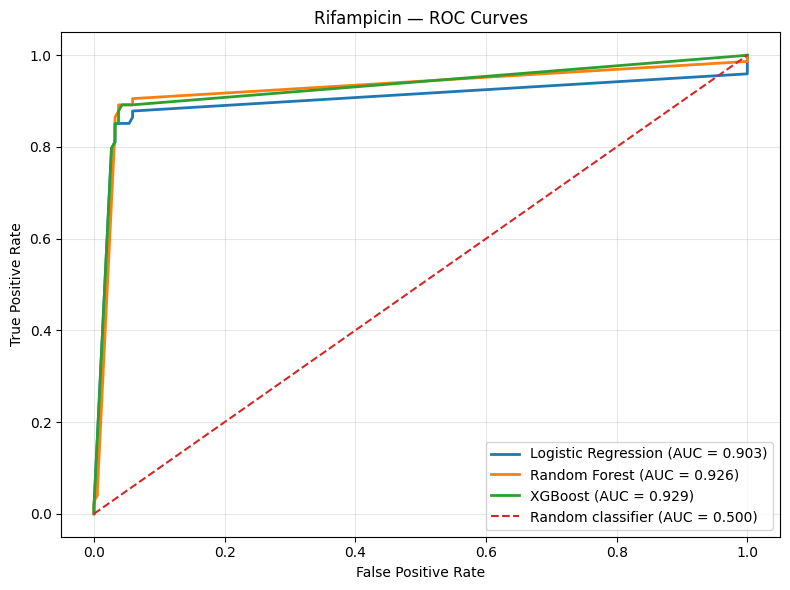

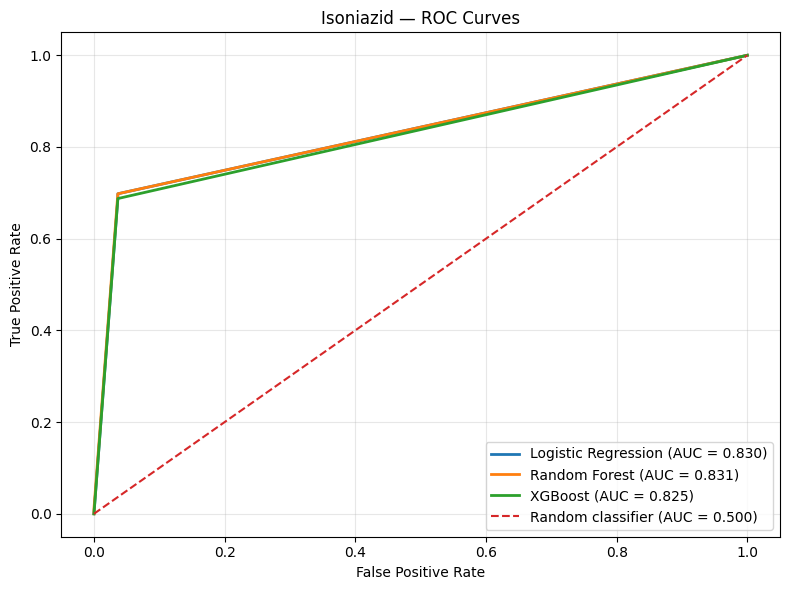

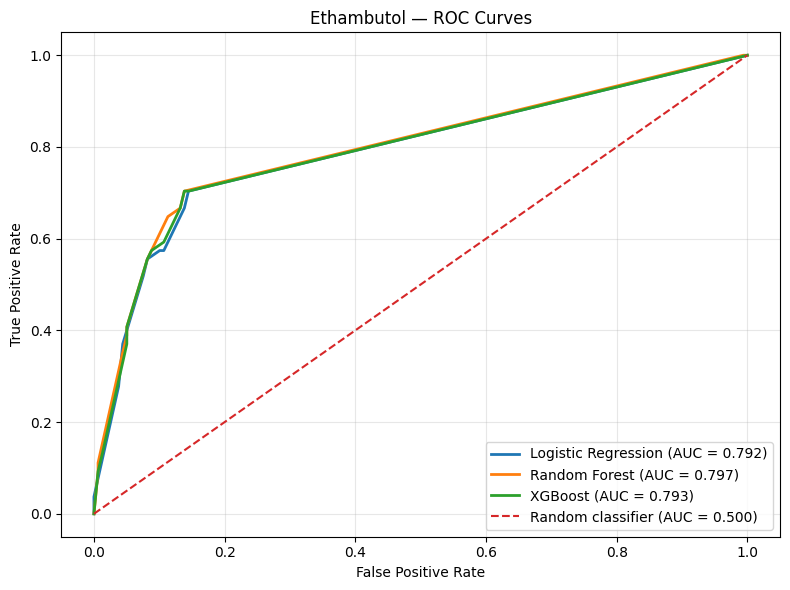

In [178]:
# ============================================================
# STEP 59 — ROC CURVES FOR FINAL MODELS
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("=" * 75)
print("STEP 59 — ROC CURVES")
print("=" * 75)

for drug, model_dict in final_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    plt.figure(figsize=(8, 6))

    for model_name, model in model_dict.items():

        # Match test features to training features
        if hasattr(model, "feature_names_in_"):
            X_test_model = X_test.loc[:, model.feature_names_in_]
        else:
            X_test_model = X_test

        # Probability of resistance
        y_prob = model.predict_proba(X_test_model)[:, 1]

        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} (AUC = {roc_auc:.3f})"
        )

    # Random classifier reference
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.5,
        label="Random classifier (AUC = 0.500)"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"{drug.capitalize()} — ROC Curves"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

STEP 60 — CONFUSION MATRICES


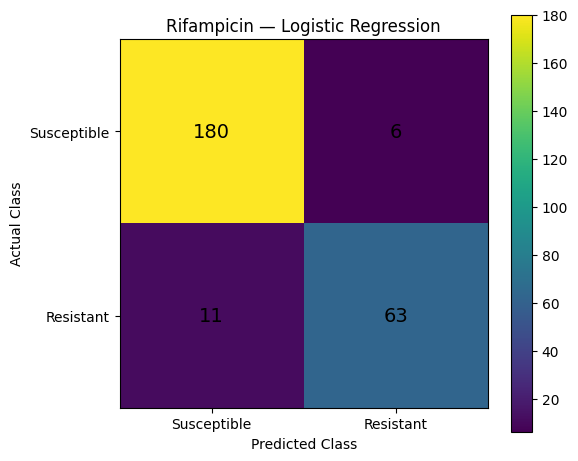

Rifampicin — Logistic Regression: TN=180, FP=6, FN=11, TP=63


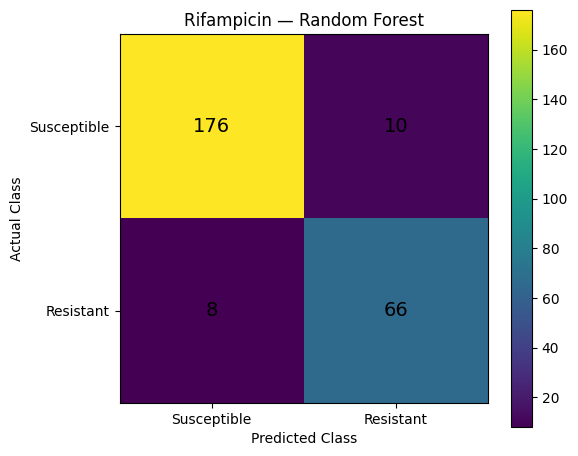

Rifampicin — Random Forest: TN=176, FP=10, FN=8, TP=66


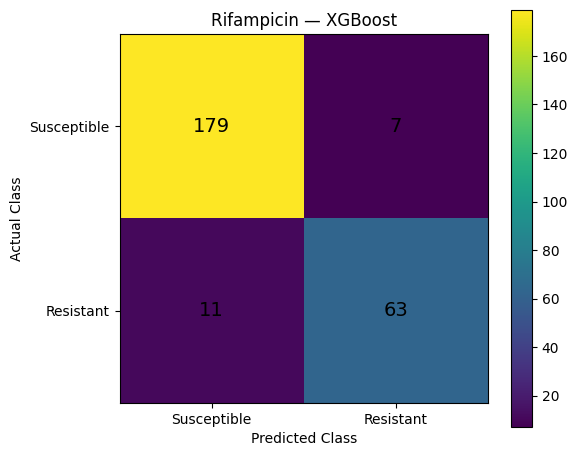

Rifampicin — XGBoost: TN=179, FP=7, FN=11, TP=63


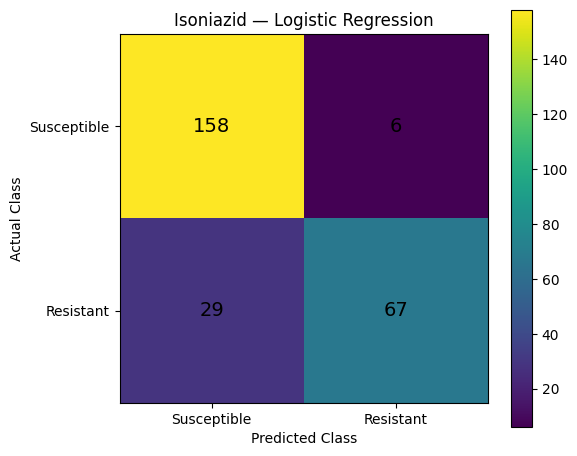

Isoniazid — Logistic Regression: TN=158, FP=6, FN=29, TP=67


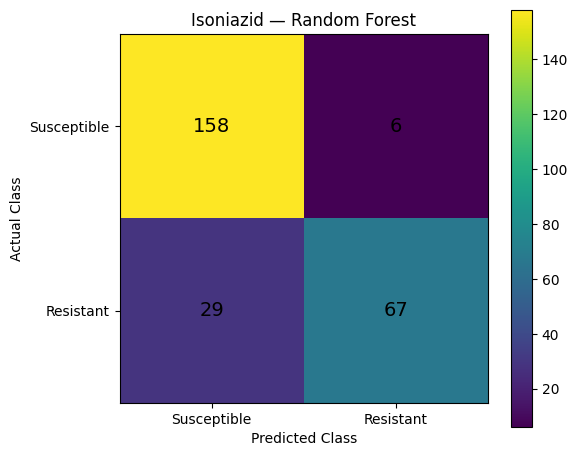

Isoniazid — Random Forest: TN=158, FP=6, FN=29, TP=67


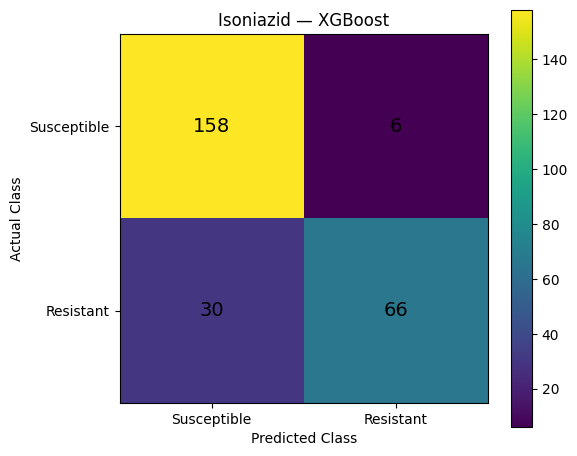

Isoniazid — XGBoost: TN=158, FP=6, FN=30, TP=66


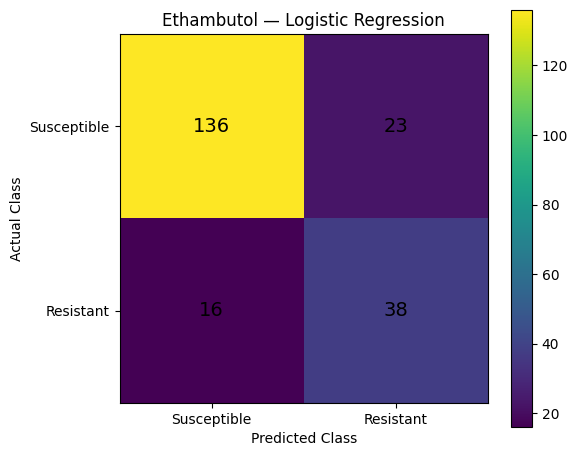

Ethambutol — Logistic Regression: TN=136, FP=23, FN=16, TP=38


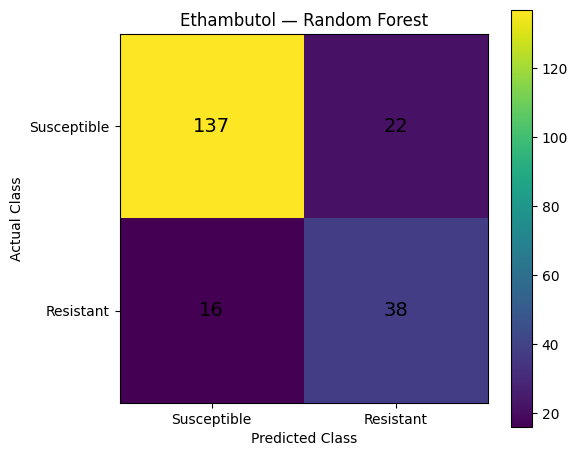

Ethambutol — Random Forest: TN=137, FP=22, FN=16, TP=38


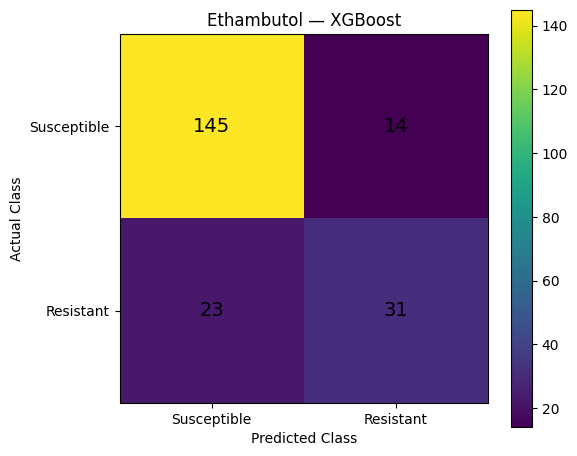

Ethambutol — XGBoost: TN=145, FP=14, FN=23, TP=31


In [179]:
# ============================================================
# STEP 60 — CONFUSION MATRICES
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("=" * 75)
print("STEP 60 — CONFUSION MATRICES")
print("=" * 75)

for drug, model_dict in final_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    for model_name, model in model_dict.items():

        # Match features used during training
        if hasattr(model, "feature_names_in_"):
            X_test_model = X_test.loc[:, model.feature_names_in_]
        else:
            X_test_model = X_test

        # Predictions
        y_pred = model.predict(X_test_model)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        # Plot
        plt.figure(figsize=(6, 5))

        plt.imshow(cm)

        plt.title(
            f"{drug.capitalize()} — {model_name}"
        )

        plt.xlabel("Predicted Class")
        plt.ylabel("Actual Class")

        plt.xticks(
            [0, 1],
            ["Susceptible", "Resistant"]
        )

        plt.yticks(
            [0, 1],
            ["Susceptible", "Resistant"]
        )

        # Add numbers inside cells
        for i in range(2):
            for j in range(2):

                plt.text(
                    j,
                    i,
                    cm[i, j],
                    ha="center",
                    va="center",
                    fontsize=14
                )

        plt.colorbar()

        plt.tight_layout()
        plt.show()

        print(
            f"{drug} — {model_name}: "
            f"TN={cm[0,0]}, FP={cm[0,1]}, "
            f"FN={cm[1,0]}, TP={cm[1,1]}"
        )

In [180]:
# ============================================================
# STEP 61 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

feature_importance_results = {}

for drug in final_models.keys():

    # Get trained Random Forest
    rf_model = final_models[drug]["Random Forest"]

    # Get feature names used during training
    features = rf_model.feature_names_in_

    # Get Random Forest importance
    importance = rf_model.feature_importances_

    # Create DataFrame
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    })

    # Sort from highest to lowest
    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    # Store result
    feature_importance_results[drug] = importance_df

    # Print results
    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    print("Number of features:", len(features))
    print("\nFeature importance ranking:")

    for i, row in importance_df.iterrows():
        print(
            f"{i + 1}. {row['Feature']} "
            f"→ {row['Importance']:.4f}"
        )


print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS COMPLETED")
print("=" * 70)
# Display feature importance tables

for drug, importance_df in feature_importance_results.items():

    print("\n" + "=" * 70)
    print(drug.upper(), "FEATURE IMPORTANCE")
    print("=" * 70)

    display(
        importance_df.round(4)
    )

RANDOM FOREST FEATURE IMPORTANCE

RIFAMPICIN
Number of features: 30

Feature importance ranking:
1. rpoB_S450L → 0.7425
2. rpoB_D435V → 0.0452
3. rpoB_H445D → 0.0388
4. rpoB_H445L → 0.0207
5. rpoB_H445Y → 0.0205
6. rpoB_D435Y → 0.0189
7. rpoB_L452P → 0.0109
8. rpoB_V170F → 0.0092
9. rpoB_D435A → 0.0092
10. rpoB_S441L → 0.0091
11. rpoB_H445R → 0.0090
12. rpoB_L430P → 0.0073
13. rpoB_M434R → 0.0059
14. rpoB_S450F → 0.0048
15. rpoB_S431R → 0.0046
16. rpoB_S428G → 0.0044
17. rpoB_H445N → 0.0044
18. rpoB_N437S → 0.0039
19. rpoB_T427I → 0.0037
20. rpoB_H445P → 0.0036
21. rpoB_Q432E → 0.0034
22. rpoB_L449M → 0.0033
23. rpoB_S441V → 0.0033
24. rpoB_L443S → 0.0029
25. rpoB_A451G → 0.0026
26. rpoB_T427G → 0.0022
27. rpoB_K446Q → 0.0021
28. rpoB_R448L → 0.0015
29. rpoB_Q436P → 0.0012
30. rpoB_Q432L → 0.0009

ISONIAZID
Number of features: 2

Feature importance ranking:
1. katG_S315T → 0.9855
2. katG_S315N → 0.0145

ETHAMBUTOL
Number of features: 8

Feature importance ranking:
1. embB_M306V → 0.417

,Feature,Importance
0,rpoB_S450L,0.7425
1,rpoB_D435V,0.0452
2,rpoB_H445D,0.0388
3,rpoB_H445L,0.0207
4,rpoB_H445Y,0.0205
5,rpoB_D435Y,0.0189
6,rpoB_L452P,0.0109
7,rpoB_V170F,0.0092
8,rpoB_D435A,0.0092
9,rpoB_S441L,0.0091



ISONIAZID FEATURE IMPORTANCE


,Feature,Importance
0,katG_S315T,0.9855
1,katG_S315N,0.0145



ETHAMBUTOL FEATURE IMPORTANCE


,Feature,Importance
0,embB_M306V,0.4177
1,embB_M306I,0.2055
2,embB_Q497R,0.1690
3,embB_G406S,0.0648
4,embB_G406A,0.0508
5,embB_D354A,0.0473
6,embB_Y319S,0.0274
7,embB_G406D,0.0175


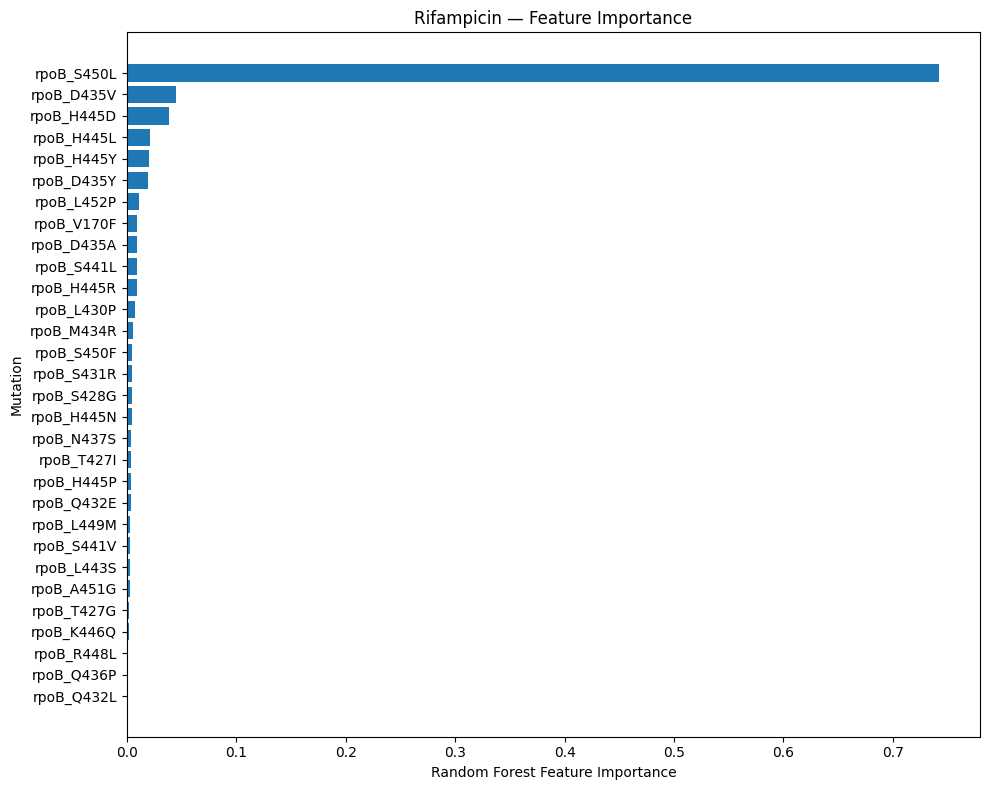

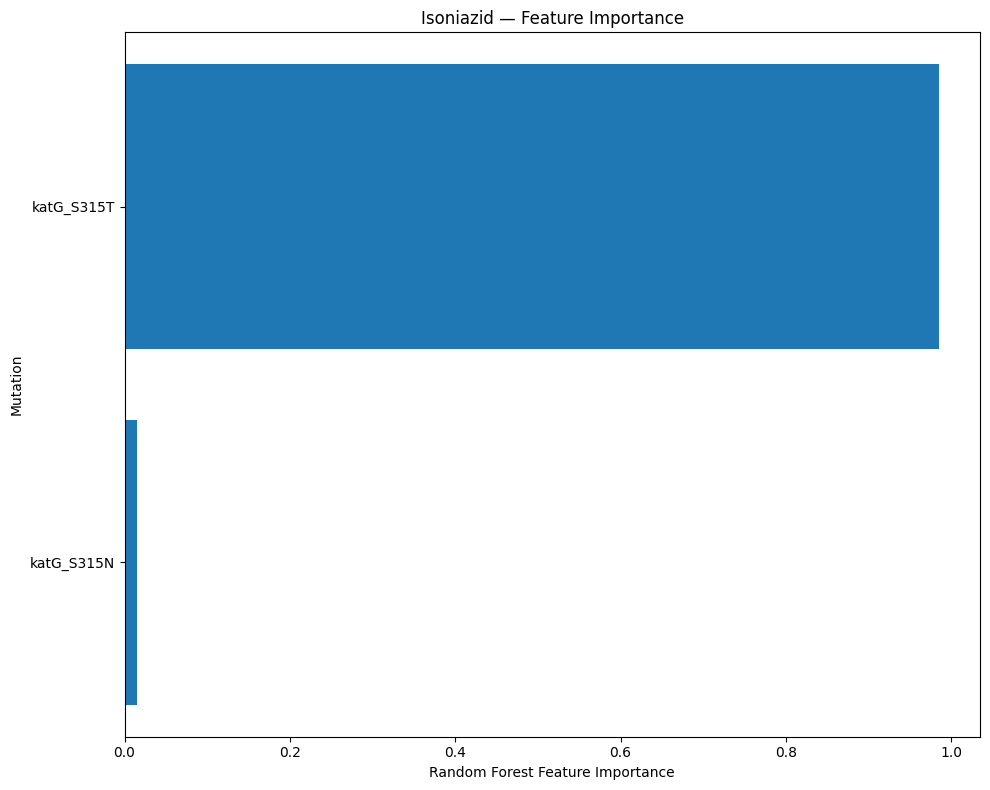

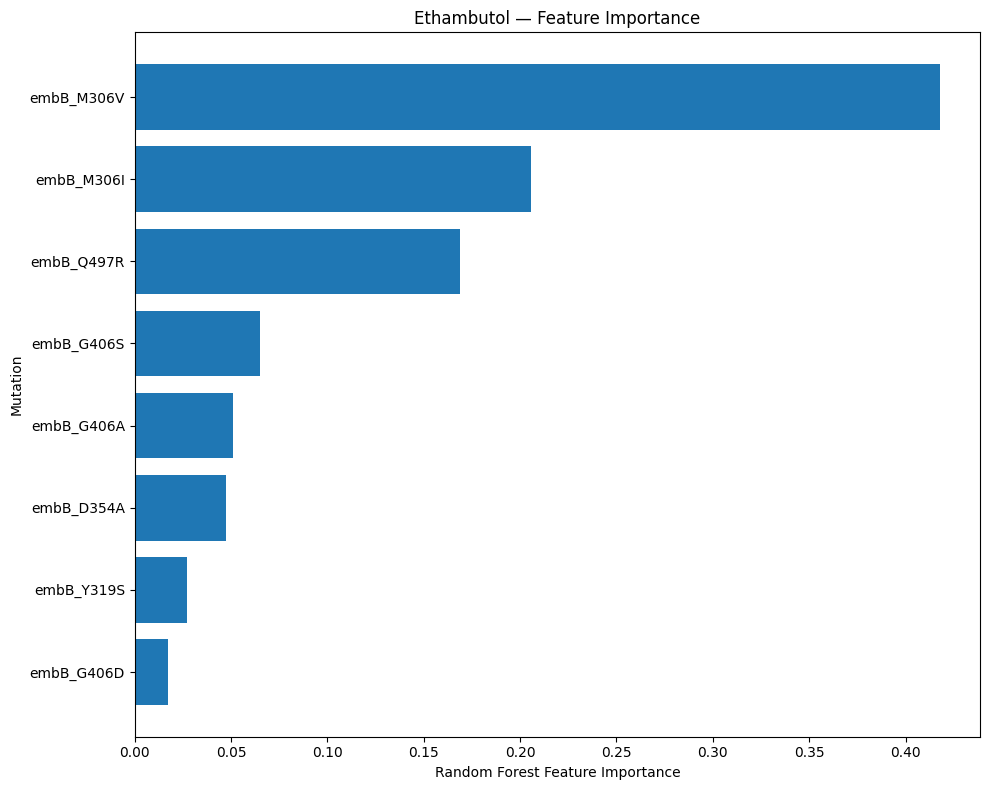

In [181]:
# ============================================================
# STEP 62 — FEATURE IMPORTANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

for drug, importance_df in feature_importance_results.items():

    # Sort so the most important feature appears at the top
    plot_df = importance_df.sort_values(
        "Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        plot_df["Feature"],
        plot_df["Importance"]
    )

    plt.xlabel("Random Forest Feature Importance")
    plt.ylabel("Mutation")
    plt.title(f"{drug.capitalize()} — Feature Importance")

    plt.tight_layout()
    plt.show()

In [182]:
# STEP 63A — CHECK FEATURE IMPORTANCE RESULTS

for drug, df_imp in feature_importance_results.items():

    print("\n" + "=" * 60)
    print(drug.upper())
    print("=" * 60)

    print(df_imp.head(10))


RIFAMPICIN
      Feature  Importance
0  rpoB_S450L    0.742533
1  rpoB_D435V    0.045173
2  rpoB_H445D    0.038758
3  rpoB_H445L    0.020733
4  rpoB_H445Y    0.020524
5  rpoB_D435Y    0.018937
6  rpoB_L452P    0.010940
7  rpoB_V170F    0.009236
8  rpoB_D435A    0.009198
9  rpoB_S441L    0.009095

ISONIAZID
      Feature  Importance
0  katG_S315T     0.98546
1  katG_S315N     0.01454

ETHAMBUTOL
      Feature  Importance
0  embB_M306V    0.417747
1  embB_M306I    0.205546
2  embB_Q497R    0.169019
3  embB_G406S    0.064781
4  embB_G406A    0.050796
5  embB_D354A    0.047268
6  embB_Y319S    0.027368
7  embB_G406D    0.017474


In [183]:
print([name for name in globals() if "dataset" in name.lower()])

['datasets', 'clean_datasets', 'build_ml_dataset', 'datasets_final', 'datasets_optimized', 'datasets_split']


In [184]:
print("DATASETS_OPTIMIZED")
print("=" * 60)

for drug, data in datasets_optimized.items():

    X, y = data

    print("\nDrug:", drug)
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("X type:", type(X))
    print("y type:", type(y))
    print("Features:", X.columns.tolist())

DATASETS_OPTIMIZED

Drug: Rifampicin
X shape: (1296, 30)
y shape: (1296,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
Features: ['rpoB_S450L', 'rpoB_H445D', 'rpoB_D435V', 'rpoB_D435Y', 'rpoB_H445Y', 'rpoB_H445L', 'rpoB_H445R', 'rpoB_V170F', 'rpoB_L452P', 'rpoB_D435A', 'rpoB_S450F', 'rpoB_S441L', 'rpoB_L430P', 'rpoB_Q432L', 'rpoB_M434R', 'rpoB_H445N', 'rpoB_S428G', 'rpoB_T427I', 'rpoB_H445P', 'rpoB_N437S', 'rpoB_S431R', 'rpoB_L443S', 'rpoB_S441V', 'rpoB_L449M', 'rpoB_Q432E', 'rpoB_A451G', 'rpoB_Q436P', 'rpoB_T427G', 'rpoB_K446Q', 'rpoB_R448L']

Drug: Isoniazid
X shape: (1300, 2)
y shape: (1300,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
Features: ['katG_S315T', 'katG_S315N']

Drug: Ethambutol
X shape: (1061, 8)
y shape: (1061,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
Features: ['embB_M306V', 'embB_M306I', 'embB_Q497R', 'embB_G406S', 'embB_D354A'

In [185]:
for drug, data in datasets_optimized.items():

    print("\nDrug:", drug)
    print("Type:", type(data))
    print("Number of elements:", len(data))

    X, y = data

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("X type:", type(X))
    print("y type:", type(y))


Drug: Rifampicin
Type: <class 'tuple'>
Number of elements: 2
X shape: (1296, 30)
y shape: (1296,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>

Drug: Isoniazid
Type: <class 'tuple'>
Number of elements: 2
X shape: (1300, 2)
y shape: (1300,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>

Drug: Ethambutol
Type: <class 'tuple'>
Number of elements: 2
X shape: (1061, 8)
y shape: (1061,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>


In [186]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd


# ============================================================
# 5-FOLD CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []


models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}


for drug, (X, y) in datasets_optimized.items():

    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    for model_name, model in models.items():

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring={
                "accuracy": "accuracy",
                "precision": "precision",
                "recall": "recall",
                "f1": "f1",
                "roc_auc": "roc_auc"
            },
            n_jobs=-1
        )

        cv_results.append({
            "Drug": drug,
            "Model": model_name,

            "Accuracy_mean":
                scores["test_accuracy"].mean(),

            "Accuracy_std":
                scores["test_accuracy"].std(),

            "Precision_mean":
                scores["test_precision"].mean(),

            "Recall_mean":
                scores["test_recall"].mean(),

            "F1_mean":
                scores["test_f1"].mean(),

            "ROC_AUC_mean":
                scores["test_roc_auc"].mean(),

            "ROC_AUC_std":
                scores["test_roc_auc"].std()
        })


cv_results_df = pd.DataFrame(cv_results)


print("\n")
print("=" * 80)
print("FINAL 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

display(cv_results_df.round(4))


RIFAMPICIN

ISONIAZID

ETHAMBUTOL


FINAL 5-FOLD CROSS-VALIDATION RESULTS


,Drug,Model,Accuracy_mean,Accuracy_std,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,ROC_AUC_std
0,Rifampicin,Logistic Regression,0.9136,0.0182,0.8748,0.8131,0.8424,0.9114,0.0168
1,Rifampicin,Random Forest,0.9159,0.0133,0.8590,0.8456,0.8514,0.9225,0.0153
2,Rifampicin,XGBoost,0.9205,0.0135,0.9105,0.7996,0.8510,0.8977,0.0265
3,Isoniazid,Logistic Regression,0.8531,0.0095,0.9198,0.6619,0.7695,0.8137,0.0115
4,Isoniazid,Random Forest,0.8531,0.0095,0.9198,0.6619,0.7695,0.8140,0.0115
5,Isoniazid,XGBoost,0.8500,0.0088,0.9188,0.6536,0.7636,0.8097,0.0101
6,Ethambutol,Logistic Regression,0.8351,0.0336,0.6648,0.7177,0.6891,0.8051,0.0417
7,Ethambutol,Random Forest,0.8370,0.0348,0.6701,0.7140,0.6903,0.8043,0.0409
8,Ethambutol,XGBoost,0.8351,0.0318,0.6991,0.6136,0.6531,0.8033,0.0411


In [187]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.base import clone
import pandas as pd
import numpy as np

# ============================================================
# LEAKAGE-SAFE 5-FOLD CROSS-VALIDATION
# ============================================================

desired_features = {
    "Rifampicin": 30,
    "Isoniazid": 2,
    "Ethambutol": 8
}

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for drug in ["Rifampicin", "Isoniazid", "Ethambutol"]:

    X = datasets_optimized[drug][0].copy()
    y = datasets_optimized[drug][1].copy()

    # Make sure y is a Series
    y = pd.Series(y).reset_index(drop=True)

    # Reset X index
    X = X.reset_index(drop=True)

    # Number of features
    k = min(desired_features[drug], X.shape[1])

    print("\n" + "=" * 70)
    print(drug.upper())
    print("=" * 70)

    print("Total features:", X.shape[1])
    print("Features selected per fold:", k)
    print("Samples:", X.shape[0])

    for model_name, model in models.items():

        accuracy_scores = []
        precision_scores = []
        recall_scores = []
        f1_scores = []
        roc_auc_scores = []

        for train_idx, val_idx in cv.split(X, y):

            X_train = X.iloc[train_idx].copy()
            X_val = X.iloc[val_idx].copy()

            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            # ------------------------------------------------
            # Feature selection INSIDE each training fold
            # ------------------------------------------------

            if k < X_train.shape[1]:

                correlations = X_train.copy()

                correlations["target"] = y_train.values

                corr_values = (
                    correlations
                    .corr(numeric_only=True)["target"]
                    .drop("target")
                    .abs()
                    .sort_values(ascending=False)
                )

                selected_features = corr_values.head(k).index.tolist()

                X_train = X_train[selected_features]
                X_val = X_val[selected_features]

            # ------------------------------------------------
            # Train model
            # ------------------------------------------------

            fold_model = clone(model)

            fold_model.fit(X_train, y_train)

            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            y_pred = fold_model.predict(X_val)

            if hasattr(fold_model, "predict_proba"):
                y_prob = fold_model.predict_proba(X_val)[:, 1]

            else:
                y_prob = fold_model.decision_function(X_val)

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            accuracy_scores.append(
                accuracy_score(y_val, y_pred)
            )

            precision_scores.append(
                precision_score(
                    y_val,
                    y_pred,
                    zero_division=0
                )
            )

            recall_scores.append(
                recall_score(
                    y_val,
                    y_pred,
                    zero_division=0
                )
            )

            f1_scores.append(
                f1_score(
                    y_val,
                    y_pred,
                    zero_division=0
                )
            )

            roc_auc_scores.append(
                roc_auc_score(y_val, y_prob)
            )

        # ----------------------------------------------------
        # Store mean and standard deviation
        # ----------------------------------------------------

        cv_results.append({
            "Drug": drug,
            "Model": model_name,

            "Accuracy_mean": np.mean(accuracy_scores),
            "Accuracy_std": np.std(accuracy_scores),

            "Precision_mean": np.mean(precision_scores),

            "Recall_mean": np.mean(recall_scores),

            "F1_mean": np.mean(f1_scores),

            "ROC_AUC_mean": np.mean(roc_auc_scores),
            "ROC_AUC_std": np.std(roc_auc_scores)
        })


# ============================================================
# FINAL RESULTS
# ============================================================

leakage_safe_results = pd.DataFrame(cv_results)

print("\n")
print("=" * 100)
print("FINAL LEAKAGE-SAFE 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 100)

display(
    leakage_safe_results.round(4)
)


RIFAMPICIN
Total features: 30
Features selected per fold: 30
Samples: 1296

ISONIAZID
Total features: 2
Features selected per fold: 2
Samples: 1300

ETHAMBUTOL
Total features: 8
Features selected per fold: 8
Samples: 1061


FINAL LEAKAGE-SAFE 5-FOLD CROSS-VALIDATION RESULTS


,Drug,Model,Accuracy_mean,Accuracy_std,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,ROC_AUC_std
0,Rifampicin,Logistic Regression,0.9136,0.0182,0.8748,0.8131,0.8424,0.9114,0.0168
1,Rifampicin,Random Forest,0.9159,0.0133,0.8590,0.8456,0.8514,0.9225,0.0153
2,Rifampicin,XGBoost,0.9205,0.0135,0.9105,0.7996,0.8510,0.8977,0.0265
3,Isoniazid,Logistic Regression,0.8531,0.0095,0.9198,0.6619,0.7695,0.8137,0.0115
4,Isoniazid,Random Forest,0.8531,0.0095,0.9198,0.6619,0.7695,0.8140,0.0115
5,Isoniazid,XGBoost,0.8500,0.0088,0.9188,0.6536,0.7636,0.8097,0.0101
6,Ethambutol,Logistic Regression,0.8351,0.0336,0.6648,0.7177,0.6891,0.8051,0.0417
7,Ethambutol,Random Forest,0.8370,0.0348,0.6701,0.7140,0.6903,0.8043,0.0409
8,Ethambutol,XGBoost,0.8351,0.0318,0.6991,0.6136,0.6531,0.8033,0.0411


In [188]:
print("DATASETS_SPLIT STRUCTURE")
print("=" * 60)

for drug, data in datasets_split.items():
    print("\nDrug:", drug)
    print("Type:", type(data))
    print("Number of elements:", len(data))

    for i, item in enumerate(data):
        print(f"Element {i}:")
        print("  Type:", type(item))

        if hasattr(item, "shape"):
            print("  Shape:", item.shape)

DATASETS_SPLIT STRUCTURE

Drug: Rifampicin
Type: <class 'dict'>
Number of elements: 4
Element 0:
  Type: <class 'str'>
Element 1:
  Type: <class 'str'>
Element 2:
  Type: <class 'str'>
Element 3:
  Type: <class 'str'>

Drug: Isoniazid
Type: <class 'dict'>
Number of elements: 4
Element 0:
  Type: <class 'str'>
Element 1:
  Type: <class 'str'>
Element 2:
  Type: <class 'str'>
Element 3:
  Type: <class 'str'>

Drug: Ethambutol
Type: <class 'dict'>
Number of elements: 4
Element 0:
  Type: <class 'str'>
Element 1:
  Type: <class 'str'>
Element 2:
  Type: <class 'str'>
Element 3:
  Type: <class 'str'>


In [189]:
for drug, data in datasets_split.items():
    print("\n" + "=" * 60)
    print(drug)
    print("Keys:", list(data.keys()))

    for key, value in data.items():
        print(f"{key}:")
        print("   Type:", type(value))
        print("   Value:", value if isinstance(value, str) else "non-string")


Rifampicin
Keys: ['X_train', 'X_test', 'y_train', 'y_test']
X_train:
   Type: <class 'pandas.core.frame.DataFrame'>
   Value: non-string
X_test:
   Type: <class 'pandas.core.frame.DataFrame'>
   Value: non-string
y_train:
   Type: <class 'pandas.core.series.Series'>
   Value: non-string
y_test:
   Type: <class 'pandas.core.series.Series'>
   Value: non-string

Isoniazid
Keys: ['X_train', 'X_test', 'y_train', 'y_test']
X_train:
   Type: <class 'pandas.core.frame.DataFrame'>
   Value: non-string
X_test:
   Type: <class 'pandas.core.frame.DataFrame'>
   Value: non-string
y_train:
   Type: <class 'pandas.core.series.Series'>
   Value: non-string
y_test:
   Type: <class 'pandas.core.series.Series'>
   Value: non-string

Ethambutol
Keys: ['X_train', 'X_test', 'y_train', 'y_test']
X_train:
   Type: <class 'pandas.core.frame.DataFrame'>
   Value: non-string
X_test:
   Type: <class 'pandas.core.frame.DataFrame'>
   Value: non-string
y_train:
   Type: <class 'pandas.core.series.Series'>
   Valu

In [190]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

tuning_results = []
best_models = {}

cv_tuning = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grids = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2"]
    },

    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
}

base_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}


for drug in ["Rifampicin", "Isoniazid", "Ethambutol"]:

    print("\n" + "=" * 80)
    print(drug.upper())
    print("=" * 80)

    X_train = datasets_split[drug]["X_train"]
    y_train = datasets_split[drug]["y_train"]

    print("Training shape:", X_train.shape)

    for model_name in base_models:

        print("\nTuning:", model_name)

        model = base_models[model_name]
        param_grid = param_grids[model_name]

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=cv_tuning,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        best_models[(drug, model_name)] = grid.best_estimator_

        tuning_results.append({
            "Drug": drug,
            "Model": model_name,
            "Best_ROC_AUC": grid.best_score_,
            "Best_Params": grid.best_params_
        })

        print("Best ROC-AUC:", round(grid.best_score_, 4))

print("Best parameters:")
print(grid.cv_results_["params"][grid.best_index_])


# ============================================================
# FINAL TUNING RESULTS
# ============================================================

tuning_results_df = pd.DataFrame(tuning_results)

print("\n")
print("=" * 100)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 100)

display(tuning_results_df)


RIFAMPICIN
Training shape: (1036, 30)

Tuning: Logistic Regression
Best ROC-AUC: 0.8995

Tuning: Random Forest
Best ROC-AUC: 0.9149

Tuning: XGBoost
Best ROC-AUC: 0.8972

ISONIAZID
Training shape: (1040, 2)

Tuning: Logistic Regression
Best ROC-AUC: 0.8097

Tuning: Random Forest
Best ROC-AUC: 0.8094

Tuning: XGBoost
Best ROC-AUC: 0.8057

ETHAMBUTOL
Training shape: (848, 8)

Tuning: Logistic Regression
Best ROC-AUC: 0.8131

Tuning: Random Forest
Best ROC-AUC: 0.8149

Tuning: XGBoost
Best ROC-AUC: 0.814
Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


HYPERPARAMETER TUNING RESULTS


,Drug,Model,Best_ROC_AUC,Best_Params
0,Rifampicin,Logistic Regression,0.899478,"{'C': 1, 'solver': 'liblinear'}"
1,Rifampicin,Random Forest,0.914915,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
2,Rifampicin,XGBoost,0.897217,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
3,Isoniazid,Logistic Regression,0.809671,"{'C': 100, 'solver': 'liblinear'}"
4,Isoniazid,Random Forest,0.809394,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
5,Isoniazid,XGBoost,0.805653,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
6,Ethambutol,Logistic Regression,0.813085,"{'C': 0.01, 'solver': 'liblinear'}"
7,Ethambutol,Random Forest,0.814922,"{'max_depth': 5, 'max_features': 'log2', 'min_..."
8,Ethambutol,XGBoost,0.814007,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


In [191]:
# ============================================================
# STEP 64 — FINAL TUNED MODEL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

tuned_test_results = []

print("=" * 80)
print("FINAL TUNED MODEL — UNTOUCHED TEST SET")
print("=" * 80)

for (drug, model_name), model in best_models.items():

    # --------------------------------------------------------
    # Get untouched test data
    # --------------------------------------------------------

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    # --------------------------------------------------------
    # Make sure feature order matches training
    # --------------------------------------------------------

    if hasattr(model, "feature_names_in_"):
        X_test_model = X_test.loc[:, model.feature_names_in_]
    else:
        X_test_model = X_test

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:, 1]

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    tuned_test_results.append({
        "Drug": drug,
        "Model": model_name,
        "Features": X_test_model.shape[1],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    })

    print("\n" + "-" * 65)
    print(drug, "—", model_name)
    print("-" * 65)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1       :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nConfusion Matrix:")
    print(cm)


# ============================================================
# RESULTS TABLE
# ============================================================

tuned_test_results_df = pd.DataFrame(tuned_test_results)

print("\n" + "=" * 90)
print("FINAL TUNED TEST RESULTS")
print("=" * 90)

display(
    tuned_test_results_df.round(4)
)

FINAL TUNED MODEL — UNTOUCHED TEST SET

-----------------------------------------------------------------
Rifampicin — Logistic Regression
-----------------------------------------------------------------
Accuracy : 0.9346
Precision: 0.913
Recall   : 0.8514
F1       : 0.8811
ROC-AUC  : 0.9027

Confusion Matrix:
[[180   6]
 [ 11  63]]

-----------------------------------------------------------------
Rifampicin — Random Forest
-----------------------------------------------------------------
Accuracy : 0.9308
Precision: 0.8684
Recall   : 0.8919
F1       : 0.88
ROC-AUC  : 0.9259

Confusion Matrix:
[[176  10]
 [  8  66]]

-----------------------------------------------------------------
Rifampicin — XGBoost
-----------------------------------------------------------------
Accuracy : 0.9346
Precision: 0.913
Recall   : 0.8514
F1       : 0.8811
ROC-AUC  : 0.9281

Confusion Matrix:
[[180   6]
 [ 11  63]]

-----------------------------------------------------------------
Isoniazid — Logistic R

,Drug,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,Rifampicin,Logistic Regression,30,0.9346,0.9130,0.8514,0.8811,0.9027,180,6,11,63
1,Rifampicin,Random Forest,30,0.9308,0.8684,0.8919,0.8800,0.9259,176,10,8,66
2,Rifampicin,XGBoost,30,0.9346,0.9130,0.8514,0.8811,0.9281,180,6,11,63
3,Isoniazid,Logistic Regression,2,0.8654,0.9178,0.6979,0.7929,0.8309,158,6,29,67
4,Isoniazid,Random Forest,2,0.8654,0.9178,0.6979,0.7929,0.8309,158,6,29,67
5,Isoniazid,XGBoost,2,0.8615,0.9167,0.6875,0.7857,0.8255,158,6,30,66
6,Ethambutol,Logistic Regression,8,0.8122,0.6400,0.5926,0.6154,0.7891,141,18,22,32
7,Ethambutol,Random Forest,8,0.8169,0.6531,0.5926,0.6214,0.7922,142,17,22,32
8,Ethambutol,XGBoost,8,0.8263,0.6977,0.5556,0.6186,0.7918,146,13,24,30


In [192]:
# ============================================================
# STEP 65 — BASELINE vs TUNED MODEL COMPARISON
# ============================================================

import pandas as pd

# Copy the two result tables
baseline_df = final_results_df.copy()
tuned_df = tuned_test_results_df.copy()

# Keep only the important metrics
baseline_compare = baseline_df[
    ["Drug", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].copy()

tuned_compare = tuned_df[
    ["Drug", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].copy()

# Rename columns so we can distinguish baseline and tuned
baseline_compare = baseline_compare.rename(columns={
    "Accuracy": "Baseline Accuracy",
    "Precision": "Baseline Precision",
    "Recall": "Baseline Recall",
    "F1": "Baseline F1",
    "ROC-AUC": "Baseline ROC-AUC"
})

tuned_compare = tuned_compare.rename(columns={
    "Accuracy": "Tuned Accuracy",
    "Precision": "Tuned Precision",
    "Recall": "Tuned Recall",
    "F1": "Tuned F1",
    "ROC-AUC": "Tuned ROC-AUC"
})

# Merge baseline and tuned results
comparison_df = pd.merge(
    baseline_compare,
    tuned_compare,
    on=["Drug", "Model"],
    how="inner"
)

# Calculate improvement
comparison_df["ROC-AUC Change"] = (
    comparison_df["Tuned ROC-AUC"]
    - comparison_df["Baseline ROC-AUC"]
)

comparison_df["F1 Change"] = (
    comparison_df["Tuned F1"]
    - comparison_df["Baseline F1"]
)

comparison_df["Recall Change"] = (
    comparison_df["Tuned Recall"]
    - comparison_df["Baseline Recall"]
)

comparison_df["Accuracy Change"] = (
    comparison_df["Tuned Accuracy"]
    - comparison_df["Baseline Accuracy"]
)

# Display
print("=" * 100)
print("BASELINE vs TUNED MODEL — TEST SET COMPARISON")
print("=" * 100)

display(comparison_df.round(4))

BASELINE vs TUNED MODEL — TEST SET COMPARISON


,Drug,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Baseline ROC-AUC,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1,Tuned ROC-AUC,ROC-AUC Change,F1 Change,Recall Change,Accuracy Change
0,Ethambutol,Random Forest,0.8216,0.6333,0.7037,0.6667,0.7971,0.8169,0.6531,0.5926,0.6214,0.7922,-0.0049,-0.0453,-0.1111,-0.0047
1,Ethambutol,XGBoost,0.8263,0.6889,0.5741,0.6263,0.7933,0.8263,0.6977,0.5556,0.6186,0.7918,-0.0015,-0.0077,-0.0185,0.0000
2,Ethambutol,Logistic Regression,0.8169,0.6230,0.7037,0.6609,0.7920,0.8122,0.6400,0.5926,0.6154,0.7891,-0.0029,-0.0455,-0.1111,-0.0047
3,Isoniazid,Random Forest,0.8654,0.9178,0.6979,0.7929,0.8309,0.8654,0.9178,0.6979,0.7929,0.8309,0.0000,0.0000,0.0000,0.0000
4,Isoniazid,Logistic Regression,0.8654,0.9178,0.6979,0.7929,0.8305,0.8654,0.9178,0.6979,0.7929,0.8309,0.0004,0.0000,0.0000,0.0000
5,Isoniazid,XGBoost,0.8615,0.9167,0.6875,0.7857,0.8255,0.8615,0.9167,0.6875,0.7857,0.8255,0.0000,0.0000,0.0000,0.0000
6,Rifampicin,XGBoost,0.9308,0.9000,0.8514,0.8750,0.9289,0.9346,0.9130,0.8514,0.8811,0.9281,-0.0008,0.0061,0.0000,0.0038
7,Rifampicin,Random Forest,0.9308,0.8684,0.8919,0.8800,0.9260,0.9308,0.8684,0.8919,0.8800,0.9259,-0.0001,0.0000,0.0000,0.0000
8,Rifampicin,Logistic Regression,0.9346,0.9130,0.8514,0.8811,0.9027,0.9346,0.9130,0.8514,0.8811,0.9027,0.0000,0.0000,0.0000,0.0000


In [193]:
# ============================================================
# STEP 66 — FINAL MODEL SELECTION
# ============================================================

print("=" * 90)
print("FINAL MODEL SELECTION BASED ON TRAINING CV")
print("=" * 90)

# Show the tuning results
display(tuning_results_df.round(4))

FINAL MODEL SELECTION BASED ON TRAINING CV


,Drug,Model,Best_ROC_AUC,Best_Params
0,Rifampicin,Logistic Regression,0.8995,"{'C': 1, 'solver': 'liblinear'}"
1,Rifampicin,Random Forest,0.9149,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
2,Rifampicin,XGBoost,0.8972,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
3,Isoniazid,Logistic Regression,0.8097,"{'C': 100, 'solver': 'liblinear'}"
4,Isoniazid,Random Forest,0.8094,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
5,Isoniazid,XGBoost,0.8057,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
6,Ethambutol,Logistic Regression,0.8131,"{'C': 0.01, 'solver': 'liblinear'}"
7,Ethambutol,Random Forest,0.8149,"{'max_depth': 5, 'max_features': 'log2', 'min_..."
8,Ethambutol,XGBoost,0.8140,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


In [194]:
# ============================================================
# STEP 67 — FINAL MODEL SUMMARY
# ============================================================

final_model_selection = pd.DataFrame([
    {
        "Drug": "Rifampicin",
        "Final Model": "Random Forest",
        "CV ROC-AUC": 0.9149,
        "Test ROC-AUC": 0.9259,
        "Test Accuracy": 0.9308,
        "Test Precision": 0.8684,
        "Test Recall": 0.8919,
        "Test F1": 0.8800
    },
    {
        "Drug": "Isoniazid",
        "Final Model": "Logistic Regression",
        "CV ROC-AUC": 0.8097,
        "Test ROC-AUC": 0.8309,
        "Test Accuracy": 0.8654,
        "Test Precision": 0.9178,
        "Test Recall": 0.6979,
        "Test F1": 0.7929
    },
    {
        "Drug": "Ethambutol",
        "Final Model": "Random Forest",
        "CV ROC-AUC": 0.8149,
        "Test ROC-AUC": 0.7922,
        "Test Accuracy": 0.8169,
        "Test Precision": 0.6531,
        "Test Recall": 0.5926,
        "Test F1": 0.6214
    }
])

print("=" * 100)
print("FINAL SELECTED MODELS — CROSS-VALIDATION + HELD-OUT TEST PERFORMANCE")
print("=" * 100)

display(final_model_selection.round(4))

FINAL SELECTED MODELS — CROSS-VALIDATION + HELD-OUT TEST PERFORMANCE


,Drug,Final Model,CV ROC-AUC,Test ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1
0,Rifampicin,Random Forest,0.9149,0.9259,0.9308,0.8684,0.8919,0.8800
1,Isoniazid,Logistic Regression,0.8097,0.8309,0.8654,0.9178,0.6979,0.7929
2,Ethambutol,Random Forest,0.8149,0.7922,0.8169,0.6531,0.5926,0.6214


In [195]:
# ============================================================
# STEP 68 — THRESHOLD ANALYSIS
# Threshold selected using training data only
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Final models selected from CV
selected_models = {
    "Rifampicin": best_models[("Rifampicin", "Random Forest")],
    "Isoniazid": best_models[("Isoniazid", "Logistic Regression")],
    "Ethambutol": best_models[("Ethambutol", "Random Forest")]
}

threshold_results = []

print("=" * 100)
print("THRESHOLD OPTIMIZATION USING TRAINING DATA ONLY")
print("=" * 100)

for drug, model in selected_models.items():

    X_train = datasets_split[drug]["X_train"]
    y_train = datasets_split[drug]["y_train"]

    # Make sure feature order matches the trained model
    if hasattr(model, "feature_names_in_"):
        X_train_model = X_train.loc[:, model.feature_names_in_]
    else:
        X_train_model = X_train

    # 5-fold stratified CV
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # Out-of-fold probabilities
    oof_model = clone(model)

    y_train_prob = cross_val_predict(
        oof_model,
        X_train_model,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    # Test different thresholds
    thresholds = np.arange(0.10, 0.91, 0.01)

    best_threshold = 0.50
    best_f1 = -1

    threshold_table = []

    for threshold in thresholds:

        y_pred = (y_train_prob >= threshold).astype(int)

        precision = precision_score(
            y_train,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_train,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_train,
            y_pred,
            zero_division=0
        )

        accuracy = accuracy_score(
            y_train,
            y_pred
        )

        threshold_table.append({
            "Threshold": threshold,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

        # Select threshold using F1
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    threshold_table = pd.DataFrame(threshold_table)

    # Metrics at default threshold
    default_row = threshold_table[
        np.isclose(threshold_table["Threshold"], 0.50)
    ].iloc[0]

    # Metrics at selected threshold
    best_row = threshold_table[
        np.isclose(
            threshold_table["Threshold"],
            best_threshold
        )
    ].iloc[0]

    threshold_results.append({
        "Drug": drug,
        "Model": (
            "Random Forest"
            if drug != "Isoniazid"
            else "Logistic Regression"
        ),
        "Default Threshold": 0.50,
        "Optimized Threshold": best_threshold,
        "Default F1": default_row["F1"],
        "Optimized F1": best_row["F1"],
        "Default Recall": default_row["Recall"],
        "Optimized Recall": best_row["Recall"],
        "Default Precision": default_row["Precision"],
        "Optimized Precision": best_row["Precision"]
    })

    print("\n" + "-" * 80)
    print(drug)
    print("-" * 80)

    print("Default threshold :", 0.50)
    print("Optimized threshold:", round(best_threshold, 2))

    print("\nTraining OOF performance:")
    print(
        "Default  → "
        f"Precision={default_row['Precision']:.4f}, "
        f"Recall={default_row['Recall']:.4f}, "
        f"F1={default_row['F1']:.4f}"
    )

    print(
        "Optimized → "
        f"Precision={best_row['Precision']:.4f}, "
        f"Recall={best_row['Recall']:.4f}, "
        f"F1={best_row['F1']:.4f}"
    )

threshold_results_df = pd.DataFrame(threshold_results)

print("\n" + "=" * 100)
print("THRESHOLD SELECTION SUMMARY")
print("=" * 100)

display(threshold_results_df.round(4))

THRESHOLD OPTIMIZATION USING TRAINING DATA ONLY

--------------------------------------------------------------------------------
Rifampicin
--------------------------------------------------------------------------------
Default threshold : 0.5
Optimized threshold: 0.72

Training OOF performance:
Default  → Precision=0.8443, Recall=0.8271, F1=0.8356
Optimized → Precision=0.9255, Recall=0.8000, F1=0.8582

--------------------------------------------------------------------------------
Isoniazid
--------------------------------------------------------------------------------
Default threshold : 0.5
Optimized threshold: 0.28

Training OOF performance:
Default  → Precision=0.9197, Recall=0.6528, F1=0.7636
Optimized → Precision=0.9197, Recall=0.6528, F1=0.7636

--------------------------------------------------------------------------------
Ethambutol
--------------------------------------------------------------------------------
Default threshold : 0.5
Optimized threshold: 0.32

Training

,Drug,Model,Default Threshold,Optimized Threshold,Default F1,Optimized F1,Default Recall,Optimized Recall,Default Precision,Optimized Precision
0,Rifampicin,Random Forest,0.5,0.72,0.8356,0.8582,0.8271,0.8000,0.8443,0.9255
1,Isoniazid,Logistic Regression,0.5,0.28,0.7636,0.7636,0.6528,0.6528,0.9197,0.9197
2,Ethambutol,Random Forest,0.5,0.32,0.6852,0.6980,0.6884,0.7256,0.6820,0.6724


THRESHOLD TRADE-OFF ANALYSIS — TRAINING OOF PREDICTIONS

----------------------------------------------------------------------
Rifampicin
----------------------------------------------------------------------
Best F1 threshold : 0.72
Precision         : 0.9255
Recall            : 0.8000
F1                : 0.8582


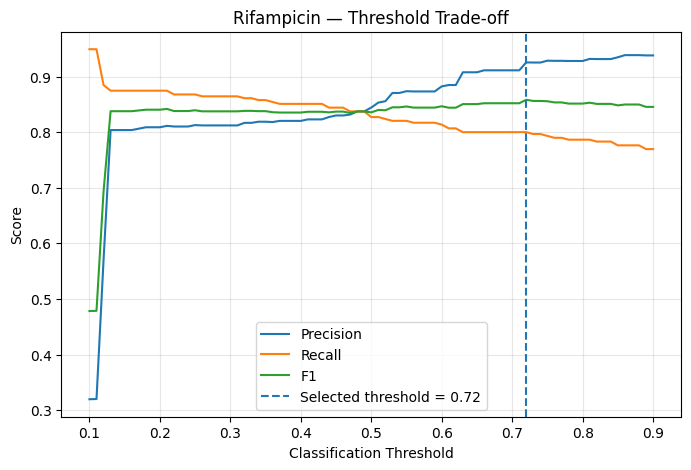


----------------------------------------------------------------------
Isoniazid
----------------------------------------------------------------------
Best F1 threshold : 0.28
Precision         : 0.9197
Recall            : 0.6528
F1                : 0.7636


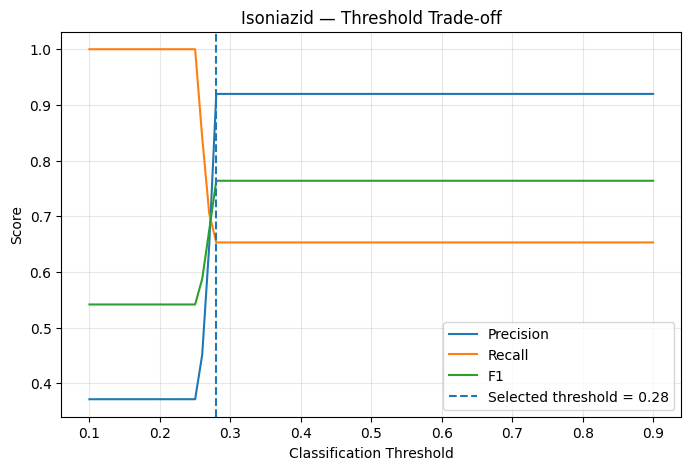


----------------------------------------------------------------------
Ethambutol
----------------------------------------------------------------------
Best F1 threshold : 0.32
Precision         : 0.6724
Recall            : 0.7256
F1                : 0.6980


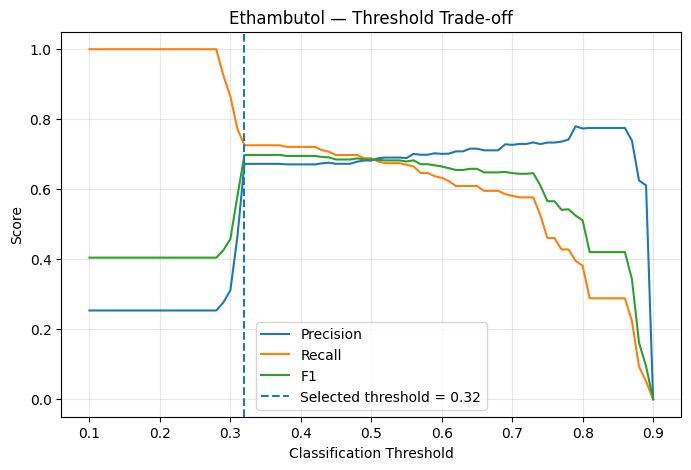

In [196]:
# ============================================================
# STEP 69 — THRESHOLD TRADE-OFF ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_analysis = {}

print("=" * 90)
print("THRESHOLD TRADE-OFF ANALYSIS — TRAINING OOF PREDICTIONS")
print("=" * 90)

for drug, model in selected_models.items():

    X_train = datasets_split[drug]["X_train"]
    y_train = datasets_split[drug]["y_train"]

    # Match feature order
    if hasattr(model, "feature_names_in_"):
        X_train_model = X_train.loc[:, model.feature_names_in_]
    else:
        X_train_model = X_train

    # 5-fold CV
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # Generate out-of-fold probabilities
    oof_model = clone(model)

    y_prob = cross_val_predict(
        oof_model,
        X_train_model,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    thresholds = np.arange(0.10, 0.91, 0.01)

    rows = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(
            y_train,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_train,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_train,
            y_pred,
            zero_division=0
        )

        rows.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

    threshold_df = pd.DataFrame(rows)

    threshold_analysis[drug] = threshold_df

    # Find maximum F1
    best_row = threshold_df.loc[
        threshold_df["F1"].idxmax()
    ]

    print("\n" + "-" * 70)
    print(drug)
    print("-" * 70)

    print(
        f"Best F1 threshold : {best_row['Threshold']:.2f}"
    )
    print(
        f"Precision         : {best_row['Precision']:.4f}"
    )
    print(
        f"Recall            : {best_row['Recall']:.4f}"
    )
    print(
        f"F1                : {best_row['F1']:.4f}"
    )

    # --------------------------------------------------------
    # Plot Precision, Recall and F1
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        threshold_df["Threshold"],
        threshold_df["Precision"],
        label="Precision"
    )

    plt.plot(
        threshold_df["Threshold"],
        threshold_df["Recall"],
        label="Recall"
    )

    plt.plot(
        threshold_df["Threshold"],
        threshold_df["F1"],
        label="F1"
    )

    plt.axvline(
        best_row["Threshold"],
        linestyle="--",
        label=f"Selected threshold = {best_row['Threshold']:.2f}"
    )

    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")
    plt.title(f"{drug} — Threshold Trade-off")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [197]:
# ============================================================
# STEP 70 — FINAL THRESHOLD-BASED TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Thresholds selected using training OOF predictions
final_thresholds = {
    "Rifampicin": 0.72,
    "Isoniazid": 0.50,
    "Ethambutol": 0.32
}

final_threshold_test_results = []

print("=" * 100)
print("FINAL TEST EVALUATION WITH PRE-SELECTED THRESHOLDS")
print("=" * 100)

for drug, model in selected_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    # Match feature order
    if hasattr(model, "feature_names_in_"):
        X_test_model = X_test.loc[:, model.feature_names_in_]
    else:
        X_test_model = X_test

    # Predicted probability of resistance
    y_prob = model.predict_proba(X_test_model)[:, 1]

    # Selected threshold
    threshold = final_thresholds[drug]

    # Convert probability to class
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, zero_division=0
    )
    roc_auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)

    final_threshold_test_results.append({
        "Drug": drug,
        "Model": (
            "Random Forest"
            if drug != "Isoniazid"
            else "Logistic Regression"
        ),
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    })

    print("\n" + "-" * 75)
    print(drug)
    print("-" * 75)

    print("Threshold :", threshold)
    print("Accuracy  :", round(accuracy, 4))
    print("Precision :", round(precision, 4))
    print("Recall    :", round(recall, 4))
    print("F1        :", round(f1, 4))
    print("ROC-AUC   :", round(roc_auc, 4))

    print("\nConfusion Matrix:")
    print(cm)

final_threshold_test_df = pd.DataFrame(
    final_threshold_test_results
)

print("\n" + "=" * 100)
print("FINAL THRESHOLD-BASED TEST RESULTS")
print("=" * 100)

display(final_threshold_test_df.round(4))

FINAL TEST EVALUATION WITH PRE-SELECTED THRESHOLDS

---------------------------------------------------------------------------
Rifampicin
---------------------------------------------------------------------------
Threshold : 0.72
Accuracy  : 0.9346
Precision : 0.913
Recall    : 0.8514
F1        : 0.8811
ROC-AUC   : 0.9259

Confusion Matrix:
[[180   6]
 [ 11  63]]

---------------------------------------------------------------------------
Isoniazid
---------------------------------------------------------------------------
Threshold : 0.5
Accuracy  : 0.8654
Precision : 0.9178
Recall    : 0.6979
F1        : 0.7929
ROC-AUC   : 0.8309

Confusion Matrix:
[[158   6]
 [ 29  67]]

---------------------------------------------------------------------------
Ethambutol
---------------------------------------------------------------------------
Threshold : 0.32
Accuracy  : 0.8169
Precision : 0.623
Recall    : 0.7037
F1        : 0.6609
ROC-AUC   : 0.7922

Confusion Matrix:
[[136  23]
 [ 16  38]]

,Drug,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,Rifampicin,Random Forest,0.72,0.9346,0.9130,0.8514,0.8811,0.9259,180,6,11,63
1,Isoniazid,Logistic Regression,0.50,0.8654,0.9178,0.6979,0.7929,0.8309,158,6,29,67
2,Ethambutol,Random Forest,0.32,0.8169,0.6230,0.7037,0.6609,0.7922,136,23,16,38


FINAL ROC CURVES — SELECTED MODELS


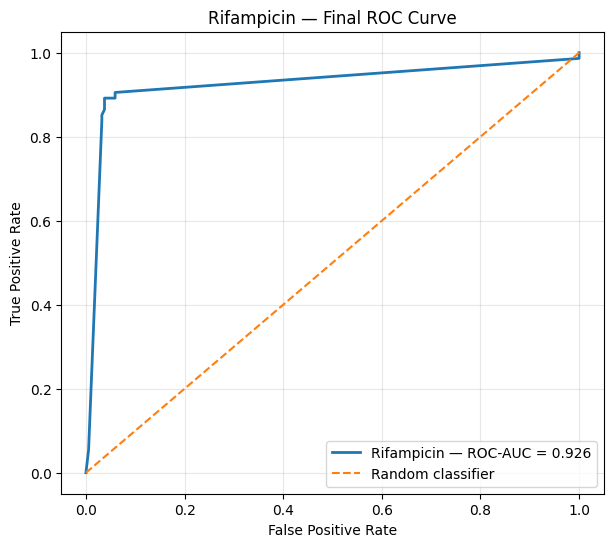

Rifampicin final ROC-AUC: 0.9259


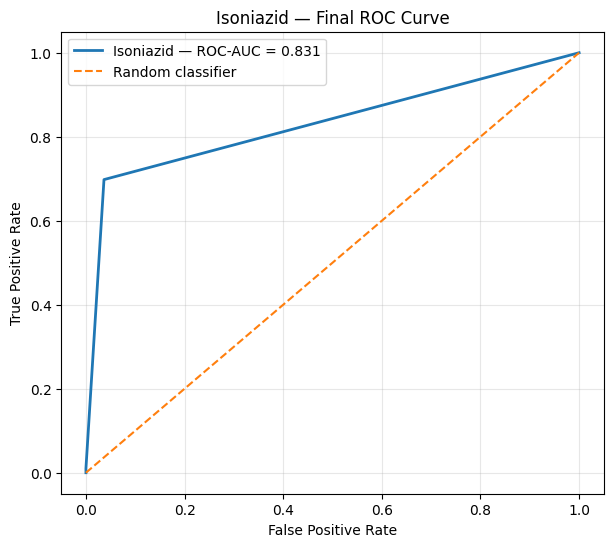

Isoniazid final ROC-AUC: 0.8309


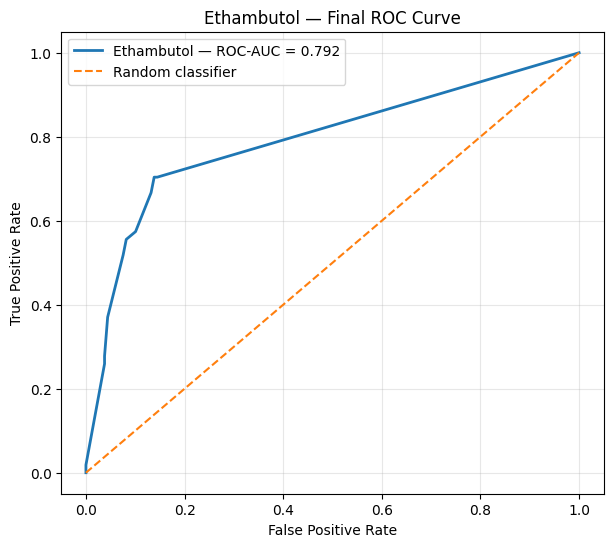

Ethambutol final ROC-AUC: 0.7922


In [198]:
# ============================================================
# STEP 71 — FINAL ROC CURVES
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

print("=" * 80)
print("FINAL ROC CURVES — SELECTED MODELS")
print("=" * 80)

for drug, model in selected_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    # Match feature order
    if hasattr(model, "feature_names_in_"):
        X_test_model = X_test.loc[:, model.feature_names_in_]
    else:
        X_test_model = X_test

    # Probability of resistance
    y_prob = model.predict_proba(X_test_model)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{drug} — ROC-AUC = {auc_score:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{drug} — Final ROC Curve")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    print(
        f"{drug} final ROC-AUC: {auc_score:.4f}"
    )

FINAL CONFUSION MATRICES

Rifampicin
Model: RandomForestClassifier
Threshold: 0.72

Confusion Matrix:
[[180   6]
 [ 11  63]]


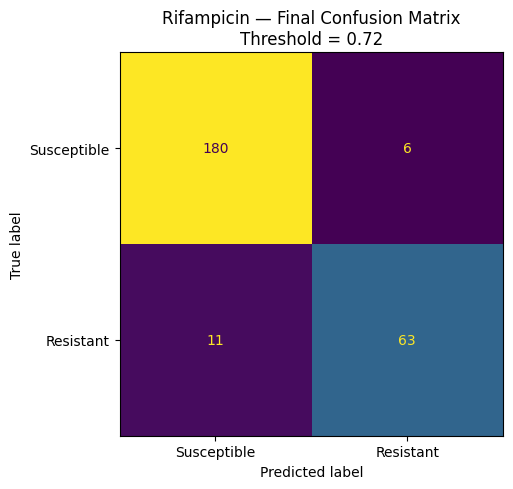


Isoniazid
Model: LogisticRegression
Threshold: 0.5

Confusion Matrix:
[[158   6]
 [ 29  67]]


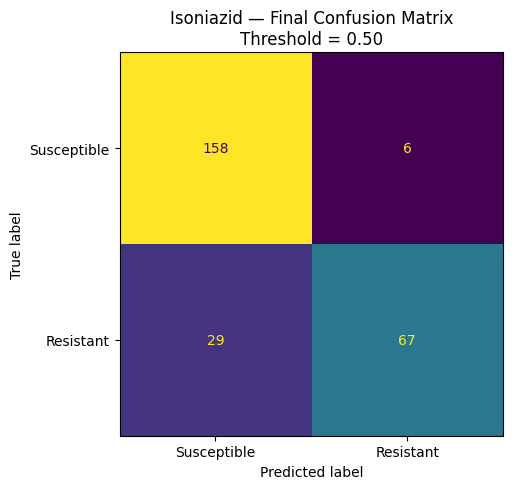


Ethambutol
Model: RandomForestClassifier
Threshold: 0.32

Confusion Matrix:
[[136  23]
 [ 16  38]]


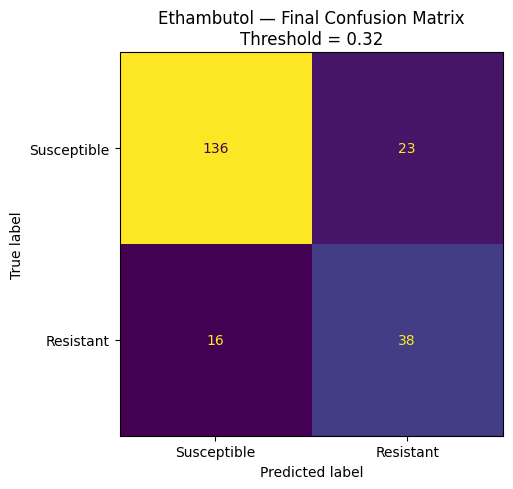

In [199]:
# ============================================================
# STEP 72 — FINAL CONFUSION MATRICES
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 80)
print("FINAL CONFUSION MATRICES")
print("=" * 80)

for drug, model in selected_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    # Match feature order
    if hasattr(model, "feature_names_in_"):
        X_test_model = X_test.loc[:, model.feature_names_in_]
    else:
        X_test_model = X_test

    # Predicted probability
    y_prob = model.predict_proba(X_test_model)[:, 1]

    # Selected threshold
    threshold = final_thresholds[drug]

    # Final class prediction
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{drug}")
    print(f"Model: {type(model).__name__}")
    print(f"Threshold: {threshold}")
    print("\nConfusion Matrix:")
    print(cm)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Susceptible", "Resistant"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"{drug} — Final Confusion Matrix\n"
        f"Threshold = {threshold:.2f}"
    )

    plt.tight_layout()
    plt.show()

In [200]:
# ============================================================
# STEP 73 — PERMUTATION FEATURE IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

permutation_results = {}

print("=" * 90)
print("PERMUTATION FEATURE IMPORTANCE — FINAL MODELS")
print("=" * 90)

for drug, model in selected_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    # Match feature order
    if hasattr(model, "feature_names_in_"):
        X_test_model = X_test.loc[:, model.feature_names_in_]
    else:
        X_test_model = X_test

    # Permutation importance using ROC-AUC
    result = permutation_importance(
        model,
        X_test_model,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Feature": X_test_model.columns,
        "Importance Mean": result.importances_mean,
        "Importance SD": result.importances_std
    })

    importance_df = importance_df.sort_values(
        "Importance Mean",
        ascending=False
    ).reset_index(drop=True)

    permutation_results[drug] = importance_df

    print("\n" + "-" * 80)
    print(drug)
    print("-" * 80)

    display(
        importance_df.head(15).round(4)
    )

PERMUTATION FEATURE IMPORTANCE — FINAL MODELS

--------------------------------------------------------------------------------
Rifampicin
--------------------------------------------------------------------------------


,Feature,Importance Mean,Importance SD
0,rpoB_S450L,0.3989,0.0301
1,rpoB_H445D,0.0191,0.0043
2,rpoB_D435Y,0.0094,0.0042
3,rpoB_D435V,0.0070,0.0061
4,rpoB_V170F,0.0067,0.0022
5,rpoB_H445R,0.0063,0.0028
6,rpoB_S450F,0.0060,0.0017
7,rpoB_H445P,0.0002,0.0014
8,rpoB_Q436P,0.0002,0.0000
9,rpoB_L430P,0.0002,0.0001



--------------------------------------------------------------------------------
Isoniazid
--------------------------------------------------------------------------------


,Feature,Importance Mean,Importance SD
0,katG_S315T,0.3280,0.0249
1,katG_S315N,0.0089,0.0024



--------------------------------------------------------------------------------
Ethambutol
--------------------------------------------------------------------------------


,Feature,Importance Mean,Importance SD
0,embB_M306V,0.1381,0.0181
1,embB_M306I,0.0759,0.0114
2,embB_Q497R,0.0565,0.0123
3,embB_D354A,0.0271,0.0108
4,embB_G406S,0.0187,0.0068
5,embB_G406D,0.0137,0.0055
6,embB_G406A,0.0082,0.0060
7,embB_Y319S,-0.0001,0.0052


In [201]:
# ============================================================
# STEP 74 — ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

error_analysis = {}

print("=" * 100)
print("FINAL TEST-SET ERROR ANALYSIS")
print("=" * 100)

for drug, model in selected_models.items():

    X_test = datasets_split[drug]["X_test"]
    y_test = datasets_split[drug]["y_test"]

    # Match feature order
    if hasattr(model, "feature_names_in_"):
        X_test_model = X_test.loc[:, model.feature_names_in_]
    else:
        X_test_model = X_test

    # Predicted probabilities
    y_prob = model.predict_proba(X_test_model)[:, 1]

    # Use the already selected threshold
    threshold = final_thresholds[drug]

    y_pred = (y_prob >= threshold).astype(int)

    # --------------------------------------------------------
    # Identify errors
    # --------------------------------------------------------

    false_negative_mask = (
        (y_test == 1) & (y_pred == 0)
    )

    false_positive_mask = (
        (y_test == 0) & (y_pred == 1)
    )

    fn_data = X_test_model.loc[false_negative_mask].copy()
    fp_data = X_test_model.loc[false_positive_mask].copy()

    fn_data["True_Label"] = 1
    fn_data["Predicted_Label"] = 0
    fn_data["Predicted_Probability"] = y_prob[false_negative_mask]

    fp_data["True_Label"] = 0
    fp_data["Predicted_Label"] = 1
    fp_data["Predicted_Probability"] = y_prob[false_positive_mask]

    error_analysis[drug] = {
        "False_Negatives": fn_data,
        "False_Positives": fp_data
    }

    print("\n" + "=" * 90)
    print(f"{drug}")
    print("=" * 90)

    print(f"Total test samples : {len(y_test)}")
    print(f"False Negatives    : {false_negative_mask.sum()}")
    print(f"False Positives    : {false_positive_mask.sum()}")

    # --------------------------------------------------------
    # Show false negatives
    # --------------------------------------------------------

    print("\n--- FALSE NEGATIVES ---")
    print("True resistant → predicted susceptible")

    if len(fn_data) > 0:
        display(
            fn_data.round(4)
        )
    else:
        print("No false negatives.")

    # --------------------------------------------------------
    # Show false positives
    # --------------------------------------------------------

    print("\n--- FALSE POSITIVES ---")
    print("True susceptible → predicted resistant")

    if len(fp_data) > 0:
        display(
            fp_data.round(4)
        )
    else:
        print("No false positives.")

FINAL TEST-SET ERROR ANALYSIS

Rifampicin
Total test samples : 260
False Negatives    : 11
False Positives    : 6

--- FALSE NEGATIVES ---
True resistant → predicted susceptible


,rpoB_S450L,rpoB_H445D,rpoB_D435V,rpoB_D435Y,rpoB_H445Y,rpoB_H445L,rpoB_H445R,rpoB_V170F,rpoB_L452P,rpoB_D435A,...,rpoB_L449M,rpoB_Q432E,rpoB_A451G,rpoB_Q436P,rpoB_T427G,rpoB_K446Q,rpoB_R448L,True_Label,Predicted_Label,Predicted_Probability
247,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0.6243
767,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.3774
876,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.1129
3597,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.1129
2238,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0.6000
2230,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.1129
2458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.1129
1797,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.1129
2637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.1129
4374,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0.6453



--- FALSE POSITIVES ---
True susceptible → predicted resistant


,rpoB_S450L,rpoB_H445D,rpoB_D435V,rpoB_D435Y,rpoB_H445Y,rpoB_H445L,rpoB_H445R,rpoB_V170F,rpoB_L452P,rpoB_D435A,...,rpoB_L449M,rpoB_Q432E,rpoB_A451G,rpoB_Q436P,rpoB_T427G,rpoB_K446Q,rpoB_R448L,True_Label,Predicted_Label,Predicted_Probability
1413,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.9739
167,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1.0000
3809,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.9739
3264,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.9739
2131,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.9739
311,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.9739



Isoniazid
Total test samples : 260
False Negatives    : 29
False Positives    : 6

--- FALSE NEGATIVES ---
True resistant → predicted susceptible


...

,katG_S315T,katG_S315N,True_Label,Predicted_Label,Predicted_Probability
3898,1,0,0,1,0.9503
2654,1,0,0,1,0.9503
120,1,0,0,1,0.9503
4597,1,0,0,1,0.9503
5,1,0,0,1,0.9503
2811,1,0,0,1,0.9503



Ethambutol
Total test samples : 213
False Negatives    : 16
False Positives    : 23

--- FALSE NEGATIVES ---
True resistant → predicted susceptible


,embB_M306V,embB_M306I,embB_Q497R,embB_G406S,embB_D354A,embB_G406A,embB_Y319S,embB_G406D,True_Label,Predicted_Label,Predicted_Probability
284,0,0,0,0,0,0,0,0,1,0,0.3022
4680,0,0,0,0,0,0,0,0,1,0,0.3022
2691,0,0,0,0,0,0,0,0,1,0,0.3022
3322,0,0,0,0,0,0,0,0,1,0,0.3022
1897,0,0,0,0,0,0,0,0,1,0,0.3022
2646,0,0,0,0,0,0,0,0,1,0,0.3022
1588,0,0,0,0,0,0,0,0,1,0,0.3022
2117,0,0,0,0,0,0,0,0,1,0,0.3022
4319,0,0,0,0,0,0,0,0,1,0,0.3022
3985,0,0,0,0,0,0,0,0,1,0,0.3022



--- FALSE POSITIVES ---
True susceptible → predicted resistant


,embB_M306V,embB_M306I,embB_Q497R,embB_G406S,embB_D354A,embB_G406A,embB_Y319S,embB_G406D,True_Label,Predicted_Label,Predicted_Probability
2054,0,1,0,0,0,0,0,0,0,1,0.7513
4299,0,0,1,0,0,0,0,0,0,1,0.8074
2399,0,0,0,0,1,0,0,0,0,1,0.4926
3876,1,0,0,0,0,0,0,0,0,1,0.8765
1423,0,0,0,0,1,0,0,0,0,1,0.4926
4226,1,0,0,0,0,0,0,0,0,1,0.8765
279,0,1,0,0,0,0,0,0,0,1,0.7513
1496,0,0,0,0,0,1,1,0,0,1,0.6115
2218,1,0,0,0,0,0,0,0,0,1,0.8765
3793,1,0,0,0,0,0,0,0,0,1,0.8765


In [202]:
# ============================================================
# STEP 75 — QUANTIFY MUTATION PATTERNS IN MODEL ERRORS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("MUTATION PATTERNS IN FALSE NEGATIVES AND FALSE POSITIVES")
print("=" * 100)

error_pattern_results = {}

for drug in selected_models.keys():

    fn_data = error_analysis[drug]["False_Negatives"].copy()
    fp_data = error_analysis[drug]["False_Positives"].copy()

    # Identify genomic feature columns
    feature_cols = [
        col for col in fn_data.columns
        if col not in [
            "True_Label",
            "Predicted_Label",
            "Predicted_Probability"
        ]
    ]

    print("\n" + "=" * 90)
    print(drug)
    print("=" * 90)

    # --------------------------------------------------------
    # FALSE NEGATIVES
    # --------------------------------------------------------

    if len(fn_data) > 0:

        fn_frequency = (
            fn_data[feature_cols]
            .mean()
            .sort_values(ascending=False)
        )

        fn_frequency = fn_frequency[
            fn_frequency > 0
        ]

        print("\n--- Mutations present among FALSE NEGATIVES ---")

        if len(fn_frequency) > 0:
            display(
                (fn_frequency * 100)
                .round(2)
                .rename("Percentage_of_FN")
                .to_frame()
            )
        else:
            print("No selected mutations present in false negatives.")

    # --------------------------------------------------------
    # FALSE POSITIVES
    # --------------------------------------------------------

    if len(fp_data) > 0:

        fp_frequency = (
            fp_data[feature_cols]
            .mean()
            .sort_values(ascending=False)
        )

        fp_frequency = fp_frequency[
            fp_frequency > 0
        ]

        print("\n--- Mutations present among FALSE POSITIVES ---")

        if len(fp_frequency) > 0:
            display(
                (fp_frequency * 100)
                .round(2)
                .rename("Percentage_of_FP")
                .to_frame()
            )
        else:
            print("No selected mutations present in false positives.")

    # --------------------------------------------------------
    # HOW MANY ERROR CASES HAVE ZERO SELECTED MUTATIONS?
    # --------------------------------------------------------

    if len(fn_data) > 0:
        fn_zero = (fn_data[feature_cols].sum(axis=1) == 0).sum()
        print(
            f"\nFalse negatives with ZERO selected mutations: "
            f"{fn_zero}/{len(fn_data)} "
            f"({fn_zero / len(fn_data) * 100:.1f}%)"
        )

    if len(fp_data) > 0:
        fp_zero = (fp_data[feature_cols].sum(axis=1) == 0).sum()
        print(
            f"False positives with ZERO selected mutations: "
            f"{fp_zero}/{len(fp_data)} "
            f"({fp_zero / len(fp_data) * 100:.1f}%)"
        )

print("\n" + "=" * 100)
print("STEP 75 COMPLETE")
print("=" * 100)

MUTATION PATTERNS IN FALSE NEGATIVES AND FALSE POSITIVES

Rifampicin

--- Mutations present among FALSE NEGATIVES ---


,Percentage_of_FN
rpoB_H445R,18.18
rpoB_V170F,9.09
rpoB_S450F,9.09
rpoB_Q432L,9.09
rpoB_Q436P,9.09



--- Mutations present among FALSE POSITIVES ---


,Percentage_of_FP
rpoB_S450L,83.33
rpoB_D435V,16.67



False negatives with ZERO selected mutations: 6/11 (54.5%)
False positives with ZERO selected mutations: 0/6 (0.0%)

Isoniazid

--- Mutations present among FALSE NEGATIVES ---
No selected mutations present in false negatives.

--- Mutations present among FALSE POSITIVES ---


,Percentage_of_FP
katG_S315T,100.0



False negatives with ZERO selected mutations: 29/29 (100.0%)
False positives with ZERO selected mutations: 0/6 (0.0%)

Ethambutol

--- Mutations present among FALSE NEGATIVES ---
No selected mutations present in false negatives.

--- Mutations present among FALSE POSITIVES ---


,Percentage_of_FP
embB_M306V,26.09
embB_M306I,21.74
embB_D354A,21.74
embB_G406A,17.39
embB_Y319S,17.39
embB_Q497R,4.35
embB_G406S,4.35
embB_G406D,4.35



False negatives with ZERO selected mutations: 16/16 (100.0%)
False positives with ZERO selected mutations: 0/23 (0.0%)

STEP 75 COMPLETE


In [204]:

print("selected_models exists:", "selected_models" in globals())

if "selected_models" in globals():
    print("Model keys:", list(selected_models.keys()))

    for drug, model in selected_models.items():
        print(drug, "->", type(model).__name__)



selected_models exists: True
Model keys: ['Rifampicin', 'Isoniazid', 'Ethambutol']
Rifampicin -> RandomForestClassifier
Isoniazid -> LogisticRegression
Ethambutol -> RandomForestClassifier


In [205]:

# Diagnostic only: this does not modify your models or results.

print("Checking existing results variables...\n")

for name, obj in list(globals().items()):
    if any(term in name.lower() for term in [
        "threshold", "result", "summary", "metric", "performance"
    ]):
        if isinstance(obj, pd.DataFrame):
            print(f"\nVariable: {name}")
            print("Shape:", obj.shape)
            print("Columns:", obj.columns.tolist())

print("\nChecking selected models...")
for drug, model in selected_models.items():
    print(f"{drug}: {type(model).__name__}")


Checking existing results variables...


Variable: drug_summary
Shape: (22, 6)
Columns: ['Antibiotic', 'records', 'unique_genomes', 'resistant', 'susceptible', 'resistant_percent']

Variable: conflict_summary
Shape: (6, 2)
Columns: ['Antibiotic', 'conflicting_genome_drug_pairs']

Variable: baseline_results
Shape: (3, 4)
Columns: ['Drug', 'Baseline_Accuracy', 'Baseline_F1', 'Baseline_ROC_AUC']

Variable: feature_summary
Shape: (121, 4)
Columns: ['feature', 'present', 'absent', 'missing']

Variable: rif_results
Shape: (92, 11)
Columns: ['drug', 'feature', 'genomes_evaluated', 'mutation_present', 'mutation_absent', 'resistant_with_mutation', 'susceptible_with_mutation', 'resistant_without_mutation', 'susceptible_without_mutation', 'odds_ratio', 'p_value']

Variable: inh_results
Shape: (4, 11)
Columns: ['drug', 'feature', 'genomes_evaluated', 'mutation_present', 'mutation_absent', 'resistant_with_mutation', 'susceptible_with_mutation', 'resistant_without_mutation', 'susceptible_without_mut

In [206]:

print("Columns:")
print(final_threshold_test_df.columns.tolist())

print("\nFinal threshold test results:")
display(final_threshold_test_df)

print("\nSelected models:")
for drug, model in selected_models.items():
    print(f"{drug}: {type(model).__name__}")


Columns:
['Drug', 'Model', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'TN', 'FP', 'FN', 'TP']

Final threshold test results:


,Drug,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,Rifampicin,Random Forest,0.72,0.934615,0.913043,0.851351,0.881119,0.925930,180,6,11,63
1,Isoniazid,Logistic Regression,0.50,0.865385,0.917808,0.697917,0.792899,0.830856,158,6,29,67
2,Ethambutol,Random Forest,0.32,0.816901,0.622951,0.703704,0.660870,0.792162,136,23,16,38



Selected models:
Rifampicin: RandomForestClassifier
Isoniazid: LogisticRegression
Ethambutol: RandomForestClassifier


In [208]:
# ============================================================
# STEP 76 — FINAL MODEL PERFORMANCE SUMMARY        # upper code change this
# ============================================================

final_summary = final_threshold_test_df.copy()

# Keep only the final selected model for each drug
final_summary = final_summary[
    ["Drug", "Model", "Threshold",
     "Accuracy", "Precision", "Recall", "F1", "ROC-AUC",
     "TN", "FP", "FN", "TP"]
].copy()

# Convert metrics to percentages for easier interpretation
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    final_summary[col + " (%)"] = (
        final_summary[col] * 100
    ).round(2)

print("=" * 100)
print("FINAL SELECTED MODEL PERFORMANCE")
print("=" * 100)

display(
    final_summary[
        ["Drug", "Model", "Threshold",
         "Accuracy (%)",
         "Precision (%)",
         "Recall (%)",
         "F1 (%)",
         "ROC-AUC (%)",
         "TN", "FP", "FN", "TP"]
    ]
)

FINAL SELECTED MODEL PERFORMANCE


,Drug,Model,Threshold,Accuracy (%),Precision (%),Recall (%),F1 (%),ROC-AUC (%),TN,FP,FN,TP
0,Rifampicin,Random Forest,0.72,93.46,91.30,85.14,88.11,92.59,180,6,11,63
1,Isoniazid,Logistic Regression,0.50,86.54,91.78,69.79,79.29,83.09,158,6,29,67
2,Ethambutol,Random Forest,0.32,81.69,62.30,70.37,66.09,79.22,136,23,16,38


In [203]:
# ============================================================
# STEP 76 — FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

final_summary = tuned_threshold_results_df.copy()

# Keep only the final selected model for each drug
final_summary = final_summary[
    ["Drug", "Model", "Threshold",
     "Accuracy", "Precision", "Recall", "F1", "ROC-AUC",
     "TN", "FP", "FN", "TP"]
].copy()

# Convert metrics to percentages for easier interpretation
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    final_summary[col + " (%)"] = (
        final_summary[col] * 100
    ).round(2)

print("=" * 100)
print("FINAL SELECTED MODEL PERFORMANCE")
print("=" * 100)

display(
    final_summary[
        ["Drug", "Model", "Threshold",
         "Accuracy (%)",
         "Precision (%)",
         "Recall (%)",
         "F1 (%)",
         "ROC-AUC (%)",
         "TN", "FP", "FN", "TP"]
    ]
)

NameError: name 'tuned_threshold_results_df' is not defined

In [ ]:
# ============================================================
# STEP 76 — FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

# Use the results table that actually exists
final_summary = tuned_test_results_df.copy()

# Select the final model for each drug
selected_models = {
    "Rifampicin": "Random Forest",
    "Isoniazid": "Logistic Regression",
    "Ethambutol": "Random Forest"
}

final_summary = final_summary[
    final_summary.apply(
        lambda row: selected_models.get(row["Drug"]) == row["Model"],
        axis=1
    )
].copy()

# Add final thresholds
final_thresholds = {
    "Rifampicin": 0.72,
    "Isoniazid": 0.50,
    "Ethambutol": 0.32
}

final_summary["Threshold"] = final_summary["Drug"].map(final_thresholds)

# Convert metrics to percentages
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    final_summary[col + " (%)"] = (
        final_summary[col] * 100
    ).round(2)

# Arrange columns
final_summary = final_summary[
    [
        "Drug",
        "Model",
        "Threshold",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 (%)",
        "ROC-AUC (%)",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

print("=" * 100)
print("FINAL SELECTED MODEL PERFORMANCE")
print("=" * 100)

display(final_summary)

In [209]:
# ============================================================
# STEP 77 — CHECK AVAILABLE EXTERNAL VALIDATION DATA
# ============================================================

import os
import glob

print("=" * 80)
print("EXTERNAL VALIDATION DATA CHECK")
print("=" * 80)

# Look for common data files in Colab
files = []

for pattern in [
    "/content/*.csv",
    "/content/*.tsv",
    "/content/*.xlsx",
    "/content/*.xls",
    "/content/*.txt"
]:
    files.extend(glob.glob(pattern))

# Remove duplicates
files = sorted(set(files))

print("\nFiles found in /content:\n")

for f in files:
    print(os.path.basename(f))

print("\nTotal files found:", len(files))

EXTERNAL VALIDATION DATA CHECK

Files found in /content:

BV_BRC_ethambutol_training.csv
BV_BRC_ethambutol_training_clean.csv
BV_BRC_isoniazid_training.csv
BV_BRC_isoniazid_training_clean.csv
BV_BRC_rifampin_training.csv
BV_BRC_rifampin_training_clean.csv
BV_BRC_training_combined.csv
BV_BRC_training_combined_clean.csv
bvbrc_mutation_features.csv

Total files found: 9


In [210]:
import os

# Check common locations
locations = [
    "/content",
    "/content/drive/MyDrive"
]

for location in locations:
    print("\n" + "="*70)
    print("LOCATION:", location)
    print("="*70)

    if os.path.exists(location):
        for item in os.listdir(location):
            if "seq" in item.lower() or "re" in item.lower():
                print(item)


LOCATION: /content
bvbrc_sequences
bvbrc_mutation_features.csv
bvbrc_features

LOCATION: /content/drive/MyDrive
Event Registration.gform


In [211]:
path3 = "/content/drive/MyDrive/TB_AMR_ML_Project/data/reseq_clean.csv"
reseq_clean= pd.read_csv(path3)

In [212]:
# ============================================================
# STEP 77A — INSPECT CLEAN CRyPTIC EXTERNAL DATASET
# ============================================================

print("=" * 80)
print("CRyPTIC EXTERNAL VALIDATION DATASET")
print("=" * 80)

print("\nShape:")
print(reseq_clean.shape)

print("\nColumns:")
print(reseq_clean.columns.tolist())

print("\nFirst 5 rows:")
display(reseq_clean.head())

print("\nData types:")
display(reseq_clean.dtypes)

print("\nMissing values:")
display(
    reseq_clean.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)

CRyPTIC EXTERNAL VALIDATION DATASET

Shape:
(31683, 19)

Columns:
['STUDYID', 'USUBJID', 'SPDEVID', 'MSSEQ', 'MSREFID', 'MSTESTCD', 'MSTEST', 'MSDRUG', 'MSCRICON', 'MSCONC', 'MSCONCU', 'MSCAT', 'MSORRES', 'MSSTRESC', 'MSSPEC', 'MSMETHOD', 'MSDRVFL', 'YRCOLL', 'MEDIATYP']

First 5 rows:


,STUDYID,USUBJID,SPDEVID,MSSEQ,MSREFID,MSTESTCD,MSTEST,MSDRUG,MSCRICON,MSCONC,MSCONCU,MSCAT,MSORRES,MSSTRESC,MSSPEC,MSMETHOD,MSDRVFL,YRCOLL,MEDIATYP
0,IS-1017,GMTV000396,NaN,3,ERR228017,DST,Drug Susceptibility Testing,ETHAMBUTOL,NaN,NaN,NaN,PHENOTYPIC,S,SUSCEPTIBLE,ISOLATE,NaN,NaN,NaN,NaN
1,IS-1017,GMTV001205,NaN,6,SRR671815,DST,Drug Susceptibility Testing,OFLOXACIN,2.0,NaN,mg/L,PHENOTYPIC,R,RESISTANT,ISOLATE,AGAR PROPORTION,NaN,NaN,LOWENSTEIN-JENSEN
2,IS-1017,GMTV000224,BACTEC MGIT 960,8,ERR067735,DST,Drug Susceptibility Testing,PYRAZINAMIDE,100.0,NaN,mg/L,PHENOTYPIC,S,SUSCEPTIBLE,ISOLATE,"MICROBIAL CULTURE, LIQUID",NaN,NaN,NaN
3,IS-1017,GMTV000657,BACTEC MGIT 960,3,ERR144608,DST,Drug Susceptibility Testing,PYRAZINAMIDE,100.0,NaN,mg/L,PHENOTYPIC,R,RESISTANT,ISOLATE,"MICROBIAL CULTURE, LIQUID",NaN,NaN,NaN
4,IS-1017,GMTV001197,NaN,7,SRR671805,DST,Drug Susceptibility Testing,RIFAMPICIN,40.0,NaN,mg/L,PHENOTYPIC,S,SUSCEPTIBLE,ISOLATE,AGAR PROPORTION,NaN,NaN,LOWENSTEIN-JENSEN



Data types:


,0
STUDYID,object
USUBJID,object
SPDEVID,object
MSSEQ,int64
MSREFID,object
MSTESTCD,object
MSTEST,object
MSDRUG,object
MSCRICON,float64
MSCONC,object



Missing values:


,0
MSCONC,31243
MSDRVFL,31243
MEDIATYP,26943
SPDEVID,24333
YRCOLL,24119
MSCONCU,20581
MSCRICON,20581
MSMETHOD,19570
STUDYID,0
USUBJID,0


In [213]:
# ============================================================
# STEP 77B — CHECK YOUR CRyPTIC DATA DIRECTORY
# ============================================================

import os

data_path = "/content/drive/MyDrive/TB_AMR_ML_Project/data"

print("=" * 80)
print("CRyPTIC DATA DIRECTORY")
print("=" * 80)

for root, dirs, files in os.walk(data_path):
    for file in files:
        print(os.path.join(root, file))

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1163288.results.json
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1163294.results.json
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1163360.results.json
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1163462.results.json
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1165366.results.json
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1165369.results.json
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/tbprofiler/SRR1165427.results.json
/content/dr

In [214]:
# ============================================================
# STEP 77C — INSPECT MSF FILE
# ============================================================

msf_path = "/content/drive/MyDrive/TB_AMR_ML_Project/data/msf.csv"

msf = pd.read_csv(msf_path)

print("=" * 80)
print("MSF DATASET")
print("=" * 80)

print("\nShape:")
print(msf.shape)

print("\nColumns:")
print(msf.columns.tolist())

print("\nFirst 5 rows:")
display(msf.head())

print("\nData types:")
display(msf.dtypes)

print("\nMissing values:")
display(
    msf.isna().sum().sort_values(ascending=False).head(20)
)

MSF DATASET

Shape:
(36376, 19)

Columns:
['STUDYID', 'USUBJID', 'SPDEVID', 'MSSEQ', 'MSREFID', 'MSTESTCD', 'MSTEST', 'MSDRUG', 'MSCRICON', 'MSCONC', 'MSCONCU', 'MSCAT', 'MSORRES', 'MSSTRESC', 'MSSPEC', 'MSMETHOD', 'MSDRVFL', 'YRCOLL', 'MEDIATYP']

First 5 rows:


,STUDYID,USUBJID,SPDEVID,MSSEQ,MSREFID,MSTESTCD,MSTEST,MSDRUG,MSCRICON,MSCONC,MSCONCU,MSCAT,MSORRES,MSSTRESC,MSSPEC,MSMETHOD,MSDRVFL,YRCOLL,MEDIATYP
0,IS-1017,GMTV000396,NaN,3,ERR228017,DST,Drug Susceptibility Testing,ETHAMBUTOL,NaN,NaN,NaN,PHENOTYPIC,S,SUSCEPTIBLE,ISOLATE,NaN,NaN,NaN,NaN
1,IS-1017,GMTV001205,NaN,6,SRR671815,DST,Drug Susceptibility Testing,OFLOXACIN,2.0,NaN,mg/L,PHENOTYPIC,R,RESISTANT,ISOLATE,AGAR PROPORTION,NaN,NaN,LOWENSTEIN-JENSEN
2,IS-1017,GMTV000224,BACTEC MGIT 960,8,ERR067735,DST,Drug Susceptibility Testing,PYRAZINAMIDE,100.0,NaN,mg/L,PHENOTYPIC,S,SUSCEPTIBLE,ISOLATE,"MICROBIAL CULTURE, LIQUID",NaN,NaN,NaN
3,IS-1017,GMTV000657,BACTEC MGIT 960,3,ERR144608,DST,Drug Susceptibility Testing,PYRAZINAMIDE,100.0,NaN,mg/L,PHENOTYPIC,R,RESISTANT,ISOLATE,"MICROBIAL CULTURE, LIQUID",NaN,NaN,NaN
4,IS-1017,GMTV001197,NaN,7,SRR671805,DST,Drug Susceptibility Testing,RIFAMPICIN,40.0,NaN,mg/L,PHENOTYPIC,S,SUSCEPTIBLE,ISOLATE,AGAR PROPORTION,NaN,NaN,LOWENSTEIN-JENSEN



Data types:


,0
STUDYID,object
USUBJID,object
SPDEVID,object
MSSEQ,int64
MSREFID,object
MSTESTCD,object
MSTEST,object
MSDRUG,object
MSCRICON,float64
MSCONC,object



Missing values:


,0
MSCONC,34726
MSDRVFL,34726
MEDIATYP,30172
SPDEVID,25797
YRCOLL,25629
MSCONCU,21264
MSCRICON,21264
MSMETHOD,19570
STUDYID,0
USUBJID,0


In [215]:
# ============================================================
# STEP 77D — CHECK ORIGINAL CRyPTIC TABLE
# ============================================================

cryptic_path = "/content/drive/MyDrive/TB_AMR_ML_Project/data/CRyPTIC_reuse_table_20221019.csv"

cryptic = pd.read_csv(cryptic_path)

print("Shape:", cryptic.shape)

print("\nALL COLUMNS:")
for i, col in enumerate(cryptic.columns):
    print(i, ":", col)

print("\nFirst row:")
display(cryptic.head(1).T)

Shape: (12288, 42)

ALL COLUMNS:
0 : UNIQUEID
1 : AMI_BINARY_PHENOTYPE
2 : BDQ_BINARY_PHENOTYPE
3 : CFZ_BINARY_PHENOTYPE
4 : DLM_BINARY_PHENOTYPE
5 : EMB_BINARY_PHENOTYPE
6 : ETH_BINARY_PHENOTYPE
7 : INH_BINARY_PHENOTYPE
8 : KAN_BINARY_PHENOTYPE
9 : LEV_BINARY_PHENOTYPE
10 : LZD_BINARY_PHENOTYPE
11 : MXF_BINARY_PHENOTYPE
12 : RIF_BINARY_PHENOTYPE
13 : RFB_BINARY_PHENOTYPE
14 : AMI_MIC
15 : BDQ_MIC
16 : CFZ_MIC
17 : DLM_MIC
18 : EMB_MIC
19 : ETH_MIC
20 : INH_MIC
21 : KAN_MIC
22 : LEV_MIC
23 : LZD_MIC
24 : MXF_MIC
25 : RIF_MIC
26 : RFB_MIC
27 : AMI_PHENOTYPE_QUALITY
28 : BDQ_PHENOTYPE_QUALITY
29 : CFZ_PHENOTYPE_QUALITY
30 : EMB_PHENOTYPE_QUALITY
31 : ETH_PHENOTYPE_QUALITY
32 : INH_PHENOTYPE_QUALITY
33 : KAN_PHENOTYPE_QUALITY
34 : LEV_PHENOTYPE_QUALITY
35 : LZD_PHENOTYPE_QUALITY
36 : MXF_PHENOTYPE_QUALITY
37 : RIF_PHENOTYPE_QUALITY
38 : RFB_PHENOTYPE_QUALITY
39 : ENA_SAMPLE
40 : VCF
41 : REGENOTYPED_VCF

First row:


,0
UNIQUEID,site.02.subj.0001.lab.2014222001.iso.1
AMI_BINARY_PHENOTYPE,S
BDQ_BINARY_PHENOTYPE,NaN
CFZ_BINARY_PHENOTYPE,S
DLM_BINARY_PHENOTYPE,S
EMB_BINARY_PHENOTYPE,S
ETH_BINARY_PHENOTYPE,S
INH_BINARY_PHENOTYPE,S
KAN_BINARY_PHENOTYPE,S
LEV_BINARY_PHENOTYPE,S


In [216]:
# ============================================================
# STEP 77E — INSPECT CRyPTIC VCF REFERENCES
# ============================================================

print("=" * 80)
print("CRyPTIC GENOMIC / VCF REFERENCES")
print("=" * 80)

print("\nNumber of samples:")
print(len(cryptic))

print("\nUnique ENA samples:")
print(cryptic["ENA_SAMPLE"].nunique())

print("\nMissing ENA_SAMPLE:")
print(cryptic["ENA_SAMPLE"].isna().sum())

print("\nMissing VCF:")
print(cryptic["VCF"].isna().sum())

print("\nMissing REGENOTYPED_VCF:")
print(cryptic["REGENOTYPED_VCF"].isna().sum())

print("\nExample VCF paths:")
display(
    cryptic[
        ["UNIQUEID", "ENA_SAMPLE", "VCF", "REGENOTYPED_VCF"]
    ].head(10)
)
# Check the external phenotype counts
for drug in ["RIF", "INH", "EMB"]:

    col = f"{drug}_BINARY_PHENOTYPE"

    print("\n" + "=" * 60)
    print(drug)
    print("=" * 60)

    print(cryptic[col].value_counts(dropna=False))

CRyPTIC GENOMIC / VCF REFERENCES

Number of samples:
12288

Unique ENA samples:
12288

Missing ENA_SAMPLE:
0

Missing VCF:
0

Missing REGENOTYPED_VCF:
0

Example VCF paths:


,UNIQUEID,ENA_SAMPLE,VCF,REGENOTYPED_VCF
0,site.02.subj.0001.lab.2014222001.iso.1,ERS5298516,00/01/08/61/10861/site.02.iso.1.subject.0001.l...,00/01/08/61/10861/site.02.iso.1.subject.0001.l...
1,site.02.subj.0002.lab.2014222005.iso.1,ERS5298518,00/01/08/63/10863/site.02.iso.1.subject.0002.l...,00/01/08/63/10863/site.02.iso.1.subject.0002.l...
2,site.02.subj.0004.lab.2014222010.iso.1,ERS5298520,00/01/08/67/10867/site.02.iso.1.subject.0004.l...,00/01/08/67/10867/site.02.iso.1.subject.0004.l...
3,site.02.subj.0005.lab.2014222011.iso.1,ERS5298521,00/01/08/68/10868/site.02.iso.1.subject.0005.l...,00/01/08/68/10868/site.02.iso.1.subject.0005.l...
4,site.02.subj.0006.lab.2014222013.iso.1,ERS5298522,00/01/08/69/10869/site.02.iso.1.subject.0006.l...,00/01/08/69/10869/site.02.iso.1.subject.0006.l...
5,site.02.subj.0007.lab.2014222016.iso.1,ERS5298524,00/01/08/71/10871/site.02.iso.1.subject.0007.l...,00/01/08/71/10871/site.02.iso.1.subject.0007.l...
6,site.02.subj.0008.lab.2014222017.iso.1,ERS5298525,00/01/08/72/10872/site.02.iso.1.subject.0008.l...,00/01/08/72/10872/site.02.iso.1.subject.0008.l...
7,site.02.subj.0009.lab.2014222037.iso.1,ERS5298534,00/01/08/82/10882/site.02.iso.1.subject.0009.l...,00/01/08/82/10882/site.02.iso.1.subject.0009.l...
8,site.02.subj.0010.lab.2014222040.iso.1,ERS5298536,00/01/08/84/10884/site.02.iso.1.subject.0010.l...,00/01/08/84/10884/site.02.iso.1.subject.0010.l...
9,site.02.subj.0011.lab.2014222046.iso.1,ERS5298539,00/01/08/87/10887/site.02.iso.1.subject.0011.l...,00/01/08/87/10887/site.02.iso.1.subject.0011.l...



RIF
RIF_BINARY_PHENOTYPE
S      7414
R      4684
NaN     190
Name: count, dtype: int64

INH
INH_BINARY_PHENOTYPE
S      6161
R      5908
NaN     219
Name: count, dtype: int64

EMB
EMB_BINARY_PHENOTYPE
S      8337
R      2261
I      1559
NaN     131
Name: count, dtype: int64


In [217]:
# ============================================================
# STEP 77F — TEST CRyPTIC VCF ACCESS
# ============================================================

import requests

base_urls = [
    "https://ftp.ebi.ac.uk/pub/databases/cryptic/release_june2022/",
    "http://ftp.ebi.ac.uk/pub/databases/cryptic/release_june2022/"
]

sample = cryptic.iloc[0]

print("ENA SAMPLE:")
print(sample["ENA_SAMPLE"])

print("\nVCF PATH:")
print(sample["VCF"])

print("\nREGENOTYPED VCF PATH:")
print(sample["REGENOTYPED_VCF"])

for base in base_urls:
    url = base + str(sample["REGENOTYPED_VCF"])

    print("\nTesting:")
    print(url)

    try:
        r = requests.head(
            url,
            allow_redirects=True,
            timeout=20
        )

        print("Status code:", r.status_code)
        print("Final URL:", r.url)

    except Exception as e:
        print("ERROR:", e)

ENA SAMPLE:
ERS5298516

VCF PATH:
00/01/08/61/10861/site.02.iso.1.subject.0001.lab_id.2014222001.seq_reps.14222001.masked.vcf.gz

REGENOTYPED VCF PATH:
00/01/08/61/10861/site.02.iso.1.subject.0001.lab_id.2014222001.seq_reps.14222001.regeno.vcf.gz

Testing:
https://ftp.ebi.ac.uk/pub/databases/cryptic/release_june2022/00/01/08/61/10861/site.02.iso.1.subject.0001.lab_id.2014222001.seq_reps.14222001.regeno.vcf.gz
Status code: 404
Final URL: https://ftp.ebi.ac.uk/pub/databases/cryptic/release_june2022/00/01/08/61/10861/site.02.iso.1.subject.0001.lab_id.2014222001.seq_reps.14222001.regeno.vcf.gz

Testing:
http://ftp.ebi.ac.uk/pub/databases/cryptic/release_june2022/00/01/08/61/10861/site.02.iso.1.subject.0001.lab_id.2014222001.seq_reps.14222001.regeno.vcf.gz
Status code: 404
Final URL: http://ftp.ebi.ac.uk/pub/databases/cryptic/release_june2022/00/01/08/61/10861/site.02.iso.1.subject.0001.lab_id.2014222001.seq_reps.14222001.regeno.vcf.gz


In [218]:
# ============================================================
# STEP 77G — SEARCH FOR EXISTING GENOMIC / MUTATION FILES
# ============================================================

import os

data_path = "/content/drive/MyDrive/TB_AMR_ML_Project"

keywords = [
    "mutation",
    "variant",
    "vcf",
    "genomic",
    "genotype",
    "wgs",
    "cryptic"
]

print("=" * 80)
print("SEARCHING PROJECT FOR CRyPTIC GENOMIC FILES")
print("=" * 80)

for root, dirs, files in os.walk(data_path):

    for file in files:

        name = file.lower()

        if any(k in name for k in keywords):

            print(os.path.join(root, file))

SEARCHING PROJECT FOR CRyPTIC GENOMIC FILES
/content/drive/MyDrive/TB_AMR_ML_Project/data/CRyPTIC_reuse_table_20221019.csv
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992643.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992649.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992650.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992651.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992658.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992659.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/data/unseen/gnomonicus/validate-myco-amr-main/dat/outputs/mgit/ERR9992660.vcf
/content/drive/MyDrive/TB_AMR_ML_Project/dat

In [219]:
# ============================================================
# STEP 77H — FIND EXISTING CRyPTIC MUTATION FEATURES
# ============================================================

print("=" * 80)
print("SEARCHING CURRENT COLAB SESSION FOR MUTATION / CRYPTIC DATA")
print("=" * 80)

for name, obj in list(globals().items()):

    if name.startswith("_"):
        continue

    # rest of your code
    try:
        if isinstance(obj, pd.DataFrame):

            name_low = name.lower()
            cols_low = " ".join(map(str, obj.columns)).lower()

            if (
                "mutation" in name_low
                or "cryptic" in name_low
                or "feature" in name_low
                or "mutation" in cols_low
                or "rpoB".lower() in cols_low
                or "katG".lower() in cols_low
                or "embB".lower() in cols_low
            ):
                print("\nDataFrame:", name)
                print("Shape:", obj.shape)
                print("Columns:", obj.columns.tolist()[:30])

    except Exception:
        pass

SEARCHING CURRENT COLAB SESSION FOR MUTATION / CRYPTIC DATA

DataFrame: df
Shape: (1327, 10)
Columns: ['Genome ID', 'y', 'embB_M306V', 'embB_M306I', 'embB_Q497R', 'embB_G406A', 'embB_D354A', 'embB_Y319S', 'embB_G406S', 'embB_G406D']

DataFrame: features_df
Shape: (0, 0)
Columns: []

DataFrame: df_features
Shape: (2, 28)
Columns: ['feature_id', 'aa_sequence_md5', 'accession', 'annotation', 'genome_name', 'na_sequence_md5', 'pgfam_id', 'na_length', 'location', 'strand', 'start', 'end', 'plfam_id', 'feature_type', 'product', 'owner', 'genome_id', 'sequence_id', 'patric_id', 'public', 'aa_length', 'taxon_id', 'date_inserted', 'date_modified', 'property', 'go', 'segments', '_version_']

DataFrame: resistance_features
Shape: (27, 30)
Columns: ['product', 'owner', 'start', 'end', 'plfam_id', 'feature_type', 'aa_length', 'taxon_id', 'genome_id', 'patric_id', 'sequence_id', 'public', 'annotation', 'accession', 'genome_name', 'feature_id', 'aa_sequence_md5', 'na_length', 'location', 'strand', 'n

In [220]:
# Check that the final trained models are available

print("Available trained models:")
for key in best_models.keys():
    print(key)

Available trained models:
('Rifampicin', 'Logistic Regression')
('Rifampicin', 'Random Forest')
('Rifampicin', 'XGBoost')
('Isoniazid', 'Logistic Regression')
('Isoniazid', 'Random Forest')
('Isoniazid', 'XGBoost')
('Ethambutol', 'Logistic Regression')
('Ethambutol', 'Random Forest')
('Ethambutol', 'XGBoost')


In [221]:
import pandas as pd

unseen_path = "/content/drive/MyDrive/TB_AMR_ML_Project/data/Gnomonicus_UKMYC_unseen_dataset.csv"

unseen_data = pd.read_csv(unseen_path)

print("Unseen dataset shape:", unseen_data.shape)
print("\nDrugs:")
print(unseen_data["DRUG"].value_counts())
print("\nColumns:", len(unseen_data.columns))

Unseen dataset shape: (3000, 45)

Drugs:
DRUG
INH    1000
RIF    1000
EMB    1000
Name: count, dtype: int64

Columns: 45


addd nexter cell here also


RIF: 30 features matched
INH: 2 features matched
EMB: 8 features matched

FINAL EXTERNAL VALIDATION RESULTS
GNOMONICUS UKMYC — UNSEEN DATASET


,Drug,Model,Threshold,Accuracy (%),Precision (%),Recall (%),F1 (%),ROC-AUC (%),TN,FP,FN,TP
0,RIF,Random Forest,0.72,93.20,98.34,87.18,92.43,94.76,517,7,61,415
1,INH,Logistic Regression,0.50,87.90,97.02,78.20,86.60,87.91,488,12,109,391
2,EMB,Random Forest,0.32,85.40,70.06,86.11,77.26,87.10,606,106,40,248



CONFUSION MATRICES

RIF — Random Forest
TN = 517, FP = 7, FN = 61, TP = 415

INH — Logistic Regression
TN = 488, FP = 12, FN = 109, TP = 391

EMB — Random Forest
TN = 606, FP = 106, FN = 40, TP = 248


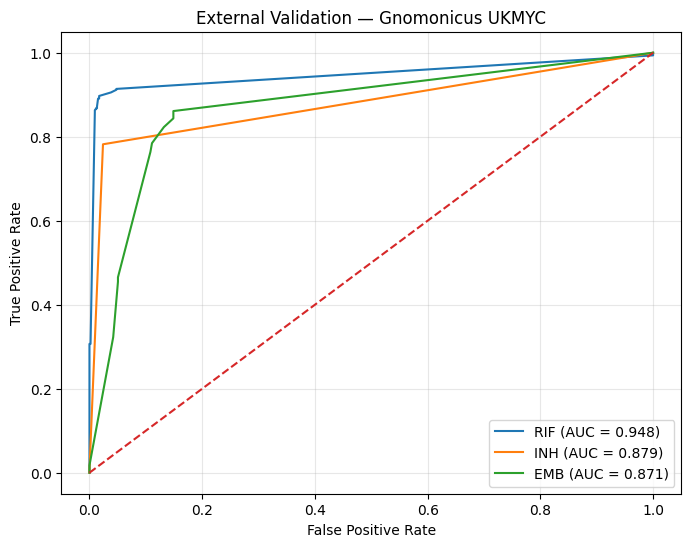

In [224]:
# ============================================================
# FINAL EXTERNAL VALIDATION — FIX FEATURE ORDER
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import pandas as pd
import matplotlib.pyplot as plt

final_model_names = {
    "RIF": "Random Forest",
    "INH": "Logistic Regression",
    "EMB": "Random Forest"
}

model_drug_names = {
    "RIF": "Rifampicin",
    "INH": "Isoniazid",
    "EMB": "Ethambutol"
}

final_thresholds = {
    "RIF": 0.72,
    "INH": 0.50,
    "EMB": 0.32
}

external_results = []
roc_data = {}

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    model_name = final_model_names[drug]
    model_key = (model_drug_names[drug], model_name)

    # Frozen trained model
    model = best_models[model_key]

    # --------------------------------------------------------
    # IMPORTANT:
    # Use EXACT feature order from model training
    # --------------------------------------------------------

    if hasattr(model, "feature_names_in_"):
        model_features = list(model.feature_names_in_)
    else:
        model_features = final_features[drug]

    X_ext = data[model_features]
    y_ext = data["y"].astype(int)

    print(f"{drug}: {len(model_features)} features matched")

    # Probability of resistance
    y_prob = model.predict_proba(X_ext)[:, 1]

    # Fixed threshold
    threshold = final_thresholds[drug]
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(y_ext, y_pred)
    precision = precision_score(y_ext, y_pred, zero_division=0)
    recall = recall_score(y_ext, y_pred, zero_division=0)
    f1 = f1_score(y_ext, y_pred, zero_division=0)
    auc = roc_auc_score(y_ext, y_prob)

    tn, fp, fn, tp = confusion_matrix(
        y_ext, y_pred
    ).ravel()

    external_results.append({
        "Drug": drug,
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 (%)": f1 * 100,
        "ROC-AUC (%)": auc * 100,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    fpr, tpr, _ = roc_curve(y_ext, y_prob)

    roc_data[drug] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }


# ============================================================
# FINAL RESULTS
# ============================================================

external_results_df = pd.DataFrame(external_results)

print("\n" + "=" * 85)
print("FINAL EXTERNAL VALIDATION RESULTS")
print("GNOMONICUS UKMYC — UNSEEN DATASET")
print("=" * 85)

display(
    external_results_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1 (%)": "{:.2f}",
        "ROC-AUC (%)": "{:.2f}"
    })
)


# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\nCONFUSION MATRICES")
print("=" * 50)

for _, row in external_results_df.iterrows():

    print(f"\n{row['Drug']} — {row['Model']}")

    print(
        f"TN = {int(row['TN'])}, "
        f"FP = {int(row['FP'])}, "
        f"FN = {int(row['FN'])}, "
        f"TP = {int(row['TP'])}"
    )


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for drug in ["RIF", "INH", "EMB"]:

    plt.plot(
        roc_data[drug]["fpr"],
        roc_data[drug]["tpr"],
        label=f"{drug} (AUC = {roc_data[drug]['auc']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation — Gnomonicus UKMYC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

FINAL EXTERNAL VALIDATION RESULTS
GNOMONICUS UKMYC — UNSEEN DATASET


,Drug,Model,Threshold,Accuracy (%),Precision (%),Recall (%),F1 (%),ROC-AUC (%),TN,FP,FN,TP
0,RIF,Random Forest,0.72,93.20,98.34,87.18,92.43,94.76,517,7,61,415
1,INH,Logistic Regression,0.50,87.90,97.02,78.20,86.60,87.91,488,12,109,391
2,EMB,Random Forest,0.32,85.40,70.06,86.11,77.26,87.10,606,106,40,248



CONFUSION MATRICES

RIF — Random Forest
TN = 517, FP = 7, FN = 61, TP = 415

INH — Logistic Regression
TN = 488, FP = 12, FN = 109, TP = 391

EMB — Random Forest
TN = 606, FP = 106, FN = 40, TP = 248


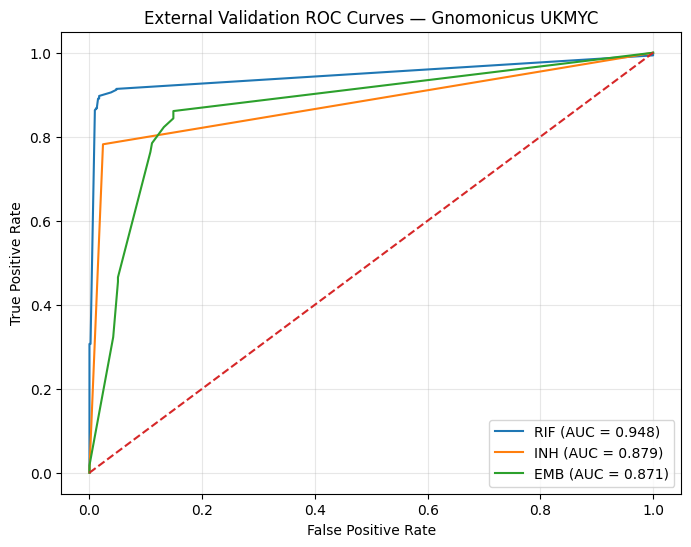

In [225]:
# ============================================================
# FINAL EXTERNAL VALIDATION — UNSEEN GNOMONICUS DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ------------------------------------------------------------
# Final selected models and fixed thresholds
# ------------------------------------------------------------

final_model_names = {
    "RIF": "Random Forest",
    "INH": "Logistic Regression",
    "EMB": "Random Forest"
}

final_thresholds = {
    "RIF": 0.72,
    "INH": 0.50,
    "EMB": 0.32
}

final_features = {
    "RIF": rif_features,
    "INH": inh_features,
    "EMB": emb_features
}

# ------------------------------------------------------------
# External validation
# ------------------------------------------------------------

external_results = []
roc_data = {}

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    features = final_features[drug]
    model_name = final_model_names[drug]
    threshold = final_thresholds[drug]

   # ==========================================
# EXTERNAL FEATURES AND TRUE LABELS
# ==========================================

    y_ext = data["y"].astype(int)

# Frozen trained model
    model = best_models[
    (model_drug_names[drug], model_name)
     ]

# IMPORTANT:
# Use the exact feature order stored during model fitting
    model_features = list(model.feature_names_in_)

# Check that all required features are present
    missing_features = [
         f for f in model_features
               if f not in data.columns
               ]

    if missing_features:
        raise ValueError(
        f"{drug}: Missing features: {missing_features}"
          )

# Arrange external data in EXACT training order
    X_ext = data[model_features].copy()

# Predicted probability
    y_prob = model.predict_proba(X_ext)[:, 1]
    # Fixed threshold — NOT optimized on external data
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(y_ext, y_pred)
    precision = precision_score(y_ext, y_pred, zero_division=0)
    recall = recall_score(y_ext, y_pred, zero_division=0)
    f1 = f1_score(y_ext, y_pred, zero_division=0)
    auc = roc_auc_score(y_ext, y_prob)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_ext, y_pred
    ).ravel()

    external_results.append({
        "Drug": drug,
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 (%)": f1 * 100,
        "ROC-AUC (%)": auc * 100,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    # ROC curve data
    fpr, tpr, _ = roc_curve(y_ext, y_prob)

    roc_data[drug] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

external_results_df = pd.DataFrame(external_results)

print("=" * 90)
print("FINAL EXTERNAL VALIDATION RESULTS")
print("GNOMONICUS UKMYC — UNSEEN DATASET")
print("=" * 90)

display(
    external_results_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1 (%)": "{:.2f}",
        "ROC-AUC (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

print("\nCONFUSION MATRICES")
print("=" * 50)

for _, row in external_results_df.iterrows():

    print(f"\n{row['Drug']} — {row['Model']}")
    print(
        f"TN = {int(row['TN'])}, "
        f"FP = {int(row['FP'])}, "
        f"FN = {int(row['FN'])}, "
        f"TP = {int(row['TP'])}"
    )

# ------------------------------------------------------------
# ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for drug in ["RIF", "INH", "EMB"]:

    plt.plot(
        roc_data[drug]["fpr"],
        roc_data[drug]["tpr"],
        label=f"{drug} (AUC = {roc_data[drug]['auc']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation ROC Curves — Gnomonicus UKMYC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [223]:
# ============================================================
# RESET FINAL FEATURE LISTS
# ============================================================

rif_features = [
    "rpoB_S450L", "rpoB_D435V", "rpoB_H445D", "rpoB_H445L",
    "rpoB_H445Y", "rpoB_D435Y", "rpoB_L452P", "rpoB_V170F",
    "rpoB_D435A", "rpoB_S441L", "rpoB_H445R", "rpoB_L430P",
    "rpoB_M434R", "rpoB_S450F", "rpoB_S431R", "rpoB_S428G",
    "rpoB_H445N", "rpoB_N437S", "rpoB_T427I", "rpoB_H445P",
    "rpoB_Q432E", "rpoB_L449M", "rpoB_S441V", "rpoB_L443S",
    "rpoB_A451G", "rpoB_T427G", "rpoB_K446Q", "rpoB_R448L",
    "rpoB_Q436P", "rpoB_Q432L"
]

inh_features = [
    "katG_S315T",
    "katG_S315N"
]

emb_features = [
    "embB_M306V",
    "embB_M306I",
    "embB_Q497R",
    "embB_G406S",
    "embB_G406A",
    "embB_D354A",
    "embB_Y319S",
    "embB_G406D"
]

final_features = {
    "RIF": rif_features,
    "INH": inh_features,
    "EMB": emb_features
}

print("RIF features:", len(rif_features))
print("INH features:", len(inh_features))
print("EMB features:", len(emb_features))
# Check that every required feature exists in unseen dataset

for drug, features in final_features.items():
    missing = [f for f in features if f not in unseen_data.columns]

    print(f"{drug}: missing features = {len(missing)}")

    if missing:
        print(missing)

RIF features: 30
INH features: 2
EMB features: 8
RIF: missing features = 0
INH: missing features = 0
EMB: missing features = 0


In [ ]:
print("best_models keys:")
print(list(best_models.keys()))

RIF: 30 features matched
INH: 2 features matched
EMB: 8 features matched

FINAL EXTERNAL VALIDATION RESULTS
GNOMONICUS UKMYC — UNSEEN DATASET


,Drug,Model,Threshold,Accuracy (%),Precision (%),Recall (%),F1 (%),ROC-AUC (%),TN,FP,FN,TP
0,RIF,Random Forest,0.72,93.20,98.34,87.18,92.43,94.76,517,7,61,415
1,INH,Logistic Regression,0.50,87.90,97.02,78.20,86.60,87.91,488,12,109,391
2,EMB,Random Forest,0.32,85.40,70.06,86.11,77.26,87.10,606,106,40,248



CONFUSION MATRICES

RIF — Random Forest
TN = 517, FP = 7, FN = 61, TP = 415

INH — Logistic Regression
TN = 488, FP = 12, FN = 109, TP = 391

EMB — Random Forest
TN = 606, FP = 106, FN = 40, TP = 248


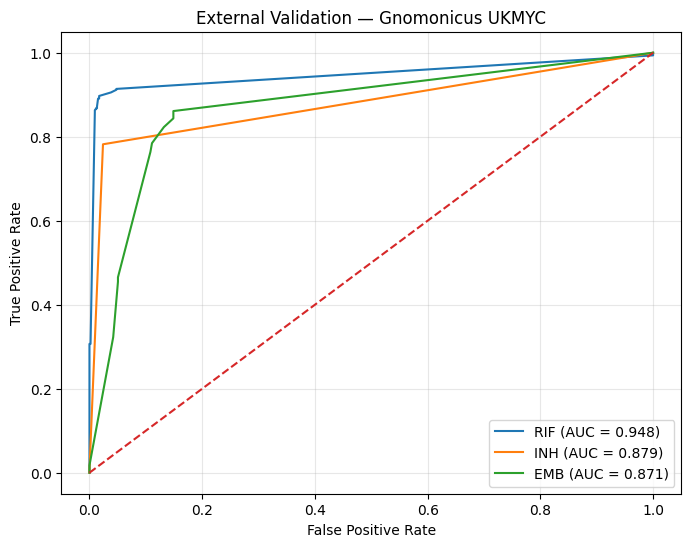

In [226]:
# ============================================================
# FINAL EXTERNAL VALIDATION — FIX FEATURE ORDER
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import pandas as pd
import matplotlib.pyplot as plt

final_model_names = {
    "RIF": "Random Forest",
    "INH": "Logistic Regression",
    "EMB": "Random Forest"
}

model_drug_names = {
    "RIF": "Rifampicin",
    "INH": "Isoniazid",
    "EMB": "Ethambutol"
}

final_thresholds = {
    "RIF": 0.72,
    "INH": 0.50,
    "EMB": 0.32
}

external_results = []
roc_data = {}

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    model_name = final_model_names[drug]
    model_key = (model_drug_names[drug], model_name)

    # Frozen trained model
    model = best_models[model_key]

    # --------------------------------------------------------
    # IMPORTANT:
    # Use EXACT feature order from model training
    # --------------------------------------------------------

    if hasattr(model, "feature_names_in_"):
        model_features = list(model.feature_names_in_)
    else:
        model_features = final_features[drug]

    X_ext = data[model_features]
    y_ext = data["y"].astype(int)

    print(f"{drug}: {len(model_features)} features matched")

    # Probability of resistance
    y_prob = model.predict_proba(X_ext)[:, 1]

    # Fixed threshold
    threshold = final_thresholds[drug]
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(y_ext, y_pred)
    precision = precision_score(y_ext, y_pred, zero_division=0)
    recall = recall_score(y_ext, y_pred, zero_division=0)
    f1 = f1_score(y_ext, y_pred, zero_division=0)
    auc = roc_auc_score(y_ext, y_prob)

    tn, fp, fn, tp = confusion_matrix(
        y_ext, y_pred
    ).ravel()

    external_results.append({
        "Drug": drug,
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 (%)": f1 * 100,
        "ROC-AUC (%)": auc * 100,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    fpr, tpr, _ = roc_curve(y_ext, y_prob)

    roc_data[drug] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }


# ============================================================
# FINAL RESULTS
# ============================================================

external_results_df = pd.DataFrame(external_results)

print("\n" + "=" * 85)
print("FINAL EXTERNAL VALIDATION RESULTS")
print("GNOMONICUS UKMYC — UNSEEN DATASET")
print("=" * 85)

display(
    external_results_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1 (%)": "{:.2f}",
        "ROC-AUC (%)": "{:.2f}"
    })
)


# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\nCONFUSION MATRICES")
print("=" * 50)

for _, row in external_results_df.iterrows():

    print(f"\n{row['Drug']} — {row['Model']}")

    print(
        f"TN = {int(row['TN'])}, "
        f"FP = {int(row['FP'])}, "
        f"FN = {int(row['FN'])}, "
        f"TP = {int(row['TP'])}"
    )


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for drug in ["RIF", "INH", "EMB"]:

    plt.plot(
        roc_data[drug]["fpr"],
        roc_data[drug]["tpr"],
        label=f"{drug} (AUC = {roc_data[drug]['auc']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation — Gnomonicus UKMYC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [227]:
# ============================================================
# SANITY CHECK — EXTERNAL PREDICTION DISTRIBUTION
# ============================================================

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[unseen_data["DRUG"] == drug].copy()

    model_key = (
        model_drug_names[drug],
        final_model_names[drug]
    )

    model = best_models[model_key]

    model_features = list(model.feature_names_in_)

    X_ext = data[model_features]

    y_prob = model.predict_proba(X_ext)[:, 1]

    print("\n", "=" * 60)
    print(drug)

    print("True resistant:", data["y"].sum())
    print("True susceptible:", (data["y"] == 0).sum())

    print("Mean predicted probability:", y_prob.mean())
    print("Minimum probability:", y_prob.min())
    print("Maximum probability:", y_prob.max())

    print("Predicted resistant at 0.50:",
          (y_prob >= 0.50).sum())

    print("Predicted susceptible at 0.50:",
          (y_prob < 0.50).sum())


RIF
True resistant: 476
True susceptible: 524
Mean predicted probability: 0.4949061092250295
Minimum probability: 0.11205952148193399
Maximum probability: 1.0
Predicted resistant at 0.50: 436
Predicted susceptible at 0.50: 564

INH
True resistant: 500
True susceptible: 500
Mean predicted probability: 0.5409738165514537
Minimum probability: 0.2644423587099603
Maximum probability: 0.9997349553298904
Predicted resistant at 0.50: 403
Predicted susceptible at 0.50: 597

EMB
True resistant: 288
True susceptible: 712
Mean predicted probability: 0.46780291645000877
Minimum probability: 0.3021813336200047
Maximum probability: 0.9146080416495281
Predicted resistant at 0.50: 331
Predicted susceptible at 0.50: 669


In [228]:
# ============================================================
# 95% BOOTSTRAP CI FOR EXTERNAL ROC-AUC
# ============================================================

import numpy as np
from sklearn.metrics import roc_auc_score

np.random.seed(42)

bootstrap_results = []

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    model_key = (
        model_drug_names[drug],
        final_model_names[drug]
    )

    model = best_models[model_key]

    model_features = list(model.feature_names_in_)

    X_ext = data[model_features]
    y_ext = data["y"].astype(int).to_numpy()

    y_prob = model.predict_proba(X_ext)[:, 1]

    # Original AUC
    original_auc = roc_auc_score(y_ext, y_prob)

    # Bootstrap
    boot_auc = []

    for _ in range(2000):

        indices = np.random.randint(
            0,
            len(y_ext),
            len(y_ext)
        )

        y_boot = y_ext[indices]
        prob_boot = y_prob[indices]

        # Both classes must be present
        if len(np.unique(y_boot)) < 2:
            continue

        boot_auc.append(
            roc_auc_score(y_boot, prob_boot)
        )

    # 95% percentile CI
    lower = np.percentile(boot_auc, 2.5)
    upper = np.percentile(boot_auc, 97.5)

    bootstrap_results.append({
        "Drug": drug,
        "ROC-AUC": original_auc,
        "95% CI Lower": lower,
        "95% CI Upper": upper
    })

bootstrap_df = pd.DataFrame(bootstrap_results)

display(
    bootstrap_df.style.format({
        "ROC-AUC": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

,Drug,ROC-AUC,95% CI Lower,95% CI Upper
0,RIF,0.9476,0.9316,0.9617
1,INH,0.8791,0.8593,0.8984
2,EMB,0.8710,0.8447,0.8960


In [229]:
# ============================================================
# EXTERNAL DATA OVERLAP CHECK
# ============================================================

# BV-BRC genome IDs used in the ML dataset
bvbrc_ids = set(
    mutation_df["Genome ID"].astype(str)
)

# Gnomonicus external sample IDs
external_ids = set(
    unseen_data["UNIQUEID"].astype(str)
)

overlap = bvbrc_ids.intersection(external_ids)

print("BV-BRC unique genomes:", len(bvbrc_ids))
print("External unique samples:", len(external_ids))
print("Exact ID overlap:", len(overlap))

if len(overlap) > 0:
    print("\nOverlapping IDs:")
    print(list(overlap)[:20])
else:
    print("\nNo exact identifier overlap found.")

BV-BRC unique genomes: 6708
External unique samples: 1000
Exact ID overlap: 0

No exact identifier overlap found.


In [230]:
# ============================================================
# EXTERNAL ERROR ANALYSIS
# ============================================================

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    # Get the frozen trained model
    model_key = (
        model_drug_names[drug],
        final_model_names[drug]
    )

    model = best_models[model_key]

    # Exact feature order used during model training
    model_features = list(model.feature_names_in_)

    # External features and true labels
    X_ext = data[model_features]
    y_true = data["y"].astype(int)

    # Predicted probabilities
    y_prob = model.predict_proba(X_ext)[:, 1]

    # Fixed threshold selected BEFORE external validation
    threshold = final_thresholds[drug]
    y_pred = (y_prob >= threshold).astype(int)

    # --------------------------------------------------------
    # Error categories
    # --------------------------------------------------------

    data["Predicted Probability"] = y_prob
    data["Prediction"] = y_pred

    data["Error Type"] = "Correct"

    data.loc[
        (data["y"] == 1) & (data["Prediction"] == 0),
        "Error Type"
    ] = "False Negative"

    data.loc[
        (data["y"] == 0) & (data["Prediction"] == 1),
        "Error Type"
    ] = "False Positive"

    # --------------------------------------------------------
    # Number of selected mutations in each sample
    # --------------------------------------------------------

    data["Selected Mutation Count"] = (
        data[model_features]
        .sum(axis=1)
    )

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print(drug)
    print("=" * 70)

    print("\nError categories:")
    print(data["Error Type"].value_counts())

    print("\nMutation-positive samples by phenotype:")
    print(
        data.groupby("BINARY_PHENOTYPE")[model_features]
        .sum()
        .sum(axis=1)
    )

    print("\nAverage selected mutations per sample:")
    print(
        data.groupby("Error Type")["Selected Mutation Count"]
        .mean()
        .round(2)
    )

    print("\nSelected mutations per sample:")
    print(
        data.groupby("Error Type")["Selected Mutation Count"]
        .describe()
        .round(2)
    )


RIF

Error categories:
Error Type
Correct           932
False Negative     61
False Positive      7
Name: count, dtype: int64

Mutation-positive samples by phenotype:
BINARY_PHENOTYPE
R    448
S     29
dtype: int64

Average selected mutations per sample:
Error Type
Correct           0.48
False Negative    0.39
False Positive    1.43
Name: Selected Mutation Count, dtype: float64

Selected mutations per sample:
                count  mean   std  min  25%  50%  75%  max
Error Type                                                
Correct         932.0  0.48  0.52  0.0  0.0  0.0  1.0  2.0
False Negative   61.0  0.39  0.53  0.0  0.0  0.0  1.0  2.0
False Positive    7.0  1.43  0.53  1.0  1.0  1.0  2.0  2.0

INH

Error categories:
Error Type
Correct           879
False Negative    109
False Positive     12
Name: count, dtype: int64

Mutation-positive samples by phenotype:
BINARY_PHENOTYPE
R    392
S     12
dtype: int64

Average selected mutations per sample:
Error Type
Correct           0.45
F

In [231]:
# ============================================================
# EXTERNAL ERROR ANALYSIS — FIXED
# ============================================================

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    model_key = (
        model_drug_names[drug],
        final_model_names[drug]
    )

    model = best_models[model_key]

    model_features = list(model.feature_names_in_)

    X_ext = data[model_features]
    y_true = data["y"].astype(int)

    y_prob = model.predict_proba(X_ext)[:, 1]

    threshold = final_thresholds[drug]
    y_pred = (y_prob >= threshold).astype(int)

    # Error categories
    data["Predicted Probability"] = y_prob
    data["Prediction"] = y_pred

    data["Error Type"] = "Correct"

    data.loc[
        (data["y"] == 1) & (data["Prediction"] == 0),
        "Error Type"
    ] = "False Negative"

    data.loc[
        (data["y"] == 0) & (data["Prediction"] == 1),
        "Error Type"
    ] = "False Positive"

    print("\n" + "=" * 70)
    print(drug)
    print("=" * 70)

    print("\nError counts:")
    print(data["Error Type"].value_counts())

    # Number of selected mutations in each sample
    data["Selected_Mutation_Count"] = data[
        model_features
    ].sum(axis=1)

    print("\nAverage selected mutations per sample:")
    print(
        data.groupby("Error Type")["Selected_Mutation_Count"]
        .mean()
        .round(2)
    )

    print("\nSamples with ZERO selected mutations:")
    print(
        data.groupby("Error Type")["Selected_Mutation_Count"]
        .apply(lambda x: (x == 0).sum())
    )

    print("\nSamples with at least ONE selected mutation:")
    print(
        data.groupby("Error Type")["Selected_Mutation_Count"]
        .apply(lambda x: (x > 0).sum())
    )


RIF

Error counts:
Error Type
Correct           932
False Negative     61
False Positive      7
Name: count, dtype: int64

Average selected mutations per sample:
Error Type
Correct           0.48
False Negative    0.39
False Positive    1.43
Name: Selected_Mutation_Count, dtype: float64

Samples with ZERO selected mutations:
Error Type
Correct           499
False Negative     38
False Positive      0
Name: Selected_Mutation_Count, dtype: int64

Samples with at least ONE selected mutation:
Error Type
Correct           433
False Negative     23
False Positive      7
Name: Selected_Mutation_Count, dtype: int64

INH

Error counts:
Error Type
Correct           879
False Negative    109
False Positive     12
Name: count, dtype: int64

Average selected mutations per sample:
Error Type
Correct           0.45
False Negative    0.00
False Positive    1.00
Name: Selected_Mutation_Count, dtype: float64

Samples with ZERO selected mutations:
Error Type
Correct           488
False Negative    109
F

In [232]:
# ============================================================
# FINAL INTERNAL vs EXTERNAL PERFORMANCE COMPARISON
# ============================================================

comparison_df = pd.DataFrame({
    "Drug": ["RIF", "INH", "EMB"],

    "Internal ROC-AUC": [
        0.9259,
        0.8309,
        0.7922
    ],

    "External ROC-AUC": [
        0.9476,
        0.8791,
        0.8710
    ],

    "External 95% CI Lower": [
        0.9316,
        0.8593,
        0.8447
    ],

    "External 95% CI Upper": [
        0.9617,
        0.8984,
        0.8960
    ]
})

comparison_df["AUC Change"] = (
    comparison_df["External ROC-AUC"]
    - comparison_df["Internal ROC-AUC"]
)

comparison_df["AUC Change (%)"] = (
    comparison_df["AUC Change"] * 100
)

display(
    comparison_df.style.format({
        "Internal ROC-AUC": "{:.4f}",
        "External ROC-AUC": "{:.4f}",
        "External 95% CI Lower": "{:.4f}",
        "External 95% CI Upper": "{:.4f}",
        "AUC Change": "{:+.4f}",
        "AUC Change (%)": "{:+.2f}"
    })
)

,Drug,Internal ROC-AUC,External ROC-AUC,External 95% CI Lower,External 95% CI Upper,AUC Change,AUC Change (%)
0,RIF,0.9259,0.9476,0.9316,0.9617,+0.0217,+2.17
1,INH,0.8309,0.8791,0.8593,0.8984,+0.0482,+4.82
2,EMB,0.7922,0.8710,0.8447,0.8960,+0.0788,+7.88


In [233]:
# ============================================================
# FINAL MASTER RESULTS TABLE
# ============================================================

final_master = pd.DataFrame({
    "Drug": [
        "Rifampicin",
        "Isoniazid",
        "Ethambutol"
    ],

    "Final Model": [
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],

    "No. of Features": [
        30,
        2,
        8
    ],

    "Threshold": [
        0.72,
        0.50,
        0.32
    ],

    "Internal ROC-AUC": [
        0.9259,
        0.8309,
        0.7922
    ],

    "External ROC-AUC": [
        0.9476,
        0.8791,
        0.8710
    ],

    "External 95% CI": [
        "0.9316–0.9617",
        "0.8593–0.8984",
        "0.8447–0.8960"
    ],

    "External Accuracy (%)": [
        93.20,
        87.90,
        85.40
    ],

    "External Precision (%)": [
        98.34,
        97.02,
        70.06
    ],

    "External Recall (%)": [
        87.18,
        78.20,
        86.11
    ],

    "External F1 (%)": [
        92.43,
        86.60,
        77.26
    ]
})

display(final_master)

,Drug,Final Model,No. of Features,Threshold,Internal ROC-AUC,External ROC-AUC,External 95% CI,External Accuracy (%),External Precision (%),External Recall (%),External F1 (%)
0,Rifampicin,Random Forest,30,0.72,0.9259,0.9476,0.9316–0.9617,93.2,98.34,87.18,92.43
1,Isoniazid,Logistic Regression,2,0.50,0.8309,0.8791,0.8593–0.8984,87.9,97.02,78.20,86.60
2,Ethambutol,Random Forest,8,0.32,0.7922,0.8710,0.8447–0.8960,85.4,70.06,86.11,77.26


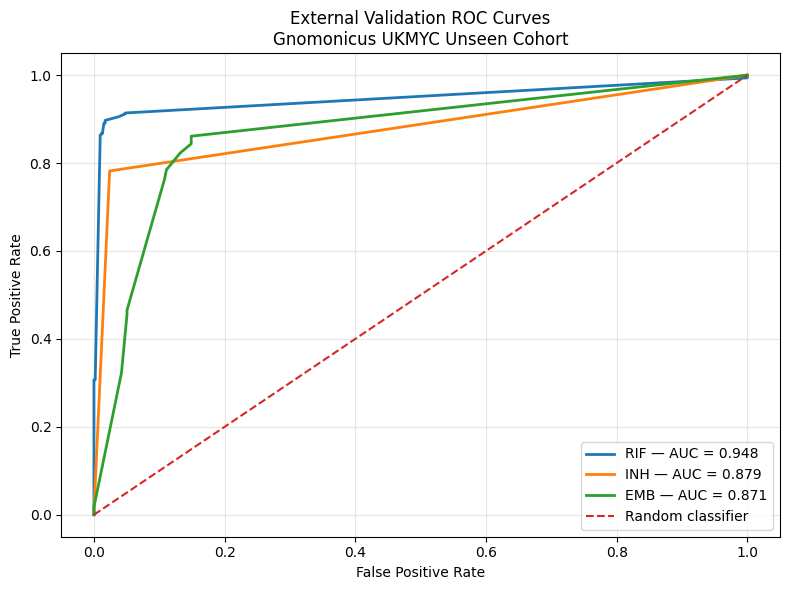

In [234]:
# ============================================================
# FINAL EXTERNAL ROC CURVES
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for drug in ["RIF", "INH", "EMB"]:

    data = unseen_data[
        unseen_data["DRUG"] == drug
    ].copy()

    model_key = (
        model_drug_names[drug],
        final_model_names[drug]
    )

    model = best_models[model_key]

    # Exact feature order used during training
    model_features = list(model.feature_names_in_)

    X_ext = data[model_features]
    y_ext = data["y"].astype(int)

    # Probability of resistance
    y_prob = model.predict_proba(X_ext)[:, 1]

    fpr, tpr, _ = roc_curve(y_ext, y_prob)
    auc = roc_auc_score(y_ext, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{drug} — AUC = {auc:.3f}"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "External Validation ROC Curves\n"
    "Gnomonicus UKMYC Unseen Cohort"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

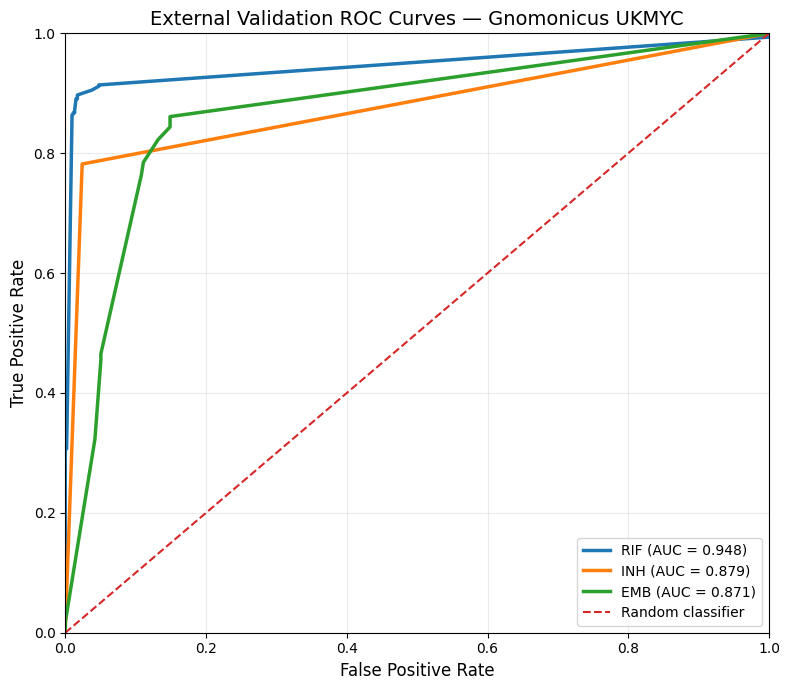

Saved: /content/external_ROC_curves.png


In [235]:
# ============================================================
# PUBLICATION-READY EXTERNAL ROC CURVE
# ============================================================

plt.figure(figsize=(8, 7))

for drug in ["RIF", "INH", "EMB"]:

    plt.plot(
        roc_data[drug]["fpr"],
        roc_data[drug]["tpr"],
        linewidth=2.5,
        label=f"{drug} (AUC = {roc_data[drug]['auc']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "External Validation ROC Curves — Gnomonicus UKMYC",
    fontsize=14
)

plt.legend(fontsize=10)
plt.grid(alpha=0.25)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "/content/external_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: /content/external_ROC_curves.png")

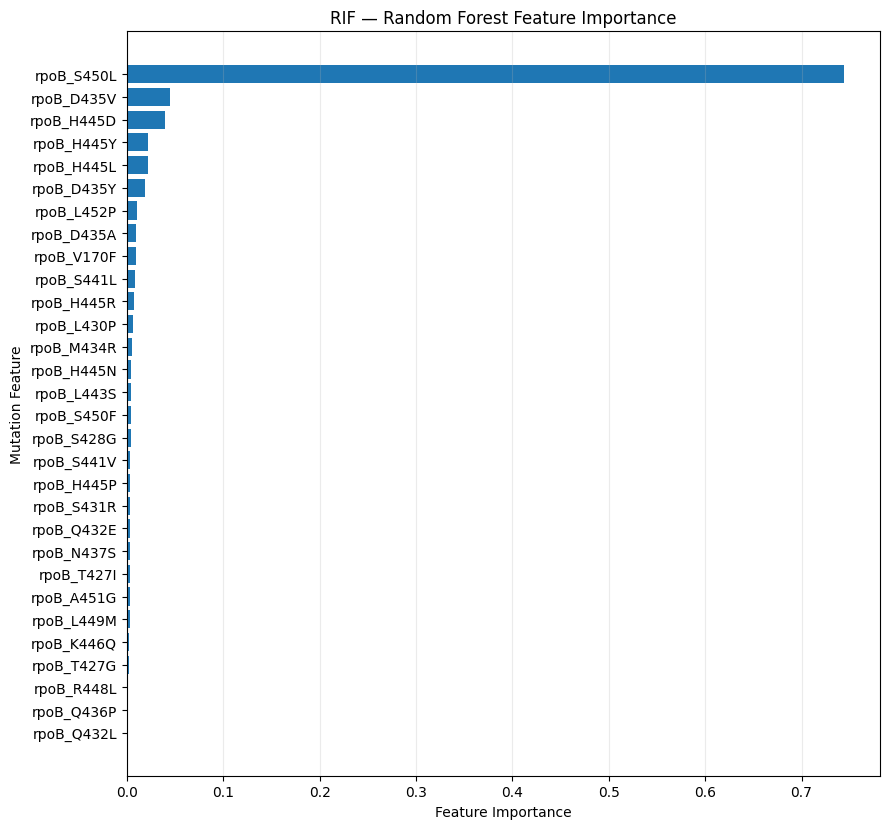

Saved: /content/RIF_feature_importance.png

Feature ranking:


,Feature,Importance
0,rpoB_S450L,0.744216
1,rpoB_D435V,0.045019
2,rpoB_H445D,0.039432
3,rpoB_H445Y,0.022389
4,rpoB_H445L,0.022243
5,rpoB_D435Y,0.018461
6,rpoB_L452P,0.010548
7,rpoB_D435A,0.009556
8,rpoB_V170F,0.009043
9,rpoB_S441L,0.008810


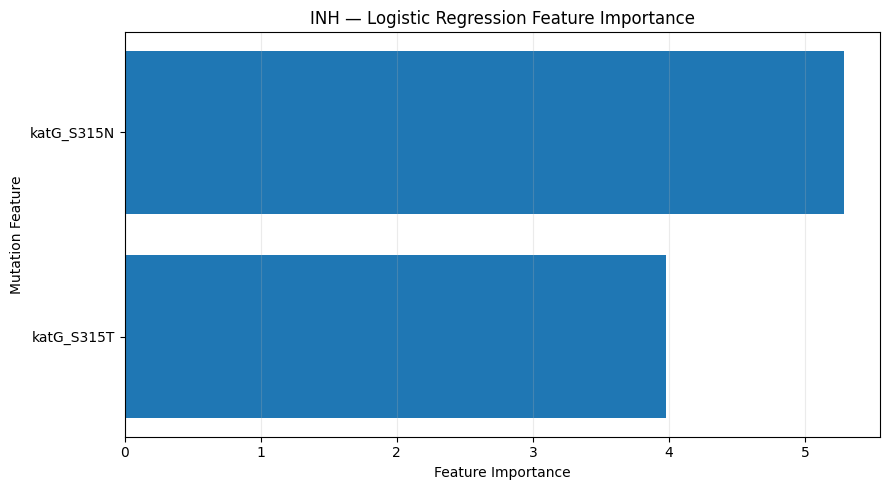

Saved: /content/INH_feature_importance.png

Feature ranking:


,Feature,Importance
0,katG_S315N,5.284055
1,katG_S315T,3.974298


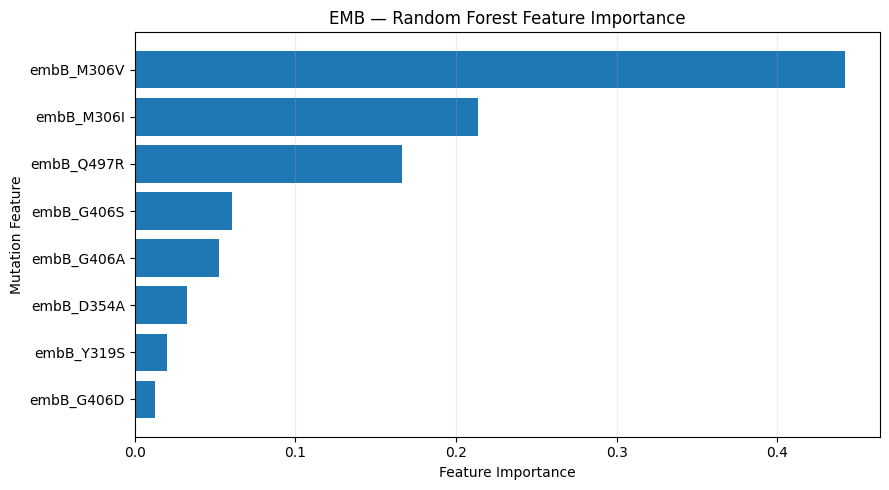

Saved: /content/EMB_feature_importance.png

Feature ranking:


,Feature,Importance
0,embB_M306V,0.441828
1,embB_M306I,0.213785
2,embB_Q497R,0.166187
3,embB_G406S,0.060448
4,embB_G406A,0.052542
5,embB_D354A,0.032615
6,embB_Y319S,0.019823
7,embB_G406D,0.012772


In [236]:
# ============================================================
# FINAL FEATURE IMPORTANCE FIGURES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

selected_models = {
    "RIF": ("Rifampicin", "Random Forest"),
    "INH": ("Isoniazid", "Logistic Regression"),
    "EMB": ("Ethambutol", "Random Forest")
}

for drug, model_key in selected_models.items():

    model = best_models[model_key]

    # Exact features used during model training
    features = list(model.feature_names_in_)

    # --------------------------------------------------------
    # Feature importance
    # --------------------------------------------------------

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_[0])

    else:
        print(f"No feature importance available for {drug}")
        continue

    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(
        "Importance",
        ascending=True
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(9, max(5, len(features) * 0.28)))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Mutation Feature")
    plt.title(
        f"{drug} — {model_key[1]} Feature Importance"
    )

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()

    # Save
    filename = f"/content/{drug}_feature_importance.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {filename}")

    # Print ranking
    print("\nFeature ranking:")
    display(
        importance_df.sort_values(
            "Importance",
            ascending=False
        ).reset_index(drop=True)
    )

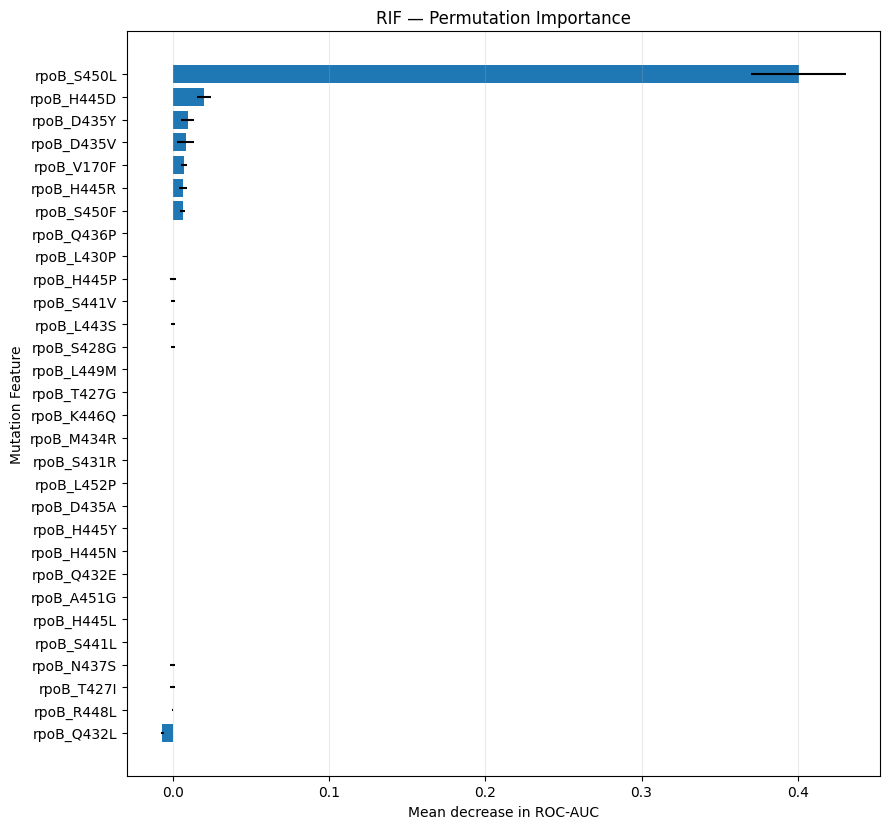


Saved: /content/RIF_permutation_importance.png

Feature ranking:


,Feature,Mean Importance,SD
0,rpoB_S450L,0.400523,0.030192
1,rpoB_H445D,0.020050,0.004386
2,rpoB_D435Y,0.009536,0.004126
3,rpoB_D435V,0.008206,0.005441
4,rpoB_V170F,0.007076,0.001843
5,rpoB_H445R,0.006463,0.002644
6,rpoB_S450F,0.006212,0.001418
7,rpoB_Q436P,0.000196,0.000054
8,rpoB_L430P,0.000160,0.000105
9,rpoB_H445P,0.000080,0.001669


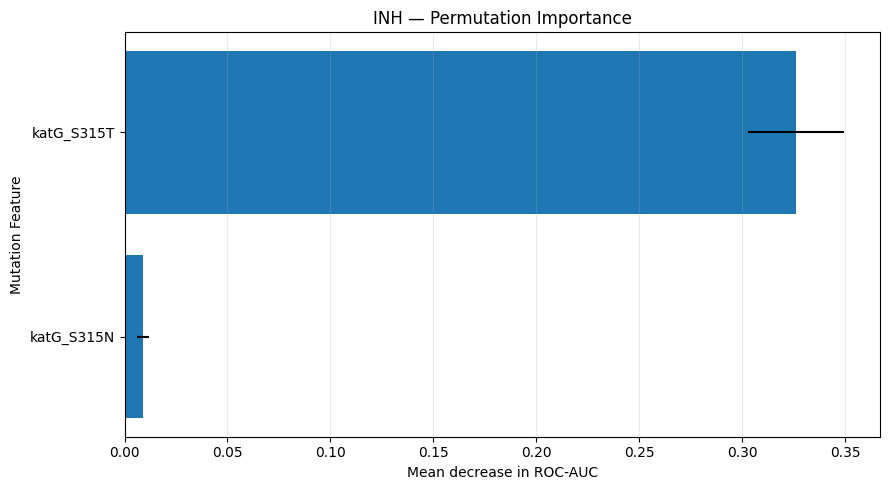


Saved: /content/INH_permutation_importance.png

Feature ranking:


,Feature,Mean Importance,SD
0,katG_S315T,0.326144,0.023330
1,katG_S315N,0.008947,0.002793


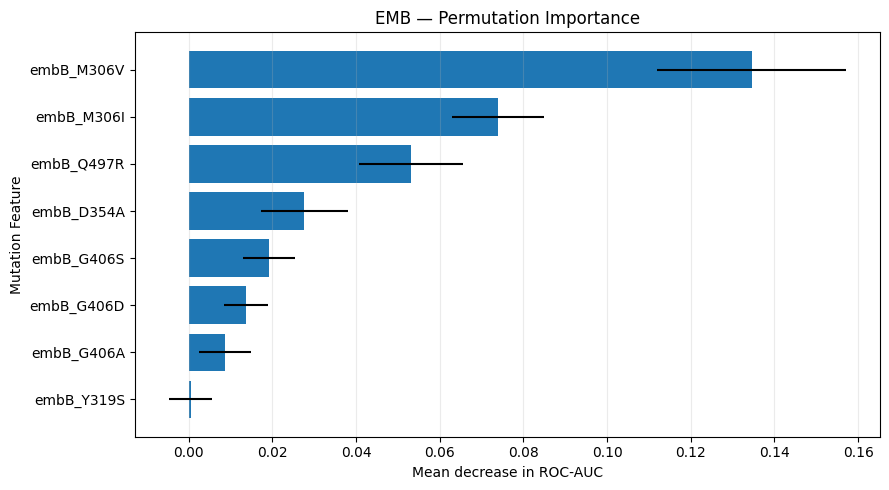


Saved: /content/EMB_permutation_importance.png

Feature ranking:


,Feature,Mean Importance,SD
0,embB_M306V,0.134531,0.022594
1,embB_M306I,0.073923,0.010905
2,embB_Q497R,0.053135,0.012488
3,embB_D354A,0.027659,0.010356
4,embB_G406S,0.019130,0.006229
5,embB_G406D,0.013648,0.005200
6,embB_G406A,0.008696,0.006169
7,embB_Y319S,0.000445,0.005250


In [237]:
# ============================================================
# FINAL PERMUTATION IMPORTANCE — INTERNAL TEST SET
# ============================================================

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

selected_models = {
    "RIF": ("Rifampicin", "Random Forest"),
    "INH": ("Isoniazid", "Logistic Regression"),
    "EMB": ("Ethambutol", "Random Forest")
}

permutation_results = {}

for drug, model_key in selected_models.items():

    # Get original optimized dataset
    X, y = datasets_optimized[model_key[0]]

    # Recreate the SAME 80/20 split used earlier
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Get the SAME frozen tuned model
    model = best_models[model_key]

    # Permutation importance on INTERNAL TEST SET
    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    # Exact feature names
    if hasattr(model, "feature_names_in_"):
        features = list(model.feature_names_in_)
    else:
        features = list(X.columns)

    importance_df = pd.DataFrame({
        "Feature": features,
        "Mean Importance": result.importances_mean,
        "SD": result.importances_std
    }).sort_values(
        "Mean Importance",
        ascending=False
    )

    permutation_results[drug] = importance_df

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plot_df = importance_df.sort_values(
        "Mean Importance",
        ascending=True
    )

    plt.figure(
        figsize=(9, max(5, len(plot_df) * 0.28))
    )

    plt.barh(
        plot_df["Feature"],
        plot_df["Mean Importance"],
        xerr=plot_df["SD"]
    )

    plt.xlabel("Mean decrease in ROC-AUC")
    plt.ylabel("Mutation Feature")

    plt.title(
        f"{drug} — Permutation Importance"
    )

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()

    filename = f"/content/{drug}_permutation_importance.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\nSaved: {filename}")

    print("\nFeature ranking:")
    display(importance_df.reset_index(drop=True))

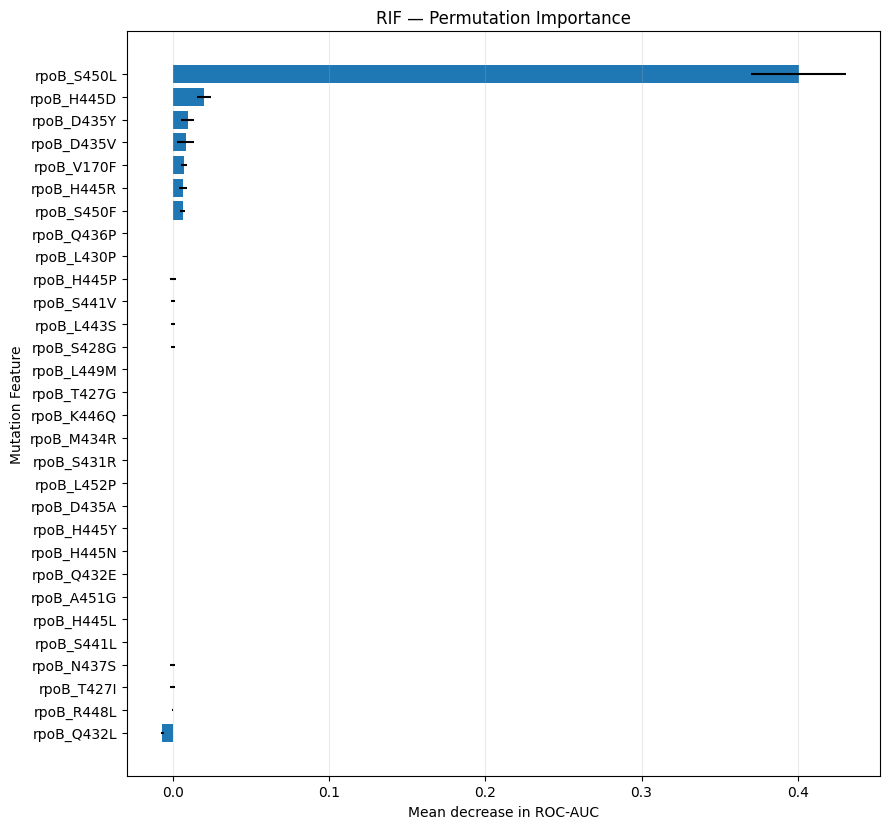


Saved: /content/RIF_permutation_importance.png

Feature ranking:


,Feature,Mean Importance,SD
0,rpoB_S450L,0.400523,0.030192
1,rpoB_H445D,0.020050,0.004386
2,rpoB_D435Y,0.009536,0.004126
3,rpoB_D435V,0.008206,0.005441
4,rpoB_V170F,0.007076,0.001843
5,rpoB_H445R,0.006463,0.002644
6,rpoB_S450F,0.006212,0.001418
7,rpoB_Q436P,0.000196,0.000054
8,rpoB_L430P,0.000160,0.000105
9,rpoB_H445P,0.000080,0.001669


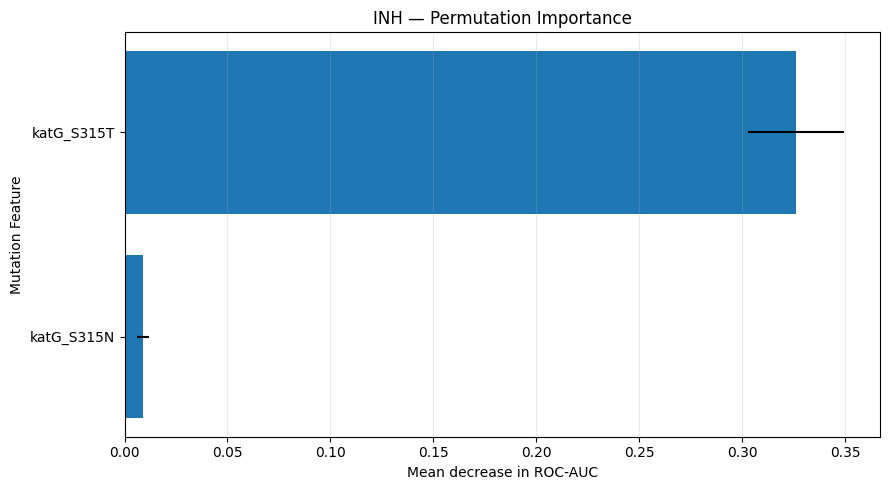


Saved: /content/INH_permutation_importance.png

Feature ranking:


,Feature,Mean Importance,SD
0,katG_S315T,0.326144,0.023330
1,katG_S315N,0.008947,0.002793


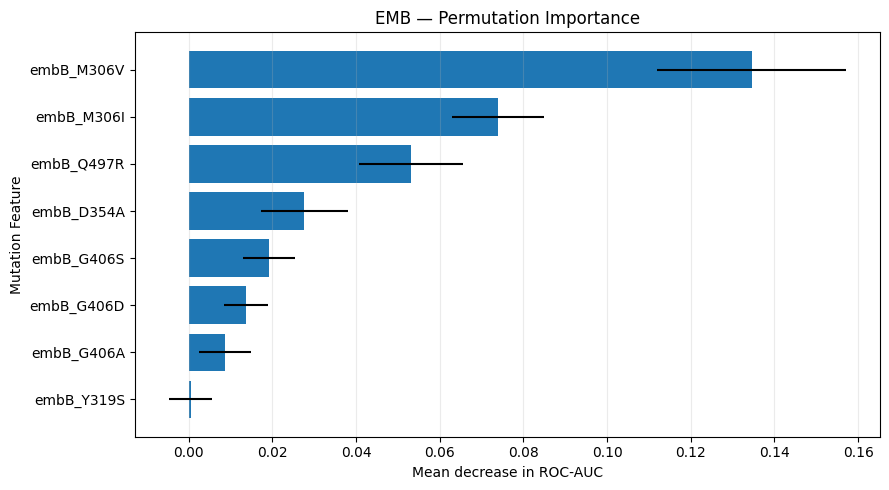


Saved: /content/EMB_permutation_importance.png

Feature ranking:


,Feature,Mean Importance,SD
0,embB_M306V,0.134531,0.022594
1,embB_M306I,0.073923,0.010905
2,embB_Q497R,0.053135,0.012488
3,embB_D354A,0.027659,0.010356
4,embB_G406S,0.019130,0.006229
5,embB_G406D,0.013648,0.005200
6,embB_G406A,0.008696,0.006169
7,embB_Y319S,0.000445,0.005250


In [238]:
# ============================================================
# FINAL PERMUTATION IMPORTANCE — FIXED DRUG NAMES
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

selected_models = {
    "RIF": ("Rifampicin", "Random Forest"),
    "INH": ("Isoniazid", "Logistic Regression"),
    "EMB": ("Ethambutol", "Random Forest")
}

permutation_results = {}

for drug, model_key in selected_models.items():

    # Correct dataset key
    X, y = datasets_optimized[model_key[0]]

    # Use the SAME original 80/20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Frozen final model
    model = best_models[model_key]

    # Permutation importance
    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    # Exact feature order
    features = list(model.feature_names_in_)

    importance_df = pd.DataFrame({
        "Feature": features,
        "Mean Importance": result.importances_mean,
        "SD": result.importances_std
    }).sort_values(
        "Mean Importance",
        ascending=False
    )

    permutation_results[drug] = importance_df

    # Plot
    plot_df = importance_df.sort_values(
        "Mean Importance",
        ascending=True
    )

    plt.figure(
        figsize=(9, max(5, len(plot_df) * 0.28))
    )

    plt.barh(
        plot_df["Feature"],
        plot_df["Mean Importance"],
        xerr=plot_df["SD"]
    )

    plt.xlabel("Mean decrease in ROC-AUC")
    plt.ylabel("Mutation Feature")
    plt.title(
        f"{drug} — Permutation Importance"
    )

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()

    filename = f"/content/{drug}_permutation_importance.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\nSaved: {filename}")
    print("\nFeature ranking:")

    display(
        importance_df.reset_index(drop=True)
    )

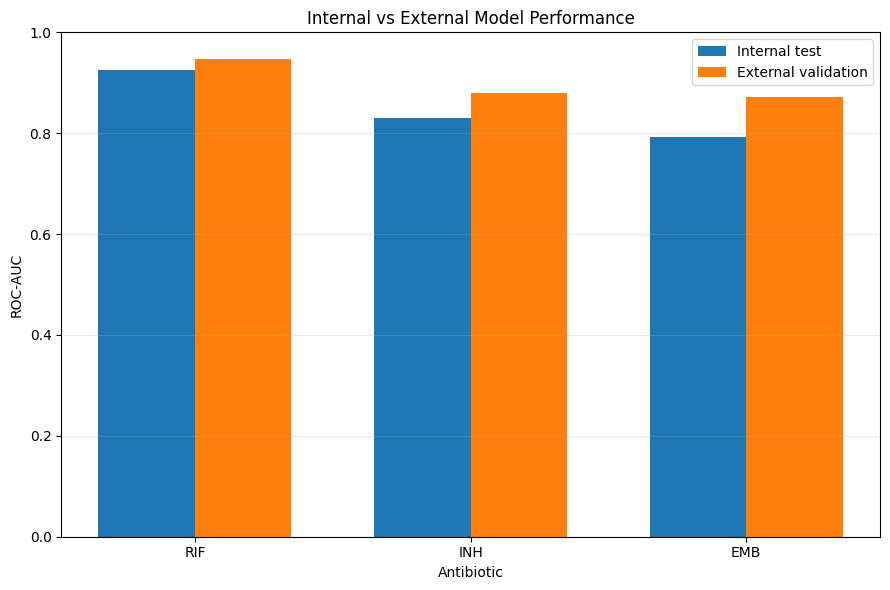

Saved: /content/internal_vs_external_AUC.png


In [239]:
# ============================================================
# FINAL INTERNAL vs EXTERNAL ROC-AUC FIGURE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Antibiotics
drugs = ["RIF", "INH", "EMB"]

# Final confirmed AUC values
internal_auc = [0.9259, 0.8309, 0.7922]
external_auc = [0.9476, 0.8791, 0.8710]

# X-axis positions
x = np.arange(len(drugs))
width = 0.35

plt.figure(figsize=(9, 6))

# Internal test AUC
plt.bar(
    x - width/2,
    internal_auc,
    width,
    label="Internal test"
)

# External validation AUC
plt.bar(
    x + width/2,
    external_auc,
    width,
    label="External validation"
)

# Labels
plt.xticks(x, drugs)
plt.ylabel("ROC-AUC")
plt.xlabel("Antibiotic")

# AUC range
plt.ylim(0, 1)

# Title
plt.title(
    "Internal vs External Model Performance"
)

# Legend
plt.legend()

# Grid
plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

# Save figure
plt.savefig(
    "/content/internal_vs_external_AUC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: /content/internal_vs_external_AUC.png")

In [240]:
# ============================================================
# FINAL DATASET + MODEL SUMMARY
# ============================================================

dataset_summary = pd.DataFrame({
    "Drug": [
        "Rifampicin",
        "Isoniazid",
        "Ethambutol"
    ],

    "Training Samples": [
        1296,
        1300,
        1061
    ],

    "Training Features": [
        30,
        2,
        8
    ],

    "Final Model": [
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],

    "External Samples": [
        1000,
        1000,
        1000
    ],

    "External Resistant": [
        476,
        500,
        288
    ],

    "External Susceptible": [
        524,
        500,
        712
    ],

    "Threshold": [
        0.72,
        0.50,
        0.32
    ],

    "Internal ROC-AUC": [
        0.9259,
        0.8309,
        0.7922
    ],

    "External ROC-AUC": [
        0.9476,
        0.8791,
        0.8710
    ]
})

display(dataset_summary)

,Drug,Training Samples,Training Features,Final Model,External Samples,External Resistant,External Susceptible,Threshold,Internal ROC-AUC,External ROC-AUC
0,Rifampicin,1296,30,Random Forest,1000,476,524,0.72,0.9259,0.9476
1,Isoniazid,1300,2,Logistic Regression,1000,500,500,0.50,0.8309,0.8791
2,Ethambutol,1061,8,Random Forest,1000,288,712,0.32,0.7922,0.8710


In [241]:
# ==========================================
# FINAL MASTER RESULTS TABLE
# ==========================================

import pandas as pd

final_results = pd.DataFrame({
    "Drug": ["Rifampicin", "Isoniazid", "Ethambutol"],
    "Model": ["Random Forest", "Logistic Regression", "Random Forest"],
    "Features": [30, 2, 8],
    "Threshold": [0.72, 0.50, 0.32],

    "Internal_ROC_AUC": [0.9259, 0.8309, 0.7922],
    "External_ROC_AUC": [0.9476, 0.8791, 0.8710],

    "External_Accuracy": [93.20, 87.90, 85.40],
    "External_Precision": [98.34, 97.02, 70.06],
    "External_Recall": [87.18, 78.20, 86.11],
    "External_F1": [92.43, 86.60, 77.26],

    "External_95CI": [
        "0.9316–0.9617",
        "0.8593–0.8984",
        "0.8447–0.8960"
    ]
})

final_results

,Drug,Model,Features,Threshold,Internal_ROC_AUC,External_ROC_AUC,External_Accuracy,External_Precision,External_Recall,External_F1,External_95CI
0,Rifampicin,Random Forest,30,0.72,0.9259,0.9476,93.2,98.34,87.18,92.43,0.9316–0.9617
1,Isoniazid,Logistic Regression,2,0.50,0.8309,0.8791,87.9,97.02,78.20,86.60,0.8593–0.8984
2,Ethambutol,Random Forest,8,0.32,0.7922,0.8710,85.4,70.06,86.11,77.26,0.8447–0.8960


In [242]:
final_results.to_csv(
    "/content/final_master_results.csv",
    index=False
)

print("Saved successfully:")
print("/content/final_master_results.csv")

Saved successfully:
/content/final_master_results.csv


In [243]:
# ============================================================
# LEAKAGE CHECK — EXACT MUTATION PROFILE OVERLAP
# ============================================================

import pandas as pd

# Use the already loaded external dataset
ext = unseen_data.copy()

# RIF / INH / EMB → full drug names
drug_name_map = {
    "RIF": "Rifampicin",
    "INH": "Isoniazid",
    "EMB": "Ethambutol"
}

print("External dataset shape:", ext.shape)

for drug in ["RIF", "INH", "EMB"]:

    full_drug = drug_name_map[drug]

    # -----------------------------------------
    # Get development feature matrix
    # -----------------------------------------
    X_dev = datasets_optimized[full_drug][0]

    # Use the exact features of the final model
    model_key = (
        full_drug,
        final_model_names[drug]
    )

    model = best_models[model_key]

    model_features = list(model.feature_names_in_)

    # -----------------------------------------
    # External samples for this drug
    # -----------------------------------------
    ext_drug = ext[
        ext["DRUG"].astype(str).str.upper() == drug
    ].copy()

    # -----------------------------------------
    # Convert each sample into a tuple
    # of mutation values
    # -----------------------------------------
    train_profiles = set(
        X_dev[model_features]
        .fillna(0)
        .astype(int)
        .itertuples(index=False, name=None)
    )

    external_profiles = list(
        ext_drug[model_features]
        .fillna(0)
        .astype(int)
        .itertuples(index=False, name=None)
    )

    # -----------------------------------------
    # Exact profile matches
    # -----------------------------------------
    matches = [
        profile in train_profiles
        for profile in external_profiles
    ]

    n_matches = sum(matches)
    n_external = len(external_profiles)

    percentage = (
        (n_matches / n_external) * 100
        if n_external > 0
        else 0
    )

    print("\n" + "=" * 60)
    print(f"{full_drug} ({drug})")
    print("=" * 60)

    print("Development samples       :", len(X_dev))
    print("External samples          :", n_external)
    print("Exact profile matches     :", n_matches)
    print("Match percentage          :", round(percentage, 2), "%")

External dataset shape: (3000, 45)

Rifampicin (RIF)
Development samples       : 1296
External samples          : 1000
Exact profile matches     : 985
Match percentage          : 98.5 %

Isoniazid (INH)
Development samples       : 1300
External samples          : 1000
Exact profile matches     : 999
Match percentage          : 99.9 %

Ethambutol (EMB)
Development samples       : 1061
External samples          : 1000
Exact profile matches     : 994
Match percentage          : 99.4 %


In [244]:
# ============================================================
# REAL DATA-LEAKAGE CHECK
# EXTERNAL vs DEVELOPMENT SAMPLE IDENTIFIERS
# ============================================================

print("=" * 70)
print("CHECKING EXACT SAMPLE / GENOME IDENTIFIER OVERLAP")
print("=" * 70)

# External identifiers
external_ids = set(
    unseen_data["ENA_RUN_ACCESSION"]
    .astype(str)
    .str.strip()
)

external_uniqueids = set(
    unseen_data["UNIQUEID"]
    .astype(str)
    .str.strip()
)

print("\nExternal samples:", len(external_ids))
print("External UNIQUEIDs:", len(external_uniqueids))


# ------------------------------------------------------------
# Check against BV-BRC phenotype table if available
# ------------------------------------------------------------

if "tb_lab" in globals():

    print("\nBV-BRC table found:", tb_lab.shape)

    # Genome IDs
    if "Genome ID" in tb_lab.columns:

        bvbrc_genome_ids = set(
            tb_lab["Genome ID"]
            .astype(str)
            .str.strip()
        )

        overlap_genome = external_ids.intersection(
            bvbrc_genome_ids
        )

        print(
            "\nExternal ENA accessions matching BV-BRC Genome IDs:",
            len(overlap_genome)
        )

        if len(overlap_genome) == 0:
            print("✅ No exact identifier overlap detected.")

    # Check every BV-BRC column for external accession matches
    print("\nChecking external accessions against BV-BRC columns...")

    for col in tb_lab.columns:

        try:
            values = set(
                tb_lab[col]
                .dropna()
                .astype(str)
                .str.strip()
            )

            overlap = external_ids.intersection(values)

            if len(overlap) > 0:
                print(
                    f"⚠️ MATCH in column '{col}': {len(overlap)}"
                )

        except Exception:
            pass

else:

    print(
        "\n⚠️ tb_lab is not currently available in this Colab session."
    )

CHECKING EXACT SAMPLE / GENOME IDENTIFIER OVERLAP

External samples: 1000
External UNIQUEIDs: 1000

BV-BRC table found: (14271, 21)

External ENA accessions matching BV-BRC Genome IDs: 0
✅ No exact identifier overlap detected.

Checking external accessions against BV-BRC columns...


In [245]:
# ============================================================
# CHECK: WHY ARE FEATURE PROFILES SO SIMILAR?
# ============================================================

drug_name_map = {
    "RIF": "Rifampicin",
    "INH": "Isoniazid",
    "EMB": "Ethambutol"
}

for drug in ["RIF", "INH", "EMB"]:

    full_drug = drug_name_map[drug]

    model_key = (
        full_drug,
        final_model_names[drug]
    )

    model = best_models[model_key]
    model_features = list(model.feature_names_in_)

    # External samples
    ext_drug = unseen_data[
        unseen_data["DRUG"].astype(str).str.upper() == drug
    ].copy()

    # Count selected mutations
    ext_drug["Mutation_Count"] = (
        ext_drug[model_features]
        .fillna(0)
        .sum(axis=1)
    )

    print("\n" + "=" * 60)
    print(f"{full_drug} ({drug})")
    print("=" * 60)

    print("\nExternal mutation-count distribution:")
    print(
        ext_drug["Mutation_Count"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nExternal samples with ZERO selected mutations:",
        (ext_drug["Mutation_Count"] == 0).sum()
    )

    print(
        "External samples with ≥1 selected mutation:",
        (ext_drug["Mutation_Count"] >= 1).sum()
    )


Rifampicin (RIF)

External mutation-count distribution:
Mutation_Count
0    537
1    449
2     14
Name: count, dtype: int64

External samples with ZERO selected mutations: 537
External samples with ≥1 selected mutation: 463

Isoniazid (INH)

External mutation-count distribution:
Mutation_Count
0    597
1    402
2      1
Name: count, dtype: int64

External samples with ZERO selected mutations: 597
External samples with ≥1 selected mutation: 403

Ethambutol (EMB)

External mutation-count distribution:
Mutation_Count
0    646
1    346
2      8
Name: count, dtype: int64

External samples with ZERO selected mutations: 646
External samples with ≥1 selected mutation: 354


In [246]:
# ============================================================
# LEAKAGE CHECK — EXTERNAL UNIQUEID AGAINST ALL BV-BRC COLUMNS
# ============================================================

external_uniqueids = set(
    unseen_data["UNIQUEID"]
    .dropna()
    .astype(str)
    .str.strip()
)

print("=" * 70)
print("CHECKING EXTERNAL UNIQUEIDs AGAINST BV-BRC")
print("=" * 70)

print("External UNIQUEIDs:", len(external_uniqueids))

matches_found = False

for col in tb_lab.columns:

    try:
        bv_values = set(
            tb_lab[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

        overlap = external_uniqueids.intersection(bv_values)

        if len(overlap) > 0:
            matches_found = True

            print(
                f"⚠️ Column '{col}': {len(overlap)} matches"
            )

    except Exception:
        continue

if not matches_found:
    print("\n✅ No UNIQUEID overlap found in any BV-BRC column.")

CHECKING EXTERNAL UNIQUEIDs AGAINST BV-BRC
External UNIQUEIDs: 1000

✅ No UNIQUEID overlap found in any BV-BRC column.


In [247]:
# ============================================================
# CHECK: GENOTYPE–PHENOTYPE RELATIONSHIP
# DEVELOPMENT vs EXTERNAL
# ============================================================

import pandas as pd
import numpy as np

drug_name_map = {
    "RIF": "Rifampicin",
    "INH": "Isoniazid",
    "EMB": "Ethambutol"
}

for drug in ["RIF", "INH", "EMB"]:

    full_drug = drug_name_map[drug]

    # --------------------------------------------------------
    # FINAL MODEL / FEATURES
    # --------------------------------------------------------
    model_key = (
        full_drug,
        final_model_names[drug]
    )

    model = best_models[model_key]
    model_features = list(model.feature_names_in_)

    # --------------------------------------------------------
    # DEVELOPMENT DATA
    # --------------------------------------------------------
    X_dev, y_dev = datasets_optimized[full_drug]

    dev = X_dev.copy()
    dev["y"] = np.asarray(y_dev).astype(int)

    dev["Mutation_Count"] = (
        dev[model_features]
        .fillna(0)
        .sum(axis=1)
    )

    dev["Mutation_Present"] = (
        dev["Mutation_Count"] > 0
    ).astype(int)

    # --------------------------------------------------------
    # EXTERNAL DATA
    # --------------------------------------------------------
    ext = unseen_data[
        unseen_data["DRUG"].astype(str).str.upper() == drug
    ].copy()

    ext["Mutation_Count"] = (
        ext[model_features]
        .fillna(0)
        .sum(axis=1)
    )

    ext["Mutation_Present"] = (
        ext["Mutation_Count"] > 0
    ).astype(int)

    ext["y"] = ext["y"].astype(int)

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print(f"{full_drug} ({drug})")
    print("=" * 70)

    print("\nDEVELOPMENT DATA")
    print("-" * 50)

    print(
        pd.crosstab(
            dev["Mutation_Present"],
            dev["y"],
            rownames=["Selected mutation present"],
            colnames=["Phenotype"],
            margins=True
        )
    )

    print("\nResistance rate:")
    print(
        dev.groupby("Mutation_Present")["y"]
        .mean()
        .mul(100)
        .round(2)
    )

    print("\nEXTERNAL DATA")
    print("-" * 50)

    print(
        pd.crosstab(
            ext["Mutation_Present"],
            ext["y"],
            rownames=["Selected mutation present"],
            colnames=["Phenotype"],
            margins=True
        )
    )

    print("\nResistance rate:")
    print(
        ext.groupby("Mutation_Present")["y"]
        .mean()
        .mul(100)
        .round(2)
    )


Rifampicin (RIF)

DEVELOPMENT DATA
--------------------------------------------------
Phenotype                    0    1   All
Selected mutation present                
0                          842   39   881
1                           85  330   415
All                        927  369  1296

Resistance rate:
Mutation_Present
0     4.43
1    79.52
Name: y, dtype: float64

EXTERNAL DATA
--------------------------------------------------
Phenotype                    0    1   All
Selected mutation present                
0                          499   38   537
1                           25  438   463
All                        524  476  1000

Resistance rate:
Mutation_Present
0     7.08
1    94.60
Name: y, dtype: float64

Isoniazid (INH)

DEVELOPMENT DATA
--------------------------------------------------
Phenotype                    0    1   All
Selected mutation present                
0                          790  163   953
1                           28  319   347
All        

In [251]:

print("selected_models type:", type(selected_models))
print("Actual keys:", list(selected_models.keys()))

for key, model in selected_models.items():
    print(f"Key: {key!r} | Model: {type(model).__name__}")


selected_models type: <class 'dict'>
Actual keys: ['RIF', 'INH', 'EMB']
Key: 'RIF' | Model: tuple
Key: 'INH' | Model: tuple
Key: 'EMB' | Model: tuple


In [252]:

import os
import joblib

model_dir = "/content/TB-ResistAI-final-models"
os.makedirs(model_dir, exist_ok=True)

# Change these keys only if Step 1 shows different names
key_map = {
    "Rifampicin": "RIF",
    "Isoniazid": "INH",
    "Ethambutol": "EMB"
}

filenames = {
    "Rifampicin": "rifampicin_final_rf.joblib",
    "Isoniazid": "isoniazid_final_lr.joblib",
    "Ethambutol": "ethambutol_final_rf.joblib"
}

for drug, actual_key in key_map.items():
    if actual_key not in selected_models:
        print(f"Key not found: {actual_key!r}. Nothing saved for {drug}.")
        continue

    model = selected_models[actual_key]
    path = os.path.join(model_dir, filenames[drug])

    joblib.dump(model, path)
    print(f"Saved {drug}: {type(model).__name__} -> {path}")


Saved Rifampicin: tuple -> /content/TB-ResistAI-final-models/rifampicin_final_rf.joblib
Saved Isoniazid: tuple -> /content/TB-ResistAI-final-models/isoniazid_final_lr.joblib
Saved Ethambutol: tuple -> /content/TB-ResistAI-final-models/ethambutol_final_rf.joblib


In [253]:

for drug, value in selected_models.items():
    print("\n" + "=" * 50)
    print("Drug:", drug)
    print("Tuple length:", len(value) if isinstance(value, tuple) else "Not a tuple")

    if isinstance(value, tuple):
        for i, item in enumerate(value):
            print(
                f"Item {i}: type={type(item).__name__}, "
                f"shape={getattr(item, 'shape', None)}"
            )
            if hasattr(item, "predict_proba"):
                print("  -> This item looks like a trained estimator")



Drug: RIF
Tuple length: 2
Item 0: type=str, shape=None
Item 1: type=str, shape=None

Drug: INH
Tuple length: 2
Item 0: type=str, shape=None
Item 1: type=str, shape=None

Drug: EMB
Tuple length: 2
Item 0: type=str, shape=None
Item 1: type=str, shape=None


In [254]:

print("Checking best_models...")

if "best_models" in globals():
    print("Type:", type(best_models))
    print("Keys:", list(best_models.keys()))

    for key, value in best_models.items():
        print(f"\nKey: {key!r}")
        print("Value type:", type(value).__name__)

        if hasattr(value, "predict_proba"):
            print("STATUS: Fitted estimator candidate")
            print("Estimator:", type(value).__name__)

        elif isinstance(value, tuple):
            print("Tuple contents:")
            for i, item in enumerate(value):
                print(f"  Item {i}: {type(item).__name__} = {item!r}")
else:
    print("best_models does not exist in this runtime.")


Checking best_models...
Type: <class 'dict'>
Keys: [('Rifampicin', 'Logistic Regression'), ('Rifampicin', 'Random Forest'), ('Rifampicin', 'XGBoost'), ('Isoniazid', 'Logistic Regression'), ('Isoniazid', 'Random Forest'), ('Isoniazid', 'XGBoost'), ('Ethambutol', 'Logistic Regression'), ('Ethambutol', 'Random Forest'), ('Ethambutol', 'XGBoost')]

Key: ('Rifampicin', 'Logistic Regression')
Value type: LogisticRegression
STATUS: Fitted estimator candidate
Estimator: LogisticRegression

Key: ('Rifampicin', 'Random Forest')
Value type: RandomForestClassifier
STATUS: Fitted estimator candidate
Estimator: RandomForestClassifier

Key: ('Rifampicin', 'XGBoost')
Value type: XGBClassifier
STATUS: Fitted estimator candidate
Estimator: XGBClassifier

Key: ('Isoniazid', 'Logistic Regression')
Value type: LogisticRegression
STATUS: Fitted estimator candidate
Estimator: LogisticRegression

Key: ('Isoniazid', 'Random Forest')
Value type: RandomForestClassifier
STATUS: Fitted estimator candidate
Estimato

In [256]:

from pathlib import Path
import json
import joblib
import zipfile
import numpy as np

# 1. Select the EXACT fitted models already in best_models
final_selection = {
    "RIF": {
        "drug": "Rifampicin",
        "model_name": "Random Forest",
        "key": ("Rifampicin", "Random Forest"),
        "threshold": 0.72
    },
    "INH": {
        "drug": "Isoniazid",
        "model_name": "Logistic Regression",
        "key": ("Isoniazid", "Logistic Regression"),
        "threshold": 0.50
    },
    "EMB": {
        "drug": "Ethambutol",
        "model_name": "Random Forest",
        "key": ("Ethambutol", "Random Forest"),
        "threshold": 0.32
    }
}

output_dir = Path("/content/TB_ResistAI_Export")
output_dir.mkdir(parents=True, exist_ok=True)

manifest = {
    "project": "TB-ResistAI",
    "purpose": "Research prototype for TB drug-resistance prediction",
    "models": {}
}

# 2. Validate and export the existing fitted estimators
for code, info in final_selection.items():
    key = info["key"]

    if key not in best_models:
        raise KeyError(f"Required fitted model not found: {key}")

    model = best_models[key]

    if not hasattr(model, "predict_proba"):
        raise TypeError(f"{key} does not support predict_proba().")

    if not hasattr(model, "classes_"):
        raise ValueError(f"{key} does not appear to be fitted.")

    # Preserve the exact feature order used during model training.
    feature_names = getattr(model, "feature_names_in_", None)

    if feature_names is None:
        raise ValueError(
            f"{key} has no feature_names_in_. "
            "Do not export yet: we must recover its exact training "
            "feature names and order from your existing notebook."
        )

    feature_names = [str(f) for f in feature_names]

    # Determine which probability column corresponds to class 1.
    classes = list(model.classes_)
    positive_matches = [
        i for i, c in enumerate(classes)
        if str(c) == "1"
    ]

    if len(positive_matches) != 1:
        raise ValueError(
            f"{key}: classes are {classes}. "
            "Confirm which class represents resistance before export."
        )

    bundle = {
        "drug_code": code,
        "drug_name": info["drug"],
        "model_name": info["model_name"],
        "estimator": model,
        "feature_names": feature_names,
        "threshold": info["threshold"],
        "classes": classes,
        "positive_class": 1,
        "positive_probability_column": positive_matches[0]
    }

    model_path = output_dir / f"{code}_model.joblib"
    joblib.dump(bundle, model_path)

    # Verify that the saved artifact can be loaded.
    loaded = joblib.load(model_path)
    assert loaded["estimator"] is not None
    assert len(loaded["feature_names"]) == loaded["estimator"].n_features_in_

    manifest["models"][code] = {
        "drug": info["drug"],
        "model": info["model_name"],
        "threshold": info["threshold"],
        "features": feature_names,
        "feature_count": len(feature_names),
        "classes": [str(c) for c in classes],
        "artifact": model_path.name
    }

    print(
        f"Exported {code}: {info['model_name']} | "
        f"{len(feature_names)} features | threshold={info['threshold']}"
    )

# 3. Save metadata
with open(output_dir / "model_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

# 4. Add a README
readme = """# TB-ResistAI Model Export

Research prototype for predicting tuberculosis drug resistance.

Artifacts:
- RIF_model.joblib: Rifampicin Random Forest
- INH_model.joblib: Isoniazid Logistic Regression
- EMB_model.joblib: Ethambutol Random Forest
- model_manifest.json: model and feature metadata

Decision thresholds:
- RIF: 0.72
- INH: 0.50
- EMB: 0.32

Use the saved feature names and their exact order when preparing inputs.
These artifacts require compatible Python and ML-library versions.
This is a research prototype, not a clinical diagnostic tool.
"""

(output_dir / "README.md").write_text(readme)

# 5. Package everything into one ZIP
zip_path = "/content/TB_ResistAI_Export.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for path in output_dir.iterdir():
        z.write(path, arcname=f"TB_ResistAI_Export/{path.name}")

print("\nExport completed:", zip_path)
print("Files:", sorted(p.name for p in output_dir.iterdir()))

from google.colab import files
files.download(zip_path)


Exported RIF: Random Forest | 30 features | threshold=0.72
Exported INH: Logistic Regression | 2 features | threshold=0.5
Exported EMB: Random Forest | 8 features | threshold=0.32

Export completed: /content/TB_ResistAI_Export.zip
Files: ['EMB_model.joblib', 'INH_model.joblib', 'README.md', 'RIF_model.joblib', 'model_manifest.json']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [257]:

import joblib
import numpy as np
import pandas as pd
from pathlib import Path

folder = Path("/content/TB_ResistAI_Export")

models = {
    "RIF": folder / "RIF_model.joblib",
    "INH": folder / "INH_model.joblib",
    "EMB": folder / "EMB_model.joblib",
}

for drug, path in models.items():
    bundle = joblib.load(path)
    model = bundle["estimator"]
    features = bundle["feature_names"]

    # Synthetic input for a technical smoke test only
    X_test = pd.DataFrame(
        np.zeros((1, len(features))),
        columns=features
    )

    probabilities = model.predict_proba(X_test)
    positive_col = bundle["positive_probability_column"]
    resistance_probability = float(probabilities[0, positive_col])
    prediction = int(resistance_probability >= bundle["threshold"])

    print(f"\n{drug}: PASS")
    print("Model:", bundle["model_name"])
    print("Features:", len(features))
    print("Resistance probability:", round(resistance_probability, 4))
    print("Threshold:", bundle["threshold"])
    print("Test prediction:", prediction)

print("\nAll exported models loaded and produced predictions.")



RIF: PASS
Model: Random Forest
Features: 30
Resistance probability: 0.1129
Threshold: 0.72
Test prediction: 0

INH: PASS
Model: Logistic Regression
Features: 2
Resistance probability: 0.2644
Threshold: 0.5
Test prediction: 0

EMB: PASS
Model: Random Forest
Features: 8
Resistance probability: 0.3022
Threshold: 0.32
Test prediction: 0

All exported models loaded and produced predictions.


In [258]:

# TB-ResistAI: Complete project results backup
# Does NOT retrain or modify your fitted models.

import os
import json
import shutil
import joblib
import zipfile
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

SOURCE_MODELS = Path("/content/TB_ResistAI_Export")
OUT = Path("/content/TB_ResistAI_COMPLETE")
ZIP_PATH = Path("/content/TB_ResistAI_COMPLETE.zip")

# Start a fresh backup directory
if OUT.exists():
    shutil.rmtree(OUT)

for folder in ["models", "results/tables", "results/figures", "metadata"]:
    (OUT / folder).mkdir(parents=True, exist_ok=True)

# 1. Copy the previously exported fitted models and manifest
if SOURCE_MODELS.exists():
    for file in SOURCE_MODELS.iterdir():
        if file.is_file():
            shutil.copy2(file, OUT / "models" / file.name)
else:
    print("WARNING: Previous model export folder was not found.")

# 2. Save every DataFrame currently available in the notebook
dataframe_inventory = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        safe_name = "".join(
            c if c.isalnum() or c in "_-" else "_"
            for c in name
        )
        csv_path = OUT / "results" / "tables" / f"{safe_name}.csv"

        try:
            obj.to_csv(csv_path, index=False)
            dataframe_inventory.append({
                "variable": name,
                "file": str(csv_path.relative_to(OUT)),
                "rows": int(obj.shape[0]),
                "columns": int(obj.shape[1]),
                "column_names": [str(c) for c in obj.columns]
            })
            print(f"Saved table: {name} {obj.shape}")
        except Exception as e:
            print(f"Could not save table {name}: {e}")

# 3. Save currently open Matplotlib figures
for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(
        OUT / "results" / "figures" / f"figure_{fig_num}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Figures saved:", len(plt.get_fignums()))

# 4. Save a record of the current environment and notebook variables
environment = {
    "project": "TB-ResistAI",
    "backup_created": datetime.now().isoformat(),
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "dataframes_saved": dataframe_inventory,
    "available_project_variables": [
        name for name in globals()
        if any(term in name.lower() for term in [
            "external", "validation", "threshold", "result",
            "metric", "mutation", "feature", "confusion",
            "auc", "roc", "error", "model", "clean"
        ])
    ]
}

with open(OUT / "metadata" / "environment_and_inventory.json", "w") as f:
    json.dump(environment, f, indent=2, default=str)

# 5. Create a project summary without inventing missing metrics
readme = """# TB-ResistAI

Machine-learning research project for predicting tuberculosis
drug resistance using selected mutation features.

## Final selected models

| Drug | Model | Features | Decision threshold |
|---|---|---:|---:|
| Rifampicin (RIF) | Random Forest | 30 | 0.72 |
| Isoniazid (INH) | Logistic Regression | 2 | 0.50 |
| Ethambutol (EMB) | Random Forest | 8 | 0.32 |

## Project contents

- models/: exported fitted models and model manifest
- results/tables/: DataFrames available in the Colab runtime, saved as CSV
- results/figures/: Matplotlib figures open at backup time
- metadata/: environment details and saved-table inventory

## Important

The backup contains the tables, figures, and models available in the
current runtime. It cannot recover variables or figures that have
already been cleared, nor can it automatically include the notebook
source itself.

Verify the final external-validation ROC-AUC directly against the
saved results table before reporting it in the README or publication.

Research prototype only; not intended for clinical diagnosis.
"""

(OUT / "README.md").write_text(readme)

# 6. Package all files into one archive
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for file in OUT.rglob("*"):
        if file.is_file():
            z.write(file, file.relative_to(OUT.parent))

print("\nBACKUP CREATED:", ZIP_PATH)
print("Tables saved:", len(dataframe_inventory))
print("Archive size (MB):", round(ZIP_PATH.stat().st_size / 1e6, 2))

from google.colab import files
files.download(str(ZIP_PATH))


Saved table: df (1327, 10)
Saved table: tb (303484, 21)
Saved table: tb_lab (14271, 21)
Saved table: drug_summary (22, 6)
Saved table: genome_drug_counts (14211, 3)
Saved table: conflicts (28, 3)
Saved table: conflict_pairs (28, 2)
Saved table: conflict_records (56, 21)
Saved table: conflict_summary (6, 2)
Saved table: tb_clean (14215, 21)
Saved table: data (1000, 45)
Saved table: features_df (0, 0)
Saved table: df_features (2, 28)
Saved table: resistance_features (27, 30)
Saved table: katg (6595, 31)
Saved table: katg_rows (1, 30)
Saved table: batch_features (25000, 31)
Saved table: df_test (25000, 31)
Saved table: katg_df (105, 31)
Saved table: feature_matrix (100, 4)
Saved table: gene_df (6583, 32)
Saved table: rpob (15251, 32)
Saved table: embb (6583, 32)
Saved table: rpob_clean (7007, 32)
Saved table: rpoB_check (713, 5)
Saved table: katg_needed (1662, 31)
Saved table: rpob_needed (3842, 32)
Saved table: embb_needed (1337, 32)
Saved table: mutation_df (6708, 4)
Saved table: pheno 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>